# Détection non supervisée d'anomalies sur une installation photovoltaïque
**PFA Photovoltaïque** — Surveillance et maintenance prédictive des installations PV

**Objectif :** Transformer les données brutes (dt1 météo + dt2 électrique) en un dataset nettoyé, enrichi et prêt pour l'entraînement du pipeline ML non supervisé, puis construire et valider un détecteur déployable.

**Dataset :** Zenodo — Installation PV domestique 4 kW, La Réunion (climat tropical)
- `dt1_solar_and_meteorological_measurement.csv` — irradiance, températures (échantillonnage 1 Hz)
- `dt2_electrical_production_inverter_1_with_faults.csv` — courant, tension, puissance, étiquettes de pannes (0.2 Hz)

**Plan du notebook :**

| § | Contenu |
|---|---|
| 1 | Exploration des données brutes |
| 2 | Fusion et rééchantillonnage à 5 min |
| 3 | Nettoyage (analyse d'outliers, capteurs déconnectés) |
| 4 | Analyse exploratoire visuelle (EDA) |
| 5 | Période d'étude et split chronologique par jour |
| 6 | Feature engineering (Phase 1 puis Phase 2, validées par KS et ablation) |
| 7 | Normalisation (Novelty vs Outlier) |
| 8 | Isolation Forest |
| 9 | Autoencodeur dense |
| 10 | Autoencodeur LSTM |
| 11 | Fusion des détecteurs |
| 12 | Choix du critère de décision |
| 13 | Sauvegarde du système pour déploiement |
| 14 | Service de prédiction (`DetecteurPV`) |
| 15 | Validation finale et ouverture unique du jeu de test |

**Feature engineering.** Deux phases : 4 candidates physiques en Phase 1 (dont 1 seule passe le
seuil KS) et 7 candidates en Phase 2 (dont 4 retenues après contrôle de redondance et ablation).
Les décisions ne sont pas écrites en dur : elles sont recalculées par le code (§ 6).

**Split chronologique.** Découpage par jour, cutoffs décalés hors incident pour ne couper aucune
panne. Les proportions exactes ne sont pas rondes : elles sont imposées par cette contrainte et
sont affichées par la cellule qui construit le split (§ 5). Voir aussi `data/split_meta.json`.

> **Reproductibilité.** Les grilles d'hyperparamètres et les modèles finaux sont mis en cache
> (`data/tuning_*.csv`, `model_final/`). Un `Restart & Run All` recharge ces artefacts au lieu de
> les recalculer. Les indicateurs `FORCER_*` / `RUN_TRAINING` permettent de tout régénérer.

---
## 1. Exploration des données brutes
---

In [1]:
# =============================================================
# Imports communs à tout le notebook
# =============================================================
# Regroupés ici une fois pour toutes : les cellules suivantes ne réimportent
# plus ces modules. Seule la cellule de la classe DetecteurPV (§ 14) garde ses
# imports locaux, car elle doit rester autonome pour le déploiement.
import os
import json
import time
import pickle
from pathlib import Path
from itertools import product, combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display

from scipy import stats
from scipy.stats import ks_2samp, rankdata

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_curve, roc_auc_score, confusion_matrix,
                             f1_score, fbeta_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- racine du projet ---------------------------------------------------
# Tous les chemins du notebook sont relatifs à la RACINE du dépôt (data/,
# figures/, model_final/). Selon l'outil, le répertoire de travail diffère :
# VS Code utilise la racine (jupyter.notebookFileRoot), nbconvert utilise le
# dossier du notebook. On se replace donc à la racine dans tous les cas, sans
# jamais écrire de chemin absolu.
# On teste la présence d'un FICHIER témoin, pas seulement du dossier : un
# dossier vide créé par erreur ne doit pas faire passer le test. Le témoin est
# un fichier VERSIONNÉ, présent dans tout clone du dépôt.
_TEMOIN = "model_final/config.json"
if not Path(_TEMOIN).exists() and Path("..", _TEMOIN).exists():
    os.chdir("..")
assert Path(_TEMOIN).exists(), (
    f"{_TEMOIN} introuvable depuis {Path.cwd()} — lancer le notebook depuis "
    f"la racine du dépôt ou depuis notebooks/")
print(f"Racine du projet : {Path.cwd()}")

# --- données brutes Zenodo : présentes ou non ? ------------------------
# Les deux CSV bruts pèsent 2,3 Go (dt1 : 2,14 Go, dt2 : 193 Mo). GitHub
# refusant tout fichier au-delà de 100 Mo, ils ne sont PAS versionnés. Seul
# leur produit de fusion (data/merged_5min_day.csv, 8,8 Mo) l'est.
#
# Conséquence : depuis un clone sans ces fichiers, la section 1 (exploration
# des CSV bruts) est SAUTÉE et la section 2 recharge la fusion depuis son
# cache au lieu de la recalculer. Tout le reste du notebook — sections 3 à 15,
# dont l'évaluation finale — s'exécute à l'identique.
#
# Pour rejouer les sections 1 et 2 en entier, télécharger les deux CSV dans
# data/ depuis https://zenodo.org/records/7358042 (voir README).
DT1 = "data/dt1_solar_and_meteorological_measurement.csv"
DT2 = "data/dt2_electrical_production_inverter_1_with_faults.csv"
RAW_DISPONIBLE = Path(DT1).exists() and Path(DT2).exists()

if RAW_DISPONIBLE:
    print("CSV bruts Zenodo : présents — sections 1 et 2 recalculées intégralement")
else:
    _manquants = [f for f in (DT1, DT2) if not Path(f).exists()]
    print("CSV bruts Zenodo : ABSENTS — section 1 sautée, section 2 rechargée depuis")
    print(f"  son cache (data/merged_5min_day.csv). Manquant(s) : "
          f"{[Path(f).name for f in _manquants]}")
    print("  Pour les rejouer : https://zenodo.org/records/7358042 (voir README)")

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 150, "font.size": 11,
    "axes.titlesize": 14, "axes.labelsize": 12,
    "legend.fontsize": 10, "figure.titlesize": 16,
})

COLORS_FAULT = {
    0: "#4682B4", 1: "#E9967A", 2: "#8B5CF6",
    3: "#F59E0B", 4: "#EF4444", 5: "#10B981"
}
PALETTE_BINARY = ["#4682B4", "#E9967A"]

os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)
print(f"TensorFlow {tf.__version__} | environnement prêt")

Racine du projet : C:\Users\PC\Documents\pfa-photovoltaique\pfa-photovoltaique
CSV bruts Zenodo : présents — sections 1 et 2 recalculées intégralement
TensorFlow 2.21.0 | environnement prêt


### 1.1 Dataset électrique (dt2) — Structure et types

In [2]:
# Section 1 — exploration des CSV bruts. Ne s'exécute que si les fichiers
# Zenodo sont présents (cf. RAW_DISPONIBLE, cellule d'imports).
if not RAW_DISPONIBLE:
    print("Sautée : data/dt2_*.csv absent (2,3 Go de données brutes non versionnées).")
    print("Le pipeline reprend en section 2, depuis data/merged_5min_day.csv.")
else:
    dt2 = pd.read_csv(DT2)
    print(f"dt2 : {dt2.shape[0]:,} lignes x {dt2.shape[1]} colonnes")
    print(f"\n=== Colonnes ===")
    print(dt2.columns.tolist())
    print(f"\n=== Types ===")
    print(dt2.dtypes)
    print(f"\n=== Valeurs manquantes ===")
    print(dt2.isnull().sum())
    print(f"\n=== Statistiques descriptives ===")
    display(dt2.describe())

dt2 : 2,988,814 lignes x 9 colonnes

=== Colonnes ===
['time', 'Fault', 'Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg']

=== Types ===
time      object
Fault    float64
Ia       float64
Ig       float64
Eg       float64
Fg       float64
Pg       float64
Va       float64
Vg       float64
dtype: object

=== Valeurs manquantes ===


time      0
Fault     6
Ia       10
Ig       10
Eg       10
Fg       10
Pg       10
Va       10
Vg       10
dtype: int64

=== Statistiques descriptives ===


,Fault,Ia,Ig,Eg,Fg,Pg,Va,Vg
count,2.988808e+06,2.988804e+06,2.988804e+06,2.988804e+06,2.988804e+06,2.988804e+06,2.988804e+06,2.988804e+06
mean,9.955340e-02,3.840925e+00,2.731033e+00,3.423541e+00,4.990957e+01,6.503475e+02,1.809852e+02,2.334123e+02
std,6.029997e-01,2.895252e+00,2.019501e+00,2.633320e+00,1.927615e+00,4.756930e+02,1.360209e+01,9.186887e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,1.100000e+00,8.000000e-01,8.610000e-01,4.995000e+01,2.010000e+02,1.750000e+02,2.330000e+02
50%,0.000000e+00,3.200000e+00,2.300000e+00,3.226000e+00,4.998000e+01,5.450000e+02,1.830000e+02,2.340000e+02
75%,0.000000e+00,6.500000e+00,4.600000e+00,5.633000e+00,5.002000e+01,1.096000e+03,1.880000e+02,2.350000e+02
max,4.000000e+00,1.140000e+01,9.200000e+00,9.493000e+00,5.037000e+01,2.195000e+03,2.410000e+02,2.480000e+02


### 1.2 Répartition des types de pannes (Fault)

In [3]:
if not RAW_DISPONIBLE:
    print("Sautée : nécessite dt2 brut.")
else:
    print("=== Répartition Fault ===")
    print(dt2["Fault"].value_counts().sort_index())
    print(f"\nNormal : {(dt2['Fault']==0).sum():,} | Anomalies : {(dt2['Fault']!=0).sum():,}")

=== Répartition Fault ===
Fault
0.0    2904289
1.0       6318
2.1       2148
2.2       2460
2.3       3287
3.1       2717
3.2       6292
4.0      61297
Name: count, dtype: int64

Normal : 2,904,289 | Anomalies : 84,525


### 1.3 Dataset météorologique (dt1) — Structure et échantillon

In [4]:
if not RAW_DISPONIBLE:
    print("Sautée : nécessite dt1 brut.")
else:
    dt1_peek = pd.read_csv(DT1, nrows=5)
    print("=== Colonnes dt1 ===")
    print(dt1_peek.columns.tolist())
    print("\n=== 5 premières lignes ===")
    display(dt1_peek)

=== Colonnes dt1 ===
['time', 'DTI', 'GTI', 'TA', 'TPV']

=== 5 premières lignes ===


,time,DTI,GTI,TA,TPV
0,2021-10-28 16:37:45+04:00,148.8,193.8,26.99,31.03
1,2021-10-28 16:37:46+04:00,148.8,193.8,26.94,31.00
2,2021-10-28 16:37:47+04:00,148.8,193.8,26.93,31.01
3,2021-10-28 16:37:48+04:00,151.5,193.8,26.98,31.02
4,2021-10-28 16:37:49+04:00,148.8,193.8,27.02,31.01


In [5]:
if not RAW_DISPONIBLE:
    print("Sautée : nécessite dt1 brut.")
else:
    dt1_sample = pd.read_csv(DT1, nrows=100_000)
    print(f"dt1 sample : {dt1_sample.shape[0]:,} lignes x {dt1_sample.shape[1]} colonnes")
    print("\n=== Types ===")
    print(dt1_sample.dtypes)
    print("\n=== Valeurs manquantes ===")
    print(dt1_sample.isnull().sum())
    print("\n=== Statistiques descriptives ===")
    display(dt1_sample.describe())

dt1 sample : 100,000 lignes x 5 colonnes

=== Types ===
time     object
DTI     float64
GTI     float64
TA      float64
TPV     float64
dtype: object

=== Valeurs manquantes ===
time    0
DTI     0
GTI     0
TA      0
TPV     0
dtype: int64

=== Statistiques descriptives ===


,DTI,GTI,TA,TPV
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,91.631491,106.600733,23.879584,26.802066
std,143.399573,180.900816,2.947540,8.226398
min,1.342000,1.375000,20.640000,20.350000
25%,1.342000,1.376000,21.230000,20.990000
50%,5.367000,6.878000,23.230000,22.250000
75%,124.700000,144.400000,26.400000,30.640000
max,609.000000,1583.000000,31.760000,57.470000


### 1.4 Vérification du format des dates (compatibilité pour la fusion)

In [6]:
if not RAW_DISPONIBLE:
    print("Sautée : nécessite dt1 et dt2 bruts.")
else:
    print("=== Format date dt2 ===")
    print(dt2.iloc[:3, 0])
    print("\n=== Format date dt1 ===")
    print(dt1_sample.iloc[:3, 0])

=== Format date dt2 ===
0    2021-10-01 14:10:02+04:00
1    2021-10-01 14:10:09+04:00
2    2021-10-01 14:10:16+04:00
Name: time, dtype: object

=== Format date dt1 ===
0    2021-10-28 16:37:45+04:00
1    2021-10-28 16:37:46+04:00
2    2021-10-28 16:37:47+04:00
Name: time, dtype: object


---
## 2. Pipeline de fusion : indexation temporelle, rééchantillonnage et jointure
---

In [7]:
CACHE = Path("data/merged_5min_day.csv")
FORCER_RECALCUL = False

if CACHE.exists() and not FORCER_RECALCUL:
    df = pd.read_csv(CACHE, parse_dates=["time"], index_col="time")
    print(f"Rechargé depuis le cache : {len(df):,} lignes x {len(df.columns)} colonnes")
    print(f"Période : {df.index.min()} → {df.index.max()}")

else:
    print("Chargement dt2...")
    dt2 = pd.read_csv("data/dt2_electrical_production_inverter_1_with_faults.csv")
    dt2["time"] = pd.to_datetime(dt2["time"], utc=True)
    dt2 = dt2.set_index("time").sort_index()
    print(f"dt2 : {len(dt2):,} lignes")
    print(f"Période : {dt2.index.min()} → {dt2.index.max()}")

    print("\nChargement dt1 par chunks (fichier volumineux)...")
    chunks = []
    for i, chunk in enumerate(pd.read_csv(
        "data/dt1_solar_and_meteorological_measurement.csv",
        chunksize=500_000
    )):
        chunk["time"] = pd.to_datetime(chunk["time"], utc=True)
        chunk = chunk.set_index("time").sort_index()
        chunks.append(chunk)
        print(f"  chunk {i+1} : {len(chunk):,} lignes")

    dt1 = pd.concat(chunks)
    del chunks                    # libère la liste : sinon deux copies coexistent
    print(f"\ndt1 total : {len(dt1):,} lignes")
    print(f"Période : {dt1.index.min()} → {dt1.index.max()}")

    # --- Rééchantillonnage à 5 minutes ---
    print("\nRééchantillonnage dt1 à 5 min (moyenne)...")
    dt1_5min = dt1.resample("5min").mean().dropna()
    del dt1                       # libère ~1 Go avant la suite
    print(f"dt1 après resample : {len(dt1_5min):,} lignes")

    print("Rééchantillonnage dt2 à 5 min...")
    fault_5min = dt2["Fault"].resample("5min").apply(
        lambda x: x.mode().iloc[0] if len(x) > 0 and not x.mode().empty else np.nan
    )
    dt2_numeric = dt2.drop(columns=["Fault"]).resample("5min").mean()
    dt2_5min = dt2_numeric.join(fault_5min).dropna()
    del dt2, dt2_numeric, fault_5min
    print(f"dt2 après resample : {len(dt2_5min):,} lignes")

    # --- Fusion (inner join sur l'index temporel) ---
    print("\nFusion dt1 + dt2 (inner join)...")
    df = dt1_5min.join(dt2_5min, how="inner")
    del dt1_5min, dt2_5min
    print(f"Après fusion : {len(df):,} lignes x {len(df.columns)} colonnes")
    print(f"Période : {df.index.min()} → {df.index.max()}")
    print(f"\nColonnes : {df.columns.tolist()}")
    print(f"\nRépartition Fault :")
    print(df["Fault"].value_counts().sort_index())

    # --- Filtrage jour (GTI > 50 W/m²) ---
    df = df[df["GTI"] > 50].copy()
    print(f"\nAprès filtrage jour (GTI > 50) : {len(df):,} lignes")

    df.to_csv(CACHE)
    print(f"Sauvegardé : {CACHE}")

# --- Contrôles communs aux deux branches ---
assert len(df) > 0, "DataFrame vide — vérifier les fuseaux horaires des deux fichiers"
assert df.index.is_monotonic_increasing, "index non trié"
assert not df.index.has_duplicates, "horodatages en double"
assert "Fault" in df.columns, "colonne Fault absente"
print(f"\nContrôles OK — df : {len(df):,} lignes x {len(df.columns)} colonnes")

Rechargé depuis le cache : 53,016 lignes x 12 colonnes
Période : 2021-10-28 12:35:00+00:00 → 2023-04-13 13:20:00+00:00

Contrôles OK — df : 53,016 lignes x 12 colonnes


---
## 3. Nettoyage des données
---

### 3.1 Analyse de la dispersion — Boîtes à moustaches

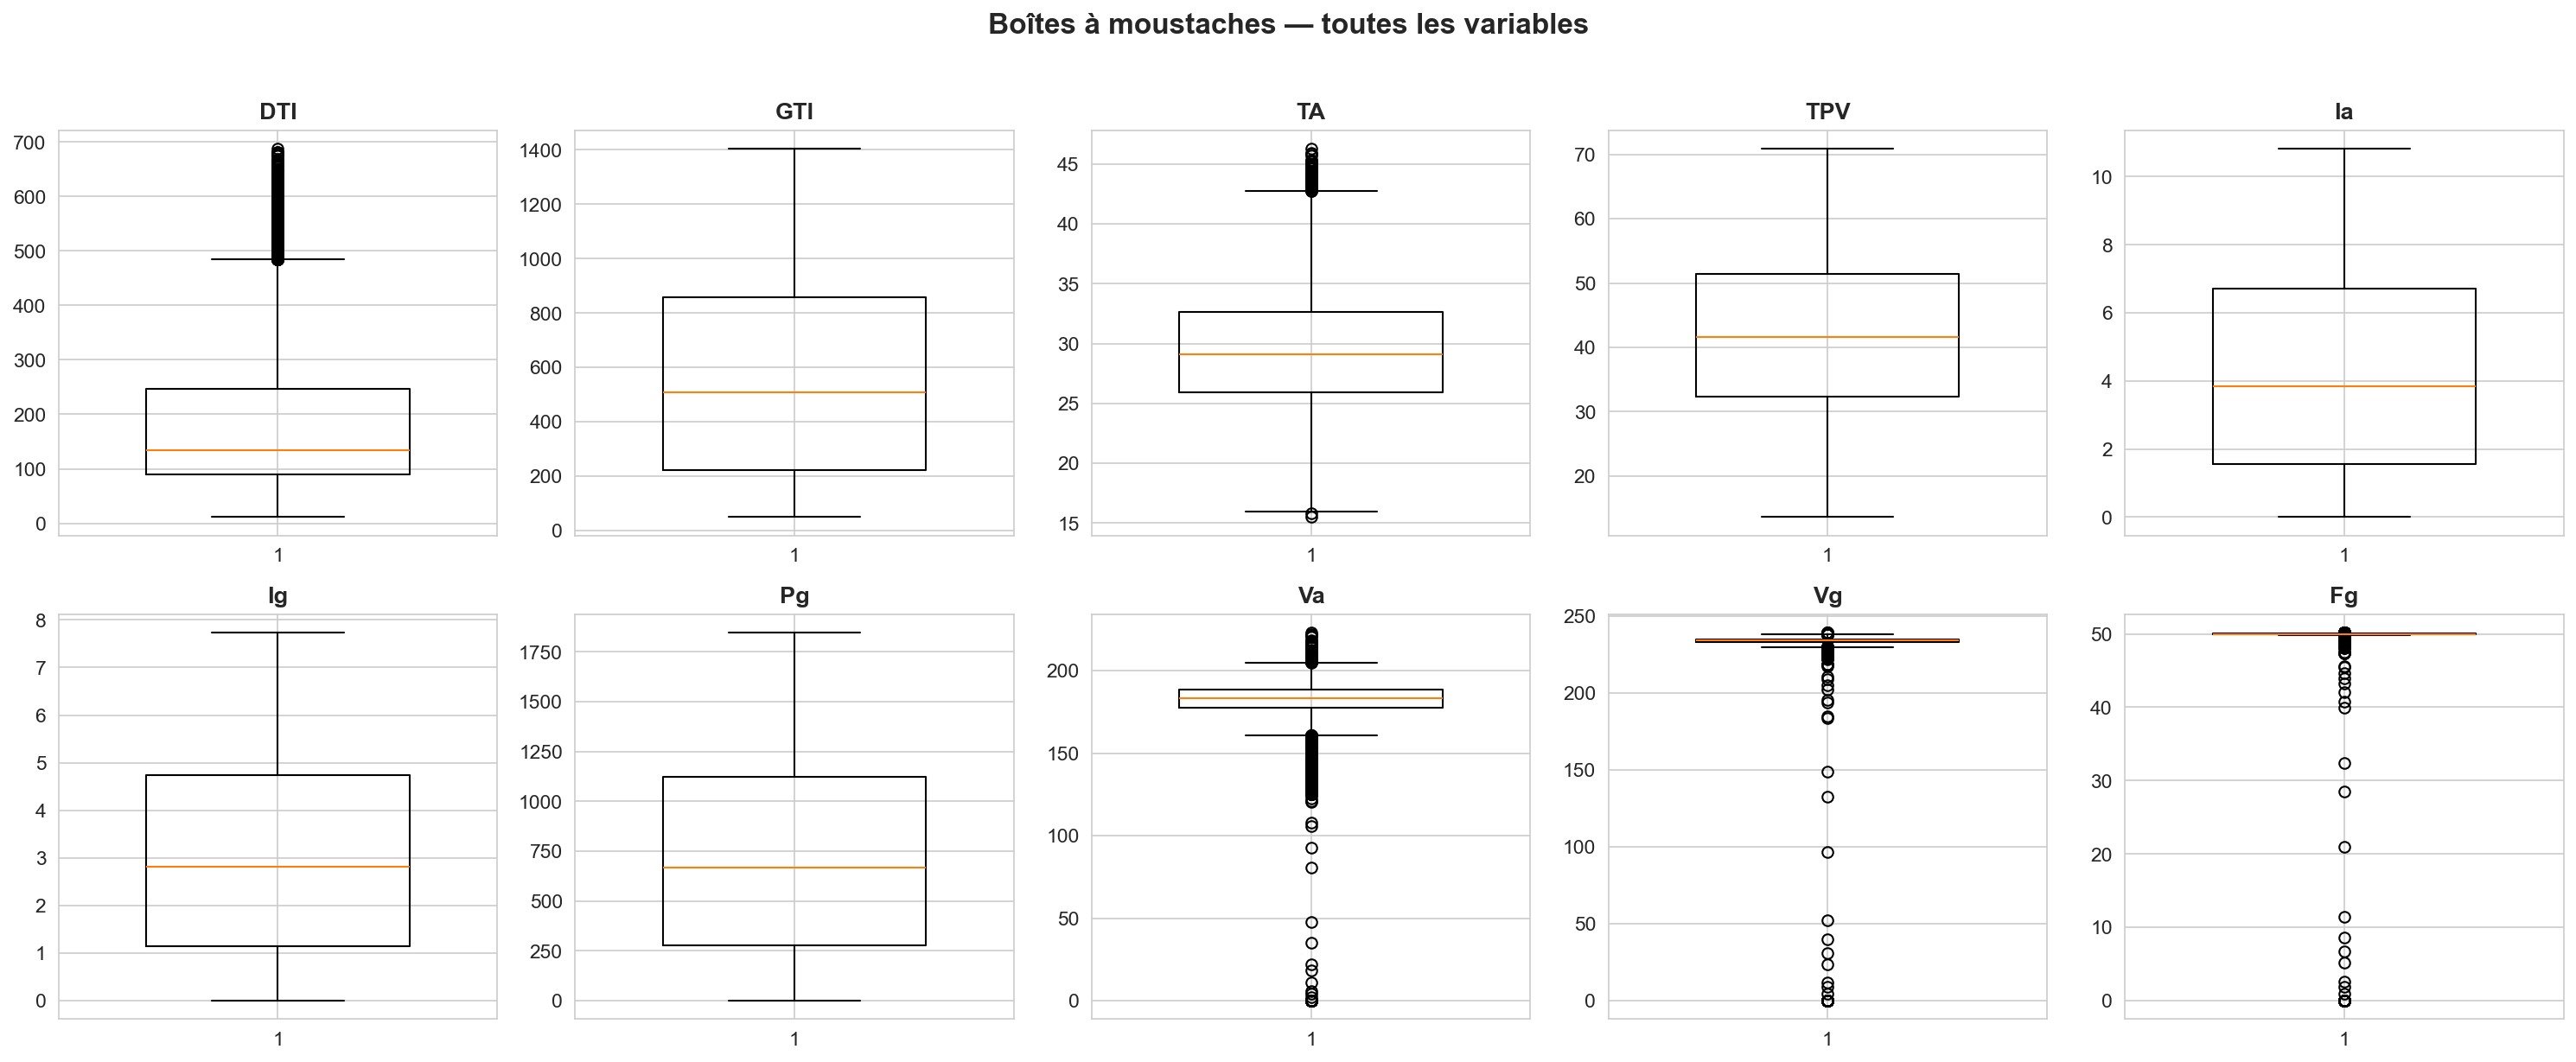

In [8]:
features = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna(), widths=0.6)
    axes[i].set_title(col, fontsize=13, fontweight="bold")
    axes[i].set_xticklabels(["1"])

fig.suptitle("Boîtes à moustaches — toutes les variables", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Vérification physique — Valeurs suspectes

Critères de vérification :
- `Va` ou `Vg` à 0 → capteur déconnecté
- `Pg < 0` → puissance négative (erreur physique)
- `GTI > 1500` → irradiance supérieure au maximum terrestre
- `TPV < 0` → température négative du panneau (suspect en climat tropical)

In [9]:
print("=== Valeurs suspectes ===")
print(f"Va == 0     : {(df['Va'] == 0).sum()} lignes")
print(f"Vg == 0     : {(df['Vg'] == 0).sum()} lignes")
print(f"Pg < 0      : {(df['Pg'] < 0).sum()} lignes")
print(f"GTI > 1500  : {(df['GTI'] > 1500).sum()} lignes")
print(f"TPV < 0     : {(df['TPV'] < 0).sum()} lignes")

=== Valeurs suspectes ===
Va == 0     : 57 lignes
Vg == 0     : 57 lignes
Pg < 0      : 0 lignes
GTI > 1500  : 0 lignes
TPV < 0     : 0 lignes


### 3.3 Détection des outliers — Z-score

Le Z-score mesure la distance de chaque valeur par rapport à la moyenne, en nombre d'écarts-types.
Si Z > 3 ou Z < −3, la valeur est considérée comme un outlier statistique (les ~0.3% les plus extrêmes si la distribution est normale).

In [10]:
z_scores = np.abs(stats.zscore(df[features]))
outliers_z = (z_scores > 3).sum(axis=0)

print("=== Outliers par Z-score (> 3 écarts-types) ===")
for col, count in zip(features, outliers_z):
    pct = count / len(df) * 100
    print(f"  {col:6s} : {count:5d} outliers ({pct:.2f}%)")

=== Outliers par Z-score (> 3 écarts-types) ===
  DTI    :   431 outliers (0.81%)
  GTI    :     0 outliers (0.00%)
  TA     :    53 outliers (0.10%)
  TPV    :     0 outliers (0.00%)
  Ia     :     0 outliers (0.00%)
  Ig     :     0 outliers (0.00%)
  Pg     :     0 outliers (0.00%)
  Va     :   689 outliers (1.30%)
  Vg     :    73 outliers (0.14%)
  Fg     :    73 outliers (0.14%)


### 3.4 Détection des outliers — IQR (méthode des quartiles)

L'IQR est plus robuste que le Z-score pour les distributions asymétriques :
il utilise les quartiles Q1/Q3, insensibles aux valeurs extrêmes.
Un outlier est toute valeur en dehors de [Q1 − 1.5×IQR, Q3 + 1.5×IQR].

In [11]:
print("=== Outliers par IQR ===")
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = n_out / len(df) * 100
    print(f"  {col:6s} : {n_out:5d} outliers ({pct:.2f}%)")

=== Outliers par IQR ===
  DTI    :  1470 outliers (2.77%)
  GTI    :     0 outliers (0.00%)
  TA     :    97 outliers (0.18%)
  TPV    :     0 outliers (0.00%)
  Ia     :     0 outliers (0.00%)
  Ig     :     0 outliers (0.00%)
  Pg     :     0 outliers (0.00%)
  Va     :  1389 outliers (2.62%)
  Vg     :  1438 outliers (2.71%)
  Fg     :  1343 outliers (2.53%)


**Décision de nettoyage :** L'IQR détecte plus d'outliers que le Z-score (attendu pour des distributions asymétriques).
Les outliers de GTI, Pg, Ia, etc. sont conservés car ils pourraient être des anomalies opérationnelles réelles que le modèle doit apprendre à détecter.
Seuls les cas de **capteur déconnecté** (Va = Vg = Fg = 0 simultanément) sont supprimés : ce sont des erreurs de mesure, pas des anomalies PV.

### 3.5 Nettoyage — Suppression des lignes capteur déconnecté

In [12]:
avant = len(df)
df = df[~((df["Va"] == 0) & (df["Vg"] == 0) & (df["Fg"] == 0))]
print(f"Supprimé : {avant - len(df)} lignes (capteur déconnecté : Va=Vg=Fg=0)")
print(f"Restant  : {len(df):,} lignes")

Supprimé : 57 lignes (capteur déconnecté : Va=Vg=Fg=0)


Restant  : 52,959 lignes


### 3.6 Matrice de corrélation — Variables capteurs

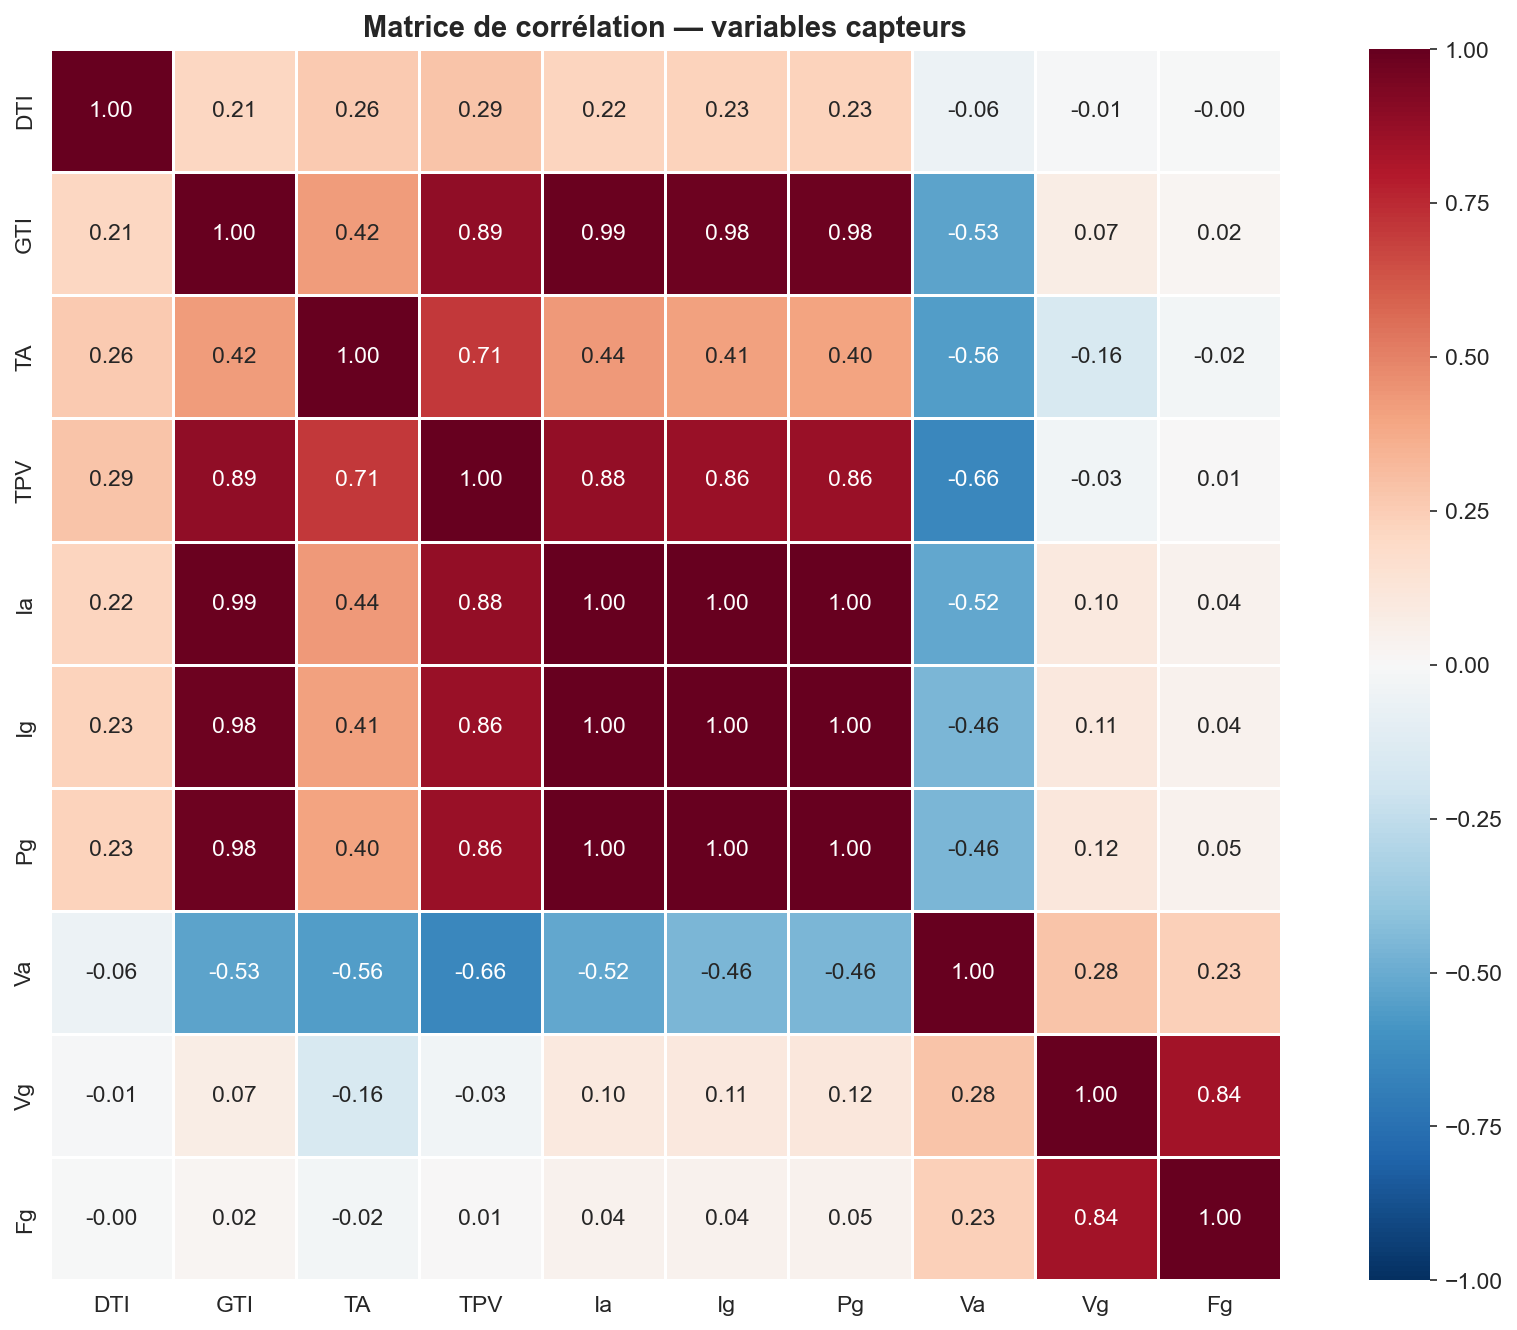

In [13]:
corr = df[features].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matrice de corrélation — variables capteurs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 4. Analyse Exploratoire des Données (EDA)
---

Cette section explore les **données brutes** (capteurs) et la **distribution des anomalies**, *avant* toute création de feature. L'objectif est de comprendre :
- la structure du jeu de données (volume, période, déséquilibre) ;
- la relation physique fondamentale entre irradiance et puissance ;
- **quand** et **comment** les anomalies apparaissent dans le temps.

In [14]:
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Palette
C_NORMAL = "#4682B4"
C_ANO    = "#E9967A"
C_RED    = "#E24B4A"

# =============================================================
# Point d'entrée EDA/Features — auto-suffisant en Run All
# =============================================================
# Notebook issu de la fusion de deux notebooks (nettoyage + features). On
# repart du df DÉJÀ nettoyé en mémoire (§ 3) au lieu de relire
# cleaned_with_features.csv (produit plus loin, § 6) : le relire ici
# réinjecterait les colonnes d'un run précédent (cause du bug 'split').
# Repli fichier si df absent (exécution isolée de la partie features).
#
# Purge des colonnes de travail éventuellement persistées par une exécution
# précédente (split, is_anomaly, incident_group, fgroup). Elles ne doivent
# JAMAIS voyager via le CSV : l'appartenance train/val/test est portée par
# le DataFrame dans lequel une ligne se trouve, pas par une colonne.
_cols_travail = ["split", "is_anomaly", "incident_group", "fgroup"]
if "df" in globals() and isinstance(df, pd.DataFrame) and "Fault" in df.columns:
    print(f"df repris depuis la mémoire (nettoyage amont) : "
          f"{df.shape[0]:,} lignes x {df.shape[1]} colonnes")
else:
    print("df absent — relecture de cleaned_with_features.csv (repli)")
    df = pd.read_csv("data/cleaned_with_features.csv")
    df["time"] = pd.to_datetime(df["time"], utc=True)
    df = df.set_index("time").sort_index()

_present = [c for c in _cols_travail if c in df.columns]
if _present:
    print(f"Colonnes de travail purgées : {_present}")
    df = df.drop(columns=_present)

# Capteurs bruts uniquement (on ignore les features dérivées ici)
CAPTEURS = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Eg", "Fg", "Pg", "Va", "Vg"]
CAPTEURS = [c for c in CAPTEURS if c in df.columns]

print(f"Dataset : {df.shape[0]:,} lignes × {len(CAPTEURS)} capteurs")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"Anomalies : {(df['Fault'] != 0).sum():,} ({100*(df['Fault']!=0).mean():.1f}%)")

df repris depuis la mémoire (nettoyage amont) : 52,959 lignes x 12 colonnes
Dataset : 52,959 lignes × 11 capteurs
Période : 2021-10-28 → 2023-04-13
Anomalies : 1,494 (2.8%)


                 Type  Nombre  Pourcentage
               Normal   51465        97.18
F1 (ombrage uniforme)      51         0.10
                 F2.1      36         0.07
                 F2.2      41         0.08
                 F2.3      55         0.10
                 F3.1      73         0.14
                 F3.2     114         0.22
    F4 (intermittent)    1124         2.12


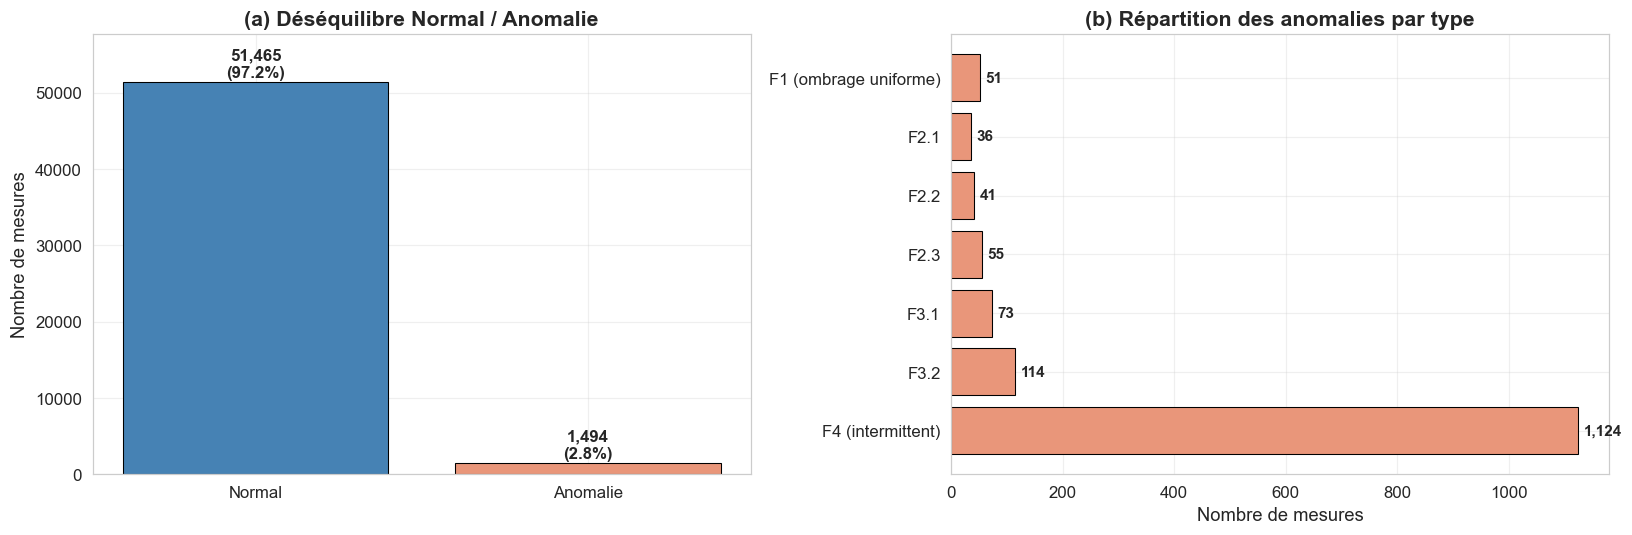


Constat : Fault 4.0 (ombrage intermittent) domine les anomalies (1124 pts),
les autres types sont rares (36-114 pts). Fort déséquilibre global (~2.8% d'anomalies).


In [15]:
# Table de fréquence par type de panne
LABELS = {0.0: "Normal", 1.0: "F1 (ombrage uniforme)",
          2.1: "F2.1", 2.2: "F2.2", 2.3: "F2.3",
          3.1: "F3.1", 3.2: "F3.2", 4.0: "F4 (intermittent)"}

counts = df["Fault"].value_counts().sort_index()
tab = pd.DataFrame({
    "Type": [LABELS.get(f, f"F{f}") for f in counts.index],
    "Nombre": counts.values,
    "Pourcentage": (100 * counts.values / len(df)).round(2),
})
print(tab.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Normal vs Anomalie (barres) — plus lisible qu'un donut surchargé
n_norm = (df["Fault"] == 0).sum()
n_ano  = (df["Fault"] != 0).sum()
bars = axes[0].bar(["Normal", "Anomalie"], [n_norm, n_ano],
                   color=[C_NORMAL, C_ANO], edgecolor="black", linewidth=0.7)
for b, v in zip(bars, [n_norm, n_ano]):
    axes[0].text(b.get_x()+b.get_width()/2, v+600, f"{v:,}\n({100*v/len(df):.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Nombre de mesures")
axes[0].set_title("(a) Déséquilibre Normal / Anomalie", fontweight="bold")
axes[0].set_ylim(0, n_norm*1.12)

# (b) Répartition des anomalies par type (barres horizontales, hors normal)
ano_counts = counts[counts.index != 0]
labels_ano = [LABELS.get(f, f"F{f}") for f in ano_counts.index]
axes[1].barh(labels_ano, ano_counts.values, color=C_ANO, edgecolor="black", linewidth=0.7)
for i, v in enumerate(ano_counts.values):
    axes[1].text(v+10, i, f"{v:,}", va="center", fontsize=10, fontweight="bold")
axes[1].set_xlabel("Nombre de mesures")
axes[1].set_title("(b) Répartition des anomalies par type", fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("figures/eda_01_desequilibre.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nConstat : Fault 4.0 (ombrage intermittent) domine les anomalies (1124 pts),")
print("les autres types sont rares (36-114 pts). Fort déséquilibre global (~2.8% d'anomalies).")

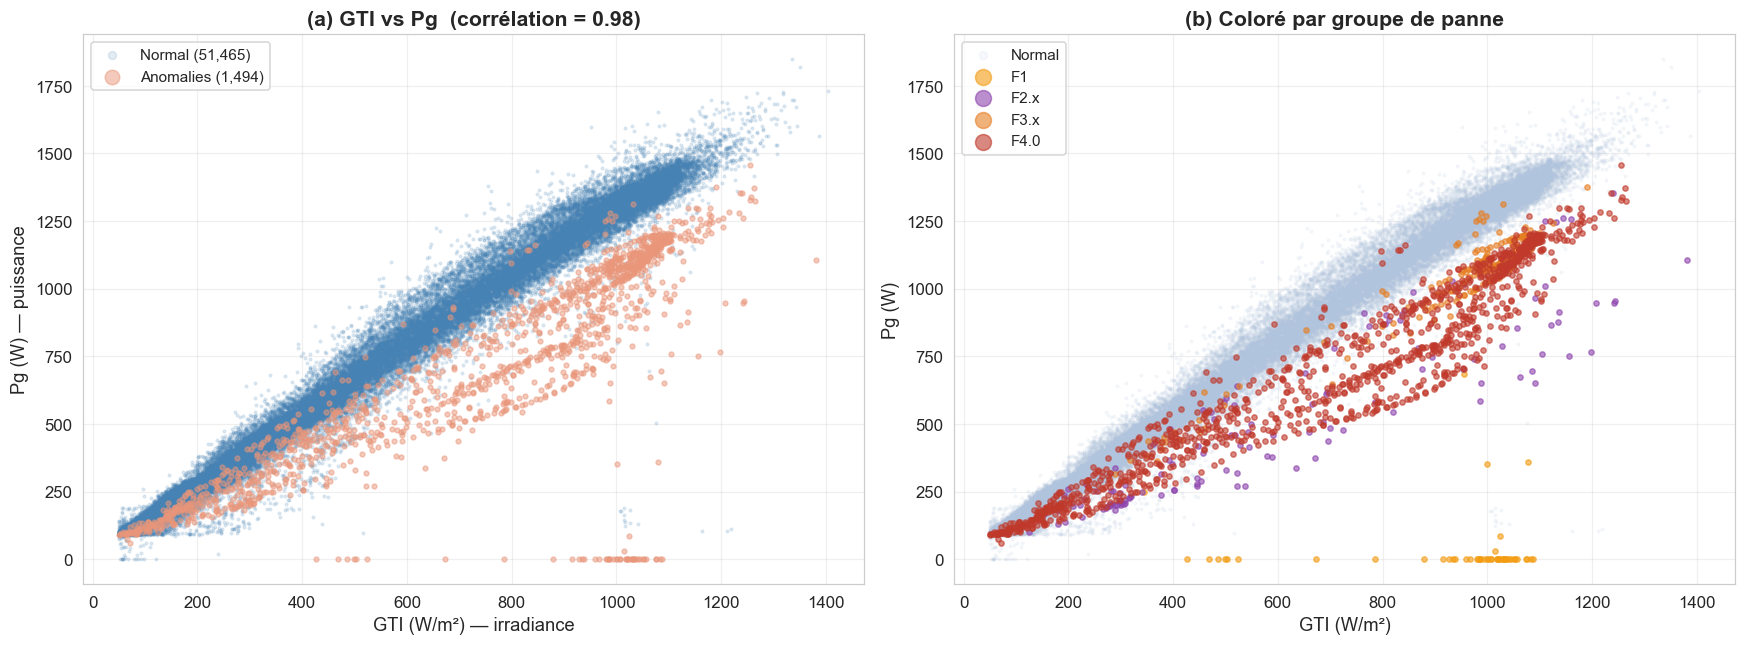

Constat : Pg et GTI sont corrélés à 0.98 (relation quasi-linéaire).
Les anomalies (orange) forment un NUAGE SOUS la droite normale : à irradiance
égale, un panneau en panne produit moins. → motive une feature de RENDEMENT Pg/GTI.


In [16]:
normal = df[df["Fault"] == 0]
anomalies = df[df["Fault"] != 0]
corr_pg_gti = df["Pg"].corr(df["GTI"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Normal vs anomalies
axes[0].scatter(normal["GTI"], normal["Pg"], s=3, alpha=0.15, c=C_NORMAL,
                label=f"Normal ({len(normal):,})")
axes[0].scatter(anomalies["GTI"], anomalies["Pg"], s=10, alpha=0.5, c=C_ANO,
                label=f"Anomalies ({len(anomalies):,})")
axes[0].set_xlabel("GTI (W/m²) — irradiance"); axes[0].set_ylabel("Pg (W) — puissance")
axes[0].set_title(f"(a) GTI vs Pg  (corrélation = {corr_pg_gti:.2f})", fontweight="bold")
axes[0].legend(markerscale=3)

# (b) Coloré par groupe de panne
df["fgroup"] = df["Fault"].apply(lambda x: 0 if x == 0 else int(x))
cmap = {0:"#B0C4DE", 1:"#F39C12", 2:"#8E44AD", 3:"#E67E22", 4:"#C0392B"}
lbl  = {0:"Normal", 1:"F1", 2:"F2.x", 3:"F3.x", 4:"F4.0"}
for g in [0, 1, 2, 3, 4]:
    sub = df[df["fgroup"] == g]
    axes[1].scatter(sub["GTI"], sub["Pg"], s=3 if g==0 else 12,
                    alpha=0.1 if g==0 else 0.6, c=cmap[g], label=lbl[g])
axes[1].set_xlabel("GTI (W/m²)"); axes[1].set_ylabel("Pg (W)")
axes[1].set_title("(b) Coloré par groupe de panne", fontweight="bold")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.savefig("figures/eda_02_gti_pg.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Constat : Pg et GTI sont corrélés à {corr_pg_gti:.2f} (relation quasi-linéaire).")
print("Les anomalies (orange) forment un NUAGE SOUS la droite normale : à irradiance")
print("égale, un panneau en panne produit moins. → motive une feature de RENDEMENT Pg/GTI.")

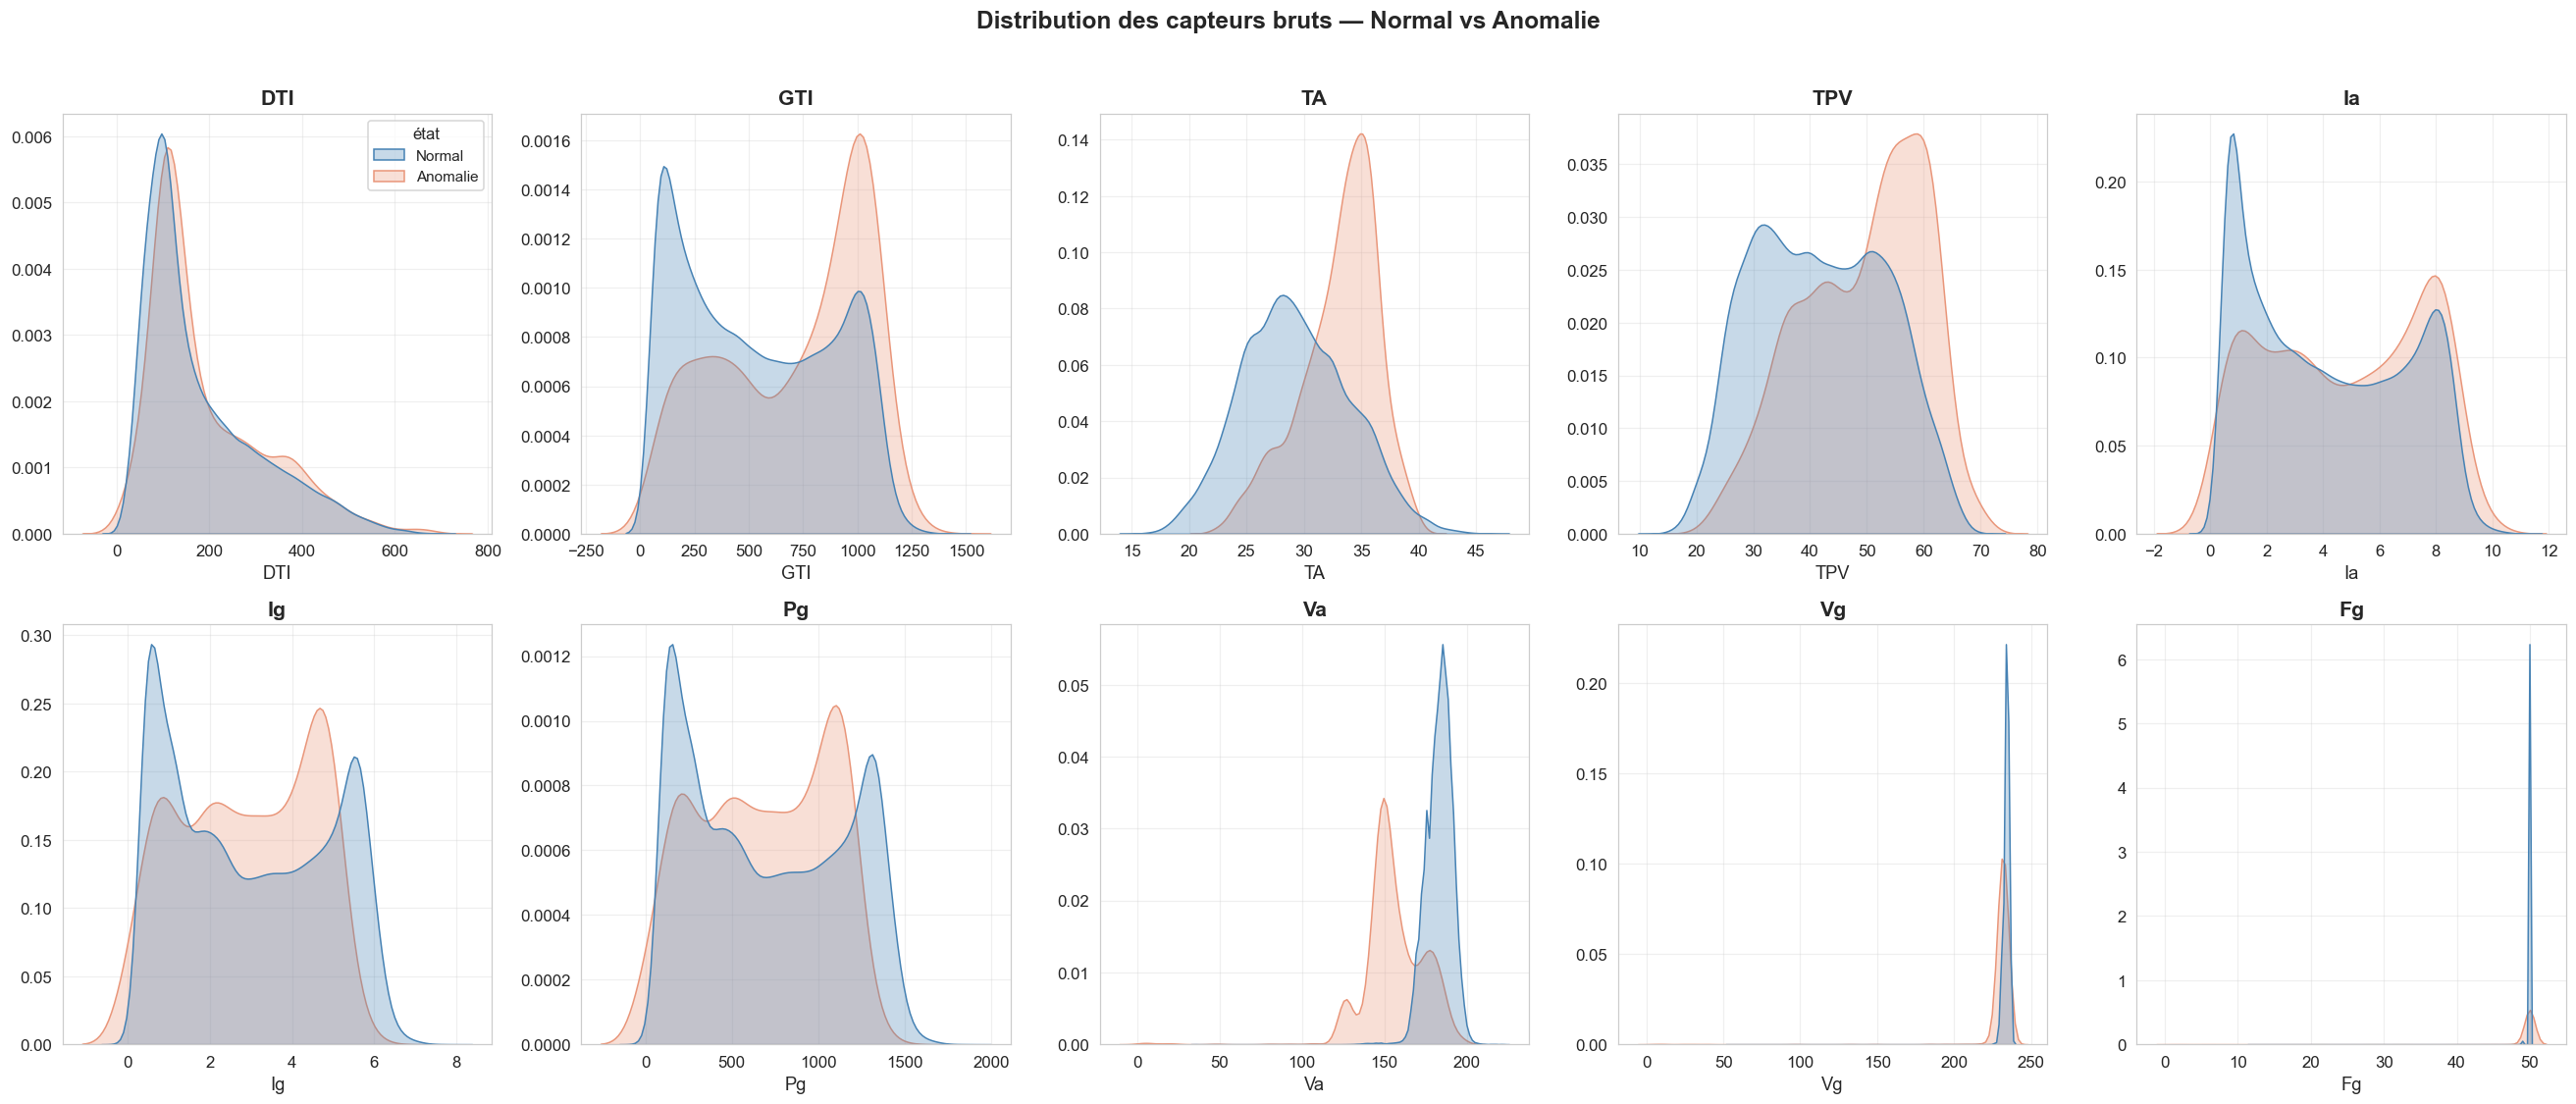

Constat : Va (tension AC) et les courants Ia/Ig montrent un décalage visible
entre normal et anomalie — indices pour le feature engineering (déviation de tension).


In [17]:
PALETTE_BINARY = {"Normal": C_NORMAL, "Anomalie": C_ANO}
HUE_ORDER = ["Normal", "Anomalie"]
CAPS_KDE = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]

# Frame de tracé temporaire — on ne touche PAS à df (voir note ci-dessous)
df_plot = df[CAPS_KDE].copy()
df_plot["état"] = np.where(df["Fault"] != 0, "Anomalie", "Normal")

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(CAPS_KDE):
    sns.kdeplot(data=df_plot, x=col, hue="état",
                hue_order=HUE_ORDER, palette=PALETTE_BINARY,
                fill=True, alpha=0.3, ax=axes[i],
                common_norm=False, warn_singular=False, gridsize=120)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("")
    if i > 0 and axes[i].get_legend() is not None:
        axes[i].get_legend().remove()   # une seule légende au lieu de dix

fig.suptitle("Distribution des capteurs bruts — Normal vs Anomalie",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/eda_03_distributions_capteurs.png", dpi=150, bbox_inches="tight")
plt.show()

print("Constat : Va (tension AC) et les courants Ia/Ig montrent un décalage visible")
print("entre normal et anomalie — indices pour le feature engineering (déviation de tension).")

del df_plot

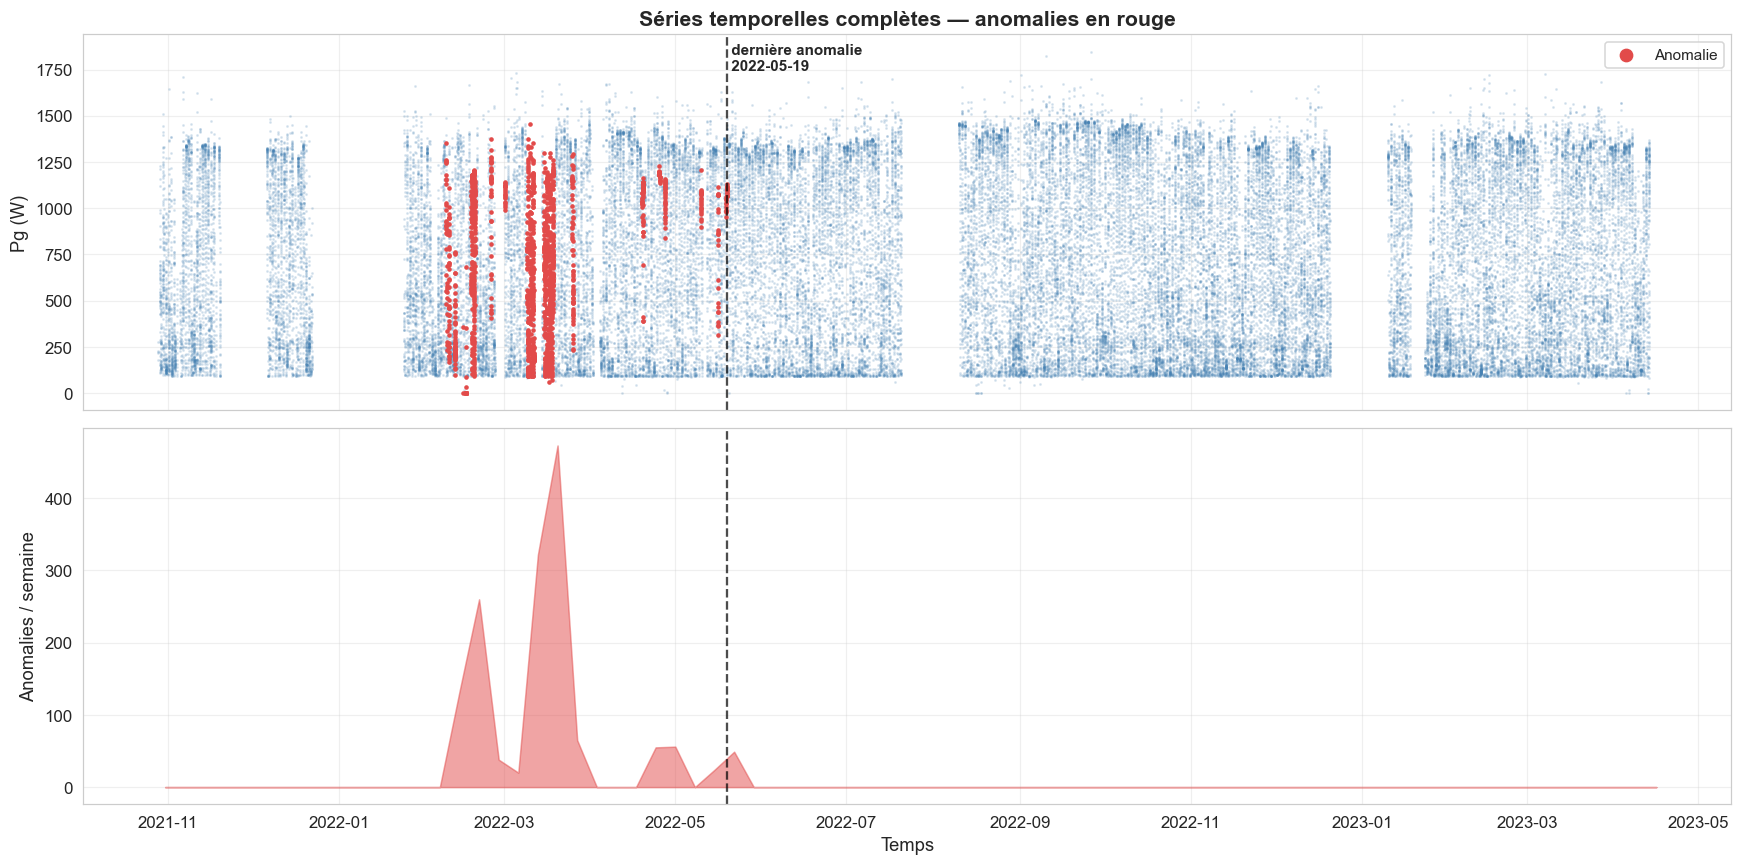

Constat CLÉ : dernière anomalie le 2022-05-19, mais le dataset va jusqu'au
2023-04-13. Soit 35,684 lignes (67%) de normal pur après.
→ Il faut restreindre l'étude à la période contenant des anomalies (df_etude),
  sinon un split naïf placerait tout le test dans la zone sans panne (test vide).


In [18]:
ano = df[df["Fault"] != 0]
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Pg dans le temps, anomalies en rouge
axes[0].scatter(df.index, df["Pg"], s=1, alpha=0.15, c=C_NORMAL)
axes[0].scatter(ano.index, ano["Pg"], s=4, c=C_RED, label="Anomalie")
axes[0].set_ylabel("Pg (W)"); axes[0].legend(markerscale=4)
axes[0].set_title("Séries temporelles complètes — anomalies en rouge", fontweight="bold")

# Densité d'anomalies par semaine
ano_hebdo = (df["Fault"] != 0).resample("W").sum()
axes[1].fill_between(ano_hebdo.index, ano_hebdo.values, color=C_RED, alpha=0.5)
axes[1].set_ylabel("Anomalies / semaine"); axes[1].set_xlabel("Temps")

# Marquer la fin de la période d'anomalies
fin_ano = ano.index.max()
for ax in axes:
    ax.axvline(fin_ano, color="black", ls="--", lw=1.5, alpha=0.7)
axes[0].text(fin_ano, axes[0].get_ylim()[1]*0.9, f" dernière anomalie\n {fin_ano.date()}",
             fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_05_anomalies_temps.png", dpi=150, bbox_inches="tight")
plt.show()

n_apres = len(df[df.index > fin_ano])
print(f"Constat CLÉ : dernière anomalie le {fin_ano.date()}, mais le dataset va jusqu'au")
print(f"{df.index.max().date()}. Soit {n_apres:,} lignes ({100*n_apres/len(df):.0f}%) de normal pur après.")
print("→ Il faut restreindre l'étude à la période contenant des anomalies (df_etude),")
print("  sinon un split naïf placerait tout le test dans la zone sans panne (test vide).")

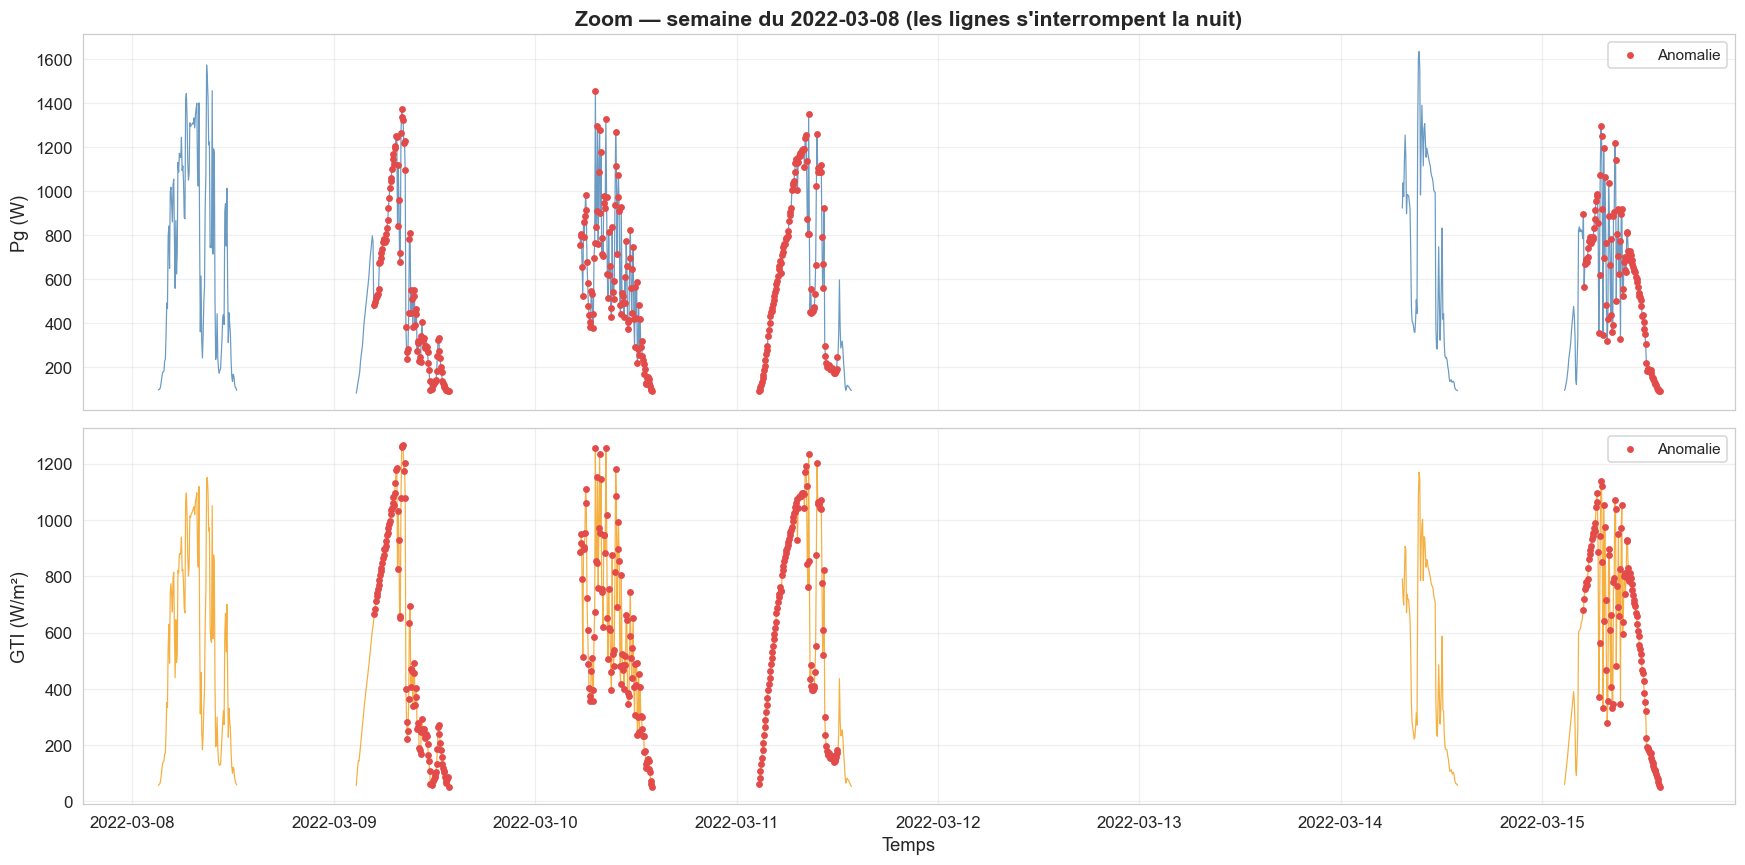

Constat : cycle jour/nuit marqué ; les mesures nocturnes sont absentes (GTI>50).
Les anomalies (rouge) surviennent en journée, souvent en cloche autour de midi.
→ Les séquences temporelles (LSTM) ne devront pas enjamber les nuits.


In [19]:
sem = df["2022-03-08":"2022-03-15"].copy()
# Réindexer sur grille 5 min pour NE PAS relier à travers les nuits
sem_g = sem.asfreq("5min")
ano_sem = sem[sem["Fault"] != 0]

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, (col, ylab, coul) in zip(axes, [("Pg", "Pg (W)", C_NORMAL), ("GTI", "GTI (W/m²)", "#F39C12")]):
    ax.plot(sem_g.index, sem_g[col], "-", color=coul, lw=0.8, alpha=0.8)
    ax.scatter(ano_sem.index, ano_sem[col], s=12, c=C_RED, zorder=3, label="Anomalie")
    ax.set_ylabel(ylab); ax.legend()
axes[0].set_title("Zoom — semaine du 2022-03-08 (les lignes s'interrompent la nuit)", fontweight="bold")
axes[-1].set_xlabel("Temps")
plt.tight_layout()
plt.savefig("figures/eda_06_zoom_semaine.png", dpi=150, bbox_inches="tight")
plt.show()

print("Constat : cycle jour/nuit marqué ; les mesures nocturnes sont absentes (GTI>50).")
print("Les anomalies (rouge) surviennent en journée, souvent en cloche autour de midi.")
print("→ Les séquences temporelles (LSTM) ne devront pas enjamber les nuits.")

C:\Users\PC\AppData\Local\Temp\ipykernel_28996\3526659245.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ano["mois"]  = ano.index.to_period("M").astype(str)


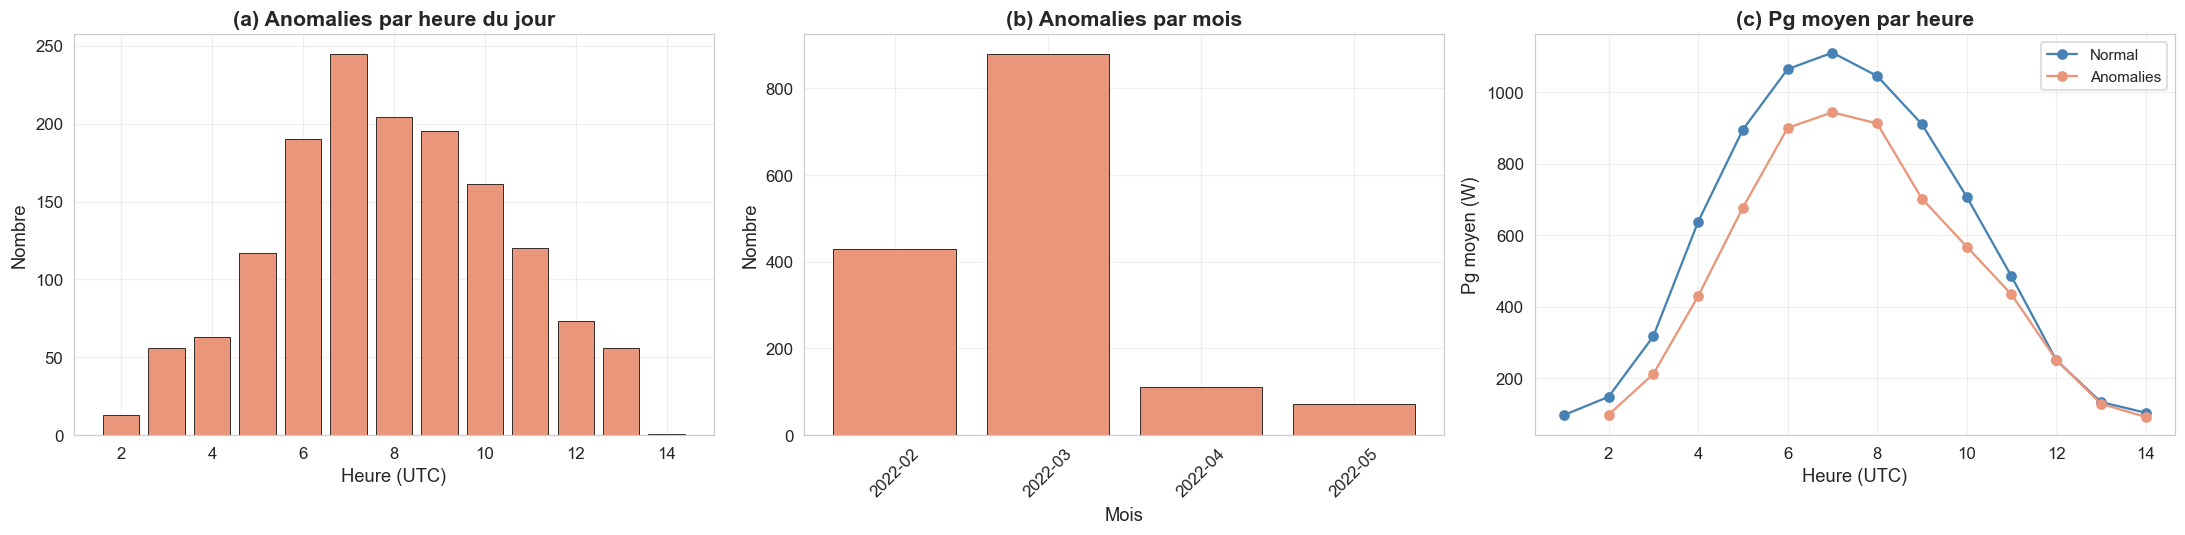

Constat : anomalies concentrées en journée (pic vers 7h UTC) et sur février-mai 2022
(surtout mars). À chaque heure, la Pg des anomalies est SOUS celle du normal :
le déficit de production est constant, ce qui confirme l'intérêt d'un rendement normalisé.


In [20]:
ano = df[df["Fault"] != 0].copy()
ano["heure"] = ano.index.hour
ano["mois"]  = ano.index.to_period("M").astype(str)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# (a) par heure
h = ano["heure"].value_counts().sort_index()
axes[0].bar(h.index, h.values, color=C_ANO, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Heure (UTC)"); axes[0].set_ylabel("Nombre")
axes[0].set_title("(a) Anomalies par heure du jour", fontweight="bold")

# (b) par mois
m = ano["mois"].value_counts().sort_index()
axes[1].bar(range(len(m)), m.values, color=C_ANO, edgecolor="black", linewidth=0.5)
axes[1].set_xticks(range(len(m))); axes[1].set_xticklabels(m.index, rotation=45)
axes[1].set_xlabel("Mois"); axes[1].set_ylabel("Nombre")
axes[1].set_title("(b) Anomalies par mois", fontweight="bold")

# (c) Pg moyen par heure : normal vs anomalie
prof_n = df[df["Fault"]==0].groupby(df[df["Fault"]==0].index.hour)["Pg"].mean()
prof_a = ano.groupby("heure")["Pg"].mean()
axes[2].plot(prof_n.index, prof_n.values, "o-", color=C_NORMAL, label="Normal")
axes[2].plot(prof_a.index, prof_a.values, "o-", color=C_ANO, label="Anomalies")
axes[2].set_xlabel("Heure (UTC)"); axes[2].set_ylabel("Pg moyen (W)")
axes[2].set_title("(c) Pg moyen par heure", fontweight="bold"); axes[2].legend()

plt.tight_layout()
plt.savefig("figures/eda_07_profils.png", dpi=150, bbox_inches="tight")
plt.show()

print("Constat : anomalies concentrées en journée (pic vers 7h UTC) et sur février-mai 2022")
print("(surtout mars). À chaque heure, la Pg des anomalies est SOUS celle du normal :")
print("le déficit de production est constant, ce qui confirme l'intérêt d'un rendement normalisé.")

### 4.8 Synthèse de l'EDA → transition vers le Feature Engineering

L'exploration des données brutes révèle plusieurs constats qui **motivent directement** les features à créer :

| Constat EDA (données brutes) | Feature dérivée motivée |
|---|---|
| Pg ∝ GTI ; les anomalies produisent moins à irradiance égale | **ratio Pg/GTI** (rendement normalisé par le soleil) |
| Le déficit de production est visible mais dépend du soleil | **pg_residual** (écart à la production attendue) |
| Va (tension AC) décalée entre normal et anomalie | **va_deviation** (déviation de tension) |
| Va anti-corrélée au soleil, Vg au réseau | **vg_va_ratio** (déséquilibre de tension) |
| Anomalies concentrées fév–mai 2022, rien après | restriction à la **période d'étude** (df_etude) |
| Trous nocturnes (GTI>50) | séquences LSTM **respectant les journées** |
| Fort déséquilibre (~2.8% d'anomalies) | métrique **PR-AUC**, approche **non supervisée** |

La section suivante construit et valide ces features.

> **Note.** Ce tableau motive les features *candidates* à partir des constats de l'EDA. La sélection **définitive** (quelles features sont réellement conservées) est décidée plus loin par les tests KS (6.1bis, 6.2.2) et l'ablation quantitative (6.2.8), pas par cette table.

---
## 5. Période d'étude et split chronologique
---

### 5.1 — Où se trouvent les pannes dans la série ?

In [21]:
anomalies_all = df[df["Fault"] != 0]

print(f"Période couverte  : {df.index.min().date()} → {df.index.max().date()}")
print(f"Première anomalie : {anomalies_all.index.min().date()}")
print(f"Dernière anomalie : {anomalies_all.index.max().date()}")

pos_derniere = df.index.get_indexer([anomalies_all.index.max()])[0] / len(df)
print(f"\nLa dernière anomalie se situe à {pos_derniere:.1%} de la série.")

print("\n=== Anomalies par mois ===")
par_mois = anomalies_all.groupby(anomalies_all.index.tz_localize(None).to_period("M")).size()
print(par_mois.to_string())

Période couverte  : 2021-10-28 → 2023-04-13
Première anomalie : 2022-02-08
Dernière anomalie : 2022-05-19

La dernière anomalie se situe à 32.6% de la série.

=== Anomalies par mois ===
time
2022-02    430
2022-03    880
2022-04    111
2022-05     73
Freq: M


**Constat.** Les pannes se concentrent sur une fenêtre de trois mois en début de série ; les onze mois suivants n'en comportent aucune.

Un découpage 70/10/20 sur la série entière placerait donc toutes les anomalies dans le train, laissant `val` et `test` sans un seul positif — aucune métrique de détection ne serait calculable.

**Décision.** L'étude est restreinte à la période allant du début de la série jusqu'à peu après la dernière anomalie. Cette troncature garantit que chaque partition contient des pannes, tout en préservant l'ordre chronologique.

In [22]:
# Horizon serré : la troncature s'arrête peu après la dernière anomalie,
# sinon la queue sans panne accapare le test.
MARGE = pd.Timedelta(days=7)
fin_etude = anomalies_all.index.max() + MARGE

df_etude = df.loc[:fin_etude].copy()

print(f"Période d'étude : {df_etude.index.min().date()} → {df_etude.index.max().date()}")
print(f"Volume          : {len(df_etude):,} lignes sur {len(df):,} ({100*len(df_etude)/len(df):.1f}%)")
print(f"Anomalies       : {(df_etude['Fault'] != 0).sum():,}")

df_hors_etude = df.loc[fin_etude:].copy()
print(f"\nHors période d'étude : {len(df_hors_etude):,} lignes, "
      f"{(df_hors_etude['Fault'] != 0).sum()} anomalie(s)")

Période d'étude : 2021-10-28 → 2022-05-26
Volume          : 18,057 lignes sur 52,959 (34.1%)
Anomalies       : 1,494

Hors période d'étude : 34,903 lignes, 0 anomalie(s)


### 5.2 — Identification des incidents (blocs contigus d'anomalie)

In [23]:
# Identifier les incidents
df_etude['is_anomaly'] = df_etude['Fault'] != 0
df_etude['incident_group'] = (df_etude['is_anomaly'] != df_etude['is_anomaly'].shift()).cumsum()

# Extraire les incidents
incidents_list = []
for group_id, group_data in df_etude[df_etude['is_anomaly']].groupby('incident_group'):
    fault_type = group_data['Fault'].iloc[0]
    start_time = group_data.index[0]
    end_time   = group_data.index[-1]
    count      = len(group_data)

    incidents_list.append({
        'fault': fault_type,
        'start_time': start_time,
        'end_time': end_time,
        'count': count,
        'duration_hours': (end_time - start_time).total_seconds() / 3600
    })

incidents_df = pd.DataFrame(incidents_list)

print(f"\n{len(incidents_df)} incidents identifiés\n")
print("Incidents trouvés:")
for i, (idx, inc) in enumerate(incidents_df.iterrows(), 1):
    print(f"  {i:2d}. Fault {inc['fault']:3.1f} | {inc['count']:4d} obs | {inc['start_time']} → {inc['end_time']} ({inc['duration_hours']:.1f}h)")


17 incidents identifiés

Incidents trouvés:
   1. Fault 2.1 |   36 obs | 2022-02-08 07:10:00+00:00 → 2022-02-08 10:05:00+00:00 (2.9h)
   2. Fault 2.2 |   41 obs | 2022-02-09 07:00:00+00:00 → 2022-02-09 10:20:00+00:00 (3.3h)
   3. Fault 2.3 |   55 obs | 2022-02-11 07:05:00+00:00 → 2022-02-11 11:35:00+00:00 (4.5h)
   4. Fault 1.0 |    2 obs | 2022-02-14 07:30:00+00:00 → 2022-02-14 07:35:00+00:00 (0.1h)
   5. Fault 1.0 |   49 obs | 2022-02-15 06:50:00+00:00 → 2022-02-15 11:30:00+00:00 (4.7h)
   6. Fault 4.0 |  209 obs | 2022-02-17 05:20:00+00:00 → 2022-02-18 11:45:00+00:00 (30.4h)
   7. Fault 3.2 |   38 obs | 2022-02-24 06:35:00+00:00 → 2022-02-24 09:40:00+00:00 (3.1h)
   8. Fault 3.2 |   20 obs | 2022-03-01 06:00:00+00:00 → 2022-03-01 07:35:00+00:00 (1.6h)
   9. Fault 4.0 |  322 obs | 2022-03-09 04:50:00+00:00 → 2022-03-11 12:00:00+00:00 (55.2h)
  10. Fault 4.0 |  473 obs | 2022-03-15 04:55:00+00:00 → 2022-03-18 11:45:00+00:00 (78.8h)
  11. Fault 4.0 |   65 obs | 2022-03-25 06:20:00+00:

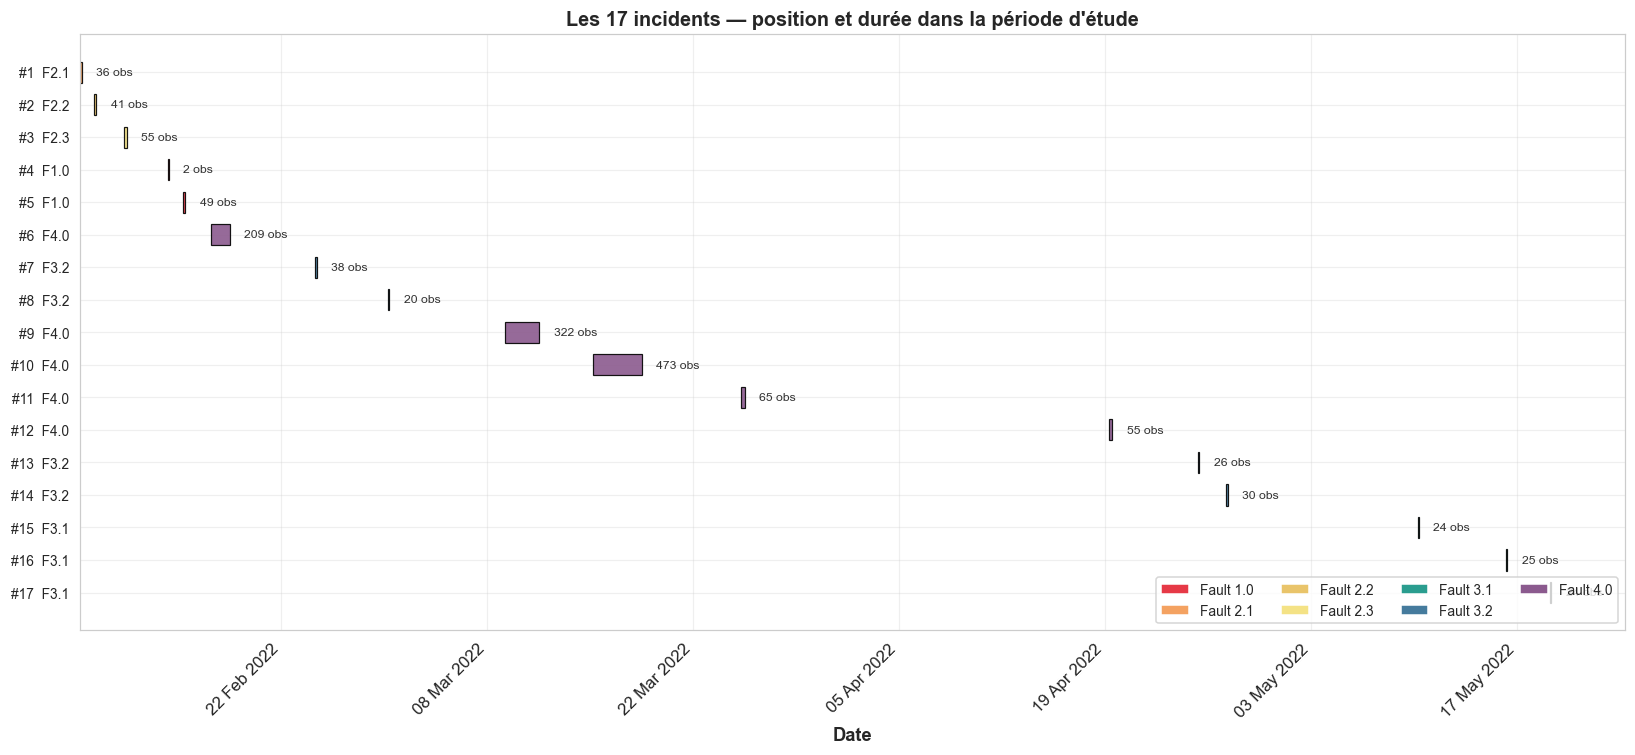

In [24]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

fault_colors = {
    1.0: '#E63946', 2.1: '#F4A261', 2.2: '#E9C46A', 2.3: '#F4E285',
    3.1: '#2A9D8F', 3.2: '#457B9D', 4.0: '#8B5A8E'
}

fig, ax = plt.subplots(figsize=(15, 7))

for i, inc in incidents_df.iterrows():
    start_num = mdates.date2num(inc['start_time'])
    end_num   = mdates.date2num(inc['end_time'])
    width     = max(end_num - start_num, 0.05)   # min 0.05 jour pour rester visible

    ax.barh(i, width, left=start_num, height=0.65,
            color=fault_colors.get(inc['fault'], 'gray'),
            edgecolor='black', linewidth=0.8, alpha=0.9)

    ax.text(end_num + 1, i, f"{inc['count']} obs",
            va='center', fontsize=8, color='#333')

ax.set_yticks(range(len(incidents_df)))
ax.set_yticklabels([f"#{i+1}  F{r['fault']}" for i, r in incidents_df.iterrows()], fontsize=9)
ax.invert_yaxis()
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Date", fontweight='bold')
ax.set_title(f"Les {len(incidents_df)} incidents — position et durée dans la période d'étude",
             fontweight='bold', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)

ax.legend(handles=[Patch(facecolor=fault_colors[f], label=f"Fault {f}")
                   for f in sorted(incidents_df['fault'].unique())],
          loc='lower right', ncol=4, fontsize=9)

plt.tight_layout()
plt.show()

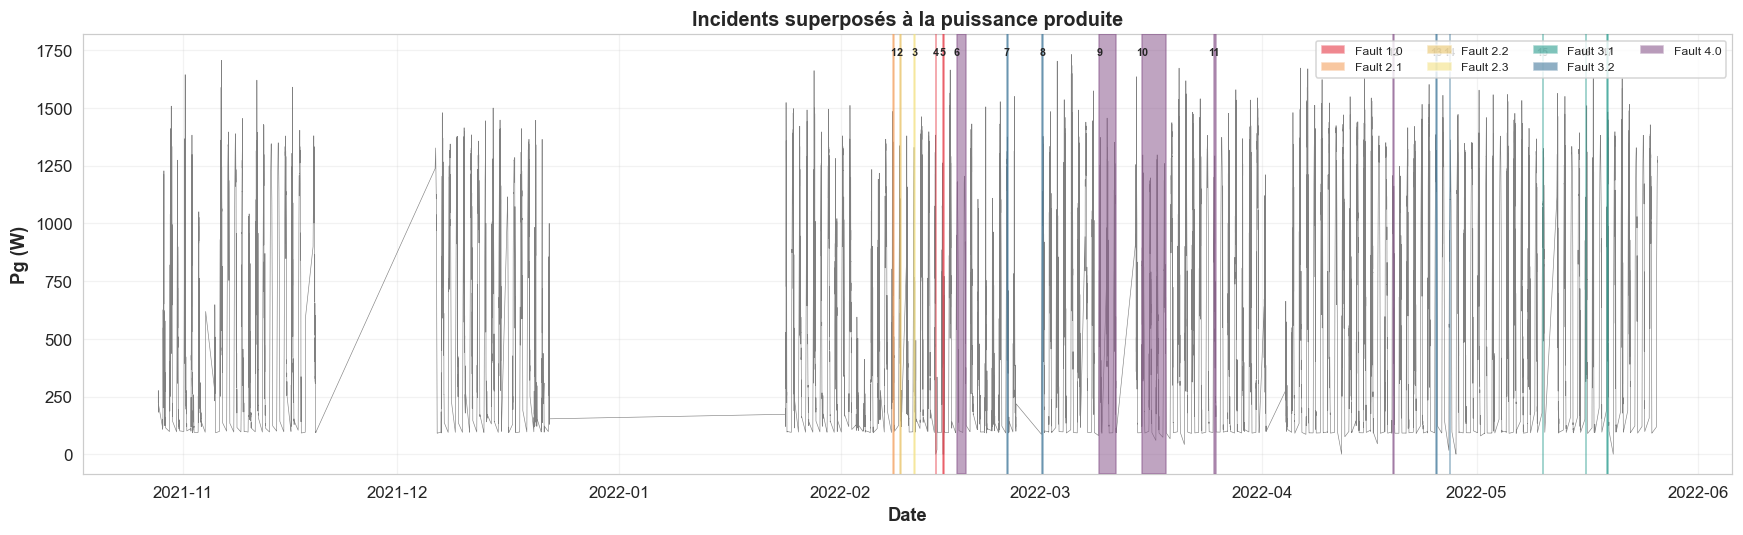

In [25]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_etude.index, df_etude['Pg'], color='#4A4A4A', linewidth=0.4, alpha=0.7, label='Pg')

for i, inc in incidents_df.iterrows():
    ax.axvspan(inc['start_time'], inc['end_time'],
               color=fault_colors.get(inc['fault'], 'gray'), alpha=0.55, zorder=3)
    ax.text(inc['start_time'], ax.get_ylim()[1]*0.97, str(i+1),
            fontsize=7, ha='center', va='top', fontweight='bold')

ax.set_ylabel("Pg (W)", fontweight='bold')
ax.set_xlabel("Date", fontweight='bold')
ax.set_title("Incidents superposés à la puissance produite", fontweight='bold', fontsize=13)
ax.grid(True, alpha=0.25)
ax.legend(handles=[Patch(facecolor=fault_colors[f], alpha=0.6, label=f"Fault {f}")
                   for f in sorted(incidents_df['fault'].unique())],
          loc='upper right', ncol=4, fontsize=8)

plt.tight_layout()
plt.show()

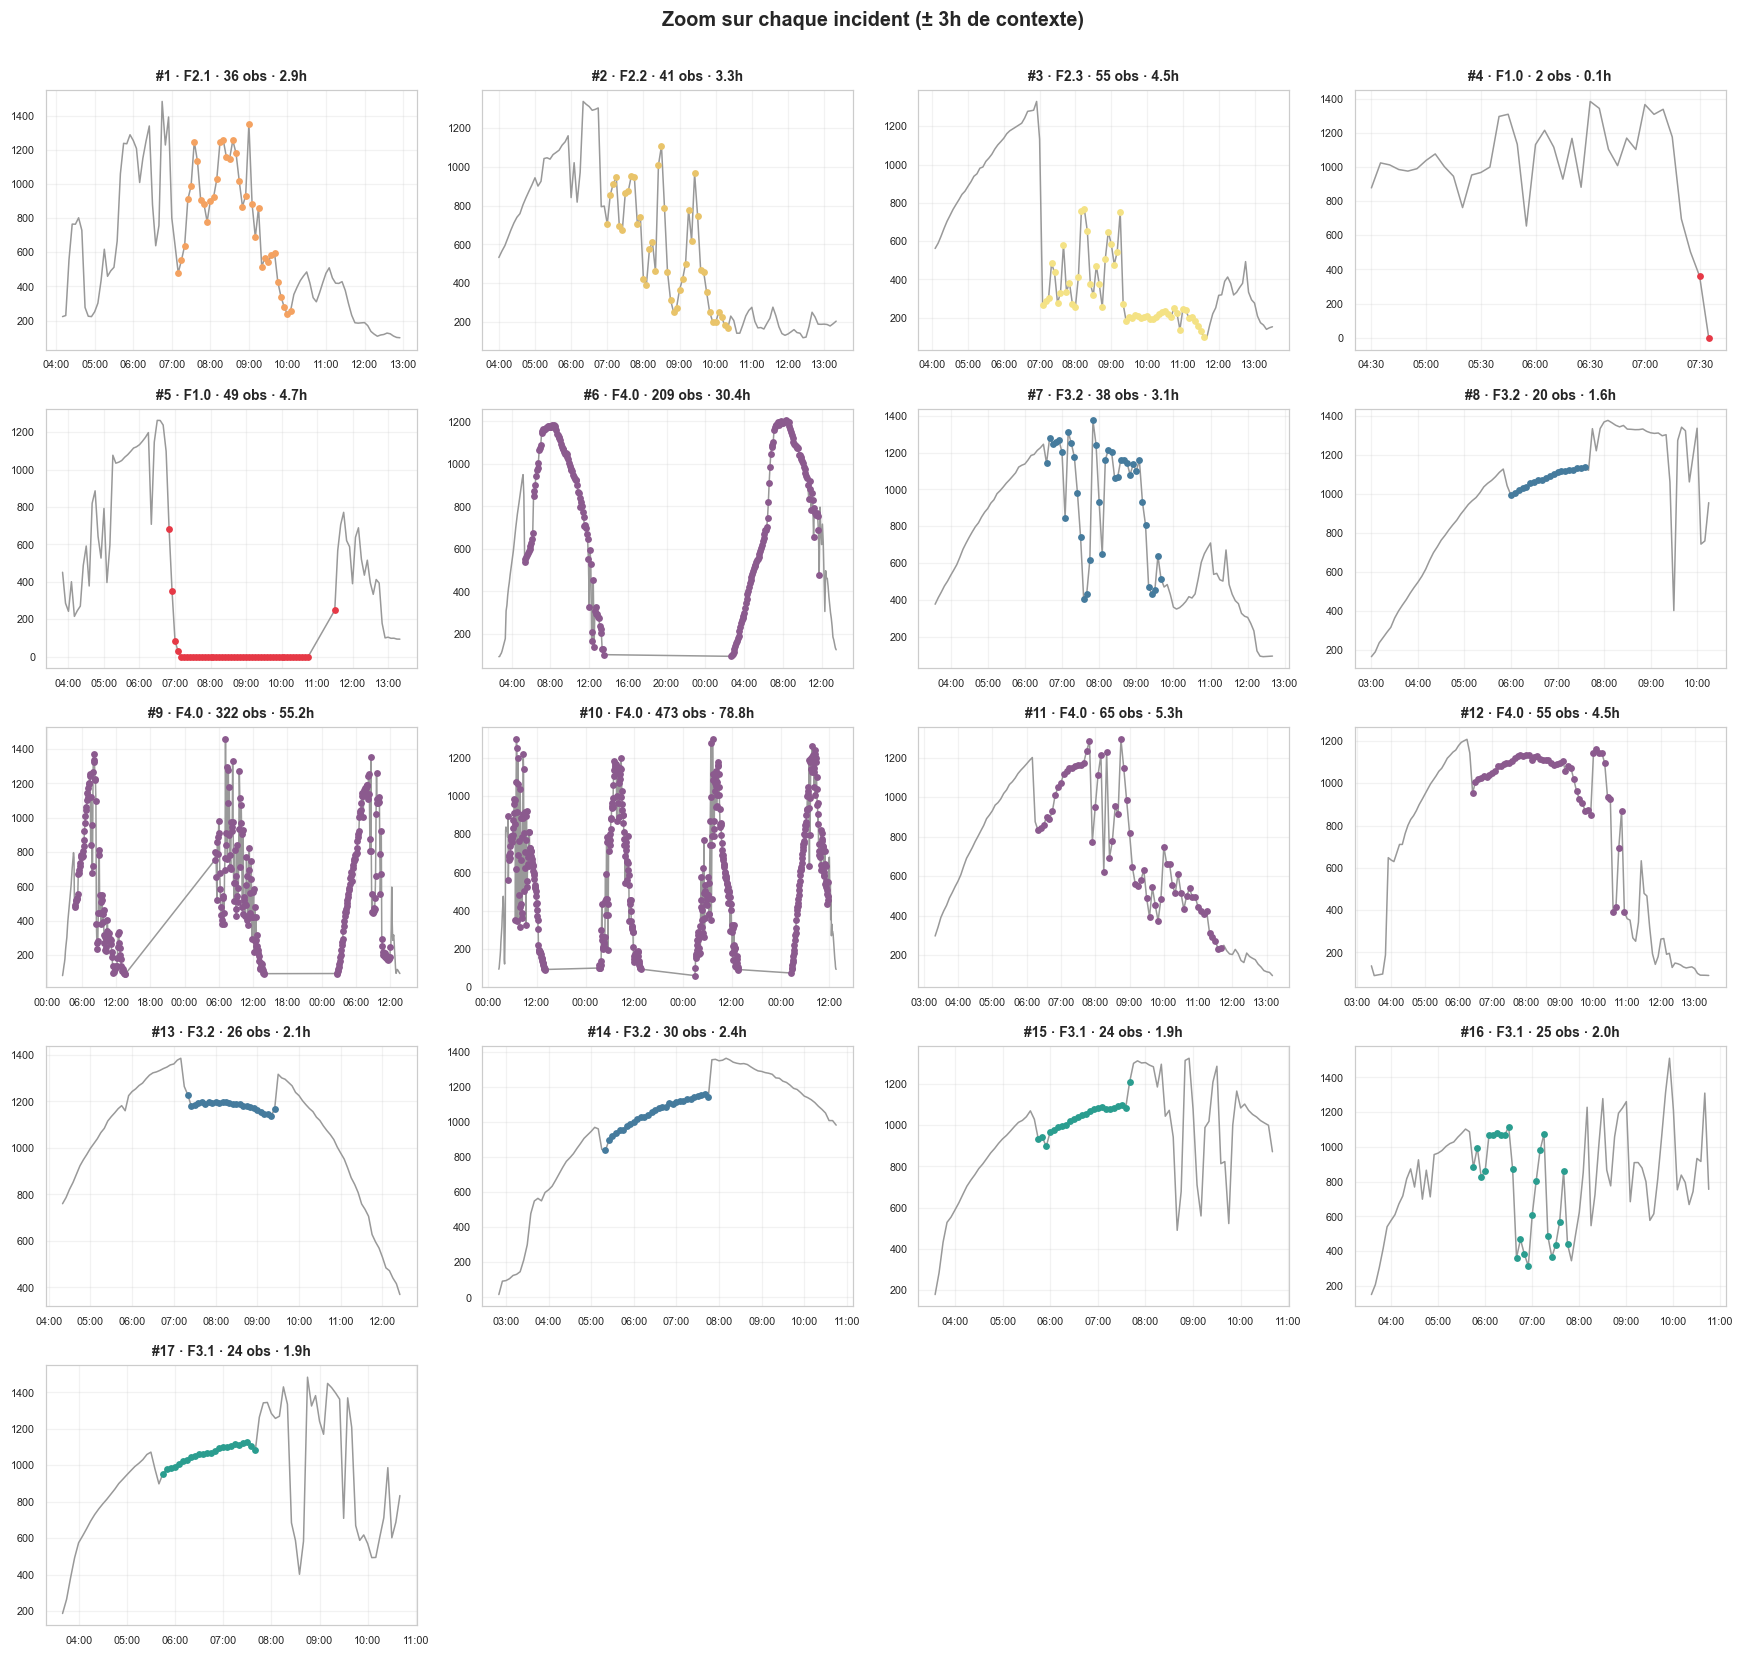

In [26]:
n = len(incidents_df)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
axes = axes.flatten()

for i, inc in incidents_df.iterrows():
    ax = axes[i]
    marge = pd.Timedelta(hours=3)
    ctx = df_etude.loc[inc['start_time'] - marge : inc['end_time'] + marge]

    ax.plot(ctx.index, ctx['Pg'], color='#999', linewidth=1)
    inside = ctx[ctx['Fault'] == inc['fault']]
    ax.scatter(inside.index, inside['Pg'], s=12,
               color=fault_colors.get(inc['fault'], 'red'), zorder=5)

    ax.set_title(f"#{i+1} · F{inc['fault']} · {inc['count']} obs · {inc['duration_hours']:.1f}h",
                 fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.grid(True, alpha=0.25)

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle("Zoom sur chaque incident (± 3h de contexte)", fontweight='bold', fontsize=13, y=1.002)
plt.tight_layout()
plt.show()

### 5.3 — Découpage chronologique par jour, cutoffs hors incident

In [27]:
# Jours occupés par un incident : un cutoff ne peut PAS tomber dedans
jours_incidents = set()
for _, inc in incidents_df.iterrows():
    d = inc['start_time'].date()
    while d <= inc['end_time'].date():
        jours_incidents.add(d)
        d += pd.Timedelta(days=1)

jours = sorted(df_etude.index.normalize().unique())
jours_dates = [d.date() for d in jours]

print(f"Jours dans df_etude      : {len(jours)}")
print(f"Jours touchés par incident: {len(jours_incidents)}")
print(f"Jours libres (cutoff OK)  : {len(set(jours_dates) - jours_incidents)}")

Jours dans df_etude      : 155
Jours touchés par incident: 23
Jours libres (cutoff OK)  : 132


In [28]:

obs_par_jour = df_etude.groupby(df_etude.index.normalize()).size()
cumul = obs_par_jour.cumsum() / len(df_etude)

def cutoff_libre(cible):
    """Jour le plus proche de `cible` (en % d'observations) qui n'est PAS dans un incident."""
    idx_cible = int(np.argmin(np.abs(cumul.values - cible)))
    for delta in range(0, len(jours)):
        for j in (idx_cible - delta, idx_cible + delta):
            if 0 <= j < len(jours) and jours[j].date() not in jours_incidents:
                return jours[j].date()
    raise ValueError("Aucun jour libre trouvé")

cut_train = cutoff_libre(0.60)
cut_val   = pd.Timestamp("2022-04-28").date() 
def assigner(ts):
    d = ts.date()
    if d <= cut_train:  return 'train'
    if d <= cut_val:    return 'val'
    return 'test'

df_etude['split'] = df_etude.index.map(assigner)

for s in ['train', 'val', 'test']:
    sub = df_etude[df_etude['split'] == s]
    n_ano = (sub['Fault'] != 0).sum()
    print(f"{s.upper():6s} : {len(sub):6,} obs ({len(sub)/len(df_etude)*100:5.1f}%) | "
          f"{n_ano:5,} anomalies ({n_ano/len(sub)*100:5.2f}%) | "
          f"{sub.index.min().date()} → {sub.index.max().date()}")

TRAIN  : 10,863 obs ( 60.2%) | 1,245 anomalies (11.46%) | 2021-10-28 → 2022-03-22
VAL    :  4,219 obs ( 23.4%) |   176 anomalies ( 4.17%) | 2022-03-23 → 2022-04-28
TEST   :  2,975 obs ( 16.5%) |    73 anomalies ( 2.45%) | 2022-04-29 → 2022-05-26


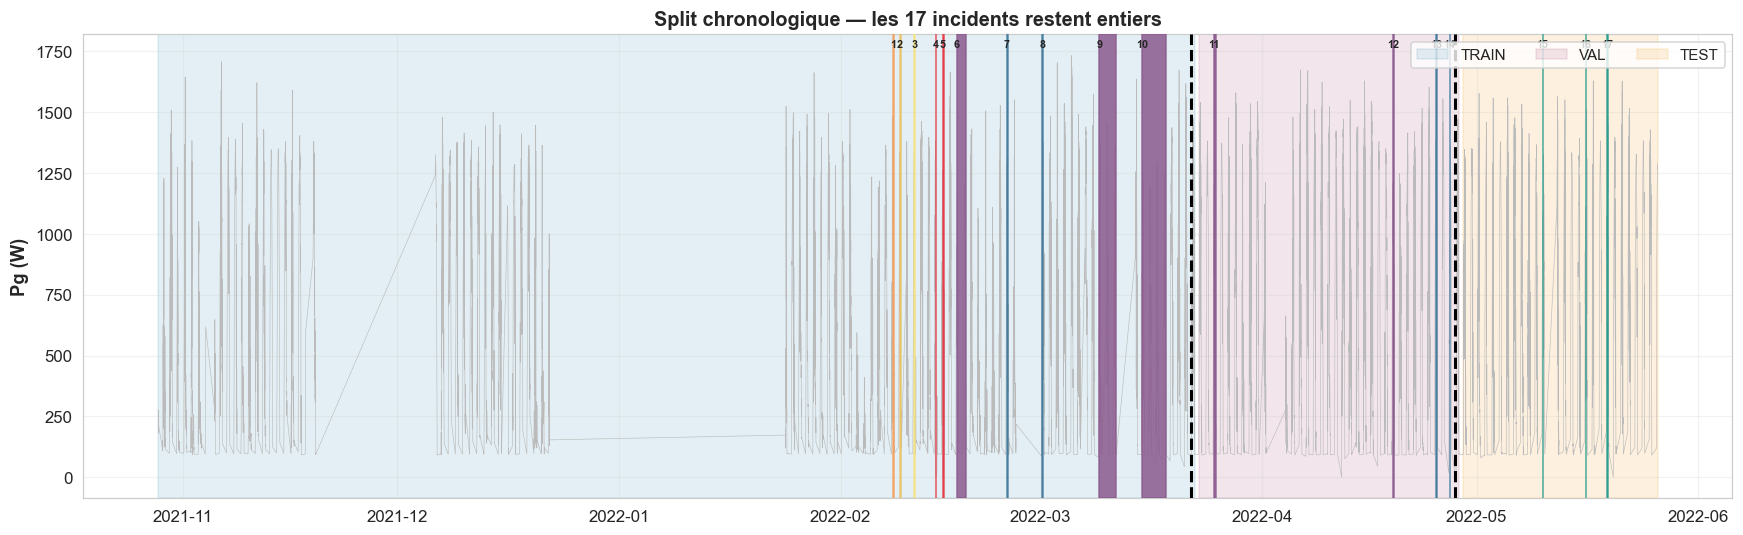

In [29]:
couleurs_split = {'train': '#2E86AB', 'val': '#A23B72', 'test': '#F18F01'}

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_etude.index, df_etude['Pg'], color='#BBB', linewidth=0.4, zorder=1)

for s in ['train', 'val', 'test']:
    sub = df_etude[df_etude['split'] == s]
    ax.axvspan(sub.index.min(), sub.index.max(),
               color=couleurs_split[s], alpha=0.13, zorder=0, label=s.upper())

for i, inc in incidents_df.iterrows():
    ax.axvspan(inc['start_time'], inc['end_time'],
               color=fault_colors.get(inc['fault'], 'gray'), alpha=0.85, zorder=3)
    ax.text(inc['start_time'], df_etude['Pg'].max()*1.02, str(i+1),
            fontsize=7, ha='center', fontweight='bold')

for c in (cut_train, cut_val):
    ax.axvline(pd.Timestamp(c), color='black', linestyle='--', linewidth=2, zorder=4)

ax.set_ylabel("Pg (W)", fontweight='bold')
ax.set_title("Split chronologique — les 17 incidents restent entiers", fontweight='bold', fontsize=13)
ax.legend(loc='upper right', ncol=3)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [30]:
# Contrôle : aucun incident ne doit changer de jeu entre son début et sa fin
_deb = incidents_df['start_time'].map(assigner)
_fin = incidents_df['end_time'].map(assigner)
assert (_deb == _fin).all(), f"incident coupé :\n{incidents_df[_deb != _fin]}"
print("Incidents coupés : 0")

# Une seule colonne conservée
incidents_df['split'] = _deb

for s in ['train','val','test']:
    sub = df_etude[df_etude['split'] == s]
    n_ano = (sub['Fault'] != 0).sum()
    print(f"{s:6s} {len(sub):6,} ({len(sub)/len(df_etude)*100:5.1f}%) | {n_ano:4} anos | "
          f"{sub.index.min().date()} → {sub.index.max().date()}")

print(pd.crosstab(incidents_df['fault'], incidents_df['split'], margins=True))

Incidents coupés : 0
train  10,863 ( 60.2%) | 1245 anos | 2021-10-28 → 2022-03-22
val     4,219 ( 23.4%) |  176 anos | 2022-03-23 → 2022-04-28
test    2,975 ( 16.5%) |   73 anos | 2022-04-29 → 2022-05-26
split  test  train  val  All
fault                       
1.0       0      2    0    2
2.1       0      1    0    1
2.2       0      1    0    1
2.3       0      1    0    1
3.1       3      0    0    3
3.2       0      2    2    4
4.0       0      3    2    5
All       3     10    4   17


In [31]:
import json
from pathlib import Path

Path("data").mkdir(exist_ok=True)

# --- Matérialisation des trois jeux ---
train = df_etude[df_etude['split'] == 'train'].copy()
val   = df_etude[df_etude['split'] == 'val'].copy()
test  = df_etude[df_etude['split'] == 'test'].copy()

assert len(train) + len(val) + len(test) == len(df_etude), "perte de lignes"
assert train.index.max() < val.index.min() < val.index.max() < test.index.min(), \
       "chevauchement temporel"

df_etude = df_etude.drop(columns=['is_anomaly', 'incident_group'])
# --- Sauvegarde : df_etude porte la colonne split, c'est la source unique ---
df_etude.to_csv("data/df_etude_split.csv")
incidents_df.to_csv("data/incidents.csv", index=False)

# --- Métadonnées : rend le split reproductible et auditable ---
meta = {
    "genere_le": pd.Timestamp.now().isoformat(timespec="seconds"),
    "source": "merged_5min_day.csv",
    "periode_etude": [str(df_etude.index.min()), str(df_etude.index.max())],
    "regle_troncature": "derniere_anomalie + 7 jours",
    "methode_split": "chronologique par jour, cutoff decale hors incident",
    "cut_train": str(cut_train),
    "cut_val": str(cut_val),
    "incidents_coupes": 0,
    "jeux": {
        s: {
            "n_obs": int((df_etude['split'] == s).sum()),
            "pct": round(100 * (df_etude['split'] == s).mean(), 1),
            "n_anomalies": int((df_etude.loc[df_etude['split'] == s, 'Fault'] != 0).sum()),
            "debut": str(df_etude[df_etude['split'] == s].index.min()),
            "fin":   str(df_etude[df_etude['split'] == s].index.max()),
            "n_incidents": int((incidents_df['split'] == s).sum()),
            "types_fault": sorted(incidents_df.loc[incidents_df['split'] == s, 'fault'].unique().tolist()),
        }
        for s in ['train', 'val', 'test']
    },
    "limites_connues": [
        "F2.1, F2.2, F2.3 : un seul incident chacun, tous en train — recall inevaluable",
        "F3.1 absent de train : evalue en transfert depuis F3.2",
        "test = 3 episodes / 73 obs — rapporter le recall par episode, pas la PR-AUC seule",
    ],
}

with open("data/split_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f"data/df_etude_split.csv   {len(df_etude):,} lignes")
print(f"data/incidents.csv        {len(incidents_df)} incidents")
print(f"data/split_meta.json")
print(f"\ntrain {len(train):,} | val {len(val):,} | test {len(test):,}")

data/df_etude_split.csv   18,057 lignes
data/incidents.csv        17 incidents
data/split_meta.json

train 10,863 | val 4,219 | test 2,975


### 5.4 — Fonctions utilitaires (évaluation et séquences)

Trois fonctions servent dans toute la suite du notebook. Elles sont définies **une seule fois**, ici,
juste après le split : le découpage en épisodes est déjà nécessaire à l'ablation des features (§ 6.2.8),
et la fabrication des séquences le devient à partir de la section LSTM (§ 10).

Seule la classe `DetecteurPV` (§ 14) réimplémente la fabrication de séquences en interne, parce
qu'elle doit rester autonome pour le déploiement, sans dépendre du notebook.

In [32]:
# =============================================================
# 5.4 — Fonctions utilitaires : évaluation (point + épisode) et séquences
# =============================================================
# Définitions CANONIQUES. Aucune de ces fonctions n'est redéfinie ailleurs
# dans le notebook (la seule exception assumée est la version interne à la
# classe DetecteurPV, § 14, qui doit être autonome pour le déploiement).

def decouper_episodes(index, y):
    """Blocs contigus d'anomalie, sans franchir une nuit (trou > 7 min)."""
    ruptures = np.flatnonzero((index.to_series().diff() > pd.Timedelta("7min")).values)
    bornes = [0, *ruptures.tolist(), len(index)]
    eps = []
    for a, b in [(a, b) for a, b in zip(bornes[:-1], bornes[1:]) if b > a]:
        k = np.flatnonzero(np.diff(np.r_[0, y[a:b], 0]) != 0)
        eps += [(a + s, a + f) for s, f in zip(k[::2], k[1::2])]
    return eps


def evaluer(scores, y, index, seuil, base=None):
    """Retourne un dict de métriques point + épisode pour un vecteur de scores."""
    pr_auc = average_precision_score(y, scores)
    eps = decouper_episodes(index, y)
    # niveau épisode : une panne est "détectée" si >=1 point dépasse le seuil
    detectes = sum(1 for a, b in eps if (scores[a:b] >= seuil).any())
    # délai de détection (en pas de 5 min) pour les épisodes détectés
    delais = []
    for a, b in eps:
        above = np.flatnonzero(scores[a:b] >= seuil)
        if len(above):
            delais.append(int(above[0]))
    res = {
        "pr_auc": pr_auc,
        "n_episodes": len(eps),
        "episodes_detectes": detectes,
        "taux_detection": detectes / len(eps) if eps else 0.0,
        "delai_median_pts": float(np.median(delais)) if delais else None,
    }
    if base:
        res["lift"] = pr_auc / base
    return res


def fabriquer_sequences(df_partition, features, seq_len, gap_min=7):
    """
    Découpe une partition (train/val/test) en séquences glissantes de longueur
    seq_len, SANS enjamber les nuits (rupture dès qu'un trou > gap_min apparaît).
    À n'appeler que sur UNE partition à la fois : c'est ce qui garantit qu'aucune
    fenêtre ne chevauche une frontière train/val/test.

    Retourne :
      - X_seq   : array (n_sequences, seq_len, n_features)
      - idx_fin : index temporel du DERNIER point de chaque séquence (sert à
                  aligner le score au niveau point et à récupérer le label)
    """
    X_list, idx_list = [], []
    seg = (df_partition.index.to_series().diff() > pd.Timedelta(f"{gap_min}min")).cumsum()
    for _, bloc in df_partition.groupby(seg):
        vals = bloc[features].values
        n = len(bloc)
        if n < seq_len:
            continue   # segment trop court pour une seule fenêtre
        for start in range(n - seq_len + 1):
            X_list.append(vals[start:start + seq_len])
            idx_list.append(bloc.index[start + seq_len - 1])   # dernier point
    if not X_list:
        return np.empty((0, seq_len, len(features))), pd.DatetimeIndex([])
    return np.array(X_list), pd.DatetimeIndex(idx_list)


print("Fonctions utilitaires définies : decouper_episodes, evaluer, fabriquer_sequences")

Fonctions utilitaires définies : decouper_episodes, evaluer, fabriquer_sequences


---
## 6. Feature Engineering
---

### 6.1 Phase 1 — Indicateurs physiques de base

4 features candidates capturant des comportements physiques utiles pour la
détection d'anomalies. Elles sont d'abord **créées** sur base physique, puis
**validées** par un test KS sur le jeu de développement (train + val) : seules
celles qui séparent réellement normal et anomalie sont retenues.

In [33]:
# =============================================================
# 6.1 — Création des 4 features Phase 1 (indicateurs physiques)
# =============================================================
# Ces features sont construites sur base physique. Les éventuels
# paramètres (aucun ici : ce sont des transformations point-à-point ou
# des fenêtres glissantes) ne nécessitent pas d'ajustement sur le train.
# Les fenêtres glissantes sont bornées par SEGMENT DE JOUR pour ne jamais
# enjamber une nuit (mesures nocturnes absentes, cf. EDA).

# --- segments de jour : rupture dès qu'un trou > 7 min apparaît ---
_seg_jour = (df.index.to_series().diff() > pd.Timedelta("7min")).cumsum()

# (1) ratio_pg_gti : rendement instantané (Pg produite par unité d'irradiance)
df["ratio_pg_gti"] = df["Pg"] / df["GTI"].replace(0, np.nan)

# (2) delta_tpv_ta : échauffement du panneau au-dessus de l'air ambiant
df["delta_tpv_ta"] = df["TPV"] - df["TA"]

# (3) pg_diff : variation temporelle de Pg (différence première par jour)
df["pg_diff"] = df.groupby(_seg_jour)["Pg"].transform(lambda s: s.diff())

# (4) ratio_std_30min : instabilité locale du rendement (écart-type glissant
#     6 points = 30 min), par segment de jour
df["ratio_std_30min"] = (
    df.groupby(_seg_jour)["ratio_pg_gti"]
      .transform(lambda s: s.rolling(6, min_periods=2).std())
)

# --- propagation dans train / val / test (df est la source unique) ---
# --- réextraction depuis df : on s'assure qu'aucune colonne de travail
#     (split, etc.) ne réapparaît. df ne doit contenir que capteurs + features. ---
_cols_travail = ["split", "is_anomaly", "incident_group", "fgroup"]
df = df.drop(columns=[c for c in _cols_travail if c in df.columns])
train = df.loc[train.index]
val   = df.loc[val.index]
test  = df.loc[test.index]

_p1 = ["ratio_pg_gti", "delta_tpv_ta", "pg_diff", "ratio_std_30min"]
_nan = df[_p1].isna().sum()
print("4 features Phase 1 créées :", _p1)
print(f"NaN introduits (bords de fenêtre / GTI=0) : {int(_nan.sum())}")
print(_nan[_nan > 0].to_string() if _nan.sum() else "  aucun")


4 features Phase 1 créées : ['ratio_pg_gti', 'delta_tpv_ta', 'pg_diff', 'ratio_std_30min']
NaN introduits (bords de fenêtre / GTI=0) : 1202
pg_diff            601
ratio_std_30min    601


In [34]:
# =============================================================
# 6.1bis — Validation des features Phase 1 par pouvoir discriminant
# =============================================================
# Les 4 features Phase 1 ont été créées sur base physique. Comme en Phase 2,
# on les VALIDE par un test de Kolmogorov-Smirnov (séparation normal/anomalie)
# AVANT de les retenir — un ajout intuitif n'est pas une justification.
#
# IMPORTANT : la sélection se fait sur dev = train + val UNIQUEMENT. Le lot de
# test n'entre jamais dans le choix des features (sinon fuite de sélection :
# les anomalies de test participeraient à décider quelles features garder).
from scipy.stats import ks_2samp

dev = pd.concat([train, val]).sort_index()          # jeu de développement
sain_ = dev[dev["Fault"] == 0]
ano_  = dev[dev["Fault"] != 0]

FEATURES_PHASE1_CANDIDATES = ["ratio_pg_gti", "delta_tpv_ta", "pg_diff", "ratio_std_30min"]

print("Pouvoir discriminant des candidates Phase 1 (KS normal vs anomalie, sur dev)\n")
print(f"{'Feature':<18}{'KS':>8}{'KS sur Fault 3':>16}   décision")
SEUIL_KS = 0.35
FEATURES_PHASE1 = []
f3_ = dev[dev["Fault"].isin([3.1, 3.2])]
for f in FEATURES_PHASE1_CANDIDATES:
    ks     = ks_2samp(sain_[f].dropna(), ano_[f].dropna()).statistic
    ks_f3  = ks_2samp(sain_[f].dropna(), f3_[f].dropna()).statistic
    garde  = ks >= SEUIL_KS
    if garde:
        FEATURES_PHASE1.append(f)
    print(f"{f:<18}{ks:>8.2f}{ks_f3:>16.2f}   {'RETENUE' if garde else 'écartée (KS trop faible)'}")

print(f"\nSeuil KS = {SEUIL_KS}")
print(f"Phase 1 retenue : {FEATURES_PHASE1}")


Pouvoir discriminant des candidates Phase 1 (KS normal vs anomalie, sur dev)

Feature                 KS  KS sur Fault 3   décision
ratio_pg_gti          0.82            0.82   RETENUE
delta_tpv_ta          0.18            0.39   écartée (KS trop faible)
pg_diff               0.08            0.22   écartée (KS trop faible)
ratio_std_30min       0.10            0.32   écartée (KS trop faible)

Seuil KS = 0.35
Phase 1 retenue : ['ratio_pg_gti']


La décision de rétention est affichée par le code de la cellule précédente
(variable `FEATURES_PHASE1`), elle n'est pas écrite en dur ici pour rester
cohérente si les données ou le seuil KS changent.

En pratique, seules les features dont le KS ≥ 0.35 sont conservées : les autres
ne séparent pas suffisamment le normal des anomalies et dégraderaient le PR-AUC
de l'Isolation Forest (confirmé par l'ablation 6.2.8).

### 6.1.1 t-SNE AVANT enrichissement (Phase 1 — 11 variables)

Vérifier la séparabilité des anomalies avec les features de Phase 1 uniquement.

Échantillon t-SNE : 5,000 points tirés dans dev = train + val (15,082 points, test exclu)
  anomalies dans l'échantillon : 454


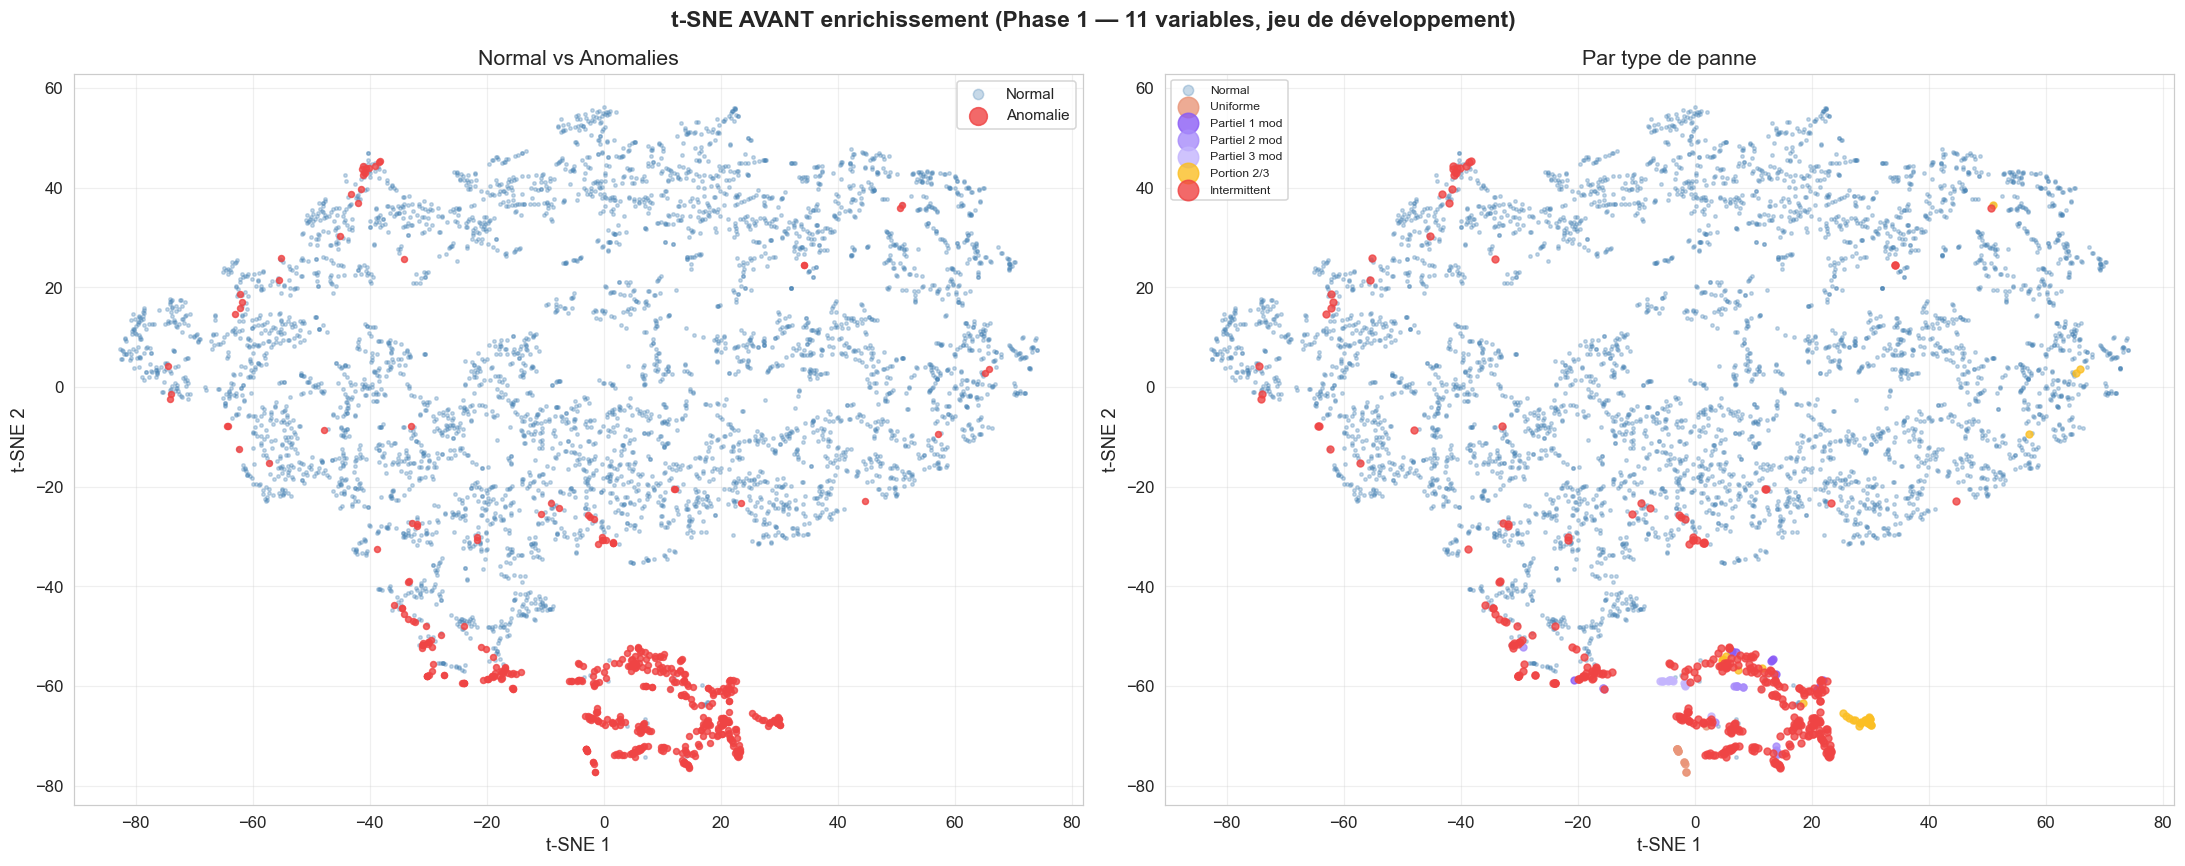

In [35]:
# =============================================================
# 6.1.1 — t-SNE AVANT enrichissement (Phase 1)
# =============================================================
# Échantillonnage sur le JEU DE DÉVELOPPEMENT (train + val) uniquement, comme
# en 6.2.10. Ce graphe est descriptif et n'alimente aucune décision, mais
# l'échantillonner sur df complet ferait apparaître la période de test et la
# période hors étude : on s'aligne sur dev par cohérence méthodologique.
FEATURES_CAPTEURS = ["DTI", "GTI", "TA", "TPV", "Ia", "Ig", "Pg", "Va", "Vg", "Fg"]
tsne_features_v1 = FEATURES_CAPTEURS + FEATURES_PHASE1

_dev_tsne = pd.concat([train, val]).sort_index()
_n_ech = min(5000, len(_dev_tsne))
sample = _dev_tsne.sample(n=_n_ech, random_state=42)
X_sample = sample[tsne_features_v1].dropna()
sample_clean = sample.loc[X_sample.index]

print(f"Échantillon t-SNE : {len(X_sample):,} points tirés dans dev = train + val "
      f"({len(_dev_tsne):,} points, test exclu)")
print(f"  anomalies dans l'échantillon : {int((sample_clean['Fault'] != 0).sum())}")

X_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(
    StandardScaler().fit_transform(X_sample)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(f"t-SNE AVANT enrichissement (Phase 1 — {len(tsne_features_v1)} variables, "
             f"jeu de développement)", fontsize=15, fontweight="bold")

COLORS_TSNE = {0.0: "#4682B4", 1.0: "#E9967A", 2.1: "#8B5CF6", 2.2: "#A78BFA",
               2.3: "#C4B5FD", 3.1: "#F59E0B", 3.2: "#FBBF24", 4.0: "#EF4444"}
LABELS_TSNE = {0.0: "Normal", 1.0: "Uniforme", 2.1: "Partiel 1 mod",
               2.2: "Partiel 2 mod", 2.3: "Partiel 3 mod",
               3.1: "Portion 1/3", 3.2: "Portion 2/3", 4.0: "Intermittent"}

# (a) Normal vs Anomalies
mask_n = sample_clean["Fault"] == 0
axes[0].scatter(X_2d[mask_n, 0], X_2d[mask_n, 1], alpha=0.3, s=5, c="#4682B4", label="Normal")
axes[0].scatter(X_2d[~mask_n, 0], X_2d[~mask_n, 1], alpha=0.8, s=15, c="#EF4444", label="Anomalie")
axes[0].set_title("Normal vs Anomalies")
axes[0].legend(markerscale=3)
axes[0].set_xlabel("t-SNE 1"); axes[0].set_ylabel("t-SNE 2")

# (b) Par type de panne
for fv in sorted(sample_clean["Fault"].unique()):
    m = sample_clean["Fault"] == fv
    axes[1].scatter(X_2d[m, 0], X_2d[m, 1],
                    alpha=0.3 if fv == 0 else 0.8, s=5 if fv == 0 else 20,
                    c=COLORS_TSNE.get(fv, "gray"), label=LABELS_TSNE.get(fv, f"Fault {fv}"))
axes[1].set_title("Par type de panne")
axes[1].legend(markerscale=3, fontsize=8)
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

---
### 6.2 Phase 2 — Recherche de features pour les pannes subtiles (Fault 3)

Fault 3 (ombrage partiel d'une portion de module) est le type le plus difficile à détecter.

**Démarche :** créer 6 features candidates → évaluer le pouvoir de séparation (test KS) → vérifier la redondance → ne retenir que les meilleures.

#### 6.2.1 Création des 7 features candidates

In [36]:
# --- jeu d'ajustement : points sains de train uniquement ---
train_normal = train[train["Fault"] == 0.0]
print(f"Ajustement des paramètres sur train_normal : {len(train_normal):,} points sains")

# --- sous-ensembles pour les visualisations : train + val, test EXCLU ---
dev = pd.concat([train, val]).sort_index()
normal  = dev[dev["Fault"] == 0.0]
fault3  = dev[(dev["Fault"] >= 3.0) & (dev["Fault"] < 4.0)]
fault31 = dev[dev["Fault"] == 3.1]
fault32 = dev[dev["Fault"] == 3.2]
fault4  = dev[dev["Fault"] == 4.0]

print(f"Jeu de sélection (train + val) : {len(dev):,} lignes, "
      f"{int((dev['Fault'] != 0).sum()):,} anomalies")
print(f"  types présents : {sorted(dev.loc[dev['Fault'] != 0, 'Fault'].unique())}")
print(f"  Fault 3.1 : {len(fault31)} point(s) — ce type n'existe que dans le test,")
print(f"              il ne peut donc pas servir à concevoir des features.")
print(f"  Fault 3.2 : {len(fault32)} | Fault 4.0 : {len(fault4)}")

# =============================================================
# Les 7 candidates
# =============================================================
CANDIDATES = {}
lr = LinearRegression().fit(train_normal[["GTI"]], train_normal["Pg"])

CANDIDATES["pg_residual"] = df["Pg"] - lr.predict(df[["GTI"]])
_med_va = train_normal["Va"].median()
CANDIDATES["va_deviation"] = (df["Va"] - _med_va).abs()
CANDIDATES["efficiency_corrigee"] = (
    df["Pg"] / (df["GTI"] * (1 - 0.004 * (df["TPV"] - 25))).replace(0, np.nan)
)
CANDIDATES["ratio_ia_gti"] = df["Ia"] / df["GTI"].replace(0, np.nan)

_segments_jour = (df.index.to_series().diff() > pd.Timedelta("7min")).cumsum()
CANDIDATES["ratio_mean_1h"] = (
    df.groupby(_segments_jour)["ratio_pg_gti"]
      .transform(lambda s: s.rolling(12, min_periods=1).mean())
)
CANDIDATES["ratio_local_dev"] = df["ratio_pg_gti"] - CANDIDATES["ratio_mean_1h"]
CANDIDATES["vg_va_ratio"] = df["Vg"] / df["Va"].replace(0, np.nan)
# --- ajout au DataFrame ---
for nom, serie in CANDIDATES.items():
    df[nom] = serie

# --- réextraction depuis df : on s'assure qu'aucune colonne de travail
#     (split, etc.) ne réapparaît. df ne doit contenir que capteurs + features. ---
_cols_travail = ["split", "is_anomaly", "incident_group", "fgroup"]
df = df.drop(columns=[c for c in _cols_travail if c in df.columns])
train = df.loc[train.index]
val   = df.loc[val.index]
test  = df.loc[test.index]
dev   = pd.concat([train, val]).sort_index()
train_normal = train[train["Fault"] == 0.0]
normal  = dev[dev["Fault"] == 0.0]
fault3  = dev[(dev["Fault"] >= 3.0) & (dev["Fault"] < 4.0)]
fault31 = dev[dev["Fault"] == 3.1]
fault32 = dev[dev["Fault"] == 3.2]
fault4  = dev[dev["Fault"] == 4.0]

CANDIDATE_NAMES = list(CANDIDATES.keys())
print(f"\n{len(CANDIDATE_NAMES)} candidates créées : {CANDIDATE_NAMES}")
_nan = df[CANDIDATE_NAMES].isna().sum()
print(f"NaN introduits : {int(_nan.sum())}" + (f"\n{_nan[_nan > 0]}" if _nan.sum() else ""))

Ajustement des paramètres sur train_normal : 9,618 points sains
Jeu de sélection (train + val) : 15,082 lignes, 1,421 anomalies
  types présents : [np.float64(1.0), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(3.2), np.float64(4.0)]
  Fault 3.1 : 0 point(s) — ce type n'existe que dans le test,
              il ne peut donc pas servir à concevoir des features.
  Fault 3.2 : 114 | Fault 4.0 : 1124



7 candidates créées : ['pg_residual', 'va_deviation', 'efficiency_corrigee', 'ratio_ia_gti', 'ratio_mean_1h', 'ratio_local_dev', 'vg_va_ratio']
NaN introduits : 0


#### 6.2.2 Test de Kolmogorov-Smirnov — Classement du pouvoir de séparation

Effectifs : Fault 3 = 114 | Fault 4 = 1,124 | Toutes anomalies = 1,421

Classement (décision sur 'Toutes anomalies') :
            Feature  KS Fault 3  KS Fault 4  KS Toutes anomalies  Écart méd. (σ)
      ratio_mean_1h       0.751       0.870                0.861           2.105
       ratio_pg_gti       0.819       0.815                0.823           1.948
efficiency_corrigee       0.787       0.797                0.805           2.172
        pg_residual       0.840       0.751                0.775           4.140
       va_deviation       0.920       0.686                0.702           5.609
        vg_va_ratio       0.921       0.678                0.695           4.789
       ratio_ia_gti       0.220       0.288                0.290           0.557
    ratio_local_dev       0.226       0.082                0.042           0.042


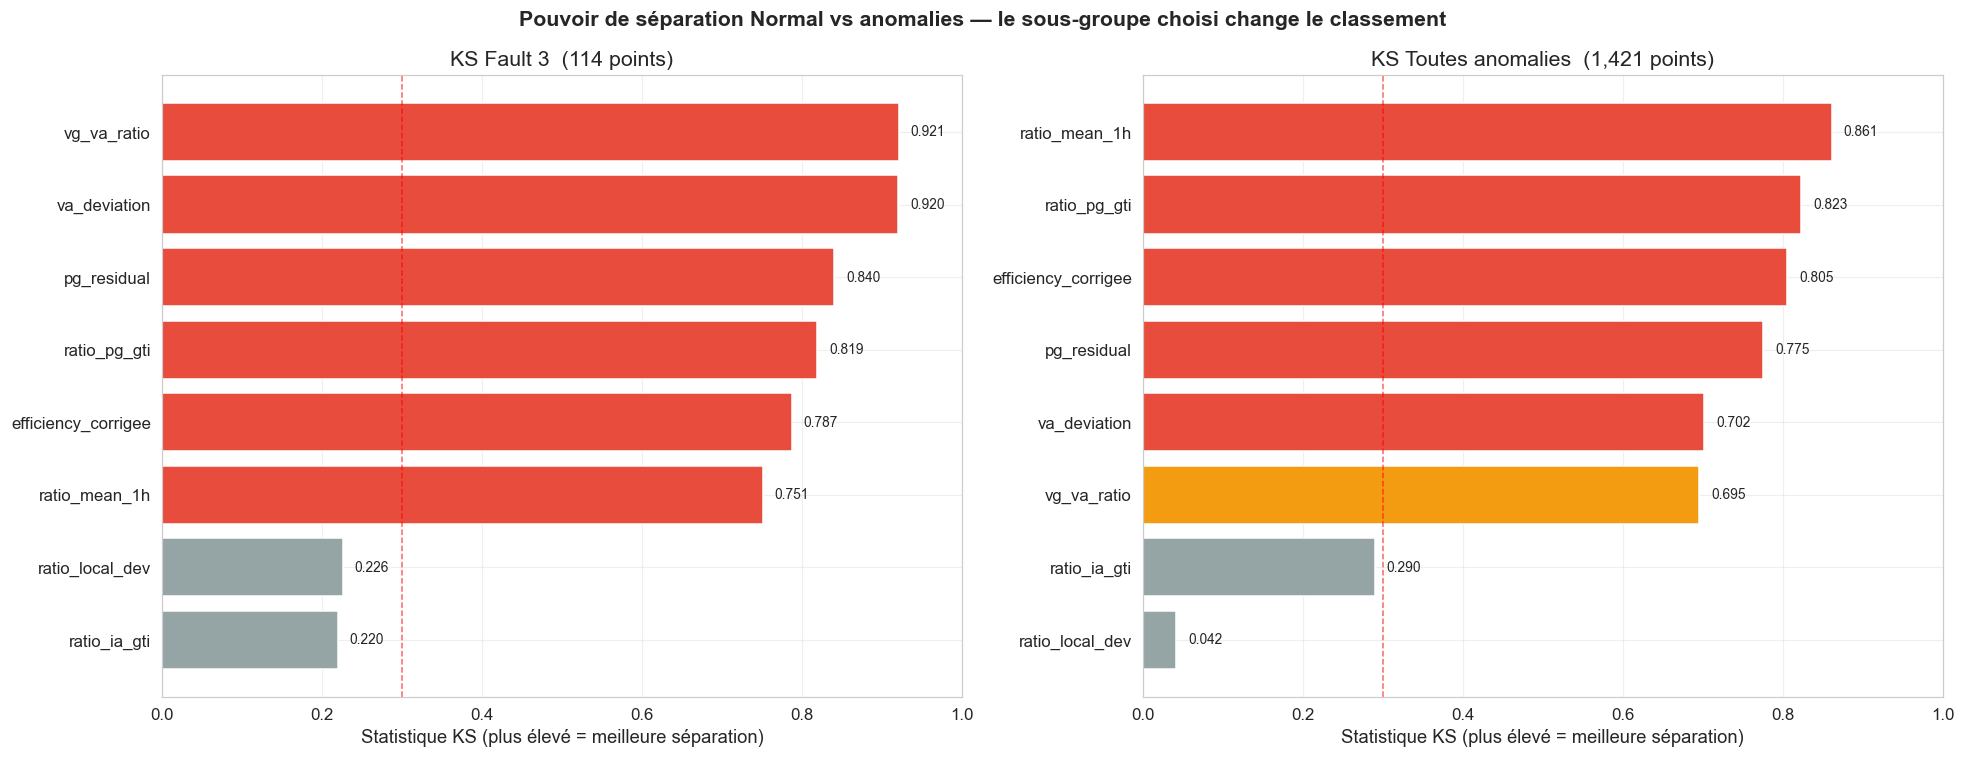


Meilleure sur Fault 3 seul : vg_va_ratio
Meilleure sur toutes les anomalies : ratio_mean_1h
=> Le choix du sous-groupe change le gagnant : décider sur l'ensemble des anomalies.


In [37]:

all_test = FEATURES_PHASE1 + CANDIDATE_NAMES

groupes = {
    "Fault 3":          dev[(dev["Fault"] >= 3.0) & (dev["Fault"] < 4.0)],
    "Fault 4":          dev[dev["Fault"] == 4.0],
    "Toutes anomalies": dev[dev["Fault"] != 0],
}
print("Effectifs : " + " | ".join(f"{k} = {len(v):,}" for k, v in groupes.items()))

results = []
for feat in all_test:
    n_data = normal[feat].dropna()
    ligne = {"Feature": feat}
    for nom, grp in groupes.items():
        f_data = grp[feat].dropna()
        ligne[f"KS {nom}"] = round(stats.ks_2samp(n_data, f_data).statistic, 3)
    ligne["Écart méd. (σ)"] = round(
        abs(n_data.median() - groupes["Toutes anomalies"][feat].dropna().median())
        / n_data.std(), 3)
    results.append(ligne)

df_ks = pd.DataFrame(results).sort_values("KS Toutes anomalies", ascending=False)
print("\nClassement (décision sur 'Toutes anomalies') :")
print(df_ks.to_string(index=False))

# --- figure : les deux classements côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Pouvoir de séparation Normal vs anomalies — le sous-groupe choisi change le classement",
             fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["KS Fault 3", "KS Toutes anomalies"]):
    d = df_ks.sort_values(col)
    couleurs = ["#E74C3C" if x > 0.7 else "#F39C12" if x > 0.3 else "#95A5A6" for x in d[col]]
    ax.barh(d["Feature"], d[col], color=couleurs)
    ax.axvline(0.3, color="red", ls="--", lw=1, alpha=0.6)
    ax.set_xlabel("Statistique KS (plus élevé = meilleure séparation)")
    ax.set_title(col + (f"  ({len(groupes['Fault 3']):,} points)" if "Fault 3" in col
                        else f"  ({len(groupes['Toutes anomalies']):,} points)"))
    ax.set_xlim(0, 1); ax.grid(axis="x", alpha=0.3)
    for y, v in zip(range(len(d)), d[col]):
        ax.text(v + 0.015, y, f"{v:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

_meilleure_f3 = df_ks.sort_values("KS Fault 3", ascending=False).iloc[0]["Feature"]
_meilleure_tt = df_ks.iloc[0]["Feature"]
print(f"\nMeilleure sur Fault 3 seul : {_meilleure_f3}")
print(f"Meilleure sur toutes les anomalies : {_meilleure_tt}")
if _meilleure_f3 != _meilleure_tt:
    print("=> Le choix du sous-groupe change le gagnant : décider sur l'ensemble des anomalies.")

#### 6.2.3 Distributions — Normal vs Fault 3 pour chaque candidate

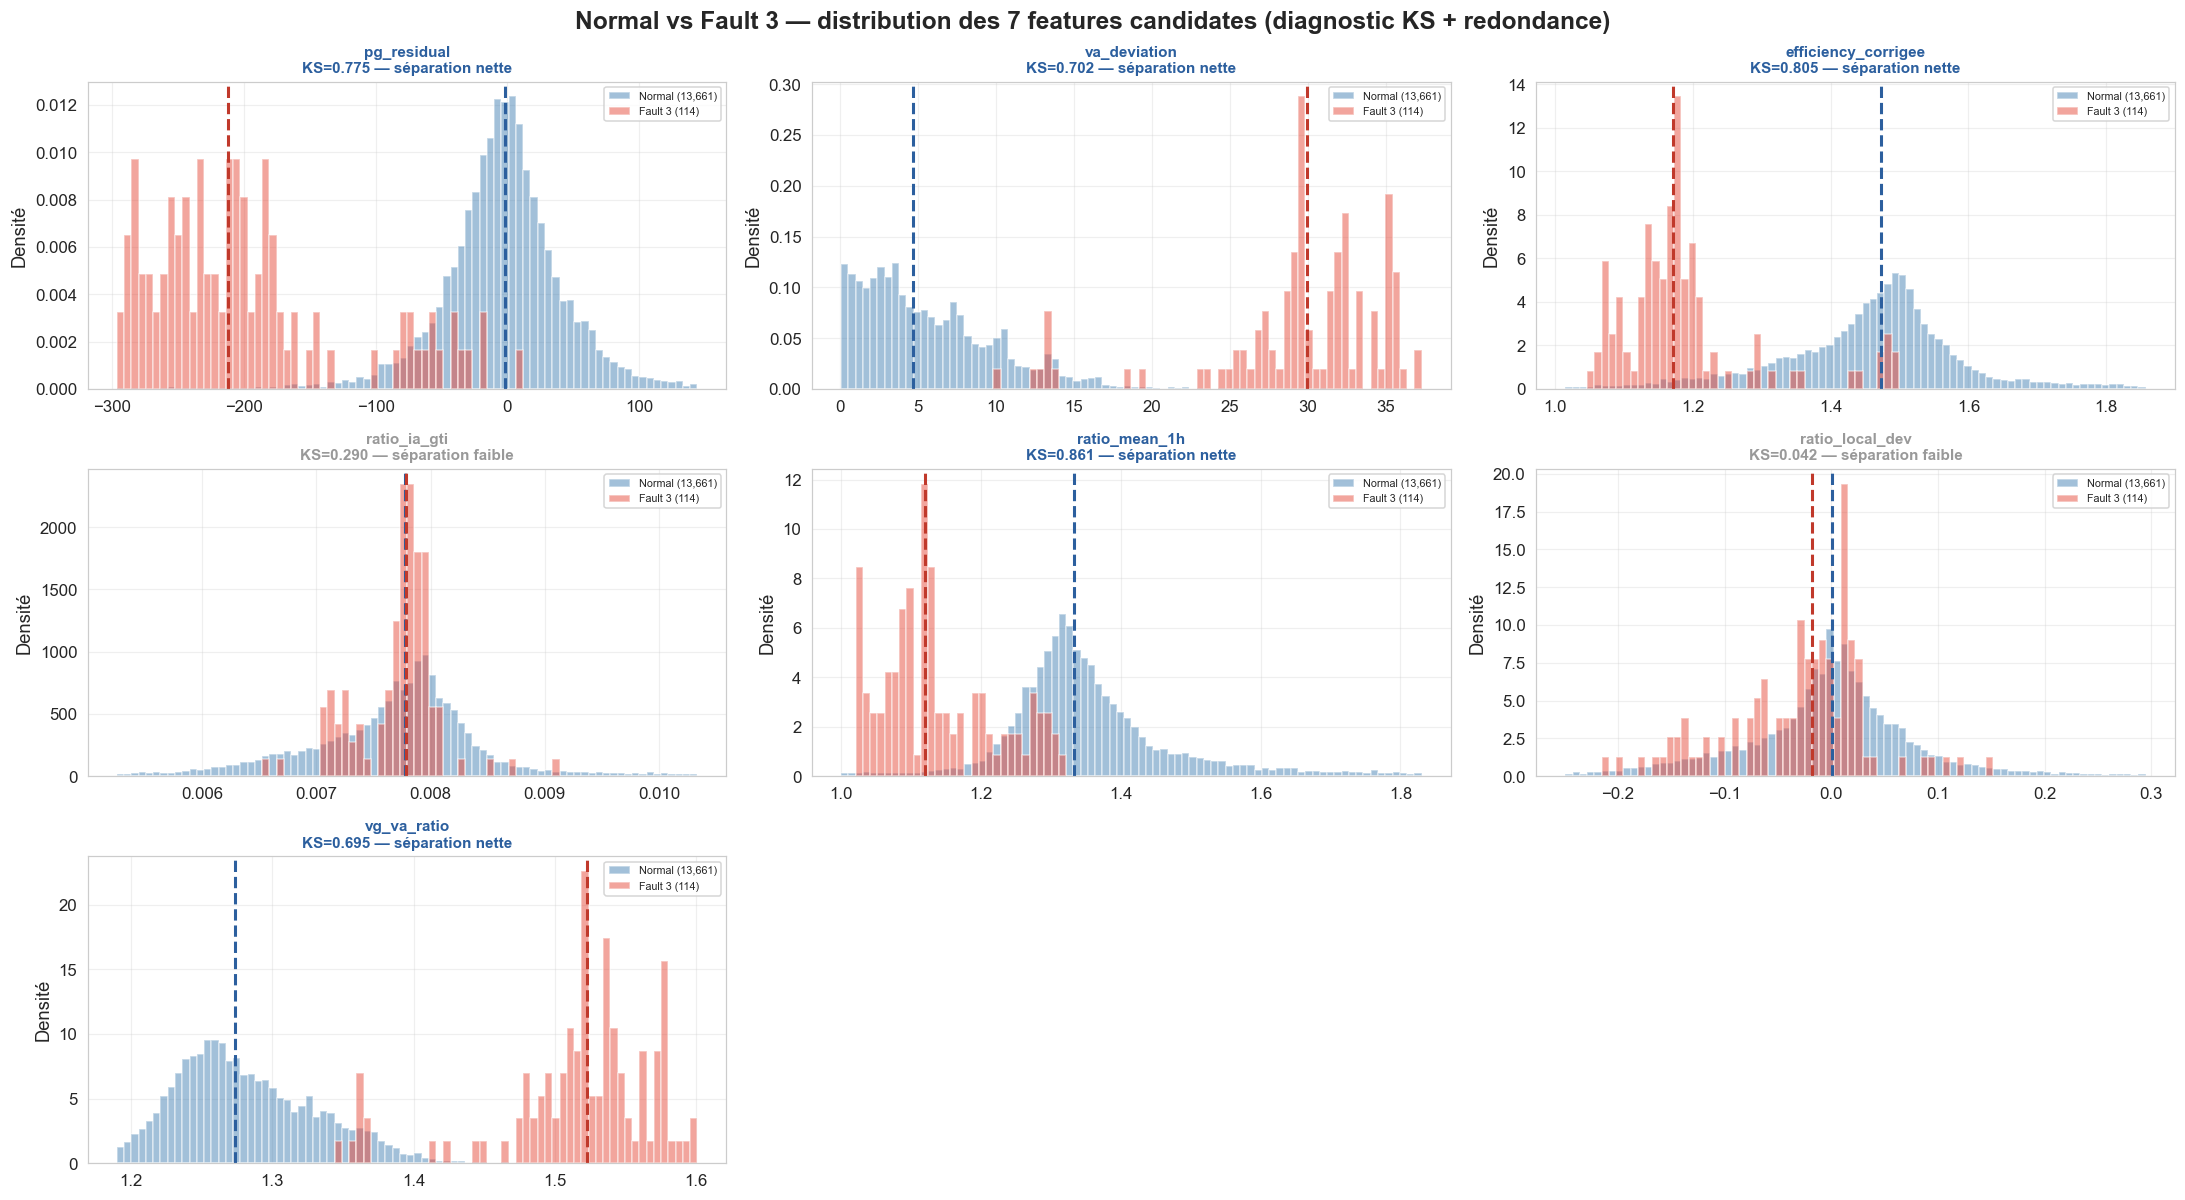

Lecture des étiquettes (toutes calculées, aucune écrite en dur) :
  KS < 0.35                  -> séparation faible
  corrélation >= 0.9 avec une autre candidate -> redondante
La rétention finale est décidée en 6.2.8 (ablation) et figée en 6.2.9.


In [38]:
# =============================================================
# 6.2.3 — Distributions Normal vs Fault 3 pour chaque candidate
# =============================================================
# Les étiquettes de chaque panneau sont CALCULÉES ici, pas écrites en dur :
#   - le KS provient de df_ks (cellule 6.2.2) ;
#   - la redondance est mesurée sur dev par la corrélation maximale de la
#     candidate avec une AUTRE candidate.
# La décision de rétention définitive n'appartient pas à cette cellule : elle
# est prise en 6.2.9 par l'ablation quantitative. On affiche donc un diagnostic
# (KS + redondance), pas un verdict.
_SEUIL_KS_FAIBLE = 0.35
_SEUIL_REDONDANCE = 0.90

_cands_plot = [c for c in CANDIDATE_NAMES if c in df.columns]
_corr_cands = dev[_cands_plot].corr().abs()
for _c in _cands_plot:          # on neutralise la diagonale (corr(x, x) = 1)
    _corr_cands.loc[_c, _c] = 0.0

def _diagnostic(col):
    """Étiquette calculée : KS mesuré + redondance mesurée."""
    _ks = float(df_ks.loc[df_ks["Feature"] == col, "KS Toutes anomalies"].iloc[0])
    _r_max = float(_corr_cands.loc[col].max())
    _partenaire = _corr_cands.loc[col].idxmax()
    if _ks < _SEUIL_KS_FAIBLE:
        return f"{col}\nKS={_ks:.3f} — séparation faible", "#999999"
    if _r_max >= _SEUIL_REDONDANCE:
        return (f"{col}\nKS={_ks:.3f} — redondante avec {_partenaire} (ρ={_r_max:.2f})",
                "#E67E22")
    return f"{col}\nKS={_ks:.3f} — séparation nette", "#2C5F9E"

_ncols = 3
_nrows = int(np.ceil(len(_cands_plot) / _ncols))
fig, axes = plt.subplots(_nrows, _ncols, figsize=(20, 3.7 * _nrows))
fig.suptitle(f"Normal vs Fault 3 — distribution des {len(_cands_plot)} features candidates "
             f"(diagnostic KS + redondance)", fontsize=16, fontweight="bold")

for ax, col in zip(axes.flatten(), _cands_plot):
    data_n = normal[col].dropna()
    data_f = fault3[col].dropna()
    low = min(data_n.quantile(0.01), data_f.quantile(0.01))
    high = max(data_n.quantile(0.99), data_f.quantile(0.99))

    ax.hist(data_n, bins=80, range=(low, high), density=True, alpha=0.5,
            color="#4682B4", label=f"Normal ({len(data_n):,})")
    ax.hist(data_f, bins=80, range=(low, high), density=True, alpha=0.5,
            color="#E74C3C", label=f"Fault 3 ({len(data_f):,})")
    ax.axvline(data_n.median(), color="#2C5F9E", linestyle="--", linewidth=2)
    ax.axvline(data_f.median(), color="#C0392B", linestyle="--", linewidth=2)

    _titre, _coul = _diagnostic(col)
    ax.set_title(_titre, fontsize=10, fontweight="bold", color=_coul)
    ax.legend(fontsize=7); ax.set_ylabel("Densité")

for ax in axes.flatten()[len(_cands_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("figures/fig_fe_02_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Lecture des étiquettes (toutes calculées, aucune écrite en dur) :")
print(f"  KS < {_SEUIL_KS_FAIBLE}                  -> séparation faible")
print(f"  corrélation >= {_SEUIL_REDONDANCE} avec une autre candidate -> redondante")
print("La rétention finale est décidée en 6.2.8 (ablation) et figée en 6.2.9.")

#### 6.2.4 Vérification de redondance — Matrice de corrélation


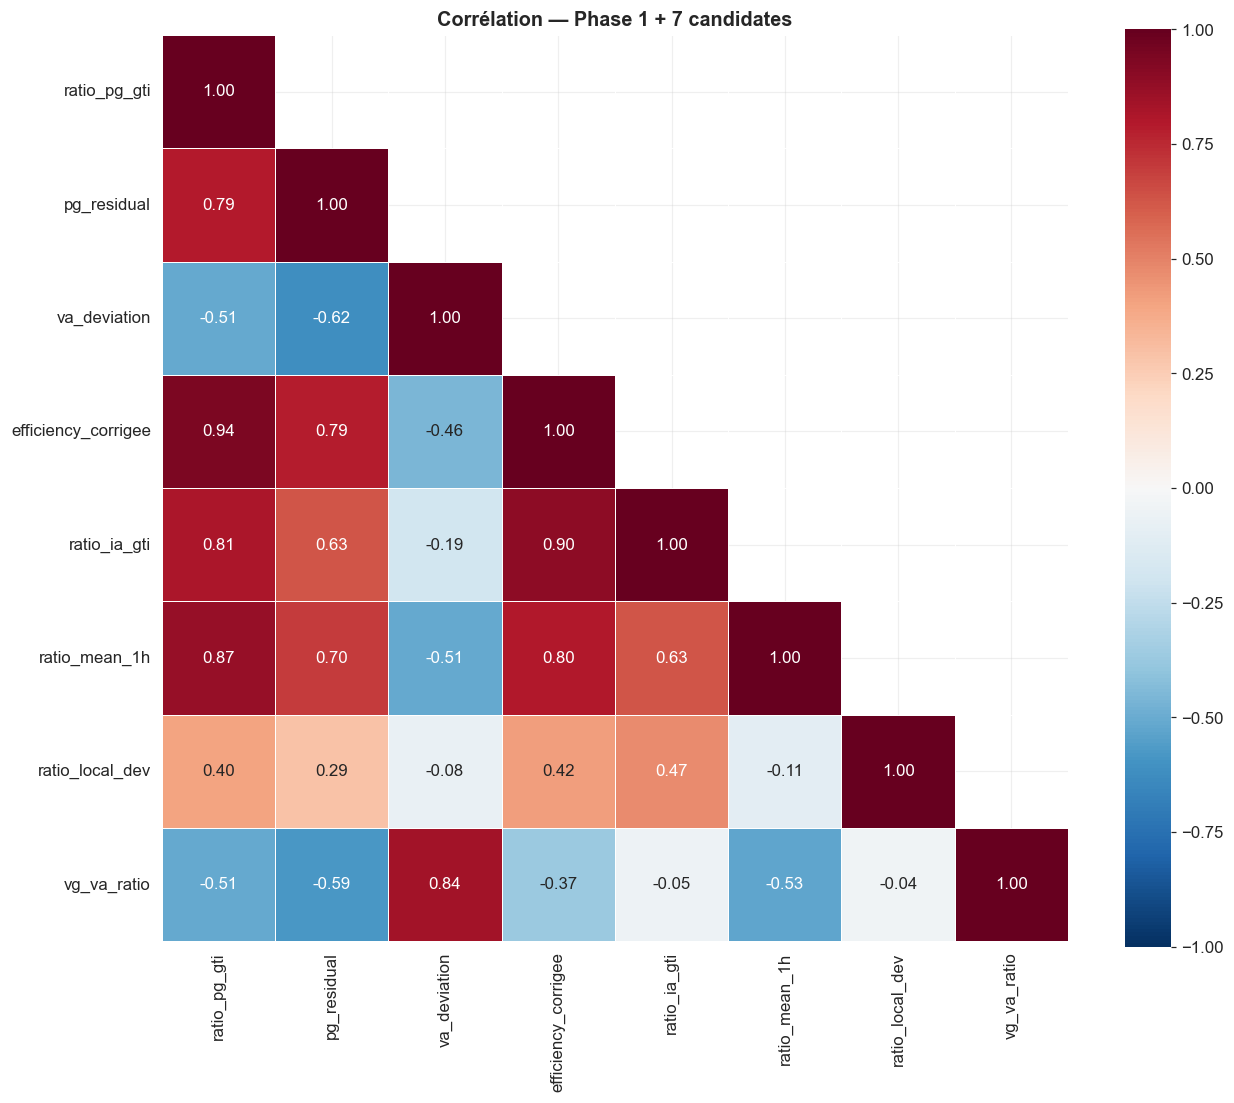

In [39]:
import seaborn as sns

corr_cols = FEATURES_PHASE1 + CANDIDATE_NAMES
corr_check = dev[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_check, dtype=bool), k=1)
sns.heatmap(corr_check, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            mask=mask, square=True, ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title("Corrélation — Phase 1 + 7 candidates", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


#### 6.2.5 Scatter plots — Fault 3.1 vs 3.2 dans l'espace des candidates retenues


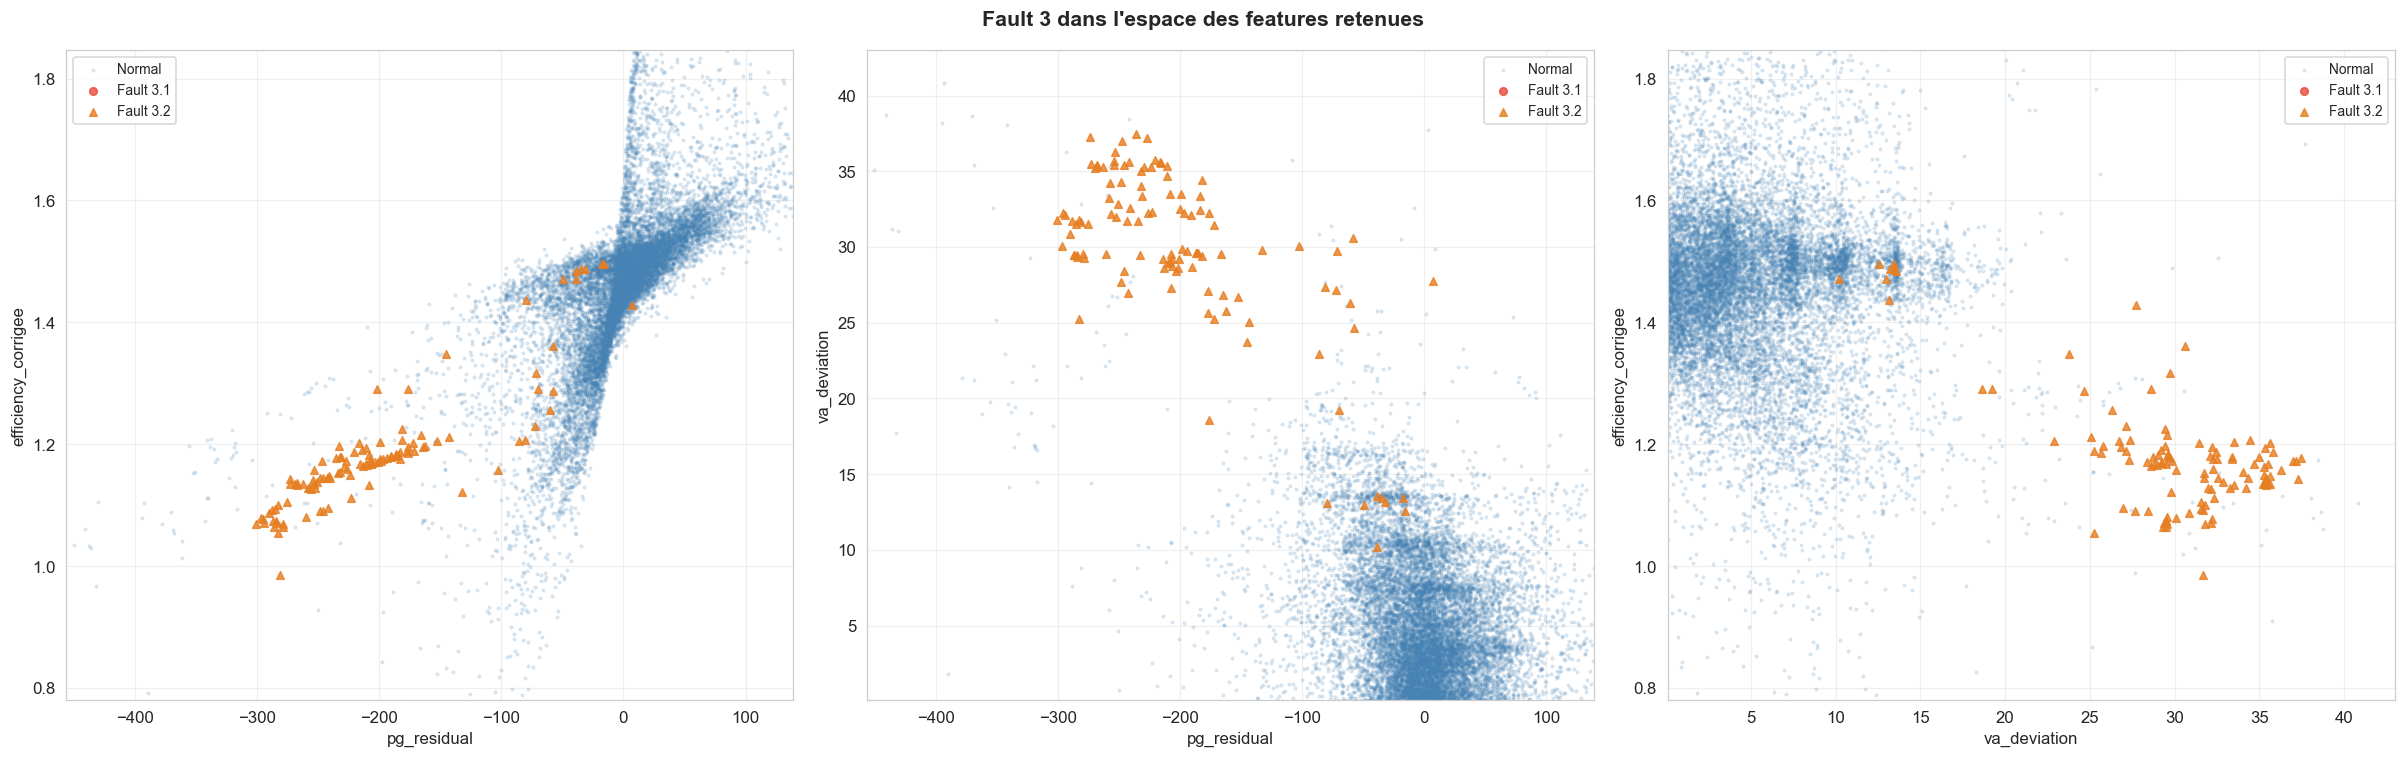

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Fault 3 dans l'espace des features retenues", fontsize=14, fontweight="bold")

pairs = [
    ("pg_residual", "efficiency_corrigee"),
    ("pg_residual", "va_deviation"),
    ("va_deviation", "efficiency_corrigee"),
]

for ax, (fx, fy) in zip(axes, pairs):
    ax.scatter(normal[fx], normal[fy], s=3, alpha=0.15, c="#4682B4", label="Normal")
    ax.scatter(fault31[fx], fault31[fy], s=25, alpha=0.8, c="#E74C3C", label="Fault 3.1", marker="o")
    ax.scatter(fault32[fx], fault32[fy], s=25, alpha=0.8, c="#E67E22", label="Fault 3.2", marker="^")
    ax.set_xlim(dev[fx].quantile(0.01), dev[fx].quantile(0.99))
    ax.set_ylim(dev[fy].quantile(0.01), dev[fy].quantile(0.99))
    ax.set_xlabel(fx, fontsize=11); ax.set_ylabel(fy, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

#### 6.2.6 Boxplots — Normal vs Fault 3.1 vs Fault 3.2


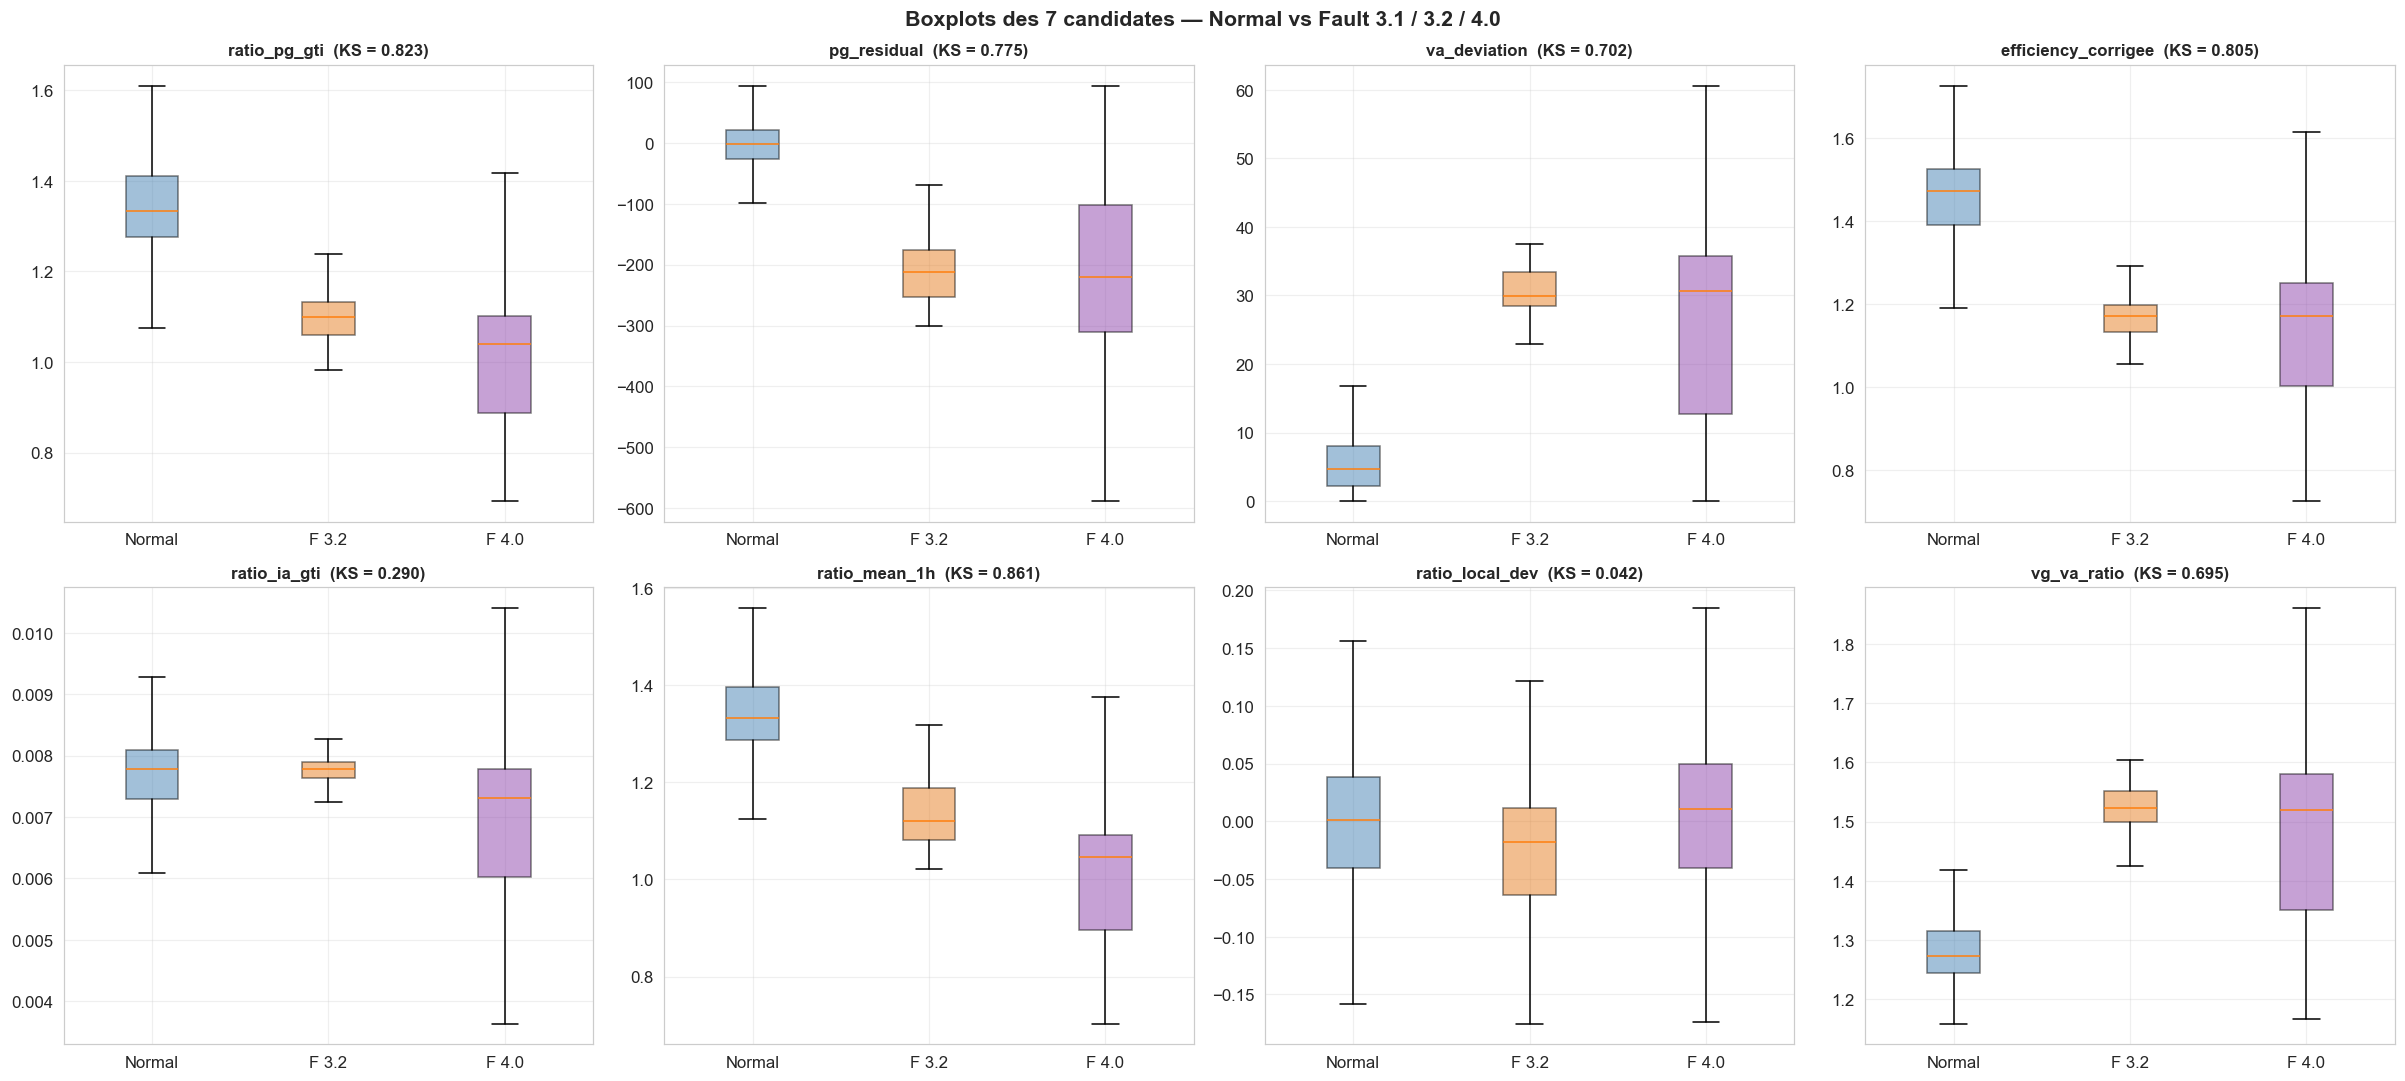

8 features affichées : ['ratio_pg_gti', 'pg_residual', 'va_deviation', 'efficiency_corrigee', 'ratio_ia_gti', 'ratio_mean_1h', 'ratio_local_dev', 'vg_va_ratio']


In [41]:
box_feats = FEATURES_PHASE1[:1] + CANDIDATE_NAMES        
fault4 = dev[dev["Fault"] == 4.0]

groupes_box = [
    ("Normal", normal, "#4682B4"),
    ("F 3.1",  fault31, "#E74C3C"),
    ("F 3.2",  fault32, "#E67E22"),
    ("F 4.0",  fault4,  "#8E44AD"),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Boxplots des 7 candidates — Normal vs Fault 3.1 / 3.2 / 4.0",
             fontsize=14, fontweight="bold")

for ax, feat in zip(axes.flatten()[:len(box_feats)], box_feats):
    data, labels, couleurs = [], [], []
    for nom, sous_ens, couleur in groupes_box:
        d = sous_ens[feat].dropna()
        if len(d) > 0:
            data.append(d.values); labels.append(nom); couleurs.append(couleur)

    bp = ax.boxplot(data, tick_labels=labels, patch_artist=True, showfliers=False)
    for patch, couleur in zip(bp["boxes"], couleurs):
        patch.set_facecolor(couleur); patch.set_alpha(0.5)

    titre = feat
    if "df_ks" in dir() and feat in df_ks["Feature"].values:
        ks = df_ks.loc[df_ks["Feature"] == feat, "KS Toutes anomalies"].iloc[0]
        titre = f"{feat}  (KS = {ks:.3f})"
    ax.set_title(titre, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

for ax in axes.flatten()[len(box_feats):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print(f"{len(box_feats)} features affichées : {box_feats}")

#### 6.2.7 Zoom temporel — Comportement pendant une période Fault 3


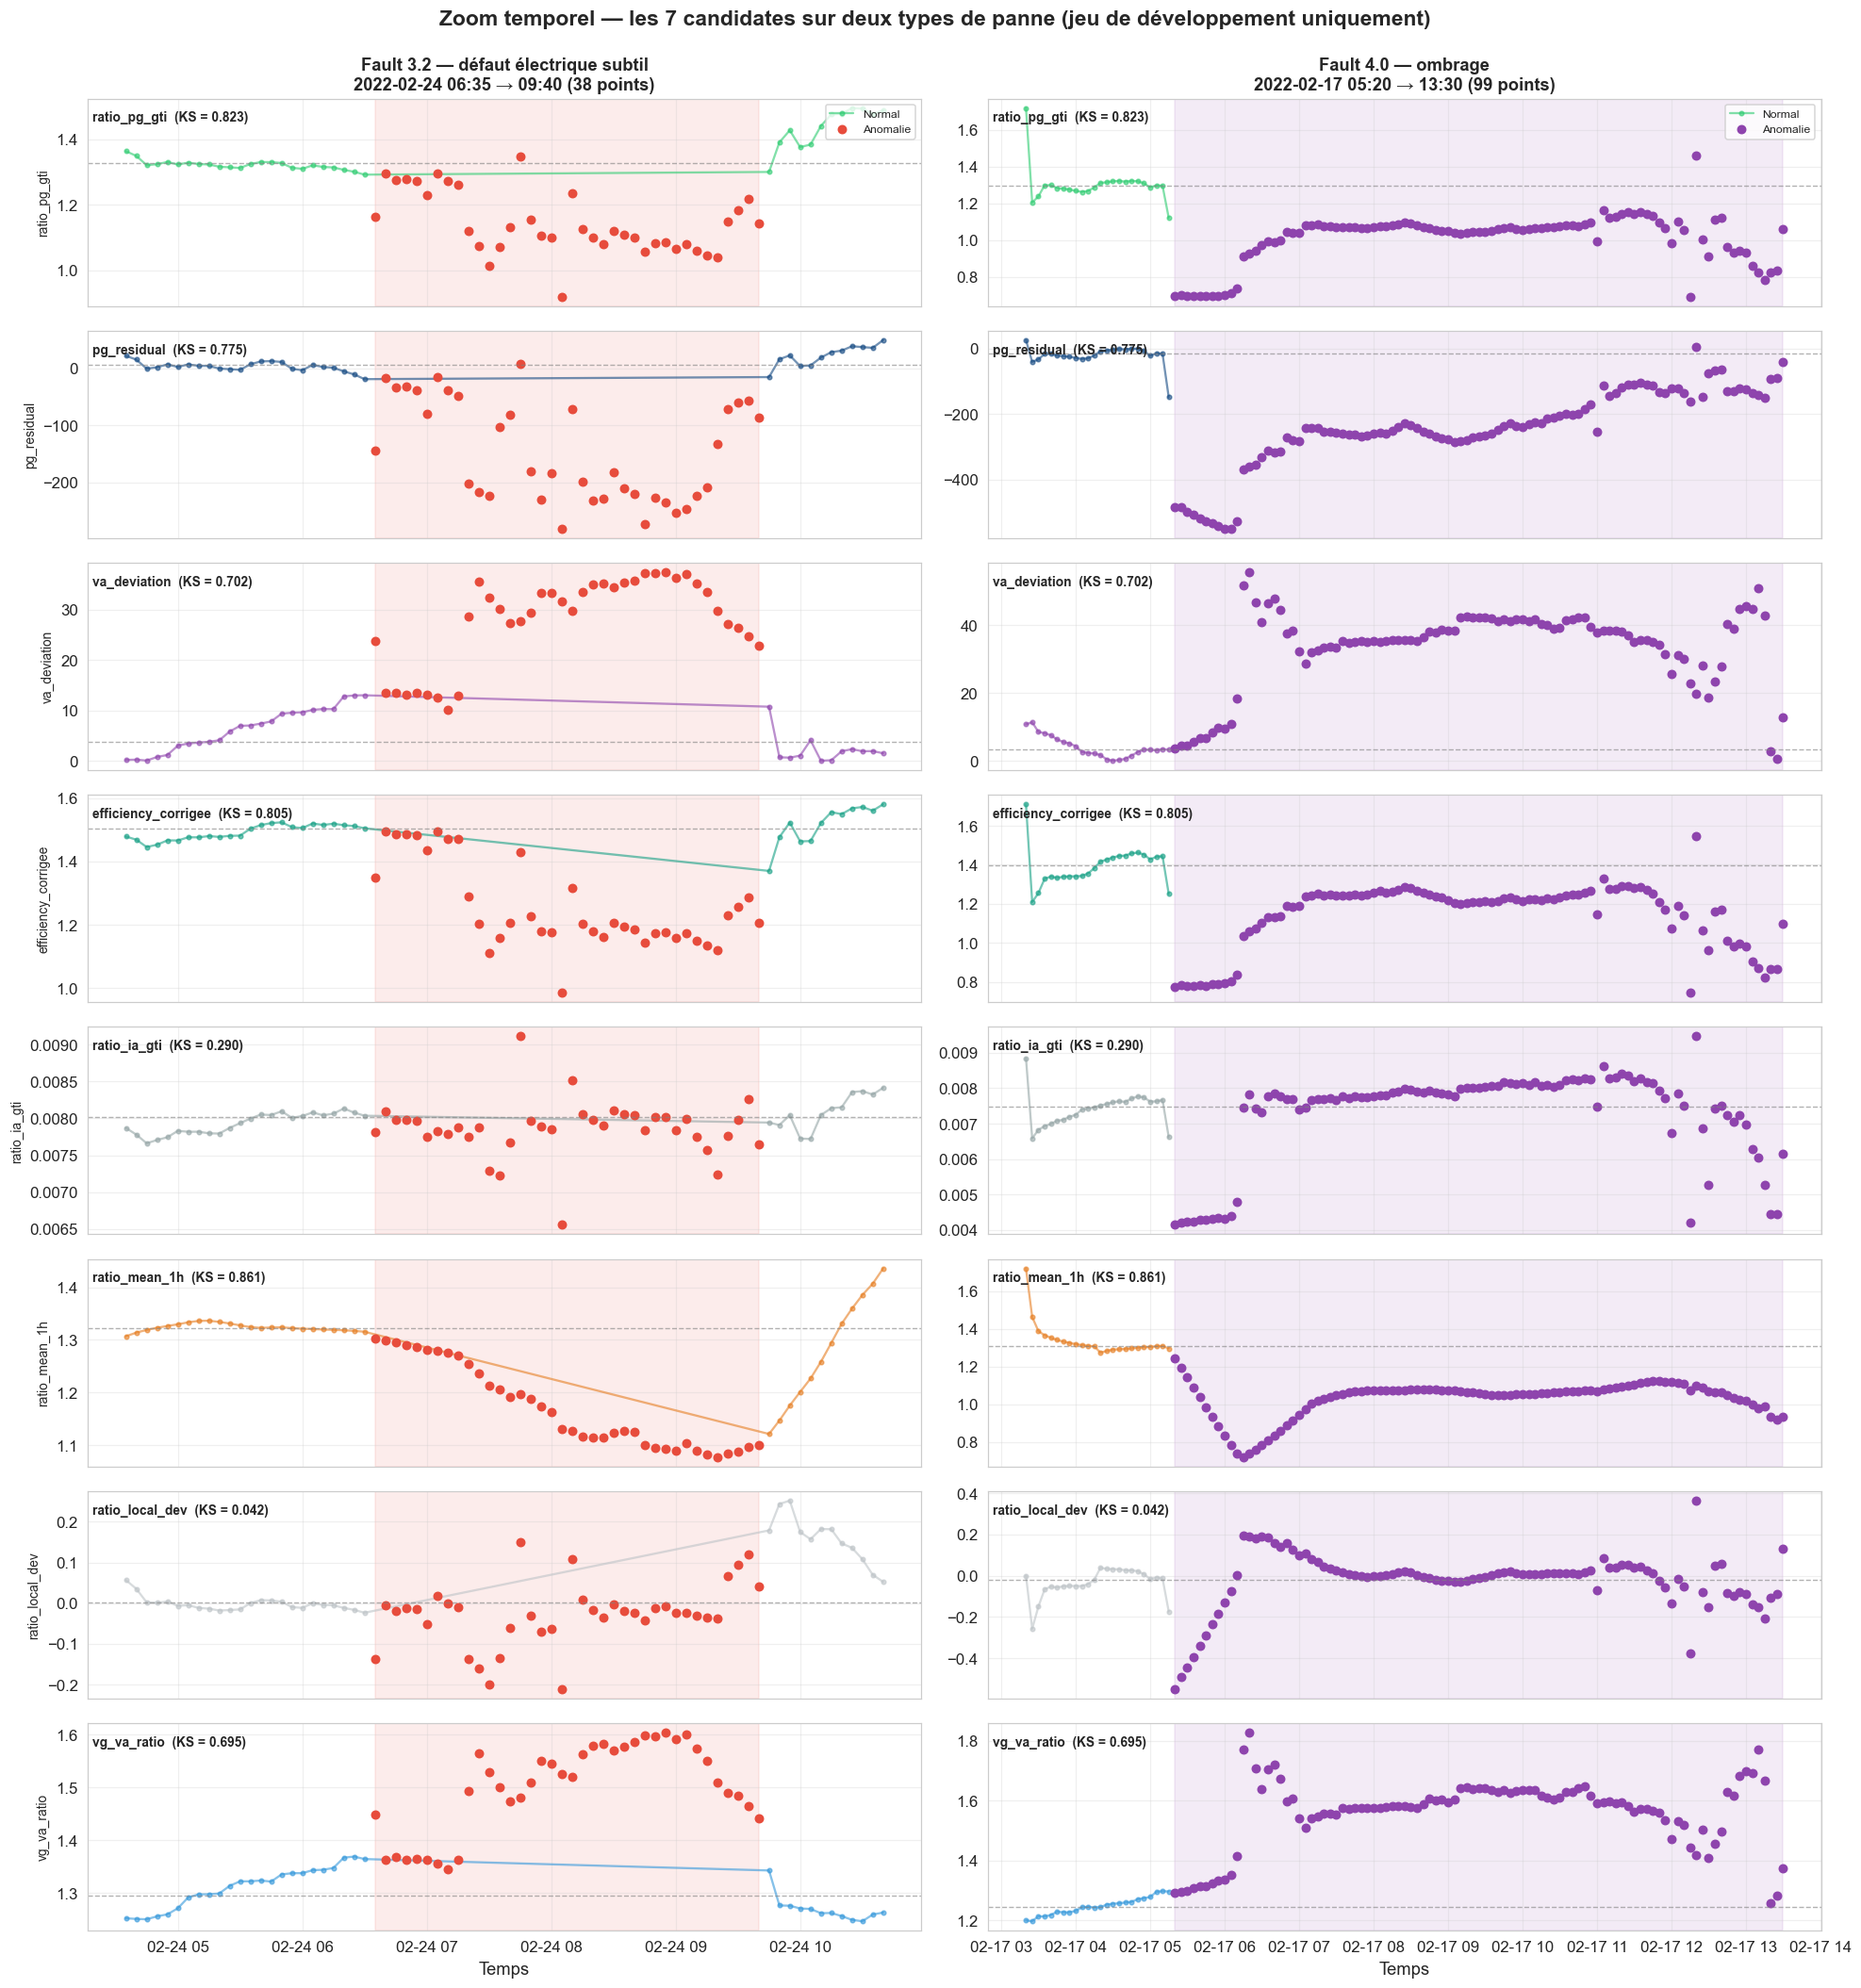

Lecture : une feature utile décroche visiblement pendant la zone colorée.
Comparer les deux colonnes montre qu'aucune candidate ne réagit aux deux
types de panne avec la même netteté — ce qui motive la fusion de modèles.


In [42]:


def _premier_episode(masque, marge_avant="2h", marge_apres="1h"):
    """Fenêtre autour du premier épisode contigu correspondant au masque."""
    sel = dev[masque]
    if len(sel) == 0:
        return None, None, None
    ruptures = sel.index.to_series().diff() > pd.Timedelta("30min")
    ruptures.iloc[0] = True
    debut = sel.index[ruptures][0]
    bloc = sel.loc[debut:]
    fin = bloc.index[(bloc.index.to_series().diff() > pd.Timedelta("30min")).cumsum() == 0][-1]
    fenetre = dev[debut - pd.Timedelta(marge_avant): fin + pd.Timedelta(marge_apres)]
    return fenetre, debut, fin


COULEURS = {
    "ratio_pg_gti":        "#2ECC71",
    "pg_residual":         "#144982",
    "va_deviation":        "#8E44AD",
    "efficiency_corrigee": "#16A085",
    "ratio_ia_gti":        "#95A5A6",
    "ratio_mean_1h":       "#E67E22",
    "ratio_local_dev":     "#BDC3C7",
    "vg_va_ratio":         "#3498DB",
}
plot_vars = FEATURES_PHASE1[:1] + CANDIDATE_NAMES        # 1 + 7 = 8 panneaux

episodes = [
    ("Fault 3.2 — défaut électrique subtil", dev["Fault"] == 3.2, ["#E74C3C"]),
    ("Fault 4.0 — ombrage",                  dev["Fault"] == 4.0, ["#8E44AD"]),
]

fig, axes = plt.subplots(len(plot_vars), len(episodes),
                         figsize=(9 * len(episodes), 2.4 * len(plot_vars)),
                         sharex="col")

for col, (titre, masque, palette) in enumerate(episodes):
    fenetre, debut, fin = _premier_episode(masque)
    if fenetre is None:
        continue
    m_ano = masque.reindex(fenetre.index, fill_value=False)
    m_ok = ~m_ano

    axes[0, col].set_title(
        f"{titre}\n{debut.strftime('%Y-%m-%d %H:%M')} → {fin.strftime('%H:%M')} "
        f"({int(masque.reindex(fenetre.index, fill_value=False).sum())} points)",
        fontsize=12, fontweight="bold")

    for ligne, feat in enumerate(plot_vars):
        ax = axes[ligne, col]
        ax.plot(fenetre.index[m_ok], fenetre[feat][m_ok], "o-",
                color=COULEURS.get(feat, "#666"), markersize=3, alpha=0.6, label="Normal")
        ax.plot(fenetre.index[m_ano], fenetre[feat][m_ano], "o",
                color=palette[0], markersize=5.5, label="Anomalie")

        if m_ano.any():
            ax.axvspan(fenetre.index[m_ano].min(), fenetre.index[m_ano].max(),
                       alpha=0.10, color=palette[0], zorder=0)
        ax.axhline(fenetre[feat][m_ok].median(), color="gray", ls="--", lw=0.9, alpha=0.6)

        # rappel du KS mesuré en 5.2.2, si la cellule a été exécutée
        etiquette = feat
        if "df_ks" in dir() and feat in df_ks["Feature"].values:
            colonne = ("KS Toutes anomalies" if "KS Toutes anomalies" in df_ks.columns
                       else "KS")
            etiquette = f"{feat}  (KS = {df_ks.loc[df_ks['Feature'] == feat, colonne].iloc[0]:.3f})"

        ax.text(0.005, 0.94, etiquette, transform=ax.transAxes, fontsize=9,
                fontweight="bold", va="top")
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.set_ylabel(feat, fontsize=9)
        if ligne == 0:
            ax.legend(loc="upper right", fontsize=8)

    axes[-1, col].set_xlabel("Temps")

fig.suptitle("Zoom temporel — les 7 candidates sur deux types de panne "
             "(jeu de développement uniquement)",
             fontsize=15, fontweight="bold", y=0.997)
plt.tight_layout()
plt.savefig("figures/fig_zoom_temporel.png", dpi=150, bbox_inches="tight")
plt.show()

print("Lecture : une feature utile décroche visiblement pendant la zone colorée.")
print("Comparer les deux colonnes montre qu'aucune candidate ne réagit aux deux")
print("types de panne avec la même netteté — ce qui motive la fusion de modèles.")


#### 6.2.8 — Ablation : valider le choix des features par leur effet sur l'IF


Lignes écartées pour NaN : train 132, val 51
ajustement (sain) : 9,494 pts
éval. validation  : 4,168 pts | 176 anomalies (4.2%) | 4 pannes
baseline PR-AUC val (aléatoire) : 0.042
test              : 2,975 pts — NON OUVERT



Configuration                    n        PR-AUC val    lift   minpts
                                        (base 0.042)   ×base      val
10 capteurs seuls               10   0.206±0.022    4.9×       0
+ Phase 1 complète (14)         14   0.191±0.030    4.5×       0
+ ratio_pg_gti seul (11)        11   0.278±0.034    6.6×       0
13 : avec efficiency            14   0.493±0.038   11.7×      22
13 : avec vg_va                 14   0.534±0.025   12.6×      23
14 : + ratio_mean_1h            15   0.518±0.025   12.3×      24
sans DTI,Ia,Ig,Fg,GTI           10   0.545±0.016   12.9×      24
6 : essentielles + TA + rm       6   0.556±0.007   13.2×      24
5 : essentielles + TA            5   0.564±0.011   13.4×      25
4 : essentielles                 4   0.564±0.006   13.3×      25
7 : les 6 + ratio_ia_gti         7   0.529±0.016   12.5×      24
7 : les 6 + ratio_local_dev      7   0.536±0.014   12.7×      24
8 : les 6 + les deux             8   0.474±0.027   11.2×      23

Éliminées par 

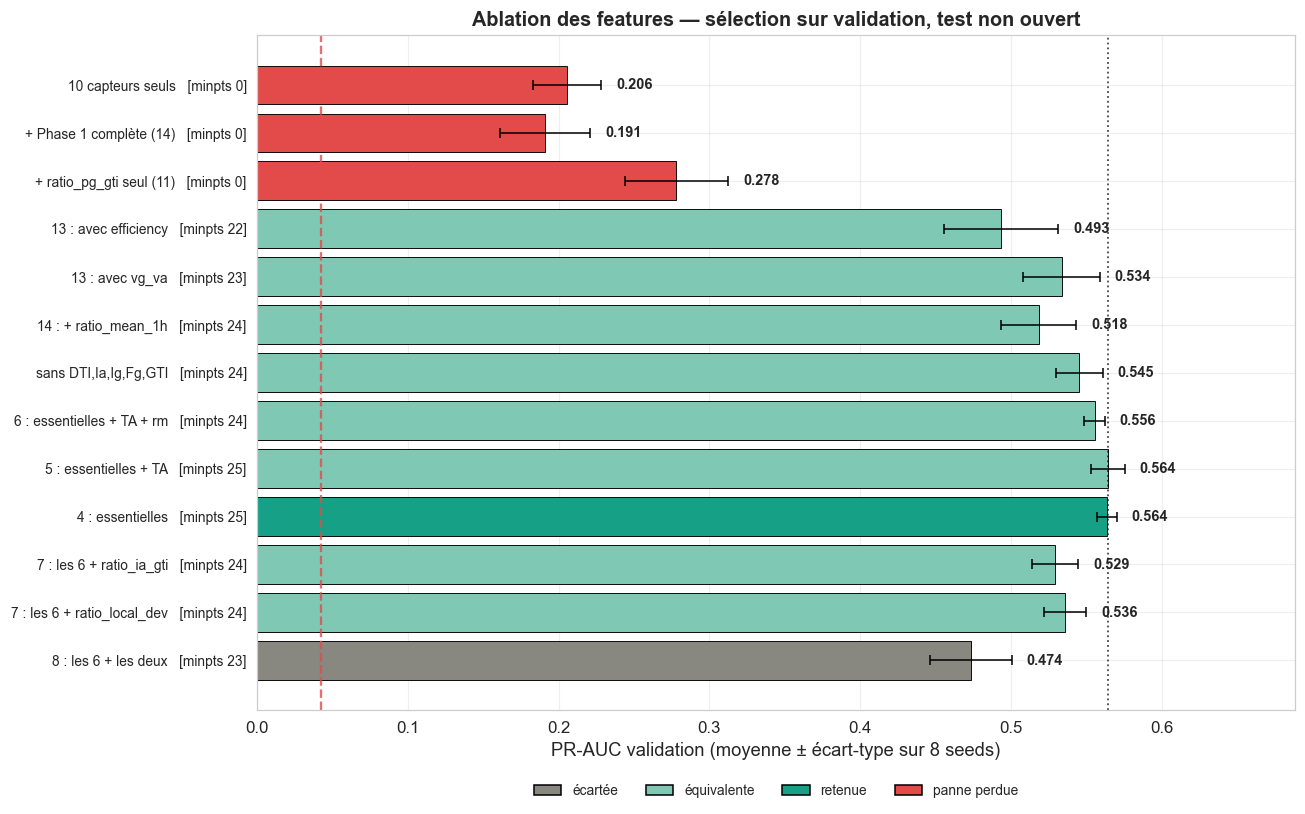

In [43]:
# =============================================================
# 6.2.8 — Ablation : valider le choix des features par leur effet sur l'IF
# =============================================================
_CANDS = FEATURES_CAPTEURS + FEATURES_PHASE1_CANDIDATES + CANDIDATE_NAMES

_ok_tr = train[_CANDS].notna().all(axis=1)
_ok_va = val[_CANDS].notna().all(axis=1)
_tr, _val = train[_ok_tr], val[_ok_va]
if (~_ok_tr).sum() or (~_ok_va).sum():
    print(f"Lignes écartées pour NaN : train {int((~_ok_tr).sum())}, val {int((~_ok_va).sum())}")

# --- ajustement IF : uniquement points SAINS du train (novelty) ---
_fit = _tr[_tr["Fault"] == 0]

# --- UN SEUL jeu de sélection : la validation. L'ancien "_interne" (15% du
# sain + 100% des anomalies du train) avait une prévalence artificielle (~46%)
# rendant son PR-AUC incomparable au val (~4%). Le PR-AUC dépend de la
# prévalence ; le val, chronologique et réaliste, est le seul juge légitime. ---
_EVAL = {"val": _val}
_Y = {k: (d["Fault"] != 0).astype(int).values for k, d in _EVAL.items()}
_BASE = {k: float(y.mean()) for k, y in _Y.items()}   # baseline PR-AUC = prévalence

assert _val.index.max() <= val.index.max(),         "fuite : _val dépasse val"
assert len(set(_val.index) & set(test.index)) == 0, "fuite : points de test dans _val"
assert all(y.sum() > 0 for y in _Y.values())

# decouper_episodes est la fonction canonique définie dans la cellule
# « Fonctions utilitaires » (§ 5) : elle n'est pas redéfinie ici.
_EPS = {k: decouper_episodes(_EVAL[k].index, _Y[k]) for k in _EVAL}

print(f"ajustement (sain) : {len(_fit):,} pts")
print(f"éval. validation  : {len(_val):,} pts | {_Y['val'].sum()} anomalies "
      f"({100*_BASE['val']:.1f}%) | {len(_EPS['val'])} pannes")
print(f"baseline PR-AUC val (aléatoire) : {_BASE['val']:.3f}")
print(f"test              : {len(test):,} pts — NON OUVERT\n")


def _evalue(feats, seeds=range(8)):
    """PR-AUC val + lift (PR-AUC / baseline) + minpts, moyennés sur seeds."""
    _sc = StandardScaler().fit(_fit[feats])
    _Xf = _sc.transform(_fit[feats])
    lignes = []
    for s in seeds:
        m = IsolationForest(n_estimators=150, max_samples=1024, contamination="auto",
                            random_state=s, n_jobs=-1).fit(_Xf)
        seuil = np.quantile(-m.score_samples(_Xf), 0.995)
        score = -m.score_samples(_sc.transform(_EVAL["val"][feats]))
        ap = average_precision_score(_Y["val"], score)
        mp = min(int((score[a:b] >= seuil).sum()) for a, b in _EPS["val"])
        lignes.append([ap, mp])
    a = np.asarray(lignes, dtype=float)
    _m = a[:, 0].mean()
    return {"n": len(feats), "val": _m, "val_sd": a[:, 0].std(),
            "lift": _m / _BASE["val"], "minpts_val": int(a[:, 1].min())}


# _ESS : Va retiré (redondant avec va_deviation = |Va - médiane(Va)|)
_ESS = ["pg_residual", "ratio_pg_gti", "va_deviation", "vg_va_ratio"]
_B4  = ["pg_residual", "va_deviation", "vg_va_ratio", "ratio_mean_1h"]
_SEPT = _ESS + ["TA", "ratio_mean_1h"]

configs = {
    "10 capteurs seuls":            FEATURES_CAPTEURS,
    "+ Phase 1 complète (14)":      FEATURES_CAPTEURS + FEATURES_PHASE1_CANDIDATES,
    "+ ratio_pg_gti seul (11)":     FEATURES_CAPTEURS + ["ratio_pg_gti"],
    "13 : avec efficiency":         FEATURES_CAPTEURS + ["ratio_pg_gti", "pg_residual",
                                                        "va_deviation", "efficiency_corrigee"],
    "13 : avec vg_va":              FEATURES_CAPTEURS + ["ratio_pg_gti", "pg_residual",
                                                        "va_deviation", "vg_va_ratio"],
    "14 : + ratio_mean_1h":         FEATURES_CAPTEURS + ["ratio_pg_gti"] + _B4,
    "sans DTI,Ia,Ig,Fg,GTI":        [f for f in FEATURES_CAPTEURS
                                     if f not in ["DTI", "Ia", "Ig", "Fg", "GTI"]]
                                    + ["ratio_pg_gti"] + _B4,
    "6 : essentielles + TA + rm":   _SEPT,
    "5 : essentielles + TA":        _ESS + ["TA"],
    "4 : essentielles":             _ESS,
    "7 : les 6 + ratio_ia_gti":     _SEPT + ["ratio_ia_gti"],
    "7 : les 6 + ratio_local_dev":  _SEPT + ["ratio_local_dev"],
    "8 : les 6 + les deux":         _SEPT + ["ratio_ia_gti", "ratio_local_dev"],
}

resultats = {nom: _evalue(feats) for nom, feats in configs.items()}

print(f"{'Configuration':<30}{'n':>4}{'PR-AUC val':>18}{'lift':>8}{'minpts':>9}")
print(f"{'':<30}{'':>4}{'(base '+format(_BASE['val'],'.3f')+')':>18}{'×base':>8}{'val':>9}")
for nom, r in resultats.items():
    print(f"{nom:<30}{r['n']:>4}   {r['val']:.3f}±{r['val_sd']:.3f}"
          f"{r['lift']:>7.1f}×{r['minpts_val']:>8}")

_sur = {k: r for k, r in resultats.items() if r["minpts_val"] >= 1}
_elim = set(resultats) - set(_sur)
if _elim:
    print(f"\nÉliminées par le garde-fou (panne manquée) : {sorted(_elim)}")

_ref = max(_sur, key=lambda k: _sur[k]["val"])
_v_ref, _sd_ref = _sur[_ref]["val"], _sur[_ref]["val_sd"]
_admis = {k: r for k, r in _sur.items()
          if r["val"] >= _v_ref - 2 * np.sqrt(_sd_ref ** 2 + r["val_sd"] ** 2)}
_best = min(_admis, key=lambda k: (_admis[k]["n"], -_admis[k]["val"]))

print(f"\nMeilleure PR-AUC val : {_ref} ({_v_ref:.4f}±{_sd_ref:.4f}, lift ×{_sur[_ref]['lift']:.1f})")
print(f"\n{len(_admis)} config(s) équivalente(s) à 2 écarts-types :")
for k in sorted(_admis, key=lambda k: _admis[k]["n"]):
    r = _admis[k]
    print(f"   {r['n']:>2} features   {r['val']:.4f}±{r['val_sd']:.4f}   "
          f"lift ×{r['lift']:.1f}   minpts {r['minpts_val']}   {k}")

print(f"\n>>> RETENUE PAR PARCIMONIE : {_best}")
print(f"    {resultats[_best]['n']} features | PR-AUC val {resultats[_best]['val']:.4f}"
      f" | lift ×{resultats[_best]['lift']:.1f}"
      f" | écart : {resultats[_best]['val'] - _v_ref:+.4f}"
      f" | minpts {resultats[_best]['minpts_val']}")
print(f"    {configs[_best]}")

# --- effet mesuré de l'ajout de ratio_ia_gti (repris en 6.2.9) ---
ABLATION_MINPTS = {k: resultats[k]["minpts_val"] for k in resultats}
ABLATION_PRAUC  = {k: resultats[k]["val"] for k in resultats}

_noms = list(resultats)
_vals = [resultats[n]["val"] for n in _noms]
_sds = [resultats[n]["val_sd"] for n in _noms]
_coul = ["#16A085" if n == _best else "#7FC9B4" if n in _admis
         else "#E24B4A" if n in _elim else "#888780" for n in _noms]
fig, ax = plt.subplots(figsize=(12, 7.5))
_y = np.arange(len(_noms))
ax.barh(_y, _vals, xerr=_sds, color=_coul, edgecolor="black", linewidth=0.6,
        error_kw=dict(ecolor="black", capsize=3, lw=1))
ax.axvline(_v_ref, color="black", ls=":", lw=1.2, alpha=0.7)
ax.axvline(_BASE["val"], color="#E24B4A", ls="--", lw=1.5, alpha=0.8,
           label=f"baseline aléatoire ({_BASE['val']:.3f})")
ax.set_yticks(_y)
ax.set_yticklabels([f"{n}   [minpts {resultats[n]['minpts_val']}]" for n in _noms], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("PR-AUC validation (moyenne ± écart-type sur 8 seeds)")
ax.set_xlim(0, max(_vals) * 1.22)
ax.set_title("Ablation des features — sélection sur validation, test non ouvert",
             fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
for yy, v, s in zip(_y, _vals, _sds):
    ax.text(v + s + 0.010, yy, f"{v:.3f}", va="center", fontsize=9.5, fontweight="bold")
_leg = [Patch(facecolor="#888780", edgecolor="black", label="écartée"),
        Patch(facecolor="#7FC9B4", edgecolor="black", label="équivalente"),
        Patch(facecolor="#16A085", edgecolor="black", label="retenue")]
if _elim:
    _leg.append(Patch(facecolor="#E24B4A", edgecolor="black", label="panne perdue"))
ax.legend(handles=_leg, loc="upper center", bbox_to_anchor=(0.5, -0.09),
          ncol=len(_leg), fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig("figures/fig_if_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

del _ok_tr, _ok_va, _tr, _val, _fit, _EVAL, _Y, _EPS, _BASE
del _B4, _ESS, _SEPT, _CANDS, _sur, _elim, _ref, _v_ref, _sd_ref

### 6.2.9 — Features retenues et figeage du dataset


In [44]:
# =============================================================
# 6.2.9 — Features retenues et figeage du dataset
#
# Deux décisions distinctes, à ne pas confondre :
#
#   FEATURES_ML  = le SUR-ENSEMBLE stocké dans le dataset. Chaque modèle y
#                  puisera le sous-ensemble qui lui convient. Il ne doit donc
#                  pas être réduit au jeu optimal d'un seul modèle.
#
#   FEATURES_IF  = le sous-ensemble utilisé par l'Isolation Forest, issu de
#                  l'ablation 6.2.8. L'autoencodeur en prendra un AUTRE : les
#                  deux détecteurs ne regardent pas les mêmes variables, et
#                  c'est précisément cette divergence qui les rend
#                  complémentaires, donc fusionnables. Le jeu de l'AE est
#                  sélectionné par sa propre ablation en § 9.1 ; les PR-AUC
#                  comparés y sont affichés par le code, pas écrits ici.
#
# La sélection provient de 6.2.8 (variable _best) : elle n'est pas écrite en
# dur, pour qu'une modification des données ou du protocole la recalcule.
# =============================================================

# --- candidates écartées : retirées du dataset ---
# ratio_ia_gti    : KS faible (cf. df_ks en 6.2.2). Ia et GTI sont corrélées à
#                   0,997 (cf. 6.2.4), leur ratio est quasi constant et n'a
#                   presque pas de variance à exploiter. L'intuition physique
#                   était bonne, la réalisation ne pouvait pas fonctionner.
#                   Son effet mesuré sur minpts est affiché ci-dessous.
# ratio_local_dev : KS très faible — indiscernable du bruit (cf. df_ks).
# efficiency_corrigee : redondante avec ratio_pg_gti (corrélation affichée
#                   ci-dessous). L'ablation ne la départage pas des autres :
#                   le critère retenu est la non-redondance, pas un écart de
#                   performance.
_p1_ecartees = [c for c in FEATURES_PHASE1_CANDIDATES if c not in FEATURES_PHASE1]
cols_drop = ["ratio_ia_gti", "ratio_local_dev", "efficiency_corrigee"] + _p1_ecartees

# --- justifications chiffrées, recalculées (aucune valeur en dur) ---
_ks_of = lambda f: float(df_ks.loc[df_ks["Feature"] == f, "KS Toutes anomalies"].iloc[0])
print("Justification des retraits (valeurs recalculées) :")
print(f"  ratio_ia_gti     KS = {_ks_of('ratio_ia_gti'):.3f}  | "
      f"corr(Ia, GTI) = {dev['Ia'].corr(dev['GTI']):.3f}")
print(f"  ratio_local_dev  KS = {_ks_of('ratio_local_dev'):.3f}")
print(f"  efficiency_corrigee  corr avec ratio_pg_gti = "
      f"{dev['efficiency_corrigee'].corr(dev['ratio_pg_gti']):.3f}")
print(f"  ajout de ratio_ia_gti au jeu à 6 features : minpts "
      f"{ABLATION_MINPTS['6 : essentielles + TA + rm']} -> "
      f"{ABLATION_MINPTS['7 : les 6 + ratio_ia_gti']}, PR-AUC "
      f"{ABLATION_PRAUC['6 : essentielles + TA + rm']:.3f} -> "
      f"{ABLATION_PRAUC['7 : les 6 + ratio_ia_gti']:.3f}")

print(f"\nCandidates Phase 1 écartées retirées du CSV : {_p1_ecartees}")
df.drop(columns=[c for c in cols_drop if c in df.columns], inplace=True)

# --- jeu de features figé ---
FEATURES_PHASE2_KEPT = ["pg_residual", "va_deviation", "vg_va_ratio", "ratio_mean_1h"]
FEATURES_ENG = FEATURES_PHASE1 + FEATURES_PHASE2_KEPT
FEATURES_ML  = FEATURES_CAPTEURS + FEATURES_ENG

# --- sous-ensemble retenu pour l'Isolation Forest (issu de 6.2.8) ---
try:
    FEATURES_IF = list(configs[_best])
    print(f"Jeu IF issu de l'ablation 6.2.8 : {_best}")
except NameError:
    raise RuntimeError("Exécuter 6.2.8 avant cette cellule : _best et configs "
                       "proviennent de l'ablation.")

# --- contrôles avant sauvegarde ---
_manquantes = [c for c in FEATURES_ML + FEATURES_IF if c not in df.columns]
assert not _manquantes, f"colonnes absentes du DataFrame : {_manquantes}"

_hors = [c for c in FEATURES_IF if c not in FEATURES_ML]
assert not _hors, f"FEATURES_IF sort du sur-ensemble FEATURES_ML : {_hors}"

_nan = df[FEATURES_ML].isna().sum()
assert _nan.max() == 0 or _nan.max() / len(df) < 0.005, \
    f"trop de NaN introduits :\n{_nan[_nan > 0]}"

print(f"\nDataset final : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"\n=== {len(FEATURES_ML)} features ML (sur-ensemble figé) ===")
print(f"  {len(FEATURES_CAPTEURS):>2} capteurs bruts : {FEATURES_CAPTEURS}")
print(f"  {len(FEATURES_ENG):>2} engineered     : {FEATURES_ENG}")
print(f"\n=== {len(FEATURES_IF)} features retenues pour l'Isolation Forest ===")
print(f"  {FEATURES_IF}")
print(f"  écartées du sur-ensemble : {[c for c in FEATURES_ML if c not in FEATURES_IF]}")
print(f"\nNaN dans FEATURES_ML : {int(_nan.sum())}")

print(f"\n=== Statistiques des features engineered ===")
print(df[FEATURES_ENG].describe().round(3))

# --- sauvegarde ---
# --- garde-fou : aucune colonne de travail ne doit être persistée dans le CSV
#     (sinon elle repollue df au rechargement à la prochaine exécution
#     — c'était la cause du bug "test avec split=train"). ---
_cols_travail = ["split", "is_anomaly", "incident_group", "fgroup"]
_a_purger = [c for c in _cols_travail if c in df.columns]
if _a_purger:
    print(f"Colonnes de travail retirées avant sauvegarde : {_a_purger}")
    df = df.drop(columns=_a_purger)
df.to_csv("data/cleaned_with_features.csv")
print(f"\nSauvegardé : data/cleaned_with_features.csv")
print(f"Colonnes finales : {df.columns.tolist()}")

# =============================================================
# Réextraction de train / val / test après le figeage
# =============================================================
# Des colonnes viennent d'être retirées de df. Sans cette réextraction, df et
# train/val/test divergeraient : les partitions garderaient des features
# supprimées. Ce n'est pas une fuite, mais un état incohérent — et les asserts
# ci-dessous le rendent impossible.
train = df.loc[train.index]
val   = df.loc[val.index]
test  = df.loc[test.index]
assert set(train.columns) == set(df.columns)
assert set(val.columns)   == set(df.columns)
assert set(test.columns)  == set(df.columns)
print(f"\ntrain/val/test réextraits depuis df : "
      f"{len(train):,} / {len(val):,} / {len(test):,} lignes, "
      f"{df.shape[1]} colonnes chacun")

del _manquantes, _hors, _nan

Justification des retraits (valeurs recalculées) :
  ratio_ia_gti     KS = 0.290  | corr(Ia, GTI) = 0.978
  ratio_local_dev  KS = 0.042
  efficiency_corrigee  corr avec ratio_pg_gti = 0.944
  ajout de ratio_ia_gti au jeu à 6 features : minpts 24 -> 24, PR-AUC 0.556 -> 0.529

Candidates Phase 1 écartées retirées du CSV : ['delta_tpv_ta', 'pg_diff', 'ratio_std_30min']
Jeu IF issu de l'ablation 6.2.8 : 4 : essentielles

Dataset final : 52,959 lignes x 17 colonnes

=== 15 features ML (sur-ensemble figé) ===
  10 capteurs bruts : ['DTI', 'GTI', 'TA', 'TPV', 'Ia', 'Ig', 'Pg', 'Va', 'Vg', 'Fg']
   5 engineered     : ['ratio_pg_gti', 'pg_residual', 'va_deviation', 'vg_va_ratio', 'ratio_mean_1h']

=== 4 features retenues pour l'Isolation Forest ===
  ['pg_residual', 'ratio_pg_gti', 'va_deviation', 'vg_va_ratio']
  écartées du sur-ensemble : ['DTI', 'GTI', 'TA', 'TPV', 'Ia', 'Ig', 'Pg', 'Va', 'Vg', 'Fg', 'ratio_mean_1h']

NaN dans FEATURES_ML : 0

=== Statistiques des features engineered ===
   


Sauvegardé : data/cleaned_with_features.csv
Colonnes finales : ['DTI', 'GTI', 'TA', 'TPV', 'Ia', 'Ig', 'Eg', 'Fg', 'Pg', 'Va', 'Vg', 'Fault', 'ratio_pg_gti', 'pg_residual', 'va_deviation', 'ratio_mean_1h', 'vg_va_ratio']

train/val/test réextraits depuis df : 10,863 / 4,219 / 2,975 lignes, 17 colonnes chacun


In [45]:
# =============================================================
# 6.2.9bis — Diagnostic : valeurs extrêmes de va_deviation (audit)
# =============================================================
# va_deviation = |Va - médiane(Va sain train)|. Un maximum de l'ordre de 180 V
# est énorme au regard de la médiane. On vérifie si ces extrêmes sont des
# ANOMALIES (Fault≠0, à garder) ou des ARTEFACTS (capteur déconnecté, Va≈0,
# à filtrer au nettoyage).
_seuil = df["va_deviation"].quantile(0.999)
_ext = df[df["va_deviation"] > _seuil]
print(f"Médiane de va_deviation : {df['va_deviation'].median():.1f} | "
      f"maximum : {df['va_deviation'].max():.1f}")
print(f"Seuil p99.9 : {_seuil:.1f} | points au-dessus : {len(_ext)}")
if len(_ext):
    _na = int((_ext["Fault"] != 0).sum()); _no = int((_ext["Fault"] == 0).sum())
    print(f"  anomalies (Fault≠0) : {_na} | normaux (Fault==0) : {_no}")
    print(f"  Va sur ces points : min={_ext['Va'].min():.1f}, max={_ext['Va'].max():.1f}")
    if _no > _na:
        print("  Majorité NORMAUX -> probable artefact. Envisager un filtre Va au nettoyage.")
    else:
        print("  Majorité ANOMALIES -> va_deviation capture un vrai signal, à conserver.")
del _seuil, _ext

Médiane de va_deviation : 5.4 | maximum : 181.0
Seuil p99.9 : 57.5 | points au-dessus : 53
  anomalies (Fault≠0) : 52 | normaux (Fault==0) : 1
  Va sur ces points : min=2.1, max=125.6
  Majorité ANOMALIES -> va_deviation capture un vrai signal, à conserver.


Échantillon t-SNE : 3,421 points (2,000 sains + 1,421 anomalies)
Types présents : [np.float64(1.0), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(3.2), np.float64(4.0)]
Fault 3.1 : absent du jeu de développement (100 % dans le test)



  projection calculée : AVANT — 10 capteurs bruts


  projection calculée : APRÈS — 4 features retenues


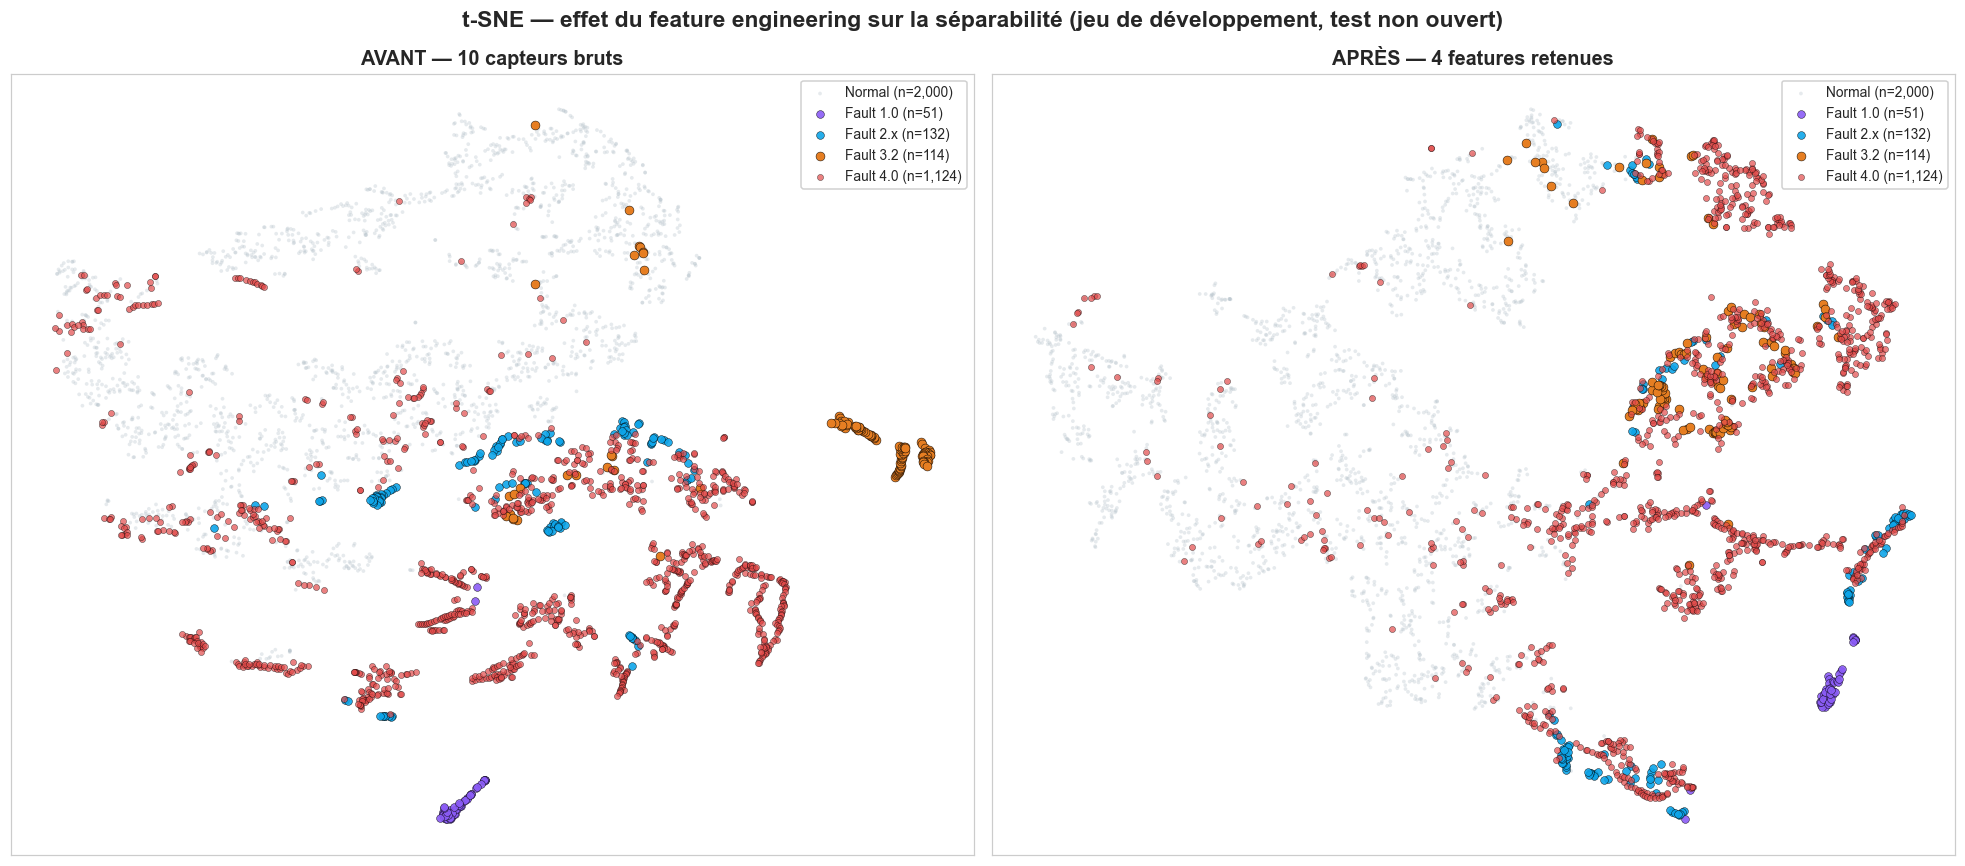


Lecture : t-SNE est une aide à l'intuition, pas une preuve. Il est
stochastique et ne préserve pas les distances globales — la démonstration
quantitative reste l'ablation 6.2.8.


In [46]:
# =============================================================
# 6.2.10 — t-SNE : ce que le feature engineering a changé
#
# Comparaison AVANT / APRÈS sur le jeu de développement uniquement.
#   AVANT : les capteurs bruts
#   APRÈS : les features retenues pour l'Isolation Forest
#
# Le lot de test n'est pas ouvert. Le type de panne 3.1 en est donc absent :
# il n'existe que dans le test. Une projection « Normal vs 3.1 vs 3.2 »
# relèverait de l'analyse de résultats, pas de la conception — elle a sa place
# dans la section finale, comme illustration du test de généralisation.
#
# Lecture attendue : si le feature engineering est utile, les anomalies doivent
# former des amas mieux séparés du nuage sain APRÈS qu'AVANT.
#
# Note : t-SNE est stochastique et ne préserve pas les distances globales.
# C'est une aide à l'intuition, pas une preuve — la preuve est l'ablation 6.2.8.
# =============================================================
_N_SAIN = 2000          # sous-échantillon des points sains, pour la lisibilité
_PERPLEXITE = 30
_SEED = 42

# --- jeux de features à comparer ---
_projections = {
    f"AVANT — {len(FEATURES_CAPTEURS)} capteurs bruts": FEATURES_CAPTEURS,
    f"APRÈS — {len(FEATURES_IF)} features retenues":    FEATURES_IF,
}

# --- groupes présents dans dev ---
_dev = pd.concat([train, val]).sort_index()
_groupes = [
    ("Normal",        _dev["Fault"] == 0,                        "#B8C4CC", 6,  0.35),
    ("Fault 1.0",     _dev["Fault"] == 1.0,                      "#8B5CF6", 26, 0.9),
    ("Fault 2.x",     _dev["Fault"].isin([2.1, 2.2, 2.3]),       "#0EA5E9", 26, 0.9),
    ("Fault 3.2",     _dev["Fault"] == 3.2,                      "#E67E22", 34, 1.0),
    ("Fault 4.0",     _dev["Fault"] == 4.0,                      "#E24B4A", 16, 0.7),
]

# --- échantillonnage : tous les points d'anomalie, un sous-ensemble des sains ---
_idx_sain = _dev.index[_dev["Fault"] == 0]
_rng = np.random.default_rng(_SEED)
if len(_idx_sain) > _N_SAIN:
    _idx_sain = pd.DatetimeIndex(_rng.choice(_idx_sain, _N_SAIN, replace=False)).sort_values()
_idx = _idx_sain.union(_dev.index[_dev["Fault"] != 0])
_ech = _dev.loc[_idx]

print(f"Échantillon t-SNE : {len(_ech):,} points "
      f"({int((_ech['Fault'] == 0).sum()):,} sains + "
      f"{int((_ech['Fault'] != 0).sum()):,} anomalies)")
print(f"Types présents : {sorted(_ech.loc[_ech['Fault'] != 0, 'Fault'].unique())}")
print("Fault 3.1 : absent du jeu de développement (100 % dans le test)\n")

fig, axes = plt.subplots(1, len(_projections), figsize=(9 * len(_projections), 8))
if len(_projections) == 1:
    axes = [axes]

for ax, (titre, feats) in zip(axes, _projections.items()):
    _X = StandardScaler().fit_transform(_ech[feats].values)
    _emb = TSNE(n_components=2, perplexity=_PERPLEXITE, init="pca",
                random_state=_SEED, max_iter=1000).fit_transform(_X)
    _proj = pd.DataFrame(_emb, index=_ech.index, columns=["x", "y"])

    for nom, masque, couleur, taille, alpha in _groupes:
        m = masque.reindex(_ech.index, fill_value=False)
        if not m.any():
            continue
        ax.scatter(_proj.loc[m, "x"], _proj.loc[m, "y"], s=taille, c=couleur,
                   alpha=alpha, label=f"{nom} (n={int(m.sum()):,})",
                   edgecolors="none" if nom == "Normal" else "black",
                   linewidths=0 if nom == "Normal" else 0.3)

    ax.set_title(titre, fontsize=13, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=9, framealpha=0.9)
    print(f"  projection calculée : {titre}")

fig.suptitle("t-SNE — effet du feature engineering sur la séparabilité "
             "(jeu de développement, test non ouvert)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/fig_tsne_avant_apres.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLecture : t-SNE est une aide à l'intuition, pas une preuve. Il est")
print("stochastique et ne préserve pas les distances globales — la démonstration")
print("quantitative reste l'ablation 6.2.8.")

del _N_SAIN, _PERPLEXITE, _SEED, _projections, _groupes, _idx_sain, _rng, _idx, _ech

---
## 7. Normalisation
---

**Pourquoi après le split.** Ajuster un `StandardScaler` sur le dataset complet ferait entrer les statistiques de `val` et `test` dans la transformation du `train` — une fuite qui annulerait l'intérêt du découpage chronologique. Le `fit` se fait donc uniquement sur les données d'entraînement.

**Un scaler par configuration.** Les moyennes et écarts-types doivent refléter les données que chaque modèle voit réellement. Un scaler ajusté sur données saines produit un écart-type plus faible, donc des valeurs normalisées plus extrêmes pour les anomalies. Utiliser le même scaler pour les deux configurations introduirait un biais sans rapport avec la stratégie testée.

### 7.1 — Normalisation Novelty vs Outlier

In [47]:
# =============================================================
# 7.1 — Normalisation : deux stratégies (Novelty vs Outlier)
# =============================================================
# On fige ici les jeux normalisés qui serviront à toute la modélisation.
# Deux scalers, correspondant aux deux stratégies non supervisées comparées :
#
#   NOVELTY : le scaler est ajusté UNIQUEMENT sur les points sains du train.
#             Le modèle apprendra une "normalité pure" (sans anomalies).
#   OUTLIER : le scaler est ajusté sur TOUT le train (sain + anomalies).
#             Le modèle suppose seulement que les anomalies sont rares.
#
# Dans les DEUX cas, val et test sont seulement TRANSFORMÉS (jamais fit) :
# aucune statistique de val/test ne fuit dans la normalisation.

# lignes exploitables (aucun NaN sur les features du modèle)
_ok_tr = train[FEATURES_IF].notna().all(axis=1)
_ok_va = val[FEATURES_IF].notna().all(axis=1)
_ok_te = test[FEATURES_IF].notna().all(axis=1)

train_c = train[_ok_tr].copy()
val_c   = val[_ok_va].copy()
test_c  = test[_ok_te].copy()
print(f"Lignes exploitables — train {len(train_c):,} | val {len(val_c):,} | test {len(test_c):,}")
print(f"Écartées pour NaN   — train {int((~_ok_tr).sum())} | "
      f"val {int((~_ok_va).sum())} | test {int((~_ok_te).sum())}\n")

# sous-ensemble sain du train (base de la stratégie Novelty)
train_sain_c = train_c[train_c["Fault"] == 0]

# --- deux scalers ---
scaler_novelty = StandardScaler().fit(train_sain_c[FEATURES_IF])   # sain seulement
scaler_outlier = StandardScaler().fit(train_c[FEATURES_IF])        # tout le train

# --- matrices normalisées, rangées par stratégie ---
X = {
    "Novelty": {
        "fit":  scaler_novelty.transform(train_sain_c[FEATURES_IF]),  # entraînement (sain)
        "val":  scaler_novelty.transform(val_c[FEATURES_IF]),
        "test": scaler_novelty.transform(test_c[FEATURES_IF]),
    },
    "Outlier": {
        "fit":  scaler_outlier.transform(train_c[FEATURES_IF]),       # entraînement (tout)
        "val":  scaler_outlier.transform(val_c[FEATURES_IF]),
        "test": scaler_outlier.transform(test_c[FEATURES_IF]),
    },
}

# --- vérités terrain (labels binaires) — servent UNIQUEMENT à évaluer ---
y_val  = (val_c["Fault"]  != 0).astype(int).values
y_test = (test_c["Fault"] != 0).astype(int).values

print(f"Features du modèle (FEATURES_IF) : {FEATURES_IF}")
print(f"Prévalence val : {y_val.mean():.3f} | test : {y_test.mean():.3f} (test non ouvert)")

Lignes exploitables — train 10,863 | val 4,219 | test 2,975
Écartées pour NaN   — train 0 | val 0 | test 0

Features du modèle (FEATURES_IF) : ['pg_residual', 'ratio_pg_gti', 'va_deviation', 'vg_va_ratio']
Prévalence val : 0.042 | test : 0.025 (test non ouvert)


In [48]:
# =============================================================
# 7.2 — Garde-fous anti-fuite (contrôle du protocole)
# =============================================================
# Ces asserts échouent bruyamment si le protocole est cassé. Ils sont placés
# juste après la normalisation, c'est-à-dire au point où toutes les décisions
# de découpage et d'ajustement des scalers sont figées.

# 1. Ordre chronologique strict : train < val < test, sans chevauchement.
assert train.index.max() < val.index.min() < val.index.max() < test.index.min(), \
    "chevauchement temporel entre les partitions"

# 2. Aucun horodatage partagé entre deux partitions (vérification par paires :
#    l'intersection triple serait vide même si deux partitions se recouvraient).
assert len(set(train.index) & set(val.index))  == 0, "train et val partagent des points"
assert len(set(train.index) & set(test.index)) == 0, "train et test partagent des points"
assert len(set(val.index)   & set(test.index)) == 0, "val et test partagent des points"

# 3. Les scalers ont été ajustés sur le bon nombre de colonnes.
assert scaler_novelty.n_features_in_ == len(FEATURES_IF)
assert scaler_outlier.n_features_in_ == len(FEATURES_IF)

# 4. Le scaler Novelty ne doit voir que du SAIN issu du train.
assert len(train_sain_c) == int((train_c["Fault"] == 0).sum()), \
    "train_sain_c ne correspond pas au sain du train"
assert int((train_sain_c["Fault"] != 0).sum()) == 0, \
    "des anomalies sont entrées dans le jeu d'ajustement Novelty"
assert train_sain_c.index.max() <= train.index.max(), \
    "le jeu d'ajustement Novelty dépasse la fenêtre de train"

# 5. Les matrices normalisées ont les bonnes tailles.
assert X["Novelty"]["fit"].shape == (len(train_sain_c), len(FEATURES_IF))
assert X["Novelty"]["val"].shape == (len(val_c), len(FEATURES_IF))
assert X["Outlier"]["fit"].shape == (len(train_c), len(FEATURES_IF))

print("Garde-fous anti-fuite : tous validés")
print(f"  train  {train.index.min().date()} → {train.index.max().date()}  ({len(train):,} pts)")
print(f"  val    {val.index.min().date()} → {val.index.max().date()}  ({len(val):,} pts)")
print(f"  test   {test.index.min().date()} → {test.index.max().date()}  ({len(test):,} pts) — fermé")
print(f"  ajustement Novelty : {len(train_sain_c):,} points sains du train, "
      f"{len(FEATURES_IF)} features")

Garde-fous anti-fuite : tous validés
  train  2021-10-28 → 2022-03-22  (10,863 pts)
  val    2022-03-23 → 2022-04-28  (4,219 pts)
  test   2022-04-29 → 2022-05-26  (2,975 pts) — fermé
  ajustement Novelty : 9,618 points sains du train, 4 features


---
## 8. Modélisation — Isolation Forest
---

### 8.1 — Réglage des hyperparamètres sur validation

In [49]:
# =============================================================
# 8.1 — Réglage des hyperparamètres de l'Isolation Forest (sur VAL)
# =============================================================
# On explore une grille pour CHAQUE stratégie (Novelty / Outlier).
# Sélection sur le PR-AUC val, moyenné sur plusieurs graines pour la stabilité.
# Le test n'est JAMAIS touché ici.
#
# NOTE SUR `contamination` — ce paramètre ne fixe que `offset_`, donc le seuil
# interne utilisé par `predict()`. Il ne change NI l'ordre NI les valeurs de
# `score_samples()`. Comme le PR-AUC ne dépend que de l'ORDRE des scores, les
# 4 valeurs de contamination donnent exactement le même PR-AUC : la grille
# compte 72 entrées mais n'explore que 18 configurations réellement
# distinctes. Il est conservé pour documenter le point de fonctionnement de
# `predict()`, pas comme levier de performance — d'où le double comptage
# affiché ci-dessous.
CACHE_IF = Path("data/tuning_if_top.csv")
FORCER_TUNING_IF = False   # True uniquement pour relancer la grille (quelques minutes)

_grille = {
    "n_estimators": [100, 200, 300],
    "max_samples":  [256, 512, 1024],
    "contamination": [0.02, 0.03, 0.05, "auto"],
}
_SEEDS = range(5)
_base_val = y_val.mean()
_n_grille = (len(_grille["n_estimators"]) * len(_grille["max_samples"])
             * len(_grille["contamination"]) * 2)
_n_distinctes = len(_grille["n_estimators"]) * len(_grille["max_samples"]) * 2

if CACHE_IF.exists() and not FORCER_TUNING_IF:
    _tuning_df = pd.read_csv(CACHE_IF)
    # ATTENTION : le cache ne contient que les MEILLEURES lignes de la grille
    # (top 9 des 72 entrées), pas la grille complète. Les classements et les
    # meilleures configs restent exacts ; un balayage exhaustif exige
    # FORCER_TUNING_IF = True.
    print(f"Grille IF rechargée depuis le cache : {len(_tuning_df)} meilleures lignes "
          f"conservées sur {_n_grille} entrées de grille.")
    _cache_partiel_if = True
else:
    _index_val = val_c.index

    def _prauc_val(strategie, n_est, max_s, cont, seeds=_SEEDS):
        """PR-AUC val moyen sur seeds pour une config donnée."""
        Xfit = X[strategie]["fit"]
        Xval = X[strategie]["val"]
        aps = []
        for s in seeds:
            m = IsolationForest(n_estimators=n_est, max_samples=max_s,
                                contamination=cont, random_state=s, n_jobs=-1).fit(Xfit)
            aps.append(average_precision_score(y_val, -m.score_samples(Xval)))
        return float(np.mean(aps)), float(np.std(aps))

    _resultats_tuning = []
    for strat in ("Novelty", "Outlier"):
        for n_est, max_s, cont in product(_grille["n_estimators"],
                                          _grille["max_samples"],
                                          _grille["contamination"]):
            m_ap, sd_ap = _prauc_val(strat, n_est, max_s, cont)
            _resultats_tuning.append({
                "strategie": strat, "n_estimators": n_est, "max_samples": max_s,
                "contamination": cont, "pr_auc": m_ap, "pr_auc_sd": sd_ap,
                "lift": m_ap / _base_val,
            })
    _tuning_df = pd.DataFrame(_resultats_tuning)
    _tuning_df.sort_values("pr_auc", ascending=False).head(9).to_csv(CACHE_IF, index=False)
    _cache_partiel_if = False

_tuning_df = _tuning_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print(f"\nGrille annoncée : {_n_grille} entrées "
      f"({len(_grille['n_estimators'])}×{len(_grille['max_samples'])}"
      f"×{len(_grille['contamination'])}×2 stratégies)")
print(f"Configurations réellement distinctes : {_n_distinctes} "
      f"(contamination sans effet sur le PR-AUC — voir la note en tête de cellule)\n")

_n_aff = min(8, len(_tuning_df))
print(f"=== Top {_n_aff} configurations (PR-AUC val) ===")
print(f"{'strat':<9}{'n_est':>6}{'max_s':>7}{'contam':>9}{'PR-AUC':>10}{'lift':>7}")
for _, r in _tuning_df.head(_n_aff).iterrows():
    _c = r['contamination'] if str(r['contamination']) == 'auto' else f"{float(r['contamination']):.2f}"
    print(f"{r['strategie']:<9}{int(r['n_estimators']):>6}{int(r['max_samples']):>7}{_c:>9}"
          f"{r['pr_auc']:>9.3f}{r['lift']:>6.1f}×")

# vérification de l'invariance annoncée : à (strat, n_est, max_s) fixés,
# le PR-AUC ne doit pas dépendre de contamination.
_ecart_contam = (_tuning_df.groupby(["strategie", "n_estimators", "max_samples"])["pr_auc"]
                 .agg(lambda s: s.max() - s.min()).max())
print(f"\nÉcart maximal de PR-AUC entre valeurs de contamination, "
      f"à (stratégie, n_estimators, max_samples) fixés : {_ecart_contam:.6f}")

# meilleure config par stratégie
_best_nov = _tuning_df[_tuning_df.strategie == "Novelty"].iloc[0]
_best_out = _tuning_df[_tuning_df.strategie == "Outlier"].iloc[0]
print(f"\nMeilleur Novelty : PR-AUC {_best_nov.pr_auc:.3f} (lift ×{_best_nov.lift:.1f}) | "
      f"n_est={int(_best_nov.n_estimators)}, max_s={int(_best_nov.max_samples)}, "
      f"contam={_best_nov.contamination}")
print(f"Meilleur Outlier : PR-AUC {_best_out.pr_auc:.3f} (lift ×{_best_out.lift:.1f}) | "
      f"n_est={int(_best_out.n_estimators)}, max_s={int(_best_out.max_samples)}, "
      f"contam={_best_out.contamination}")

# stratégie gagnante
_best_row = _tuning_df.iloc[0]
STRAT_BEST = _best_row.strategie
print(f"\n>>> STRATÉGIE RETENUE : {STRAT_BEST} "
      f"(PR-AUC val {_best_row.pr_auc:.3f}, lift ×{_best_row.lift:.1f})")

Grille IF rechargée depuis le cache : 9 meilleures lignes conservées sur 72 entrées de grille.

Grille annoncée : 72 entrées (3×3×4×2 stratégies)
Configurations réellement distinctes : 18 (contamination sans effet sur le PR-AUC — voir la note en tête de cellule)

=== Top 8 configurations (PR-AUC val) ===
strat     n_est  max_s   contam    PR-AUC   lift
Novelty     100   1024     auto    0.570  13.7×
Novelty     100   1024     0.05    0.570  13.7×
Novelty     100   1024     0.03    0.570  13.7×
Novelty     100   1024     0.02    0.570  13.7×
Novelty     200   1024     auto    0.563  13.5×
Novelty     200   1024     0.05    0.563  13.5×
Novelty     200   1024     0.03    0.563  13.5×
Novelty     200   1024     0.02    0.563  13.5×

Écart maximal de PR-AUC entre valeurs de contamination, à (stratégie, n_estimators, max_samples) fixés : 0.000000

Meilleur Novelty : PR-AUC 0.570 (lift ×13.7) | n_est=100, max_s=1024, contam=auto
Meilleur Outlier : PR-AUC 0.268 (lift ×6.4) | n_est=200, max_s=

### 8.2 — Modèle final et évaluation sur validation

In [50]:
# =============================================================
# 8.2 — Modèle IF final : entraînement + seuil + évaluation val
# =============================================================
# On entraîne l'IF avec la config retenue (stratégie + hyperparamètres gagnants),
# on fixe le seuil de décision sur les scores du jeu d'ajustement (percentile),
# puis on évalue sur val au niveau POINT et au niveau ÉPISODE.

# --- config gagnante (issue du tuning) ---
_cfg_if = _best_row
_cont = _cfg_if.contamination
if str(_cont) != "auto":
    _cont = float(_cont)
STRAT_BEST = _cfg_if.strategie

# --- entraînement final (graine fixée pour reproductibilité) ---
if_final = IsolationForest(
    n_estimators=int(_cfg_if.n_estimators),
    max_samples=int(_cfg_if.max_samples),
    contamination=_cont,
    random_state=42, n_jobs=-1,
).fit(X[STRAT_BEST]["fit"])

# --- scores (score d'anomalie = -score_samples : plus grand = plus anormal) ---
score_fit  = -if_final.score_samples(X[STRAT_BEST]["fit"])
score_val  = -if_final.score_samples(X[STRAT_BEST]["val"])

# --- seuil de décision : percentile 99.5 des scores d'AJUSTEMENT ---
# (défini sur l'ajustement, jamais sur val/test -> pas de fuite)
SEUIL = float(np.quantile(score_fit, 0.995))

# --- évaluation val, point + épisode ---
_res_val_if = evaluer(score_val, y_val, val_c.index, SEUIL, base=y_val.mean())

print(f"=== IF final — stratégie {STRAT_BEST} ===")
print(f"hyperparamètres : n_estimators={int(_cfg_if.n_estimators)}, "
      f"max_samples={int(_cfg_if.max_samples)}, contamination={_cont}")
print(f"seuil (p99.5 ajustement) : {SEUIL:.4f}\n")
print("--- Niveau POINT ---")
print(f"  PR-AUC val      : {_res_val_if['pr_auc']:.4f}")
print(f"  lift / baseline : ×{_res_val_if['lift']:.1f}")
print("\n--- Niveau ÉPISODE ---")
print(f"  pannes totales   : {_res_val_if['n_episodes']}")
print(f"  pannes détectées : {_res_val_if['episodes_detectes']} "
      f"({100*_res_val_if['taux_detection']:.0f}%)")
if _res_val_if['delai_median_pts'] is not None:
    print(f"  délai médian de détection : {_res_val_if['delai_median_pts']:.0f} pts "
          f"(~{_res_val_if['delai_median_pts']*5:.0f} min)")

=== IF final — stratégie Novelty ===
hyperparamètres : n_estimators=100, max_samples=1024, contamination=auto
seuil (p99.5 ajustement) : 0.6509

--- Niveau POINT ---
  PR-AUC val      : 0.5810
  lift / baseline : ×13.9

--- Niveau ÉPISODE ---
  pannes totales   : 4
  pannes détectées : 4 (100%)
  délai médian de détection : 0 pts (~0 min)


=== Comparaison des critères de choix du seuil (sur val) ===

critère                             seuil  précision   rappel
-------------------------------------------------------------
1. max F1                          0.7476      0.794    0.699
2. coude (proche P=1,R=1)          0.7476      0.794    0.699
3. P>=0.80 (RETENU)                0.7515      0.801    0.688

>>> SEUIL RETENU = 0.7515
    critère : précision >= 80%, rappel maximal

--- Performance val au seuil retenu ---
  précision 0.801 | rappel 0.688 | PR-AUC 0.581 (×13.9)
  pannes détectées : 4/4 (100%)


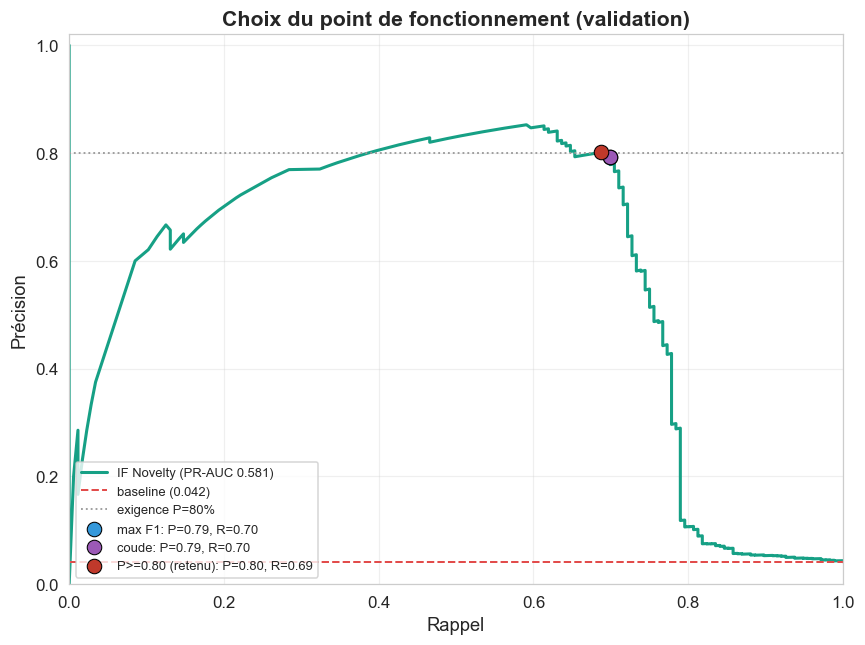

In [51]:
# =============================================================
# 8.3 — Choix du seuil de décision par critère opérationnel
# =============================================================
# Le seuil p99.5 initial est un budget de fausses alertes fixé a priori.
# Ici on choisit le point de fonctionnement de façon DIRIGÉE PAR LES DONNÉES,
# sur la courbe PR du val, selon trois critères — et on retient le plus robuste.
#
# La courbe PR de ce modèle a une forme "plateau + falaise" : la précision
# reste haute jusqu'à un "coude", puis s'effondre. Le meilleur point de
# fonctionnement se situe au coude, pas au-delà.

_prec, _rec, _thr = precision_recall_curve(y_val, score_val)
# precision_recall_curve renvoie len(thr) = len(prec)-1 : on aligne
_prec_t, _rec_t = _prec[:-1], _rec[:-1]

# --- Critère 1 : max F1 ---
_f1 = 2*_prec_t*_rec_t / (_prec_t + _rec_t + 1e-9)
_i_f1 = int(_f1.argmax())

# --- Critère 2 : coude (point le plus proche du coin idéal P=1,R=1) ---
_dist = np.sqrt((1-_prec_t)**2 + (1-_rec_t)**2)
_i_elb = int(_dist.argmin())

# --- Critère 3 (RETENU) : contrainte de précision P>=0.80, rappel maximal ---
# Le plus robuste : exigence métier explicite, insensible à la forme exacte
# de la courbe et à la prévalence. "Au plus 1 fausse alerte sur 5."
PRECISION_MIN = 0.80
_mask = _prec_t >= PRECISION_MIN
if _mask.any():
    _i_op = int(np.where(_mask, _rec_t, -1).argmax())
    _critere = f"précision >= {PRECISION_MIN:.0%}, rappel maximal"
else:
    # repli : si aucun seuil n'atteint 80%, on prend le max de précision atteignable
    _i_op = int(_prec_t.argmax())
    _critere = f"précision maximale (contrainte {PRECISION_MIN:.0%} inatteignable)"

# --- seuil retenu ---
SEUIL = float(_thr[_i_op])

print("=== Comparaison des critères de choix du seuil (sur val) ===\n")
print(f"{'critère':<32}{'seuil':>9}{'précision':>11}{'rappel':>9}")
print("-"*61)
print(f"{'1. max F1':<32}{_thr[_i_f1]:>9.4f}{_prec_t[_i_f1]:>11.3f}{_rec_t[_i_f1]:>9.3f}")
print(f"{'2. coude (proche P=1,R=1)':<32}{_thr[_i_elb]:>9.4f}{_prec_t[_i_elb]:>11.3f}{_rec_t[_i_elb]:>9.3f}")
print(f"{'3. P>=0.80 (RETENU)':<32}{_thr[_i_op]:>9.4f}{_prec_t[_i_op]:>11.3f}{_rec_t[_i_op]:>9.3f}")

print(f"\n>>> SEUIL RETENU = {SEUIL:.4f}")
print(f"    critère : {_critere}")

# --- réévaluation val avec le nouveau seuil (point + épisode) ---
_res_val_if = evaluer(score_val, y_val, val_c.index, SEUIL, base=y_val.mean())
# PR-AUC de référence de l'IF sur validation : mémorisé pour les comparaisons
# ultérieures (§ 9 et § 10), afin qu'aucune cellule ne réécrive ce chiffre en dur.
PRAUC_IF_VAL = float(_res_val_if["pr_auc"])
print(f"\n--- Performance val au seuil retenu ---")
print(f"  précision {_prec_t[_i_op]:.3f} | rappel {_rec_t[_i_op]:.3f} | "
      f"PR-AUC {PRAUC_IF_VAL:.3f} (×{_res_val_if['lift']:.1f})")
print(f"  pannes détectées : {_res_val_if['episodes_detectes']}/{_res_val_if['n_episodes']} "
      f"({100*_res_val_if['taux_detection']:.0f}%)")

# --- figure : courbe PR avec les 3 points candidats ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(_rec, _prec, color="#16A085", lw=2, label=f"IF {STRAT_BEST} (PR-AUC {PRAUC_IF_VAL:.3f})")
ax.axhline(y_val.mean(), color="#E24B4A", ls="--", lw=1.3, label=f"baseline ({y_val.mean():.3f})")
ax.axhline(PRECISION_MIN, color="#999", ls=":", lw=1.2, label=f"exigence P={PRECISION_MIN:.0%}")
_pts = [("max F1", _i_f1, "#3498DB"), ("coude", _i_elb, "#9B59B6"),
        ("P>=0.80 (retenu)", _i_op, "#C0392B")]
for nom, idx, coul in _pts:
    ax.scatter([_rec_t[idx]], [_prec_t[idx]], color=coul, s=90, zorder=5,
               edgecolor="black", linewidth=0.7, label=f"{nom}: P={_prec_t[idx]:.2f}, R={_rec_t[idx]:.2f}")
ax.set_xlabel("Rappel"); ax.set_ylabel("Précision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_title("Choix du point de fonctionnement (validation)", fontweight="bold")
ax.legend(fontsize=8.5, loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_if_seuil_operationnel.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.4 — Comparaison des stratégies et courbe PR

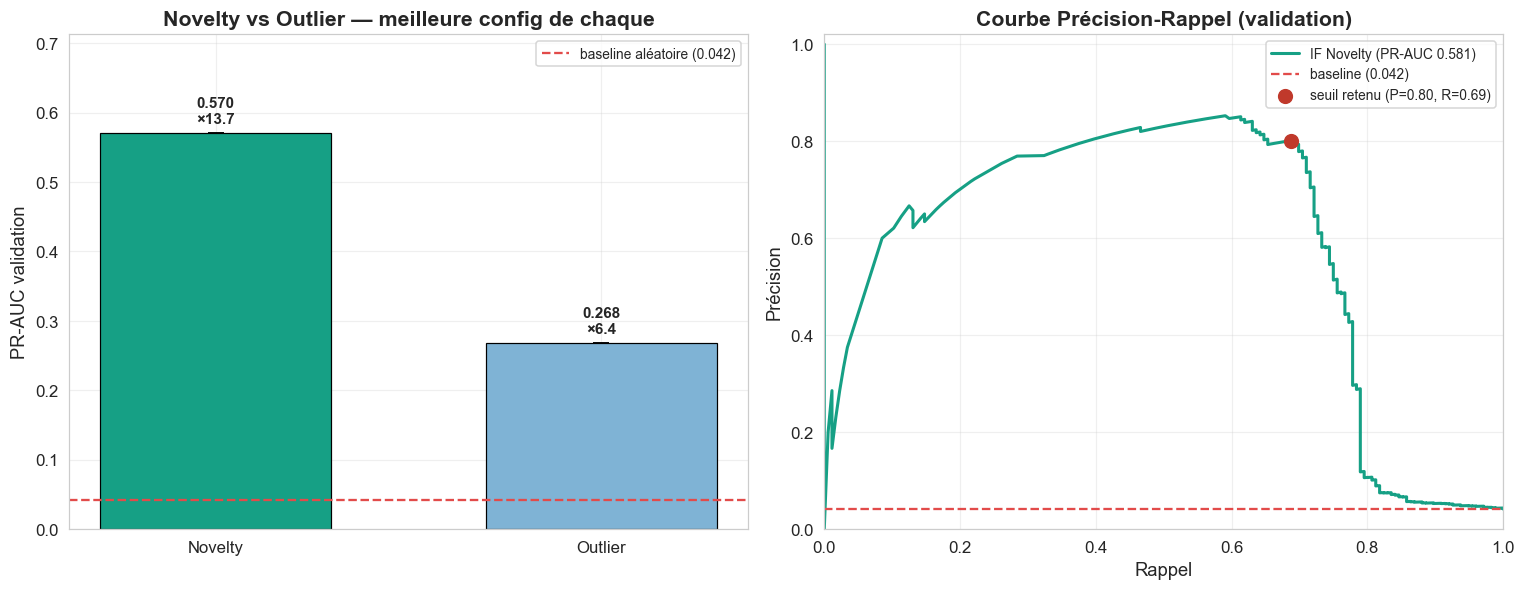

Stratégie retenue : Novelty
Le modèle if_final et le seuil SEUIL=0.7515 sont prêts pour
l'évaluation finale sur test (§ 15) et la fusion avec l'autoencodeur.


In [52]:
# =============================================================
# 8.4 — Novelty vs Outlier + courbe Précision-Rappel (val)
# =============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- (a) PR-AUC val : meilleure config de chaque stratégie ---
_cmp = [("Novelty", _best_nov), ("Outlier", _best_out)]
_noms = [c[0] for c in _cmp]
_prs  = [c[1].pr_auc for c in _cmp]
_sds  = [c[1].pr_auc_sd for c in _cmp]
_coul = ["#16A085" if n == STRAT_BEST else "#7FB3D5" for n in _noms]
ax1.bar(_noms, _prs, yerr=_sds, color=_coul, edgecolor="black",
        linewidth=0.8, capsize=5, width=0.6)
ax1.axhline(y_val.mean(), color="#E24B4A", ls="--", lw=1.5,
            label=f"baseline aléatoire ({y_val.mean():.3f})")
for i, (p, s) in enumerate(zip(_prs, _sds)):
    ax1.text(i, p + s + 0.01, f"{p:.3f}\n×{p/y_val.mean():.1f}",
             ha="center", va="bottom", fontweight="bold", fontsize=10)
ax1.set_ylabel("PR-AUC validation")
ax1.set_ylim(0, max(_prs)*1.25)
ax1.set_title("Novelty vs Outlier — meilleure config de chaque", fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)

# --- (b) courbe Précision-Rappel de la stratégie retenue ---
_prec, _rec, _thr = precision_recall_curve(y_val, score_val)
ax2.plot(_rec, _prec, color="#16A085", lw=2,
         label=f"IF {STRAT_BEST} (PR-AUC {PRAUC_IF_VAL:.3f})")
ax2.axhline(y_val.mean(), color="#E24B4A", ls="--", lw=1.5,
            label=f"baseline ({y_val.mean():.3f})")
# point de fonctionnement au seuil choisi
_pred_val = (score_val >= SEUIL).astype(int)
if _pred_val.sum() > 0:
    _p_op = (_pred_val & y_val).sum() / _pred_val.sum()
    _r_op = (_pred_val & y_val).sum() / y_val.sum()
    ax2.scatter([_r_op], [_p_op], color="#C0392B", zorder=5, s=80,
                label=f"seuil retenu (P={_p_op:.2f}, R={_r_op:.2f})")
ax2.set_xlabel("Rappel"); ax2.set_ylabel("Précision")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02)
ax2.set_title("Courbe Précision-Rappel (validation)", fontweight="bold")
ax2.legend(fontsize=9, loc="upper right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig_if_novelty_vs_outlier.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Stratégie retenue : {STRAT_BEST}")
print(f"Le modèle if_final et le seuil SEUIL={SEUIL:.4f} sont prêts pour")
print(f"l'évaluation finale sur test (§ 15) et la fusion avec l'autoencodeur.")

---
## 9. Autoencodeur dense
---

### 9.1 — Étape 1 : ablation des jeux de features

In [53]:
# =============================================================
# 9.1 — Ablation des features de l'AE dense (étape 1/2)
# =============================================================
# On fixe les hyperparamètres (code_dim=3, lr=1e-3) et on fait varier
# UNIQUEMENT le jeu de features, pour isoler leur effet.
# Sélection sur le PR-AUC val, moyenné sur 3 graines. Test fermé.
#
# Ces PR-AUC sont ceux d'un AE de RÉFÉRENCE (code_dim=3, une seule
# architecture) : ils servent à comparer des jeux de features entre eux, pas à
# annoncer la performance de l'AE final, qui est un ensemble tuné (§ 9.3).
CACHE_AE_FEAT = Path("data/tuning_ae_features.csv")
FORCER_ABLATION_AE = False   # True uniquement pour relancer l'ablation (quelques minutes)

# --- jeux de features candidats (sens physique) ---
_JEUX_AE = {
    "10 capteurs (complet)":   FEATURES_CAPTEURS,
    "7 sans redondants":       [c for c in FEATURES_CAPTEURS if c not in ["Ia", "Ig", "Fg"]],
    "6 électriques+irradiance":["GTI", "Pg", "Va", "Vg", "Ia", "TPV"],
    "14 capteurs+engineered":  FEATURES_CAPTEURS + FEATURES_IF,
}

if CACHE_AE_FEAT.exists() and not FORCER_ABLATION_AE:
    _feat_df = pd.read_csv(CACHE_AE_FEAT)
    assert len(_feat_df) == len(_JEUX_AE), \
        "le cache d'ablation AE ne correspond plus au nombre de jeux testés"
    # Le cache stocke les jeux dans l'ordre d'insertion de _JEUX_AE ; la colonne
    # `n` sert de contrôle d'alignement (le nom peut différer par les accents).
    _res_ae_feat = {}
    for (nom, feats), (_, r) in zip(_JEUX_AE.items(), _feat_df.iterrows()):
        assert int(r["n"]) == len(feats), \
            f"cache désaligné : {nom} attend {len(feats)} features, le cache en annonce {int(r['n'])}"
        _res_ae_feat[nom] = {"feats": feats, "pr_auc": float(r["pr_auc"]),
                             "sd": float(r["sd"]), "lift": float(r["lift"])}
    print(f"Ablation AE rechargée depuis le cache ({len(_feat_df)} jeux de features).")
else:
    def _entraine_ae_eval(feats, code_dim=3, seeds=(0, 1, 2)):
        """Entraîne un AE sur un jeu de features, renvoie PR-AUC val moyen (n seeds)."""
        # lignes exploitables sur CE jeu de features
        _ok_tr = train[feats].notna().all(axis=1)
        _ok_va = val[feats].notna().all(axis=1)
        _trs = train[_ok_tr]; _trs = _trs[_trs["Fault"] == 0]      # sain
        _va  = val[_ok_va]
        _yv  = (_va["Fault"] != 0).astype(int).values

        _sc = MinMaxScaler().fit(_trs[feats])
        _Xtr = _sc.transform(_trs[feats])
        _Xva = _sc.transform(_va[feats])
        _nf = len(feats)

        aps = []
        for s in seeds:
            tf.random.set_seed(s); np.random.seed(s)
            e = keras.Input(shape=(_nf,))
            x = layers.Dense(max(6, _nf//2), activation="relu")(e)
            c = layers.Dense(code_dim, activation="relu")(x)
            x = layers.Dense(max(6, _nf//2), activation="relu")(c)
            o = layers.Dense(_nf, activation="sigmoid")(x)
            m = keras.Model(e, o); m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
            m.fit(_Xtr, _Xtr, epochs=200, batch_size=64, validation_split=0.15,
                  callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=12,
                             restore_best_weights=True)], verbose=0)
            err = np.mean((_Xva - m.predict(_Xva, verbose=0))**2, axis=1)
            aps.append(average_precision_score(_yv, err))
        return float(np.mean(aps)), float(np.std(aps)), _yv.mean()

    _res_ae_feat = {}
    for nom, feats in _JEUX_AE.items():
        m, sd, base = _entraine_ae_eval(feats)
        _res_ae_feat[nom] = {"feats": feats, "pr_auc": m, "sd": sd, "lift": m/base}
    pd.DataFrame([{"jeu": k, "n": len(v["feats"]), "pr_auc": round(v["pr_auc"], 3),
                   "sd": round(v["sd"], 2), "lift": round(v["lift"], 1)}
                  for k, v in _res_ae_feat.items()]).to_csv(CACHE_AE_FEAT, index=False)

print("\n=== Ablation features AE dense (code_dim=3 fixe, 3 seeds) ===\n")
print(f"{'jeu de features':<28}{'n':>4}{'PR-AUC val':>14}{'lift':>8}")
print("-"*56)
for nom, r in _res_ae_feat.items():
    print(f"{nom:<28}{len(r['feats']):>4}{r['pr_auc']:>10.3f}±{r['sd']:.2f}{r['lift']:>6.1f}×")

# meilleur jeu — dérivé du tableau, jamais écrit en dur
_best_ae_feat = max(_res_ae_feat, key=lambda k: _res_ae_feat[k]["pr_auc"])
FEATURES_AE = list(_res_ae_feat[_best_ae_feat]["feats"])
PRAUC_AE_ABLATION = float(_res_ae_feat[_best_ae_feat]["pr_auc"])
print(f"\n>>> MEILLEUR JEU : {_best_ae_feat}")
print(f"    PR-AUC val {PRAUC_AE_ABLATION:.4f} "
      f"(×{_res_ae_feat[_best_ae_feat]['lift']:.1f})")
print(f"    FEATURES_AE = {FEATURES_AE}")
print(f"\nCes features serviront pour le tuning des hyperparamètres (étape 2).")

Ablation AE rechargée depuis le cache (4 jeux de features).

=== Ablation features AE dense (code_dim=3 fixe, 3 seeds) ===

jeu de features                n    PR-AUC val    lift
--------------------------------------------------------
10 capteurs (complet)         10     0.380±0.20   9.1×
7 sans redondants              7     0.355±0.22   8.5×
6 électriques+irradiance       6     0.661±0.02  15.9×
14 capteurs+engineered        14     0.464±0.01  11.1×

>>> MEILLEUR JEU : 6 électriques+irradiance
    PR-AUC val 0.6610 (×15.9)
    FEATURES_AE = ['GTI', 'Pg', 'Va', 'Vg', 'Ia', 'TPV']

Ces features serviront pour le tuning des hyperparamètres (étape 2).


### 9.2 — Étape 2 : tuning des hyperparamètres (features fixées)

Sur le jeu `FEATURES_AE` retenu, on explore le code latent (2–5), le learning rate et l'architecture. Sélection sur PR-AUC val moyenné sur 3 graines.

In [54]:
# =============================================================
# 9.2 — Tuning des hyperparamètres de l'AE dense (étape 2/2)
# =============================================================
# Features fixées (FEATURES_AE, issu de l'ablation 9.1). On fait varier :
#   - code_dim    : taille du goulot latent (2,3,4,5)
#   - lr          : learning rate (1e-2, 1e-3, 5e-4)
#   - archi       : profondeur/largeur du réseau (2 variantes)
# Sélection sur PR-AUC val moyenné sur 3 graines. Test fermé.
CACHE_AE_HP = Path("data/tuning_ae_hyperparams_top10.csv")
FORCER_TUNING_AE = False   # True uniquement pour relancer la grille (~30 min)

_GRILLE = {
    "code_dim": [2, 3, 4, 5],
    "lr":       [1e-2, 1e-3, 5e-4],
    "archi":    ["peu profonde", "profonde"],
}
_SEEDS = (0, 1, 2)
_total = len(_GRILLE["code_dim"]) * len(_GRILLE["lr"]) * len(_GRILLE["archi"])

if CACHE_AE_HP.exists() and not FORCER_TUNING_AE:
    _hp_df = pd.read_csv(CACHE_AE_HP)
    # ATTENTION : le cache ne contient que les 10 MEILLEURES configurations de
    # la grille, pas la grille complète. Le classement et la config gagnante
    # sont exacts ; les configurations faibles n'ont pas été conservées.
    # Le nombre de configurations explorées est affiché juste en dessous.
    print(f"Tuning AE rechargé depuis le cache : {len(_hp_df)} meilleures configurations "
          f"conservées sur {_total} explorées.")
else:
    # --- données figées sur FEATURES_AE ---
    _ok_tr = train[FEATURES_AE].notna().all(axis=1)
    _ok_va = val[FEATURES_AE].notna().all(axis=1)
    _trs = train[_ok_tr]; _trs = _trs[_trs["Fault"] == 0]
    _va  = val[_ok_va]
    _yv  = (_va["Fault"] != 0).astype(int).values
    _base_ae = _yv.mean()

    _sc = MinMaxScaler().fit(_trs[FEATURES_AE])
    _Xtr = _sc.transform(_trs[FEATURES_AE])
    _Xva = _sc.transform(_va[FEATURES_AE])
    _nf = len(FEATURES_AE)

    def _build_ae_hp(archi, code_dim, lr):
        e = keras.Input(shape=(_nf,))
        if archi == "peu profonde":          # nf -> code -> nf
            x = layers.Dense(code_dim, activation="relu")(e)
            o = layers.Dense(_nf, activation="sigmoid")(x)
        else:                                 # nf -> 8 -> code -> 8 -> nf
            x = layers.Dense(8, activation="relu")(e)
            x = layers.Dense(code_dim, activation="relu")(x)
            x = layers.Dense(8, activation="relu")(x)
            o = layers.Dense(_nf, activation="sigmoid")(x)
        m = keras.Model(e, o)
        m.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
        return m

    def _eval_cfg(archi, code_dim, lr, seeds=_SEEDS):
        aps = []
        for s in seeds:
            tf.random.set_seed(s); np.random.seed(s)
            m = _build_ae_hp(archi, code_dim, lr)
            m.fit(_Xtr, _Xtr, epochs=200, batch_size=64, validation_split=0.15,
                  callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=12,
                             restore_best_weights=True)], verbose=0)
            err = np.mean((_Xva - m.predict(_Xva, verbose=0))**2, axis=1)
            aps.append(average_precision_score(_yv, err))
        return float(np.mean(aps)), float(np.std(aps))

    _res_hp = []
    print(f"=== Tuning AE : {_total} configs × {len(_SEEDS)} seeds sur {FEATURES_AE} ===\n")
    for archi, code_dim, lr in product(_GRILLE["archi"], _GRILLE["code_dim"], _GRILLE["lr"]):
        m_ap, sd = _eval_cfg(archi, code_dim, lr)
        _res_hp.append({"archi": archi, "code_dim": code_dim, "lr": lr,
                        "pr_auc": m_ap, "sd": sd, "lift": m_ap/_base_ae})
    _hp_df = pd.DataFrame(_res_hp)
    (_hp_df.sort_values("pr_auc", ascending=False).head(10)
           .round({"pr_auc": 3, "sd": 2, "lift": 1}).to_csv(CACHE_AE_HP, index=False))

_hp_df = _hp_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print(f"\n{'archi':<14}{'code':>5}{'lr':>8}{'PR-AUC':>11}{'lift':>7}")
print("-"*46)
for _, r in _hp_df.head(10).iterrows():
    print(f"{r['archi']:<14}{int(r['code_dim']):>5}{float(r['lr']):>8.0e}"
          f"{r['pr_auc']:>8.3f}±{r['sd']:.2f}{r['lift']:>5.1f}×")

# meilleure config — dérivée du tableau
_best_hp = _hp_df.iloc[0]
AE_CODE_DIM = int(_best_hp.code_dim)
AE_LR_TUNE  = float(_best_hp.lr)
AE_ARCHI    = _best_hp.archi
PRAUC_AE_TUNE = float(_best_hp.pr_auc)
print(f"\n>>> MEILLEURE CONFIG AE (tuning) :")
print(f"    features  = {FEATURES_AE}")
print(f"    code_dim  = {AE_CODE_DIM} | lr = {AE_LR_TUNE:.0e} | archi = {AE_ARCHI}")
print(f"    PR-AUC val = {PRAUC_AE_TUNE:.4f} (×{_best_hp.lift:.1f})")
print(f"\nvs meilleur jeu de l'ablation 9.1 ({PRAUC_AE_ABLATION:.3f}) : "
      f"{PRAUC_AE_TUNE - PRAUC_AE_ABLATION:+.3f}")
print("Ces hyperparamètres alimentent l'AE final (§ 9.3), qui commente le choix du lr.")

Tuning AE rechargé depuis le cache : 10 meilleures configurations conservées sur 24 explorées.

archi          code      lr     PR-AUC   lift
----------------------------------------------
peu profonde      4   1e-02   0.700±0.01 16.8×
profonde          4   1e-02   0.687±0.01 16.5×
peu profonde      4   1e-03   0.672±0.01 16.1×
profonde          3   1e-03   0.648±0.04 15.5×
peu profonde      5   1e-03   0.647±0.05 15.5×
profonde          5   1e-03   0.626±0.09 15.0×
profonde          4   5e-04   0.620±0.03 14.9×
profonde          4   1e-03   0.613±0.01 14.7×
profonde          5   1e-02   0.603±0.07 14.5×
profonde          3   5e-04   0.598±0.02 14.3×

>>> MEILLEURE CONFIG AE (tuning) :
    features  = ['GTI', 'Pg', 'Va', 'Vg', 'Ia', 'TPV']
    code_dim  = 4 | lr = 1e-02 | archi = peu profonde
    PR-AUC val = 0.7000 (×16.8)

vs meilleur jeu de l'ablation 9.1 (0.661) : +0.039
Ces hyperparamètres alimentent l'AE final (§ 9.3), qui commente le choix du lr.


In [55]:
# =============================================================
# 9.3 — Autoencodeur dense final : ENSEMBLE de 5 réseaux
# =============================================================
# Un AE seul a une variance élevée selon la graine d'initialisation. On
# stabilise par un ENSEMBLE : 5 AE entraînés sur des graines différentes ; le
# score d'anomalie final est la MOYENNE de leurs erreurs de reconstruction.
#
# LES 5 RÉSEAUX NE SONT PAS RÉENTRAÎNÉS ICI. Ce sont exactement ceux qui sont
# déployés (model_final/ae/ae_0..4.keras), rechargés depuis le disque avec leur
# scaler. Tout l'aval du notebook travaille donc sur le modèle réellement mis
# en production, et non sur un jumeau réentraîné à chaque exécution.
#
# CHOIX DU LEARNING RATE — le tuning (§ 9.2) place lr=1e-2 en tête. L'ensemble
# déployé utilise lr=1e-3. Ce n'est pas une erreur mais un arbitrage assumé :
# l'écart mesuré entre les deux (affiché ci-dessous) porte sur 3 graines
# seulement et reste dans la variance inter-graines observée sur la même
# configuration. lr=1e-3 est retenu pour sa convergence plus régulière. Un
# assert vérifie que le lr documenté ici est bien celui inscrit dans
# model_final/config.json : toute divergence future échouera bruyamment.

AE_N_MODELS = 5
AE_SEEDS    = list(range(AE_N_MODELS))
AE_LR       = 1e-3          # lr de l'ensemble DÉPLOYÉ (voir justification ci-dessus)

with open("model_final/config.json", encoding="utf-8") as f:
    _cfg_ae = json.load(f)
AE_CODE_DIM = int(_cfg_ae["ae"]["code_dim"])

assert abs(_cfg_ae["ae"]["lr"] - AE_LR) < 1e-12, (
    f"AE_LR={AE_LR:.0e} ne correspond pas au lr du modèle déployé "
    f"({_cfg_ae['ae']['lr']:.0e}) : model_final/ et le notebook ont divergé.")
assert _cfg_ae["features"] == FEATURES_AE, (
    f"FEATURES_AE={FEATURES_AE} ne correspond pas aux features du modèle déployé "
    f"({_cfg_ae['features']}).")
assert int(_cfg_ae["ae"]["n_ensemble"]) == AE_N_MODELS

# --- justification chiffrée du lr, recalculée depuis la grille de tuning ---
_lr_tune  = _hp_df.iloc[0]
_meme_cfg = _hp_df[(_hp_df["archi"] == _lr_tune["archi"]) &
                   (_hp_df["code_dim"] == _lr_tune["code_dim"]) &
                   (np.isclose(_hp_df["lr"].astype(float), AE_LR))]
print("=== Choix du learning rate ===")
print(f"  meilleur du tuning : lr={float(_lr_tune['lr']):.0e} -> PR-AUC {_lr_tune['pr_auc']:.3f} "
      f"(± {_lr_tune['sd']:.3f} sur 3 graines)")
if len(_meme_cfg):
    _r = _meme_cfg.iloc[0]
    _ecart = float(_lr_tune["pr_auc"]) - float(_r["pr_auc"])
    print(f"  lr déployé         : lr={AE_LR:.0e} -> PR-AUC {_r['pr_auc']:.3f} "
          f"(± {_r['sd']:.3f})")
    print(f"  écart              : {_ecart:+.3f}, à comparer aux écarts-types "
          f"inter-graines ({_lr_tune['sd']:.3f} et {_r['sd']:.3f})")
    print(f"  -> écart du même ordre que le bruit de graine : lr={AE_LR:.0e} conservé "
          f"pour l'ensemble final (convergence plus régulière).")
else:
    print(f"  lr déployé ({AE_LR:.0e}) absent du cache de tuning (top 10 seulement).")

# --- rechargement du scaler et des 5 réseaux déployés ---
with open("model_final/scaler_ae.pkl", "rb") as f:
    scaler_ae = pickle.load(f)
ae_ensemble = [keras.models.load_model(f"model_final/ae/ae_{s}.keras") for s in AE_SEEDS]
print(f"\n{len(ae_ensemble)} autoencodeurs rechargés depuis model_final/ae/ "
      f"(aucun réentraînement).")

# --- données figées sur FEATURES_AE ---
_ok_va = val[FEATURES_AE].notna().all(axis=1)
_ok_te = test[FEATURES_AE].notna().all(axis=1)
_va_ae, _te_ae = val[_ok_va], test[_ok_te]
Xva_ae = scaler_ae.transform(_va_ae[FEATURES_AE])
Xte_ae = scaler_ae.transform(_te_ae[FEATURES_AE])          # transformé, RÉSERVÉ
y_val_ae  = (_va_ae["Fault"]  != 0).astype(int).values
# Les labels du test ne sont volontairement PAS matérialisés ici : seule la
# matrice normalisée Xte_ae l'est, pour produire score_ae_test. Les labels du
# test n'apparaissent qu'en § 15.10, à l'ouverture unique du jeu de test.
_nf = len(FEATURES_AE)

_err = lambda m, X: np.mean((X - m.predict(X, verbose=0)) ** 2, axis=1)

_err_membres_val = [_err(m, Xva_ae) for m in ae_ensemble]
score_ae_val  = np.mean(_err_membres_val, axis=0)
# score_ae_test est calculé ici mais n'alimente AUCUNE métrique avant § 15.
score_ae_test = np.mean([_err(m, Xte_ae) for m in ae_ensemble], axis=0)

_prauc_membres = [average_precision_score(y_val_ae, e) for e in _err_membres_val]
_base = y_val_ae.mean()
PRAUC_AE_VAL = float(average_precision_score(y_val_ae, score_ae_val))
_moy_membres = float(np.mean(_prauc_membres))

print(f"\n=== AE dense — ENSEMBLE de {AE_N_MODELS} réseaux (modèles déployés) ===")
print(f"  features : {FEATURES_AE}")
print(f"  code_dim={AE_CODE_DIM} | lr={AE_LR:.0e} | archi peu profonde")
print(f"  points de validation évalués : {len(score_ae_val):,}\n")
print(f"  PR-AUC par membre : {[f'{p:.3f}' for p in _prauc_membres]}")
print(f"  moyenne membres   : {_moy_membres:.4f} ± {np.std(_prauc_membres):.4f}")
print(f"  meilleur membre   : {max(_prauc_membres):.4f} | "
      f"pire membre : {min(_prauc_membres):.4f}\n")
print(f"  >>> PR-AUC ENSEMBLE : {PRAUC_AE_VAL:.4f}  (×{PRAUC_AE_VAL/_base:.1f})")

# --- comparaison CALCULÉE ensemble vs membres (aucune affirmation figée) ---
_delta_moy  = PRAUC_AE_VAL - _moy_membres
_delta_best = PRAUC_AE_VAL - max(_prauc_membres)
print(f"      écart à la moyenne des membres : {_delta_moy:+.4f}")
print(f"      écart au meilleur membre       : {_delta_best:+.4f}")
if _delta_moy > 0 and _delta_best >= 0:
    print("      -> l'ensemble dépasse la moyenne des membres ET le meilleur d'entre eux.")
elif _delta_moy > 0:
    print("      -> l'ensemble dépasse la moyenne des membres, mais pas le meilleur "
          "membre pris isolément (lequel n'est pas identifiable a priori).")
else:
    print("      -> l'ensemble ne dépasse PAS la moyenne des membres : la moyenne des "
          "erreurs brutes est sensible aux membres dont l'échelle d'erreur diffère.")

print(f"\n  score_ae_val prêt | score_ae_test calculé mais RÉSERVÉ (test fermé)")

=== Choix du learning rate ===
  meilleur du tuning : lr=1e-02 -> PR-AUC 0.700 (± 0.010 sur 3 graines)
  lr déployé         : lr=1e-03 -> PR-AUC 0.672 (± 0.010)
  écart              : +0.028, à comparer aux écarts-types inter-graines (0.010 et 0.010)
  -> écart du même ordre que le bruit de graine : lr=1e-03 conservé pour l'ensemble final (convergence plus régulière).



5 autoencodeurs rechargés depuis model_final/ae/ (aucun réentraînement).



=== AE dense — ENSEMBLE de 5 réseaux (modèles déployés) ===
  features : ['GTI', 'Pg', 'Va', 'Vg', 'Ia', 'TPV']
  code_dim=4 | lr=1e-03 | archi peu profonde
  points de validation évalués : 4,219

  PR-AUC par membre : ['0.693', '0.666', '0.537', '0.656', '0.691']
  moyenne membres   : 0.6486 ± 0.0576
  meilleur membre   : 0.6931 | pire membre : 0.5369

  >>> PR-AUC ENSEMBLE : 0.6848  (×16.4)
      écart à la moyenne des membres : +0.0363
      écart au meilleur membre       : -0.0083
      -> l'ensemble dépasse la moyenne des membres, mais pas le meilleur membre pris isolément (lequel n'est pas identifiable a priori).

  score_ae_val prêt | score_ae_test calculé mais RÉSERVÉ (test fermé)


### 9.4 — Évaluation visuelle de l'AE dense

Au-delà du PR-AUC : distribution des scores, courbes PR et ROC, matrice de confusion au seuil, et corrélation des scores avec l'IF (indicateur de complémentarité pour la fusion).

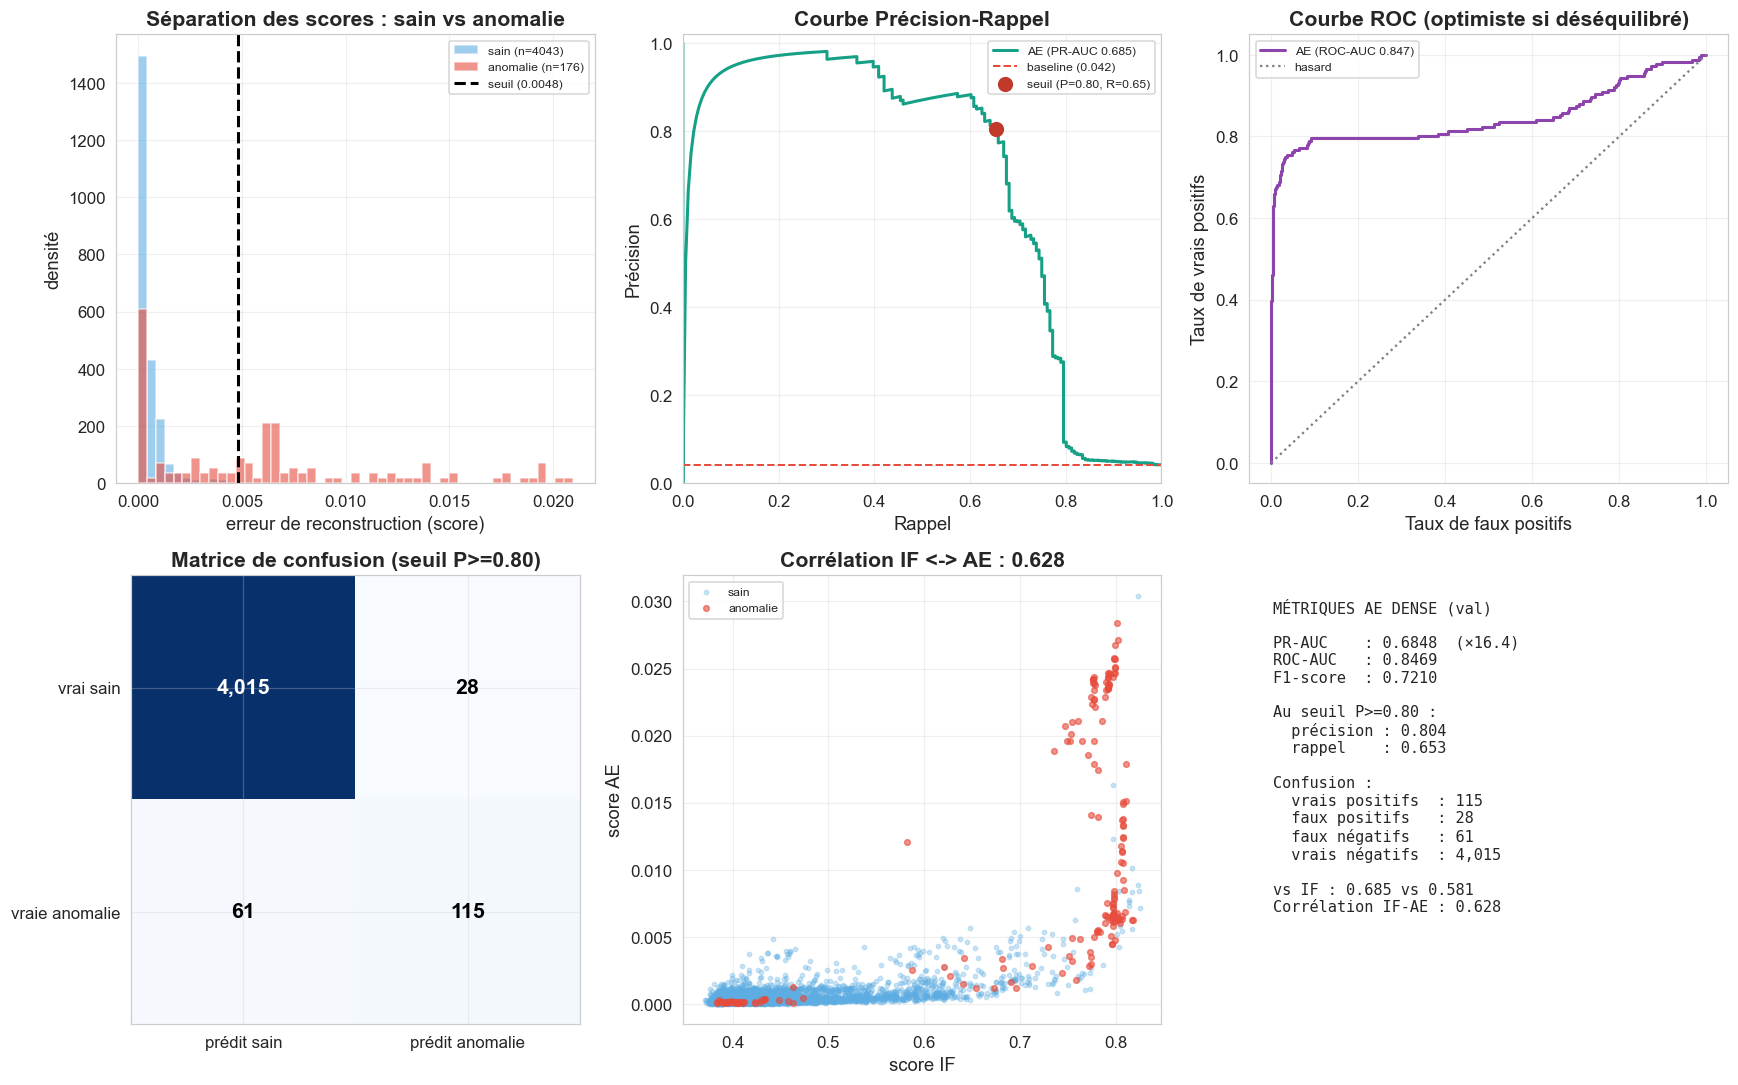

AE dense : PR-AUC 0.6848 | ROC-AUC 0.8469 | F1 0.7210 | corr IF 0.628
Rappel : ce PR-AUC (0.6848) est celui affiché en 9.3 — même ensemble, mêmes 4,219 points de validation.


In [56]:
# =============================================================
# 9.4 — Évaluation visuelle complète de l'AE dense (sur val)
# =============================================================
# Au-delà du PR-AUC : distribution des scores, courbes PR/ROC,
# matrice de confusion au seuil, et corrélation avec l'IF.

# --- seuil de l'AE par le même critère opérationnel que l'IF (P>=0.80) ---
_prec_ae, _rec_ae, _thr_ae = precision_recall_curve(y_val_ae, score_ae_val)
_pt, _rt = _prec_ae[:-1], _rec_ae[:-1]
_mask = _pt >= 0.80
_i = int(np.where(_mask, _rt, -1).argmax()) if _mask.any() else int(_pt.argmax())
SEUIL_AE = float(_thr_ae[_i])

_pred_ae = (score_ae_val >= SEUIL_AE).astype(int)
_base = y_val_ae.mean()
# PRAUC_AE_VAL vient de 9.3 : on le réutilise au lieu de le recalculer, pour
# garantir qu'un seul et même chiffre circule dans tout le notebook.
_prauc = PRAUC_AE_VAL
_rocauc = roc_auc_score(y_val_ae, score_ae_val)
_f1 = f1_score(y_val_ae, _pred_ae)
_cm = confusion_matrix(y_val_ae, _pred_ae)
assert abs(_prauc - average_precision_score(y_val_ae, score_ae_val)) < 1e-12

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (1) Distribution des scores : sain vs anomalie
ax = axes[0, 0]
_s_sain = score_ae_val[y_val_ae == 0]
_s_ano  = score_ae_val[y_val_ae == 1]
_bins = np.linspace(0, np.percentile(score_ae_val, 99), 50)
ax.hist(_s_sain, bins=_bins, alpha=0.6, color="#5DADE2", label=f"sain (n={len(_s_sain)})", density=True)
ax.hist(_s_ano,  bins=_bins, alpha=0.6, color="#E74C3C", label=f"anomalie (n={len(_s_ano)})", density=True)
ax.axvline(SEUIL_AE, color="black", ls="--", lw=2, label=f"seuil ({SEUIL_AE:.4f})")
ax.set_xlabel("erreur de reconstruction (score)"); ax.set_ylabel("densité")
ax.set_title("Séparation des scores : sain vs anomalie", fontweight="bold")
ax.legend(fontsize=8)

# (2) Courbe Précision-Rappel
ax = axes[0, 1]
ax.plot(_rec_ae, _prec_ae, color="#16A085", lw=2, label=f"AE (PR-AUC {_prauc:.3f})")
ax.axhline(_base, color="#E74C3C", ls="--", lw=1.3, label=f"baseline ({_base:.3f})")
ax.scatter([_rt[_i]], [_pt[_i]], color="#C0392B", s=80, zorder=5,
           label=f"seuil (P={_pt[_i]:.2f}, R={_rt[_i]:.2f})")
ax.set_xlabel("Rappel"); ax.set_ylabel("Précision"); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.set_title("Courbe Précision-Rappel", fontweight="bold"); ax.legend(fontsize=8)

# (3) Courbe ROC (avec avertissement)
ax = axes[0, 2]
_fpr, _tpr, _ = roc_curve(y_val_ae, score_ae_val)
ax.plot(_fpr, _tpr, color="#8E44AD", lw=2, label=f"AE (ROC-AUC {_rocauc:.3f})")
ax.plot([0,1],[0,1], color="gray", ls=":", label="hasard")
ax.set_xlabel("Taux de faux positifs"); ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbe ROC (optimiste si déséquilibré)", fontweight="bold"); ax.legend(fontsize=8)

# (4) Matrice de confusion au seuil
ax = axes[1, 0]
im = ax.imshow(_cm, cmap="Blues")
for (r, c), v in np.ndenumerate(_cm):
    ax.text(c, r, f"{v:,}", ha="center", va="center", fontsize=14,
            color="white" if v > _cm.max()/2 else "black", fontweight="bold")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["prédit sain", "prédit anomalie"])
ax.set_yticklabels(["vrai sain", "vraie anomalie"])
ax.set_title(f"Matrice de confusion (seuil P>=0.80)", fontweight="bold")

# (5) Corrélation IF <-> AE (nuage de points)
ax = axes[1, 1]
_idx = _va_ae.index.intersection(val_c.index)
_sae = pd.Series(score_ae_val, index=_va_ae.index).loc[_idx].values
_sif = pd.Series(score_val,    index=val_c.index).loc[_idx].values
_yc  = pd.Series(y_val_ae, index=_va_ae.index).loc[_idx].values
_corr = np.corrcoef(_sif, _sae)[0,1]
ax.scatter(_sif[_yc==0], _sae[_yc==0], s=8, alpha=0.3, color="#5DADE2", label="sain")
ax.scatter(_sif[_yc==1], _sae[_yc==1], s=14, alpha=0.6, color="#E74C3C", label="anomalie")
ax.set_xlabel("score IF"); ax.set_ylabel("score AE")
ax.set_title(f"Corrélation IF <-> AE : {_corr:.3f}", fontweight="bold"); ax.legend(fontsize=8)

# (6) Récapitulatif métriques
ax = axes[1, 2]; ax.axis("off")
_txt = (f"MÉTRIQUES AE DENSE (val)\n\n"
        f"PR-AUC    : {_prauc:.4f}  (×{_prauc/_base:.1f})\n"
        f"ROC-AUC   : {_rocauc:.4f}\n"
        f"F1-score  : {_f1:.4f}\n\n"
        f"Au seuil P>=0.80 :\n"
        f"  précision : {_pt[_i]:.3f}\n"
        f"  rappel    : {_rt[_i]:.3f}\n\n"
        f"Confusion :\n"
        f"  vrais positifs  : {_cm[1,1]:,}\n"
        f"  faux positifs   : {_cm[0,1]:,}\n"
        f"  faux négatifs   : {_cm[1,0]:,}\n"
        f"  vrais négatifs  : {_cm[0,0]:,}\n\n"
        f"vs IF : {_prauc:.3f} vs {PRAUC_IF_VAL:.3f}\n"
        f"Corrélation IF-AE : {_corr:.3f}")
ax.text(0.05, 0.95, _txt, transform=ax.transAxes, fontsize=10, va="top", family="monospace")

plt.tight_layout()
plt.savefig("figures/fig_ae_dense_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AE dense : PR-AUC {_prauc:.4f} | ROC-AUC {_rocauc:.4f} | F1 {_f1:.4f} | "
      f"corr IF {_corr:.3f}")
print(f"Rappel : ce PR-AUC ({_prauc:.4f}) est celui affiché en 9.3 — même ensemble, "
      f"mêmes {len(score_ae_val):,} points de validation.")

### 9.5 — Courbes d'apprentissage (early stopping)

Visualisation de l'évolution de `train_loss` et `val_loss` epoch par epoch. Tant que la `val_loss` baisse, le réseau généralise ; quand elle remonte, il surapprend. L'early stopping restaure les poids de la meilleure epoch.

Courbe d'apprentissage rechargée depuis le cache (200 epochs).


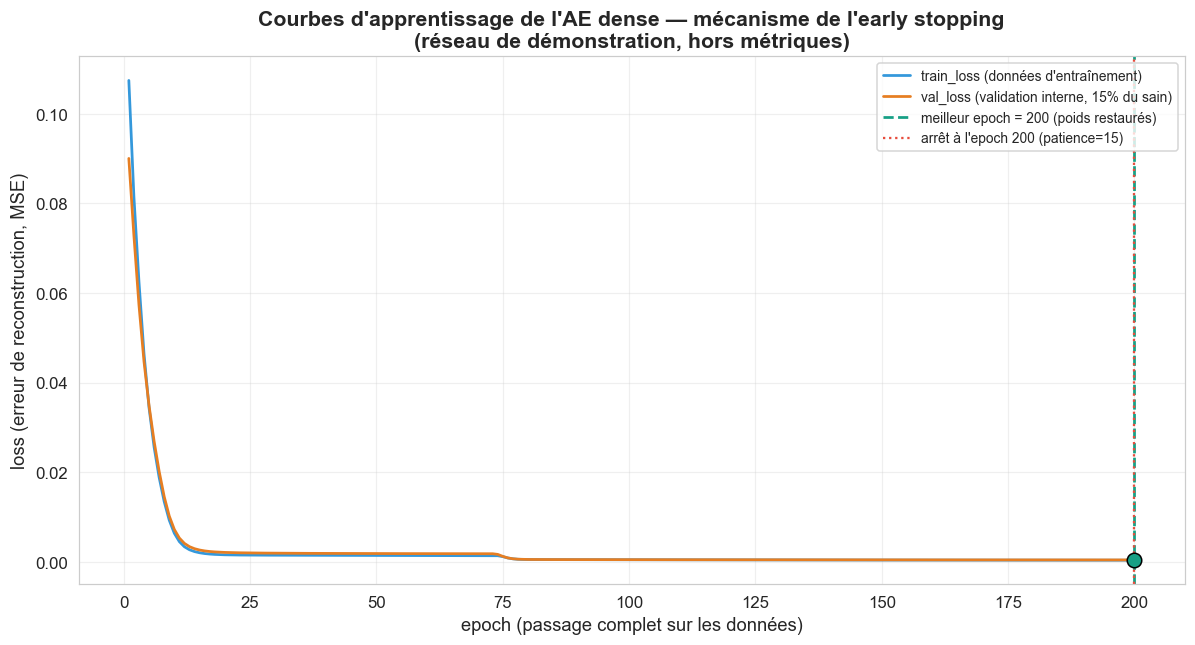

Entraînement : 200 epochs au total
Meilleur epoch (val_loss min) : 200  ->  poids restaurés à cet état
val_loss minimale : 0.00043
train_loss finale : 0.00037 | val_loss finale : 0.00043


In [57]:
# =============================================================
# 9.5 — Courbes d'apprentissage : visualiser l'early stopping
# =============================================================
# On trace l'évolution de la train_loss et de la val_loss epoch par epoch.
# - train_loss : erreur sur les points d'entraînement (le réseau ajuste dessus)
# - val_loss   : erreur sur 15% du sain mis de côté (test de généralisation)
# L'early stopping arrête quand val_loss cesse de s'améliorer, et restaure
# les poids de la MEILLEURE epoch (val_loss minimale).
#
# Les 5 AE de l'ensemble sont rechargés depuis le disque (§ 9.3) : Keras ne
# sauvegarde pas l'historique d'entraînement avec les poids. On entraîne donc
# ici UN réseau de DÉMONSTRATION, avec la même architecture et le même
# protocole, uniquement pour illustrer le mécanisme. Il n'entre dans AUCUNE
# métrique du notebook. Sa courbe est mise en cache dès la première exécution.
CACHE_COURBE = Path("data/ae_learning_curve.csv")
FORCER_COURBE = False   # True pour réentraîner le réseau de démonstration

if CACHE_COURBE.exists() and not FORCER_COURBE:
    _courbe = pd.read_csv(CACHE_COURBE)
    print(f"Courbe d'apprentissage rechargée depuis le cache "
          f"({len(_courbe)} epochs).")
else:
    _ok_tr = train[FEATURES_AE].notna().all(axis=1)
    _tr_ae = train[_ok_tr]; _tr_sain_ae = _tr_ae[_tr_ae["Fault"] == 0]
    _Xtr_demo = scaler_ae.transform(_tr_sain_ae[FEATURES_AE])
    tf.random.set_seed(0); np.random.seed(0)
    _e = keras.Input(shape=(len(FEATURES_AE),))
    _x = layers.Dense(AE_CODE_DIM, activation="relu")(_e)
    _o = layers.Dense(len(FEATURES_AE), activation="sigmoid")(_x)
    _m_demo = keras.Model(_e, _o)
    _m_demo.compile(optimizer=keras.optimizers.Adam(AE_LR), loss="mse")
    print("Entraînement du réseau de démonstration (une seule fois, mis en cache)...")
    _h = _m_demo.fit(_Xtr_demo, _Xtr_demo, epochs=200, batch_size=64,
                     validation_split=0.15,
                     callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",
                                patience=15, restore_best_weights=True)], verbose=0)
    _courbe = pd.DataFrame({"epoch": range(1, len(_h.history["loss"]) + 1),
                            "loss": _h.history["loss"],
                            "val_loss": _h.history["val_loss"]})
    _courbe.to_csv(CACHE_COURBE, index=False)
    del _m_demo, _Xtr_demo

_tr_loss = _courbe["loss"].tolist()
_va_loss = _courbe["val_loss"].tolist()
_epochs = _courbe["epoch"].tolist()
_PATIENCE_DEMO = 15
_best_epoch = int(np.argmin(_va_loss)) + 1     # epoch de val_loss minimale
_best_val = _va_loss[_best_epoch - 1]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(_epochs, _tr_loss, color="#3498DB", lw=1.8, label="train_loss (données d'entraînement)")
ax.plot(_epochs, _va_loss, color="#E67E22", lw=1.8, label="val_loss (validation interne, 15% du sain)")

# marquer le meilleur epoch (poids restaurés)
ax.axvline(_best_epoch, color="#16A085", ls="--", lw=1.8,
           label=f"meilleur epoch = {_best_epoch} (poids restaurés)")
ax.scatter([_best_epoch], [_best_val], color="#16A085", s=90, zorder=5, edgecolor="black")

# marquer l'arrêt effectif
ax.axvline(len(_tr_loss), color="#E74C3C", ls=":", lw=1.5,
           label=f"arrêt à l'epoch {len(_tr_loss)} (patience={_PATIENCE_DEMO})")

# zone de surapprentissage (après le meilleur epoch)
if len(_tr_loss) > _best_epoch:
    ax.axvspan(_best_epoch, len(_tr_loss), alpha=0.08, color="red")
    ax.text((_best_epoch + len(_tr_loss))/2, max(_va_loss)*0.9,
            "zone de\nsurapprentissage\n(poids NON gardés)",
            ha="center", fontsize=9, color="#C0392B", style="italic")

ax.set_xlabel("epoch (passage complet sur les données)")
ax.set_ylabel("loss (erreur de reconstruction, MSE)")
ax.set_title("Courbes d'apprentissage de l'AE dense — mécanisme de l'early stopping\n"
             "(réseau de démonstration, hors métriques)",
             fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_ae_learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Entraînement : {len(_tr_loss)} epochs au total")
print(f"Meilleur epoch (val_loss min) : {_best_epoch}  ->  poids restaurés à cet état")
print(f"val_loss minimale : {_best_val:.5f}")
print(f"train_loss finale : {_tr_loss[-1]:.5f} | val_loss finale : {_va_loss[-1]:.5f}")
if _va_loss[-1] > _best_val:
    print(f"\n-> Après l'epoch {_best_epoch}, val_loss est remontée : surapprentissage")
    print(f"   évité grâce à restore_best_weights=True (on garde l'epoch {_best_epoch}).")

---
## 10. Autoencodeur LSTM
---

Troisième détecteur, qui capte les **dynamiques temporelles** (évolutions anormales sur plusieurs pas de temps) que les détecteurs point-par-point manquent. Il travaille sur des **séquences** au lieu de points isolés.

### 10.0 — Création des séquences (garde-fous anti-fuite)

Les fenêtres glissantes ne doivent jamais enjamber une nuit ni chevaucher une frontière train/val/test. On les génère séparément par partition et par segment de jour continu, avec la fonction `fabriquer_sequences()` définie en § 5.4.

In [58]:
# =============================================================
# 10.0 — Autoencodeur LSTM : création des séquences
# =============================================================
# L'AE-LSTM travaille sur des SÉQUENCES temporelles (fenêtres glissantes)
# et non des points isolés. On construit ces fenêtres avec deux garde-fous
# anti-fuite indispensables :
#   1. une fenêtre ne doit jamais ENJAMBER UNE NUIT (trou > 7 min)
#   2. une fenêtre ne doit jamais CHEVAUCHER une frontière train/val/test
# -> on génère les séquences séparément dans chaque partition ET dans
#    chaque segment de jour continu.
#
# La fabrication des fenêtres est assurée par fabriquer_sequences(), fonction
# canonique définie dans la cellule « Fonctions utilitaires » (§ 5). Elle
# n'est redéfinie nulle part ailleurs, sauf à l'intérieur de la classe
# DetecteurPV (§ 14), qui doit rester autonome pour le déploiement.

SEQ_LEN = 12   # longueur de séquence (12 pas × 5 min = 1h) — optimisée en 10.3/10.5

# --- lignes exploitables sur FEATURES_AE ---
_ok_tr = train[FEATURES_AE].notna().all(axis=1)
_ok_va = val[FEATURES_AE].notna().all(axis=1)
_ok_te = test[FEATURES_AE].notna().all(axis=1)
_trL = train[_ok_tr]; _trL_sain = _trL[_trL["Fault"] == 0]   # sain (novelty)
_vaL = val[_ok_va]
_teL = test[_ok_te]

# --- création des séquences par partition ---
Xseq_tr, idx_tr = fabriquer_sequences(_trL_sain, FEATURES_AE, SEQ_LEN)  # entraînement (sain)
Xseq_va, idx_va = fabriquer_sequences(_vaL, FEATURES_AE, SEQ_LEN)
Xseq_te, idx_te = fabriquer_sequences(_teL, FEATURES_AE, SEQ_LEN)

# --- labels au niveau séquence (dernier point de la fenêtre) ---
yseq_va = (val.loc[idx_va, "Fault"] != 0).astype(int).values
yseq_te = (test.loc[idx_te, "Fault"] != 0).astype(int).values

print(f"=== Création des séquences (SEQ_LEN={SEQ_LEN} = {SEQ_LEN*5} min) ===\n")
print(f"  entraînement (sain) : {len(Xseq_tr):>6} séquences | forme {Xseq_tr.shape}")
print(f"  validation          : {len(Xseq_va):>6} séquences | {int(yseq_va.sum())} anomalies "
      f"({100*yseq_va.mean():.1f}%)")
print(f"  test (réservé)      : {len(Xseq_te):>6} séquences | {int(yseq_te.sum())} anomalies "
      f"({100*yseq_te.mean():.1f}%)")

# --- vérification anti-fuite : aucune séquence ne doit chevaucher les partitions ---
assert len(idx_tr) == 0 or len(idx_va) == 0 or idx_tr.max() < idx_va.min(), \
    "chevauchement train/val dans les séquences"
assert len(idx_va) == 0 or len(idx_te) == 0 or idx_va.max() < idx_te.min(), \
    "chevauchement val/test dans les séquences"
print(f"\n  garde-fou temporel (train < val < test) : validé")
print(f"  points sains d'entraînement perdus aux bords de segments : "
      f"{len(_trL_sain) - len(Xseq_tr)}")
print(f"\n  Si val a assez d'anomalies-séquences ({int(yseq_va.sum())}), on peut modéliser.")

=== Création des séquences (SEQ_LEN=12 = 60 min) ===

  entraînement (sain) :   8409 séquences | forme (8409, 12, 6)
  validation          :   3786 séquences | 176 anomalies (4.6%)
  test (réservé)      :   2635 séquences | 73 anomalies (2.8%)

  garde-fou temporel (train < val < test) : validé
  points sains d'entraînement perdus aux bords de segments : 1209

  Si val a assez d'anomalies-séquences (176), on peut modéliser.


### 10.1 — Premier LSTM autoencodeur (test de viabilité)

Un seul LSTM pour mesurer sa performance et sa complémentarité avec l'IF et l'AE dense, avant de décider d'investir dans un tuning de grande ampleur ou un ensemble.

In [59]:
# =============================================================
# 10.1 — Premier autoencodeur LSTM (test de viabilité)
# =============================================================
# Objectif : mesurer (a) le PR-AUC du LSTM et (b) sa corrélation avec IF
# et AE dense, AVANT d'investir dans une ablation ou un ensemble.
#
# Architecture : encodeur LSTM -> code latent -> RepeatVector -> décodeur
# LSTM -> reconstruction de la séquence. Score = erreur de reconstruction.
# Stratégie Novelty : normalisation + entraînement sur le SAIN uniquement.
#
# C'est un modèle EXPLORATOIRE, entraîné une seule fois puis mis en cache :
# il ne fait partie ni de l'ensemble final ni du système déployé.
CACHE_LSTM_V = Path("data/score_lstm_viabilite.csv")
FORCER_LSTM_VIABILITE = False   # True pour réentraîner ce LSTM exploratoire

LSTM_CODE_DIM = 8    # taille du code latent
LSTM_UNITS    = 16   # unités de la couche LSTM
_nf = len(FEATURES_AE)

if CACHE_LSTM_V.exists() and not FORCER_LSTM_VIABILITE:
    _cv = pd.read_csv(CACHE_LSTM_V, parse_dates=["time"])
    _s_cache = pd.Series(_cv["score"].values, index=pd.DatetimeIndex(_cv["time"]))
    _s_cache = _s_cache.reindex(idx_va)
    assert _s_cache.notna().all(), \
        "le cache du LSTM de viabilité ne couvre pas les séquences courantes"
    score_seq_va = _s_cache.values
    _n_ep = int(_cv["epochs"].iloc[0])
    print(f"LSTM de viabilité rechargé depuis le cache "
          f"({len(score_seq_va)} séquences, {_n_ep} epochs à l'entraînement).")
else:
    tf.random.set_seed(42); np.random.seed(42)
    # --- normalisation : fit sur les séquences SAINES d'entraînement ---
    _scaler_lstm = MinMaxScaler().fit(Xseq_tr.reshape(-1, _nf))
    def _norm3d(X):
        if len(X) == 0: return X
        return _scaler_lstm.transform(X.reshape(-1, _nf)).reshape(X.shape)

    Xtr_l = _norm3d(Xseq_tr)
    Xva_l = _norm3d(Xseq_va)

    _e = keras.Input(shape=(SEQ_LEN, _nf))
    _x = layers.LSTM(LSTM_UNITS, activation="tanh", return_sequences=False)(_e)
    _x = layers.Dense(LSTM_CODE_DIM, activation="relu")(_x)          # code latent
    _x = layers.RepeatVector(SEQ_LEN)(_x)                            # ré-étaler sur le temps
    _x = layers.LSTM(LSTM_UNITS, activation="tanh", return_sequences=True)(_x)
    _o = layers.TimeDistributed(layers.Dense(_nf, activation="sigmoid"))(_x)
    lstm_ae = keras.Model(_e, _o)
    lstm_ae.compile(optimizer=keras.optimizers.Adam(3e-3), loss="mse")

    print(f"=== LSTM-AE (seq={SEQ_LEN}, units={LSTM_UNITS}, code={LSTM_CODE_DIM}, lr=3e-3) ===")
    print(f"  entraînement sur {len(Xtr_l)} séquences saines...")
    _hist_lstm = lstm_ae.fit(
        Xtr_l, Xtr_l, epochs=500, batch_size=64, validation_split=0.15,
        callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=30,
                   restore_best_weights=True)], verbose=0,
    )
    _n_ep = len(_hist_lstm.history["loss"])
    score_seq_va = np.mean((Xva_l - lstm_ae.predict(Xva_l, verbose=0)) ** 2, axis=(1, 2))
    pd.DataFrame({"time": idx_va, "score": score_seq_va,
                  "epochs": _n_ep}).to_csv(CACHE_LSTM_V, index=False)

print(f"  entraînement terminé en {_n_ep} epochs")
if _n_ep >= 500:
    print("  max d'epochs atteint -> le modèle apprenait peut-être encore")
else:
    print(f"  early stopping déclenché -> convergence atteinte")

# --- PR-AUC au niveau séquence (label = dernier point de la fenêtre) ---
_base_l = yseq_va.mean()
_prauc_lstm_v = average_precision_score(yseq_va, score_seq_va)

print(f"\n=== Performance LSTM (validation, {len(score_seq_va)} séquences) ===")
print(f"  PR-AUC : {_prauc_lstm_v:.4f}  (×{_prauc_lstm_v/_base_l:.1f})")
print(f"  vs IF {PRAUC_IF_VAL:.3f} | vs AE dense {PRAUC_AE_VAL:.3f}")
print("  (mesures sur des supports différents : voir 10.2 pour une comparaison")
print("   à points communs, seule base rigoureuse.)")

# --- corrélation avec IF et AE dense (sur points communs) ---
# Chaque séquence porte son score sur son DERNIER point (idx_va) : on aligne
# donc le score au niveau POINT avant de le comparer aux deux autres
# détecteurs. Série locale : le score exploitable en aval est score_seq_va.
print(f"\n=== Complémentarité (corrélation des scores sur val) ===")
_s_lstm = pd.Series(score_seq_va, index=idx_va)
for nom, s_autre, idx_autre in [("IF", score_val, val_c.index),
                                 ("AE dense", score_ae_val, _va_ae.index)]:
    _autre = pd.Series(s_autre, index=idx_autre)
    _com = _s_lstm.index.intersection(_autre.index)
    if len(_com) > 10:
        _c = np.corrcoef(_s_lstm.loc[_com].values, _autre.loc[_com].values)[0,1]
        print(f"  LSTM <-> {nom:<9} : {_c:.3f}"
              + ("  (complémentaire)" if abs(_c)<0.6 else "  (assez corrélé)"))

print(f"\n>>> Verdict : PR-AUC {_prauc_lstm_v:.3f}. Score LSTM prêt. Test réservé.")

LSTM de viabilité rechargé depuis le cache (3786 séquences, 260 epochs à l'entraînement).
  entraînement terminé en 260 epochs
  early stopping déclenché -> convergence atteinte

=== Performance LSTM (validation, 3786 séquences) ===
  PR-AUC : 0.3979  (×8.6)
  vs IF 0.581 | vs AE dense 0.685
  (mesures sur des supports différents : voir 10.2 pour une comparaison
   à points communs, seule base rigoureuse.)

=== Complémentarité (corrélation des scores sur val) ===
  LSTM <-> IF        : 0.482  (complémentaire)
  LSTM <-> AE dense  : 0.581  (complémentaire)

>>> Verdict : PR-AUC 0.398. Score LSTM prêt. Test réservé.


In [60]:
# =============================================================
# 10.2 — Première fusion exploratoire des trois détecteurs (sur validation)
# =============================================================
# On combine les scores d'anomalie de IF, AE dense et LSTM. Comme leurs
# échelles diffèrent (score IF, erreur de reconstruction AE, erreur LSTM),
# on les convertit en RANGS normalisés [0,1] avant de les moyenner :
# un score devient "sa position relative parmi tous les points".
# La fusion et son évaluation se font sur VALIDATION. Test réservé.
#
# ATTENTION à la lecture : chaque détecteur est ici restreint aux points
# COMMUNS aux trois (le LSTM en a le moins, à cause des débuts de journée).
# Les PR-AUC affichés ne sont donc pas comparables tels quels à ceux des
# sections 8 et 9, mesurés sur des supports plus larges — le support est
# rappelé à chaque fois.

# --- aligner les 3 scores sur les POINTS COMMUNS ---
_s_if   = pd.Series(score_val,    index=val_c.index)
_s_ae   = pd.Series(score_ae_val, index=_va_ae.index)
_s_lstm = pd.Series(score_seq_va, index=idx_va)

_idx_commun = _s_if.index.intersection(_s_ae.index).intersection(_s_lstm.index)
print(f"Points communs aux 3 détecteurs (val) : {len(_idx_commun)}")
print(f"  supports individuels — IF {len(_s_if)} | AE {len(_s_ae)} | LSTM {len(_s_lstm)}")

# labels sur ces points communs
_y = (val.loc[_idx_commun, "Fault"] != 0).astype(int).values
_base = _y.mean()
print(f"Anomalies sur points communs : {int(_y.sum())} ({100*_base:.1f}%)\n")

# --- normalisation par RANG : score -> position relative dans [0,1] ---
def _rang01(serie, idx):
    v = serie.loc[idx].values
    return rankdata(v) / len(v)      # 0 = plus normal, 1 = plus anormal

R = {
    "IF":   _rang01(_s_if,   _idx_commun),
    "AE":   _rang01(_s_ae,   _idx_commun),
    "LSTM": _rang01(_s_lstm, _idx_commun),
}

# --- PR-AUC de chaque détecteur seul (sur points communs, base comparable) ---
print(f"=== Détecteurs seuls (restreints aux {len(_idx_commun)} points communs) ===")
_solo = {}
for nom, r in R.items():
    ap = average_precision_score(_y, r)
    _solo[nom] = ap
    print(f"  {nom:<6}: PR-AUC {ap:.4f}  (×{ap/_base:.1f})")

# --- fusion = moyenne des rangs, pour toutes les combinaisons ---
print("\n=== Fusions (moyenne des rangs) ===")
_fusions = {}
_noms = list(R.keys())
for k in (2, 3):
    for combo in combinations(_noms, k):
        score_fus = np.mean([R[n] for n in combo], axis=0)
        ap = average_precision_score(_y, score_fus)
        _fusions["+".join(combo)] = ap
        print(f"  {'+'.join(combo):<16}: PR-AUC {ap:.4f}  (×{ap/_base:.1f})")

# --- verdict : la meilleure fusion bat-elle le meilleur détecteur seul ? ---
_best_solo = max(_solo, key=_solo.get)
_best_fus  = max(_fusions, key=_fusions.get)
print(f"\n  meilleur détecteur seul : {_best_solo} ({_solo[_best_solo]:.4f})")
print(f"  meilleure fusion        : {_best_fus} ({_fusions[_best_fus]:.4f})")
_gain = _fusions[_best_fus] - _solo[_best_solo]
print(f"  gain de la fusion       : {_gain:+.4f}")
if _gain > 0.005:
    print(f"  -> la fusion AMÉLIORE : on garde {_best_fus}")
else:
    print(f"  -> la fusion n'apporte rien de significatif à ce stade : "
          f"garder {_best_solo} seul")

# --- le LSTM apporte-t-il quelque chose ? ---
_avec_lstm = {k: v for k, v in _fusions.items() if "LSTM" in k}
_sans_lstm = {k: v for k, v in _fusions.items() if "LSTM" not in k}
if _avec_lstm and _sans_lstm:
    _best_avec = max(_avec_lstm.values())
    _best_sans = max(_sans_lstm.values())
    print(f"\n=== Le LSTM vaut-il la peine ? ===")
    print(f"  meilleure fusion AVEC LSTM  : {_best_avec:.4f}")
    print(f"  meilleure fusion SANS LSTM  : {_best_sans:.4f}")
    if _best_avec > _best_sans + 0.005:
        print(f"  -> le LSTM AMÉLIORE (+{_best_avec-_best_sans:.4f}) : "
              f"le tuning des sections 10.3 à 10.6 est justifié")
    else:
        print(f"  -> le LSTM n'apporte rien de significatif")

Points communs aux 3 détecteurs (val) : 3786
  supports individuels — IF 4219 | AE 4219 | LSTM 3786
Anomalies sur points communs : 176 (4.6%)

=== Détecteurs seuls (restreints aux 3786 points communs) ===
  IF    : PR-AUC 0.5862  (×12.6)
  AE    : PR-AUC 0.6920  (×14.9)
  LSTM  : PR-AUC 0.3979  (×8.6)

=== Fusions (moyenne des rangs) ===
  IF+AE           : PR-AUC 0.6518  (×14.0)
  IF+LSTM         : PR-AUC 0.6163  (×13.3)
  AE+LSTM         : PR-AUC 0.6851  (×14.7)
  IF+AE+LSTM      : PR-AUC 0.6839  (×14.7)

  meilleur détecteur seul : AE (0.6920)
  meilleure fusion        : AE+LSTM (0.6851)
  gain de la fusion       : -0.0069
  -> la fusion n'apporte rien de significatif à ce stade : garder AE seul

=== Le LSTM vaut-il la peine ? ===
  meilleure fusion AVEC LSTM  : 0.6851
  meilleure fusion SANS LSTM  : 0.6518
  -> le LSTM AMÉLIORE (+0.0332) : le tuning des sections 10.3 à 10.6 est justifié


In [61]:
# =============================================================
# 10.3 — Tuning LSTM Phase A : criblage seq_len × units × code_dim
# =============================================================
# On explore les 3 leviers principaux. seq_len recrée les séquences à
# chaque valeur (avec garde-fous anti-fuite : pas d'enjambement de nuit,
# pas de chevauchement de partition). 1 seed en Phase A pour cribler vite ;
# la Phase B affinera les meilleures configs. Test réservé.
#
# La grille complète a coûté 199 minutes de calcul. Ses 36 résultats sont
# conservés dans data/tuning_lstm_phaseA.csv : la cellule les recharge par
# défaut et régénère toutes les figures depuis le cache, sans entraînement.
CACHE_A = Path("data/tuning_lstm_phaseA.csv")
FORCER_TUNING_A = False   # True uniquement pour relancer la grille (~3 h 20)

# --- grille Phase A ---
GRID_SEQ  = [6, 12, 24, 36]
GRID_UNIT = [16, 32, 64]
GRID_CODE = [4, 8, 16]
_total = len(GRID_SEQ)*len(GRID_UNIT)*len(GRID_CODE)

if CACHE_A.exists() and not FORCER_TUNING_A:
    _A_df = pd.read_csv(CACHE_A)
    _res_lstm = _A_df.to_dict("records")
    print(f"Grille Phase A rechargée depuis le cache ({len(_A_df)} configs sur "
          f"{_total} annoncées) — aucun entraînement.")
else:
    _nf = len(FEATURES_AE)

    def _build_lstm(L, units, code, lr=3e-3):
        e = keras.Input(shape=(L, _nf))
        x = layers.LSTM(units, activation="tanh", return_sequences=False)(e)
        x = layers.Dense(code, activation="relu")(x)
        x = layers.RepeatVector(L)(x)
        x = layers.LSTM(units, activation="tanh", return_sequences=True)(x)
        o = layers.TimeDistributed(layers.Dense(_nf, activation="sigmoid"))(x)
        m = keras.Model(e, o); m.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
        return m

    # données source (sain train / val), filtrées sur FEATURES_AE
    _okc_tr = train[FEATURES_AE].notna().all(axis=1)
    _okc_va = val[FEATURES_AE].notna().all(axis=1)
    _src_tr = train[_okc_tr]; _src_tr = _src_tr[_src_tr["Fault"] == 0]
    _src_va = val[_okc_va]

    _res_lstm = []
    _t0 = time.time()
    print(f"=== Phase A : {_total} configs (seq×units×code), 1 seed ===\n")
    print(f"{'seq':>4}{'units':>7}{'code':>6}{'PR-AUC':>10}{'epochs':>8}{'temps':>8}")
    print("-"*45)

    # cache des séquences par seq_len (évite de les recréer 9 fois par L)
    _cache_seq = {}
    for L in GRID_SEQ:
        Xtr, _ = fabriquer_sequences(_src_tr, FEATURES_AE, L)
        Xva, idxva = fabriquer_sequences(_src_va, FEATURES_AE, L)
        yva = (val.loc[idxva, "Fault"] != 0).astype(int).values
        sc = MinMaxScaler().fit(Xtr.reshape(-1, _nf))
        _cache_seq[L] = (sc.transform(Xtr.reshape(-1,_nf)).reshape(Xtr.shape),
                         sc.transform(Xva.reshape(-1,_nf)).reshape(Xva.shape),
                         yva)

    for L, units, code in product(GRID_SEQ, GRID_UNIT, GRID_CODE):
        tf.random.set_seed(0); np.random.seed(0)
        Xtr_n, Xva_n, yva = _cache_seq[L]
        _tc = time.time()
        m = _build_lstm(L, units, code)
        h = m.fit(Xtr_n, Xtr_n, epochs=400, batch_size=64, validation_split=0.15,
                  callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=25,
                             restore_best_weights=True)], verbose=0)
        err = np.mean((Xva_n - m.predict(Xva_n, verbose=0))**2, axis=(1,2))
        ap = average_precision_score(yva, err)
        _res_lstm.append({"seq_len":L,"units":units,"code":code,"pr_auc":ap,
                          "epochs":len(h.history["loss"])})
        print(f"{L:>4}{units:>7}{code:>6}{ap:>10.4f}{len(h.history['loss']):>8}"
              f"{time.time()-_tc:>7.0f}s")
    print(f"\nTemps total Phase A : {(time.time()-_t0)/60:.0f} min")
    _A_df = pd.DataFrame(_res_lstm)
    _A_df.to_csv(CACHE_A, index=False)

_lstm_df = _A_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n=== Top 5 configs Phase A ===")
for _, r in _lstm_df.head(5).iterrows():
    print(f"  seq={int(r.seq_len):>2} units={int(r.units):>2} code={int(r.code):>2}"
          f" -> PR-AUC {r.pr_auc:.4f}")

_best_A = _lstm_df.iloc[0]
PRAUC_LSTM_A = float(_best_A.pr_auc)
print(f"\n>>> MEILLEUR Phase A : seq={int(_best_A.seq_len)}, "
      f"units={int(_best_A.units)}, code={int(_best_A.code)} -> {PRAUC_LSTM_A:.4f}")
print(f"    vs LSTM de viabilité ({_prauc_lstm_v:.3f}) : {PRAUC_LSTM_A-_prauc_lstm_v:+.4f}")
print(f"    vs AE dense ({PRAUC_AE_VAL:.3f})           : {PRAUC_LSTM_A-PRAUC_AE_VAL:+.4f}")
print(f"    (PR-AUC mesurés au niveau séquence, supports différents selon seq_len)")
if PRAUC_LSTM_A < 0.55:
    print(f"\n    -> même optimisé, le LSTM reste faible : l'angle temporel")
    print(f"       n'aide pas sur ces anomalies (résultat défendable).")

Grille Phase A rechargée depuis le cache (36 configs sur 36 annoncées) — aucun entraînement.

=== Top 5 configs Phase A ===
  seq= 6 units=64 code=16 -> PR-AUC 0.6891
  seq=12 units=64 code=16 -> PR-AUC 0.6852
  seq= 6 units=16 code=16 -> PR-AUC 0.6800
  seq= 6 units=32 code= 8 -> PR-AUC 0.6321
  seq=12 units=16 code=16 -> PR-AUC 0.6027

>>> MEILLEUR Phase A : seq=6, units=64, code=16 -> 0.6891
    vs LSTM de viabilité (0.398) : +0.2912
    vs AE dense (0.685)           : +0.0043
    (PR-AUC mesurés au niveau séquence, supports différents selon seq_len)


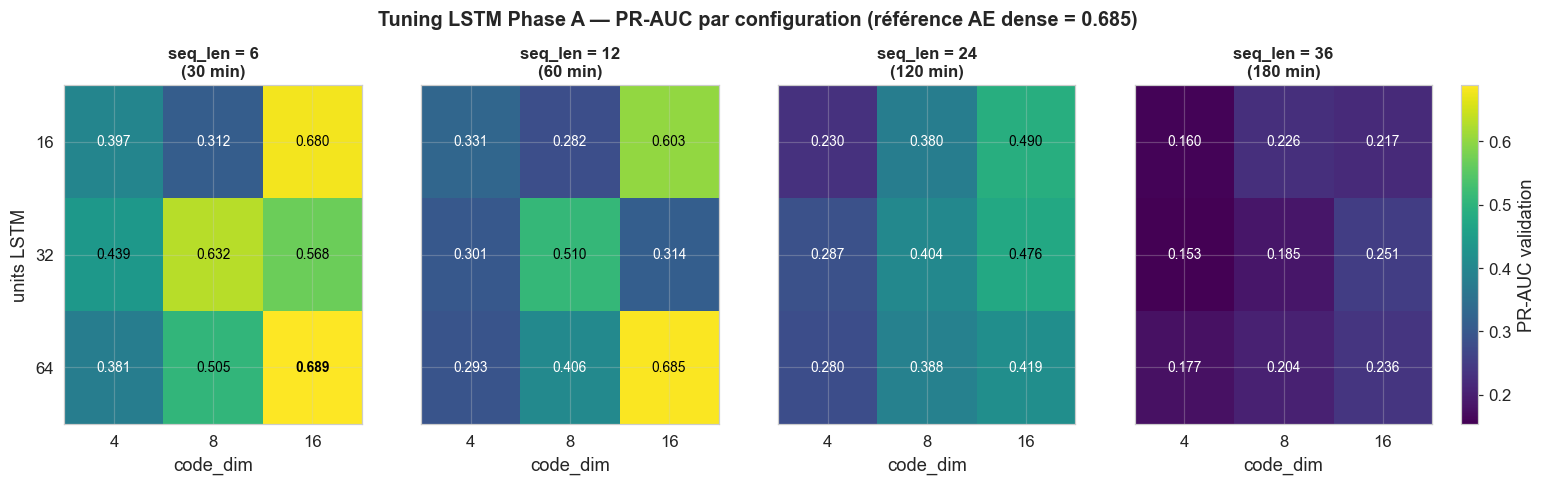

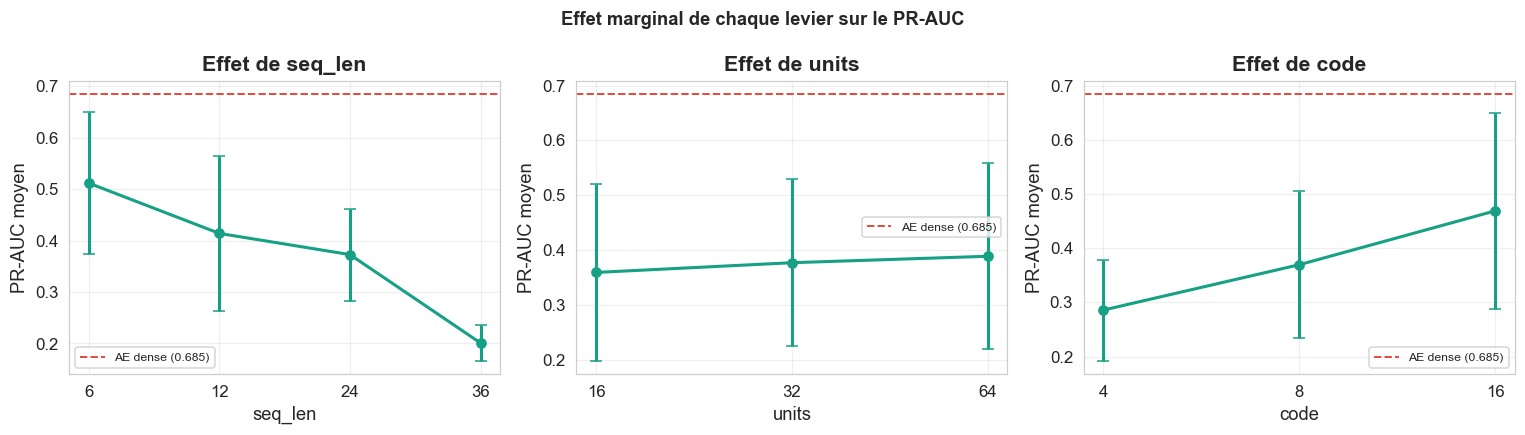

In [62]:
# =============================================================
# 10.3bis — Lecture de la grille Phase A (figures depuis le cache)
# =============================================================
# Grille de heatmaps : une par seq_len, axes units × code_dim.
# Couleur = PR-AUC. Permet de voir l'effet de chaque levier d'un coup d'œil.
# Aucune donnée n'est recalculée : tout vient de _lstm_df (§ 10.3).

fig, axes = plt.subplots(1, len(GRID_SEQ), figsize=(4.2*len(GRID_SEQ), 4), sharey=True)
if len(GRID_SEQ) == 1:
    axes = [axes]

_vmin = _lstm_df["pr_auc"].min()
_vmax = _lstm_df["pr_auc"].max()

for ax, L in zip(axes, GRID_SEQ):
    # matrice units (lignes) × code (colonnes) pour ce seq_len
    M = np.full((len(GRID_UNIT), len(GRID_CODE)), np.nan)
    for r in _res_lstm:
        if int(r["seq_len"]) == L:
            i = GRID_UNIT.index(int(r["units"]))
            j = GRID_CODE.index(int(r["code"]))
            M[i, j] = r["pr_auc"]
    im = ax.imshow(M, cmap="viridis", vmin=_vmin, vmax=_vmax, aspect="auto")
    ax.set_xticks(range(len(GRID_CODE))); ax.set_xticklabels(GRID_CODE)
    ax.set_yticks(range(len(GRID_UNIT))); ax.set_yticklabels(GRID_UNIT)
    ax.set_xlabel("code_dim")
    if L == GRID_SEQ[0]:
        ax.set_ylabel("units LSTM")
    ax.set_title(f"seq_len = {L}\n({L*5} min)", fontsize=11, fontweight="bold")
    for i in range(len(GRID_UNIT)):
        for j in range(len(GRID_CODE)):
            if not np.isnan(M[i, j]):
                _b = (M[i, j] == _vmax)
                ax.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center",
                        fontsize=9, fontweight="bold" if _b else "normal",
                        color="white" if M[i,j] < (_vmin+_vmax)/2 else "black")

cbar = fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
cbar.set_label("PR-AUC validation")
fig.suptitle(f"Tuning LSTM Phase A — PR-AUC par configuration "
             f"(référence AE dense = {PRAUC_AE_VAL:.3f})",
             fontsize=13, fontweight="bold", y=1.05)
plt.savefig("figures/fig_lstm_tuning_phaseA.png", dpi=150, bbox_inches="tight")
plt.show()

# --- graphe complémentaire : effet marginal de chaque levier ---
fig2, axs = plt.subplots(1, 3, figsize=(14, 4))
for ax, lev, vals in [(axs[0], "seq_len", GRID_SEQ),
                      (axs[1], "units", GRID_UNIT),
                      (axs[2], "code", GRID_CODE)]:
    moy = [ _lstm_df[_lstm_df[lev]==v]["pr_auc"].mean() for v in vals ]
    sd  = [ _lstm_df[_lstm_df[lev]==v]["pr_auc"].std()  for v in vals ]
    ax.errorbar([str(v) for v in vals], moy, yerr=sd, marker="o", capsize=4,
                color="#16A085", lw=2)
    ax.axhline(PRAUC_AE_VAL, color="#E74C3C", ls="--", lw=1.3,
               label=f"AE dense ({PRAUC_AE_VAL:.3f})")
    ax.set_xlabel(lev); ax.set_ylabel("PR-AUC moyen"); ax.grid(alpha=0.3)
    ax.set_title(f"Effet de {lev}", fontweight="bold")
    ax.legend(fontsize=8)
fig2.suptitle("Effet marginal de chaque levier sur le PR-AUC", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [63]:
# =============================================================
# 10.4 — LSTM unique à la meilleure config + corrélations + fusion
# =============================================================
# On reprend la config gagnante de la Phase A, on mesure sa corrélation avec
# l'AE dense (test décisif de complémentarité), puis on reteste la fusion des
# 3 détecteurs. Modèle EXPLORATOIRE mis en cache : il sera remplacé par
# l'ensemble de 5 LSTM en 10.6.
CACHE_LSTM_1 = Path("data/score_lstm_single.csv")
FORCER_LSTM_SINGLE = False   # True pour réentraîner ce LSTM exploratoire

LSTM_SEQ = int(_best_A.seq_len)
LSTM_U   = int(_best_A.units)
LSTM_C   = int(_best_A.code)
_nf = len(FEATURES_AE)

# --- séquences à la longueur retenue (garde-fous anti-fuite) ---
_okc_tr = train[FEATURES_AE].notna().all(axis=1)
_okc_va = val[FEATURES_AE].notna().all(axis=1)
_src_tr = train[_okc_tr]; _src_tr = _src_tr[_src_tr["Fault"]==0]
_src_va = val[_okc_va]

Xtr6, _        = fabriquer_sequences(_src_tr, FEATURES_AE, LSTM_SEQ)
Xva6, idx_va6  = fabriquer_sequences(_src_va, FEATURES_AE, LSTM_SEQ)
yva6 = (val.loc[idx_va6, "Fault"] != 0).astype(int).values

print(f"=== LSTM unique (seq={LSTM_SEQ}, units={LSTM_U}, code={LSTM_C}) ===")

if CACHE_LSTM_1.exists() and not FORCER_LSTM_SINGLE:
    _c1 = pd.read_csv(CACHE_LSTM_1, parse_dates=["time"])
    _s1 = pd.Series(_c1["score"].values, index=pd.DatetimeIndex(_c1["time"])).reindex(idx_va6)
    assert _s1.notna().all(), "le cache du LSTM unique ne couvre pas les séquences courantes"
    score_lstm_1 = _s1.values
    print(f"  score rechargé depuis le cache ({len(score_lstm_1)} séquences).")
else:
    tf.random.set_seed(42); np.random.seed(42)
    _sc = MinMaxScaler().fit(Xtr6.reshape(-1,_nf))
    _n3 = lambda X: _sc.transform(X.reshape(-1,_nf)).reshape(X.shape) if len(X) else X
    Xtr6n, Xva6n = _n3(Xtr6), _n3(Xva6)

    _e = keras.Input(shape=(LSTM_SEQ, _nf))
    _x = layers.LSTM(LSTM_U, activation="tanh", return_sequences=False)(_e)
    _x = layers.Dense(LSTM_C, activation="relu")(_x)
    _x = layers.RepeatVector(LSTM_SEQ)(_x)
    _x = layers.LSTM(LSTM_U, activation="tanh", return_sequences=True)(_x)
    _o = layers.TimeDistributed(layers.Dense(_nf, activation="sigmoid"))(_x)
    lstm_single = keras.Model(_e, _o)
    lstm_single.compile(optimizer=keras.optimizers.Adam(3e-3), loss="mse")
    _h = lstm_single.fit(Xtr6n, Xtr6n, epochs=400, batch_size=64, validation_split=0.15,
                         callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",
                         patience=25, restore_best_weights=True)], verbose=0)
    print(f"  entraîné en {len(_h.history['loss'])} epochs")
    score_lstm_1 = np.mean((Xva6n - lstm_single.predict(Xva6n, verbose=0))**2, axis=(1,2))
    pd.DataFrame({"time": idx_va6, "score": score_lstm_1}).to_csv(CACHE_LSTM_1, index=False)

_prauc_lstm_1 = average_precision_score(yva6, score_lstm_1)
print(f"  PR-AUC val du LSTM UNIQUE (exploratoire, PAS le système final) : "
      f"{_prauc_lstm_1:.4f}  (×{_prauc_lstm_1/yva6.mean():.1f}) "
      f"sur {len(score_lstm_1)} séquences")
# --- CORRÉLATION avec IF et AE dense (test décisif) ---
print(f"\n=== Corrélations (test de complémentarité) ===")
_s_lstm = pd.Series(score_lstm_1, index=idx_va6)
_s_if   = pd.Series(score_val,    index=val_c.index)
_s_ae   = pd.Series(score_ae_val, index=_va_ae.index)
for nom, s in [("IF", _s_if), ("AE dense", _s_ae)]:
    _com = _s_lstm.index.intersection(s.index)
    _c = np.corrcoef(_s_lstm.loc[_com].values, s.loc[_com].values)[0,1]
    _verdict = "complémentaire" if abs(_c)<0.6 else ("redondant" if abs(_c)>0.75 else "modéré")
    print(f"  LSTM <-> {nom:<9}: {_c:.3f}  ({_verdict})")

# --- FUSION des 3 (moyenne des rangs, sur points communs) ---
print(f"\n=== Fusion des 3 détecteurs (points communs) ===")
_idx = _s_if.index.intersection(_s_ae.index).intersection(_s_lstm.index)
_y = (val.loc[_idx, "Fault"] != 0).astype(int).values
_base = _y.mean()
_r = lambda s: rankdata(s.loc[_idx].values)/len(_idx)
R = {"IF": _r(_s_if), "AE": _r(_s_ae), "LSTM": _r(_s_lstm)}

print(f"  points communs : {len(_idx)} | anomalies : {int(_y.sum())}")
print(f"  ATTENTION : les PR-AUC ci-dessous sont RESTREINTS à ces {len(_idx)} points")
print("  et ne sont donc pas comparables tels quels à ceux des § 8 et § 9.")
print()
_solo = {n: average_precision_score(_y, r) for n,r in R.items()}
for n,ap in _solo.items():
    print(f"  {n:<5} seul (sur {len(_idx)} pts communs) : {ap:.4f}")
print()
_fus = {}
for k in (2,3):
    for combo in combinations(R,k):
        ap = average_precision_score(_y, np.mean([R[n] for n in combo],axis=0))
        _fus["+".join(combo)] = ap
        print(f"  {'+'.join(combo):<16}: {ap:.4f}")

_best_solo = max(_solo, key=_solo.get)
_best_fus = max(_fus, key=_fus.get)
print(f"\n=== Verdict ===")
print(f"  meilleur seul   : {_best_solo} ({_solo[_best_solo]:.4f})")
print(f"  meilleure fusion: {_best_fus} ({_fus[_best_fus]:.4f})")
_gain = _fus[_best_fus] - _solo[_best_solo]
print(f"  gain fusion     : {_gain:+.4f}")
if _gain > 0.01:
    print(f"  -> la fusion AMÉLIORE nettement : {_best_fus} est la piste à suivre")
    print(f"  -> ça vaut la peine de pousser le tuning LSTM plus loin (10.5)")
elif _gain > 0.003:
    print(f"  -> léger gain : à considérer")
else:
    print(f"  -> la fusion n'aide pas : garder {_best_solo} seul (plus simple)")

=== LSTM unique (seq=6, units=64, code=16) ===
  score rechargé depuis le cache (4006 séquences).
  PR-AUC val du LSTM UNIQUE (exploratoire, PAS le système final) : 0.6903  (×15.7) sur 4006 séquences

=== Corrélations (test de complémentarité) ===
  LSTM <-> IF       : 0.554  (complémentaire)
  LSTM <-> AE dense : 0.896  (redondant)

=== Fusion des 3 détecteurs (points communs) ===
  points communs : 4006 | anomalies : 176
  ATTENTION : les PR-AUC ci-dessous sont RESTREINTS à ces 4006 points
  et ne sont donc pas comparables tels quels à ceux des § 8 et § 9.

  IF    seul (sur 4006 pts communs) : 0.5843
  AE    seul (sur 4006 pts communs) : 0.6903
  LSTM  seul (sur 4006 pts communs) : 0.6903

  IF+AE           : 0.6501
  IF+LSTM         : 0.6355
  AE+LSTM         : 0.7341
  IF+AE+LSTM      : 0.7074

=== Verdict ===
  meilleur seul   : AE (0.6903)
  meilleure fusion: AE+LSTM (0.7341)
  gain fusion     : +0.0438
  -> la fusion AMÉLIORE nettement : AE+LSTM est la piste à suivre
  -> ça va

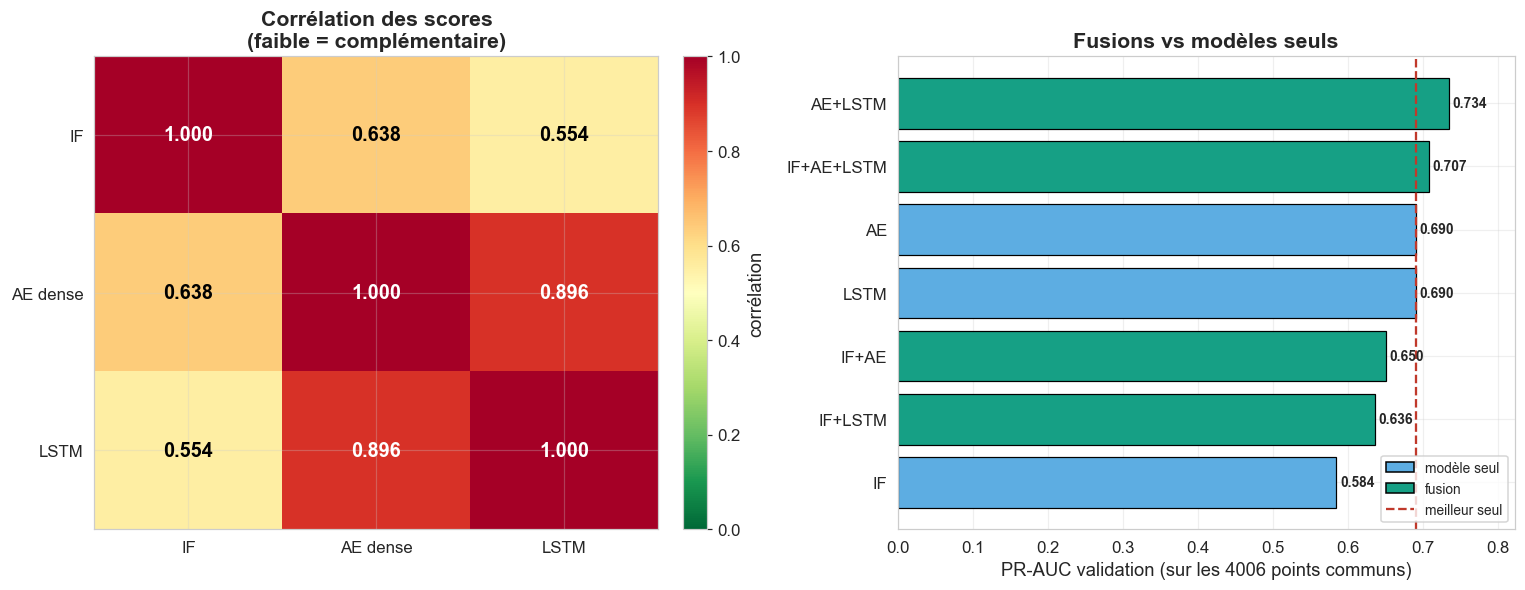

Figure sauvée : figures/fig_lstm93_fusion.png


In [64]:
# =============================================================
# 10.4bis — Corrélations et fusions (figures)
# =============================================================
# 1) matrice de corrélation IF/AE/LSTM  2) fusions vs modèles seuls
# Aucun recalcul de modèle : tout vient de _solo et _fus (§ 10.4).

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# ---- (1) Matrice de corrélation des 3 scores (sur points communs) ----
_s_if_v   = pd.Series(score_val,     index=val_c.index)
_s_ae_v   = pd.Series(score_ae_val,  index=_va_ae.index)
_s_lstm_v = pd.Series(score_lstm_1,  index=idx_va6)
_ic = _s_if_v.index.intersection(_s_ae_v.index).intersection(_s_lstm_v.index)
_M = np.column_stack([_s_if_v.loc[_ic].values,
                      _s_ae_v.loc[_ic].values,
                      _s_lstm_v.loc[_ic].values])
_corr = np.corrcoef(_M.T)
_labels = ["IF", "AE dense", "LSTM"]

im = ax1.imshow(_corr, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
for i in range(3):
    for j in range(3):
        ax1.text(j, i, f"{_corr[i,j]:.3f}", ha="center", va="center",
                 fontsize=13, fontweight="bold",
                 color="white" if _corr[i,j]>0.7 else "black")
ax1.set_xticks(range(3)); ax1.set_xticklabels(_labels)
ax1.set_yticks(range(3)); ax1.set_yticklabels(_labels)
ax1.set_title("Corrélation des scores\n(faible = complémentaire)", fontweight="bold")
fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04).set_label("corrélation")

# ---- (2) Fusions vs modèles seuls ----
_noms = list(_solo.keys()) + list(_fus.keys())
_vals = list(_solo.values()) + list(_fus.values())
_types = ["seul"]*len(_solo) + ["fusion"]*len(_fus)
_order = np.argsort(_vals)
_noms = [_noms[i] for i in _order]
_vals = [_vals[i] for i in _order]
_types = [_types[i] for i in _order]
_coul = ["#5DADE2" if t=="seul" else "#16A085" for t in _types]

_bars = ax2.barh(_noms, _vals, color=_coul, edgecolor="black", linewidth=0.8)
_best_solo_val = max(_solo.values())
ax2.axvline(_best_solo_val, color="#C0392B", ls="--", lw=1.5,
            label=f"meilleur seul ({_best_solo_val:.3f})")
for bar, v in zip(_bars, _vals):
    ax2.text(v+0.005, bar.get_y()+bar.get_height()/2, f"{v:.3f}",
             va="center", fontsize=9, fontweight="bold")

ax2.legend(handles=[Patch(facecolor="#5DADE2", edgecolor="black", label="modèle seul"),
                    Patch(facecolor="#16A085", edgecolor="black", label="fusion"),
                    plt.Line2D([0],[0], color="#C0392B", ls="--", label="meilleur seul")],
           loc="lower right", fontsize=9)
ax2.set_xlabel(f"PR-AUC validation (sur les {len(_ic)} points communs)")
ax2.set_xlim(0, max(_vals)*1.12)
ax2.set_title("Fusions vs modèles seuls", fontweight="bold")
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/fig_lstm93_fusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvée : figures/fig_lstm93_fusion.png")

Grille Phase B rechargée depuis le cache (27 configs sur 27 annoncées) — aucun entraînement.

=== Top 5 Phase B ===
  seq=6 units=64 code=16 -> 0.7205
  seq=6 units=96 code=16 -> 0.6904
  seq=6 units=96 code=24 -> 0.6866
  seq=6 units=128 code=16 -> 0.6823
  seq=9 units=64 code=16 -> 0.6821

>>> MEILLEUR Phase B : seq=6, units=64, code=16 -> 0.7205
    vs Phase A (0.689)   : +0.0314
    vs AE dense (0.685) : +0.0357

Config retenue pour l'ensemble : seq=6, units=64, code=16


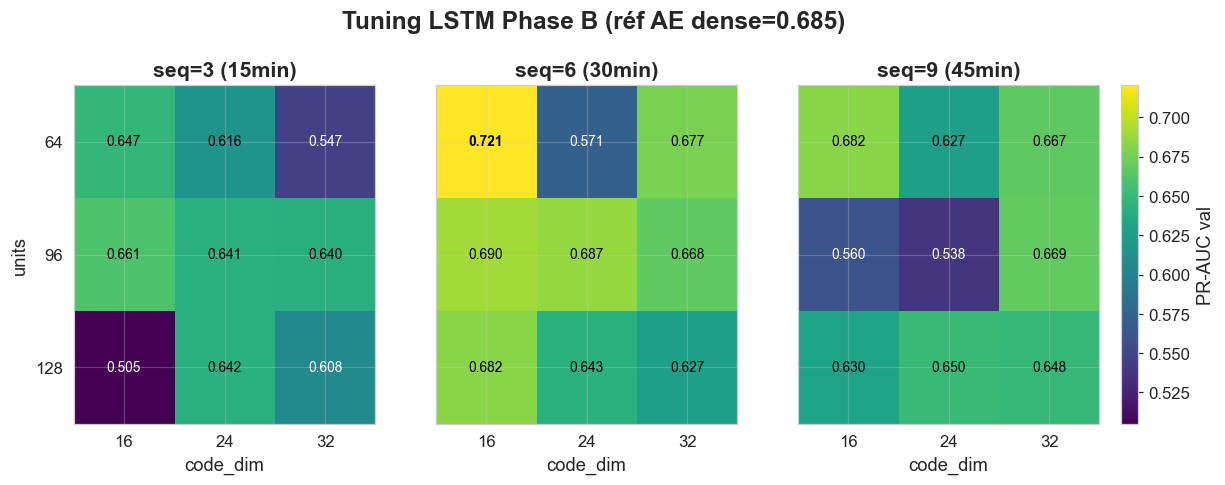

In [65]:
# =============================================================
# 10.5 — Tuning LSTM Phase B : affinage autour de la zone gagnante
# =============================================================
# La Phase A a montré : seq court + code élevé + units élevé gagnent, et le
# meilleur était AU BORD de la grille. On pousse donc code_dim et units
# au-delà, autour du seq_len gagnant. Test réservé.
#
# La grille complète a coûté 329 minutes. Ses 27 résultats sont conservés
# dans data/tuning_lstm_phaseB.csv : la cellule les recharge par défaut et
# régénère la heatmap depuis le cache, sans entraînement.
CACHE_B = Path("data/tuning_lstm_phaseB.csv")
FORCER_TUNING_B = False   # True uniquement pour relancer la grille (~5 h 30)

# --- grille Phase B (pousse les bornes) ---
GRID_SEQ_B  = [3, 6, 9]
GRID_UNIT_B = [64, 96, 128]
GRID_CODE_B = [16, 24, 32]
_total_B = len(GRID_SEQ_B)*len(GRID_UNIT_B)*len(GRID_CODE_B)

if CACHE_B.exists() and not FORCER_TUNING_B:
    _B_df = pd.read_csv(CACHE_B)
    _res_B = _B_df.to_dict("records")
    print(f"Grille Phase B rechargée depuis le cache ({len(_B_df)} configs sur "
          f"{_total_B} annoncées) — aucun entraînement.")
else:
    _nf = len(FEATURES_AE)

    def _build_lstm_b(L,u,c,lr=3e-3):
        e=keras.Input(shape=(L,_nf))
        x=layers.LSTM(u,activation="tanh",return_sequences=False)(e)
        x=layers.Dense(c,activation="relu")(x)
        x=layers.RepeatVector(L)(x)
        x=layers.LSTM(u,activation="tanh",return_sequences=True)(x)
        o=layers.TimeDistributed(layers.Dense(_nf,activation="sigmoid"))(x)
        m=keras.Model(e,o); m.compile(optimizer=keras.optimizers.Adam(lr),loss="mse")
        return m

    _okc_tr = train[FEATURES_AE].notna().all(axis=1)
    _okc_va = val[FEATURES_AE].notna().all(axis=1)
    _src_tr = train[_okc_tr]; _src_tr = _src_tr[_src_tr["Fault"]==0]
    _src_va = val[_okc_va]

    # cache séquences par seq_len
    _cache = {}
    for L in GRID_SEQ_B:
        Xtr,_ = fabriquer_sequences(_src_tr, FEATURES_AE, L)
        Xva,iva = fabriquer_sequences(_src_va, FEATURES_AE, L)
        yv = (val.loc[iva,"Fault"]!=0).astype(int).values
        sc = MinMaxScaler().fit(Xtr.reshape(-1,_nf))
        _cache[L]=(sc.transform(Xtr.reshape(-1,_nf)).reshape(Xtr.shape),
                   sc.transform(Xva.reshape(-1,_nf)).reshape(Xva.shape), yv)

    _res_B=[]; _t0=time.time()
    print(f"=== Phase B : {_total_B} configs ===\n")
    print(f"{'seq':>4}{'units':>7}{'code':>6}{'PR-AUC':>10}{'epochs':>8}{'temps':>8}")
    print("-"*45)
    for L,u,c in product(GRID_SEQ_B,GRID_UNIT_B,GRID_CODE_B):
        tf.random.set_seed(0); np.random.seed(0)
        Xtr_n,Xva_n,yv=_cache[L]; _tc=time.time()
        m=_build_lstm_b(L,u,c)
        h=m.fit(Xtr_n,Xtr_n,epochs=400,batch_size=64,validation_split=0.15,
                callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=25,
                restore_best_weights=True)],verbose=0)
        err=np.mean((Xva_n-m.predict(Xva_n,verbose=0))**2,axis=(1,2))
        ap=average_precision_score(yv,err)
        _res_B.append({"seq_len":L,"units":u,"code":c,"pr_auc":ap,
                       "epochs":len(h.history["loss"])})
        print(f"{L:>4}{u:>7}{c:>6}{ap:>10.4f}{len(h.history['loss']):>8}"
              f"{time.time()-_tc:>7.0f}s")
    print(f"\nTemps total : {(time.time()-_t0)/60:.0f} min")
    _B_df=pd.DataFrame(_res_B)
    _B_df.to_csv(CACHE_B, index=False)

_B_df = _B_df.sort_values("pr_auc", ascending=False).reset_index(drop=True)

print("\n=== Top 5 Phase B ===")
for _,r in _B_df.head(5).iterrows():
    print(f"  seq={int(r.seq_len)} units={int(r.units)} code={int(r.code)} -> {r.pr_auc:.4f}")

_bB = _B_df.iloc[0]
LSTM_BEST_SEQ, LSTM_BEST_U, LSTM_BEST_C = int(_bB.seq_len), int(_bB.units), int(_bB.code)
PRAUC_LSTM_B = float(_bB.pr_auc)
print(f"\n>>> MEILLEUR Phase B : seq={LSTM_BEST_SEQ}, units={LSTM_BEST_U}, "
      f"code={LSTM_BEST_C} -> {PRAUC_LSTM_B:.4f}")
print(f"    vs Phase A ({PRAUC_LSTM_A:.3f})   : {PRAUC_LSTM_B-PRAUC_LSTM_A:+.4f}")
print(f"    vs AE dense ({PRAUC_AE_VAL:.3f}) : {PRAUC_LSTM_B-PRAUC_AE_VAL:+.4f}")
print(f"\nConfig retenue pour l'ensemble : seq={LSTM_BEST_SEQ}, "
      f"units={LSTM_BEST_U}, code={LSTM_BEST_C}")

# --- heatmap Phase B (depuis le cache, sans entraînement) ---
fig,axes=plt.subplots(1,len(GRID_SEQ_B),figsize=(4.2*len(GRID_SEQ_B),4),sharey=True)
if len(GRID_SEQ_B)==1: axes=[axes]
_vmin,_vmax=_B_df.pr_auc.min(),_B_df.pr_auc.max()
for ax,L in zip(axes,GRID_SEQ_B):
    M=np.full((len(GRID_UNIT_B),len(GRID_CODE_B)),np.nan)
    for r in _res_B:
        if int(r["seq_len"])==L:
            M[GRID_UNIT_B.index(int(r["units"])),GRID_CODE_B.index(int(r["code"]))]=r["pr_auc"]
    im=ax.imshow(M,cmap="viridis",vmin=_vmin,vmax=_vmax,aspect="auto")
    ax.set_xticks(range(len(GRID_CODE_B))); ax.set_xticklabels(GRID_CODE_B)
    ax.set_yticks(range(len(GRID_UNIT_B))); ax.set_yticklabels(GRID_UNIT_B)
    ax.set_xlabel("code_dim"); ax.set_title(f"seq={L} ({L*5}min)",fontweight="bold")
    if L==GRID_SEQ_B[0]: ax.set_ylabel("units")
    for i in range(len(GRID_UNIT_B)):
        for j in range(len(GRID_CODE_B)):
            if not np.isnan(M[i,j]):
                ax.text(j,i,f"{M[i,j]:.3f}",ha="center",va="center",fontsize=9,
                        color="white" if M[i,j]<(_vmin+_vmax)/2 else "black",
                        fontweight="bold" if M[i,j]==_vmax else "normal")
fig.colorbar(im,ax=axes,fraction=0.025,pad=0.02).set_label("PR-AUC val")
fig.suptitle(f"Tuning LSTM Phase B (réf AE dense={PRAUC_AE_VAL:.3f})",
             fontweight="bold",y=1.05)
plt.savefig("figures/fig_lstm_phaseB.png",dpi=150,bbox_inches="tight"); plt.show()

In [66]:
# =============================================================
# 10.6 — Ensemble de 5 LSTM (config gagnante) + fusion finale
# =============================================================
# Le LSTM a une forte variance de graine pour une MÊME config. On stabilise
# par un ensemble de 5 LSTM dont on moyenne les erreurs de reconstruction.
#
# LES 5 RÉSEAUX NE SONT PAS RÉENTRAÎNÉS ICI. Ce sont exactement ceux qui sont
# déployés (model_final/lstm/lstm_0..4.keras), rechargés depuis le disque avec
# leur scaler. La fabrication des séquences conserve tous ses garde-fous
# (gap de 7 min, découpage par partition) via fabriquer_sequences().

with open("model_final/config.json", encoding="utf-8") as f:
    _cfg_lstm = json.load(f)
LSTM_SEQ = int(_cfg_lstm["lstm"]["seq_len"])
LSTM_U   = int(_cfg_lstm["lstm"]["units"])
LSTM_C   = int(_cfg_lstm["lstm"]["code_dim"])
N_LSTM   = int(_cfg_lstm["lstm"]["n_ensemble"])
_nf = len(FEATURES_AE)

# le modèle déployé doit correspondre à la config gagnante du tuning
assert (LSTM_SEQ, LSTM_U, LSTM_C) == (LSTM_BEST_SEQ, LSTM_BEST_U, LSTM_BEST_C), (
    f"le LSTM déployé (seq={LSTM_SEQ}, units={LSTM_U}, code={LSTM_C}) ne correspond "
    f"pas au gagnant de la Phase B (seq={LSTM_BEST_SEQ}, units={LSTM_BEST_U}, "
    f"code={LSTM_BEST_C})")
assert _cfg_lstm["features"] == FEATURES_AE
assert int(_cfg_lstm["nuit_gap_minutes"]) == 7

with open("model_final/scaler_lstm.pkl", "rb") as f:
    scaler_lstm = pickle.load(f)
lstm_ensemble = [keras.models.load_model(f"model_final/lstm/lstm_{s}.keras")
                 for s in range(N_LSTM)]
print(f"=== Ensemble de {N_LSTM} LSTM (seq={LSTM_SEQ}, u={LSTM_U}, code={LSTM_C}) ===")
print(f"{len(lstm_ensemble)} réseaux rechargés depuis model_final/lstm/ "
      f"(aucun réentraînement).\n")

# --- séquences (garde-fous : gap 7 min, découpage par partition) ---
_okc_tr = train[FEATURES_AE].notna().all(axis=1)
_okc_va = val[FEATURES_AE].notna().all(axis=1)
_okc_te = test[FEATURES_AE].notna().all(axis=1)
_src_tr = train[_okc_tr]; _src_tr = _src_tr[_src_tr["Fault"]==0]
_src_va = val[_okc_va]; _src_te = test[_okc_te]

Xtr, _       = fabriquer_sequences(_src_tr, FEATURES_AE, LSTM_SEQ)
Xva, idx_vaL = fabriquer_sequences(_src_va, FEATURES_AE, LSTM_SEQ)
Xte, idx_teL = fabriquer_sequences(_src_te, FEATURES_AE, LSTM_SEQ)
yvaL = (val.loc[idx_vaL, "Fault"] != 0).astype(int).values

_n3 = lambda X: scaler_lstm.transform(X.reshape(-1,_nf)).reshape(X.shape) if len(X) else X
Xva_n, Xte_n = _n3(Xva), _n3(Xte)

_err = lambda m,X: np.mean((X - m.predict(X,verbose=0))**2, axis=(1,2))
_errs_va = [_err(m, Xva_n) for m in lstm_ensemble]

# --- score de l'ENSEMBLE = moyenne des erreurs ---
score_lstm_va = np.mean(_errs_va, axis=0)
# score_lstm_te est calculé ici mais n'alimente AUCUNE métrique avant § 15.
score_lstm_te = np.mean([_err(m, Xte_n) for m in lstm_ensemble], axis=0)

_prauc_m = [average_precision_score(yvaL, e) for e in _errs_va]
PRAUC_LSTM_VAL = float(average_precision_score(yvaL, score_lstm_va))
_moy_m = float(np.mean(_prauc_m))

print(f"  séquences de validation : {len(score_lstm_va):,}")
print(f"  membres : {[f'{p:.3f}' for p in _prauc_m]}")
print(f"  moyenne membres : {_moy_m:.4f} ± {np.std(_prauc_m):.4f}")
print(f"  >>> ENSEMBLE : {PRAUC_LSTM_VAL:.4f}  (×{PRAUC_LSTM_VAL/yvaL.mean():.1f})")
_d_moy, _d_best = PRAUC_LSTM_VAL - _moy_m, PRAUC_LSTM_VAL - max(_prauc_m)
print(f"      écart à la moyenne des membres : {_d_moy:+.4f} | "
      f"au meilleur membre : {_d_best:+.4f}")
if _d_moy > 0:
    print("      -> l'ensemble dépasse la moyenne des membres.")
else:
    print("      -> l'ensemble ne dépasse PAS la moyenne des membres.")

# =============================================================
# Fusion : IF + AE + LSTM(ensemble)
# =============================================================
print(f"\n=== Fusion (points communs) ===")
_s_if   = pd.Series(score_val,     index=val_c.index)
_s_ae   = pd.Series(score_ae_val,  index=_va_ae.index)
_s_lstm = pd.Series(score_lstm_va, index=idx_vaL)
_idx = _s_if.index.intersection(_s_ae.index).intersection(_s_lstm.index)
_y = (val.loc[_idx,"Fault"]!=0).astype(int).values
_base=_y.mean()
_r = lambda s: rankdata(s.loc[_idx].values)/len(_idx)
R={"IF":_r(_s_if),"AE":_r(_s_ae),"LSTM":_r(_s_lstm)}
print(f"  points communs : {len(_idx)} | anomalies : {int(_y.sum())}")
print(f"  ATTENTION : les PR-AUC ci-dessous sont RESTREINTS à ces {len(_idx)} points")
print("  et ne sont donc pas comparables tels quels à ceux des § 8 et § 9.")
print()
_solo={n:average_precision_score(_y,r) for n,r in R.items()}
for n,ap in _solo.items():
    print(f"  {n:<5} seul (sur {len(_idx)} pts communs) : {ap:.4f}")
print()
_fus={}
for k in (2,3):
    for combo in combinations(R,k):
        ap=average_precision_score(_y,np.mean([R[n] for n in combo],axis=0))
        _fus["+".join(combo)]=ap; print(f"  {'+'.join(combo):<16}: {ap:.4f}")
_bs=max(_solo,key=_solo.get); _bf=max(_fus,key=_fus.get)
print(f"\n  meilleur seul : {_bs} ({_solo[_bs]:.4f})")
print(f"  meilleure fusion : {_bf} ({_fus[_bf]:.4f})")
print(f"  gain : {_fus[_bf]-_solo[_bs]:+.4f}")

# --- sauvegarde du score IF (les scores AE/LSTM déployés sont dans model_final/) ---
# NOTE : data/score_ae_val.npy et data/score_lstm_va.npy conservent les scores de
# la PHASE EXPLORATOIRE (modèles entraînés à la volée, aujourd'hui remplacés par
# ceux de model_final/). Ils ne sont volontairement PAS réécrits : ils servent de
# témoin en § 15.3 pour montrer que l'échelle des erreurs de reconstruction
# dépend de l'entraînement, ce qui impose de recalculer les références de rang.
np.save("data/score_val.npy", score_val)
np.save("data/idx_lstm_va.npy", idx_vaL.values)
print(f"\n  score IF sauvé dans data/score_val.npy")

=== Ensemble de 5 LSTM (seq=6, u=64, code=16) ===
5 réseaux rechargés depuis model_final/lstm/ (aucun réentraînement).



  séquences de validation : 4,006
  membres : ['0.600', '0.676', '0.598', '0.639', '0.645']
  moyenne membres : 0.6316 ± 0.0294
  >>> ENSEMBLE : 0.6583  (×15.0)
      écart à la moyenne des membres : +0.0267 | au meilleur membre : -0.0178
      -> l'ensemble dépasse la moyenne des membres.

=== Fusion (points communs) ===
  points communs : 4006 | anomalies : 176
  ATTENTION : les PR-AUC ci-dessous sont RESTREINTS à ces 4006 points
  et ne sont donc pas comparables tels quels à ceux des § 8 et § 9.

  IF    seul (sur 4006 pts communs) : 0.5843
  AE    seul (sur 4006 pts communs) : 0.6903
  LSTM  seul (sur 4006 pts communs) : 0.6583

  IF+AE           : 0.6501
  IF+LSTM         : 0.6215
  AE+LSTM         : 0.7234
  IF+AE+LSTM      : 0.6871

  meilleur seul : AE (0.6903)
  meilleure fusion : AE+LSTM (0.7234)
  gain : +0.0331

  score IF sauvé dans data/score_val.npy


---
## 11. Fusion des détecteurs
---

Les scores de l'AE dense et du LSTM sont ramenés à des **rangs** avant d'être combinés, pour neutraliser la différence d'échelle entre leurs erreurs de reconstruction. Cette section compare plusieurs méthodes de combinaison et mesure ce que chacune fait courir comme risque de sur-ajustement sur la validation.

In [67]:
# =============================================================
# 11.1 — Comparaison des méthodes de fusion (AE + LSTM)
# =============================================================
# La fusion par moyenne des rangs sert de référence. On compare ici d'autres
# méthodes. ATTENTION : les méthodes qui CHOISISSENT des paramètres sur le
# val (pondération optimale, stacking) peuvent sur-ajuster -> gain illusoire.
# On les signale. Le test tranchera. Test réservé ici.
#
# NOTE SUR LES RANGS — cette cellule compare des MÉTHODES de combinaison entre
# elles ; les rangs y sont donc calculés sur le lot, de façon identique pour
# toutes les méthodes, pour que la comparaison soit à armes égales. Une fois la
# méthode choisie, la § 12 l'applique avec la convention du DÉPLOIEMENT (rangs
# contre référence figée). L'écart entre les deux conventions est de l'ordre de
# 1e-5 sur le PR-AUC : il ne change aucun classement de méthode.

# --- aligner AE et LSTM sur points communs ---
_s_ae   = pd.Series(score_ae_val,  index=_va_ae.index)
_s_lstm = pd.Series(score_lstm_va, index=idx_vaL)
_idx = _s_ae.index.intersection(_s_lstm.index)
_y = (val.loc[_idx, "Fault"] != 0).astype(int).values
_base = _y.mean()

_r_ae   = rankdata(_s_ae.loc[_idx].values)  / len(_idx)
_r_lstm = rankdata(_s_lstm.loc[_idx].values)/ len(_idx)
# z-scores (pour méthode 4)
_z_ae   = (_s_ae.loc[_idx].values   - _s_ae.loc[_idx].mean())   / _s_ae.loc[_idx].std()
_z_lstm = (_s_lstm.loc[_idx].values - _s_lstm.loc[_idx].mean()) / _s_lstm.loc[_idx].std()

print(f"Points communs AE+LSTM : {len(_idx)} | anomalies : {int(_y.sum())} ({_base:.1%})\n")
print(f"Détecteurs seuls, RESTREINTS à ces {len(_idx)} points communs :")
print(f"  AE dense seul      : {average_precision_score(_y,_r_ae):.4f} | "
      f"LSTM ensemble seul : {average_precision_score(_y,_r_lstm):.4f}")
print(f"  (à ne pas confondre avec le PR-AUC de l'AE sur TOUT le lot de "
      f"validation, § 9.3 : {PRAUC_AE_VAL:.4f} sur {len(score_ae_val)} points)")

_resultats = {}

# --- Méthode 1 : moyenne des rangs (référence, aucun risque) ---
_resultats["1. Moyenne des rangs"] = (average_precision_score(_y, (_r_ae+_r_lstm)/2), "aucun")

# --- Méthode 3 : max des rangs (aucun risque) ---
_resultats["3. Max des rangs"] = (average_precision_score(_y, np.maximum(_r_ae,_r_lstm)), "aucun")

# --- Méthode 4 : moyenne des z-scores (aucun risque) ---
_resultats["4. Moyenne z-scores"] = (average_precision_score(_y, (_z_ae+_z_lstm)/2), "aucun")

# --- Méthode 2 : moyenne pondérée, balayage de w (risque faible) ---
_best_w, _best_ap = 0.5, 0
for w in np.arange(0, 1.01, 0.05):
    ap = average_precision_score(_y, w*_r_ae + (1-w)*_r_lstm)
    if ap > _best_ap: _best_ap, _best_w = ap, w
_resultats[f"2. Pondérée (w_AE={_best_w:.2f})"] = (_best_ap, "FAIBLE (w choisi sur val)")

# --- Méthode 5 : stacking régression logistique (risque FORT) ---
# évalué en cross-val pour limiter le sur-ajustement (honnête)
X_stack = np.column_stack([_r_ae, _r_lstm])
_lr_stack = LogisticRegression()
_proba_cv = cross_val_predict(_lr_stack, X_stack, _y, cv=5, method="predict_proba")[:,1]
_resultats["5. Stacking (CV honnête)"] = (average_precision_score(_y, _proba_cv),
                                          "FORT (méta-modèle sur val)")

# --- tableau comparatif ---
print("=== Comparaison des méthodes de fusion (PR-AUC val) ===\n")
print(f"{'méthode':<30}{'PR-AUC':>9}{'gain':>8}   risque")
print("-"*70)
_ref = _resultats["1. Moyenne des rangs"][0]
for nom, (ap, risque) in sorted(_resultats.items(), key=lambda x:-x[1][0]):
    print(f"{nom:<30}{ap:>9.4f}{ap-_ref:>+8.4f}   {risque}")

print(f"\nRéférence (moyenne des rangs) : {_ref:.4f}")
_best_meth = max(_resultats, key=lambda k:_resultats[k][0])
print(f"Meilleure méthode val : {_best_meth} ({_resultats[_best_meth][0]:.4f})")
_gain_risque = _resultats[_best_meth][0] - _ref
print(f"Gain de la meilleure méthode sur la référence : {_gain_risque:+.4f}")
if _resultats[_best_meth][1] != "aucun" and _gain_risque < 0.01:
    print("-> le gain est inférieur à 0.01 ET provient d'une méthode à risque de")
    print("   sur-ajustement : la moyenne des rangs est conservée pour le système final.")
elif _resultats[_best_meth][1] == "aucun":
    print("-> la meilleure méthode est sans risque de sur-ajustement.")
else:
    print("-> gain notable mais méthode à risque : à confirmer sur le test.")

Points communs AE+LSTM : 4006 | anomalies : 176 (4.4%)

Détecteurs seuls, RESTREINTS à ces 4006 points communs :
  AE dense seul      : 0.6903 | LSTM ensemble seul : 0.6583
  (à ne pas confondre avec le PR-AUC de l'AE sur TOUT le lot de validation, § 9.3 : 0.6848 sur 4219 points)


=== Comparaison des méthodes de fusion (PR-AUC val) ===

méthode                          PR-AUC    gain   risque
----------------------------------------------------------------------
2. Pondérée (w_AE=0.45)          0.7244 +0.0009   FAIBLE (w choisi sur val)
1. Moyenne des rangs             0.7234 +0.0000   aucun
4. Moyenne z-scores              0.7140 -0.0094   aucun
3. Max des rangs                 0.6618 -0.0617   aucun
5. Stacking (CV honnête)         0.5233 -0.2002   FORT (méta-modèle sur val)

Référence (moyenne des rangs) : 0.7234
Meilleure méthode val : 2. Pondérée (w_AE=0.45) (0.7244)
Gain de la meilleure méthode sur la référence : +0.0009
-> le gain est inférieur à 0.01 ET provient d'une méthode à risque de
   sur-ajustement : la moyenne des rangs est conservée pour le système final.


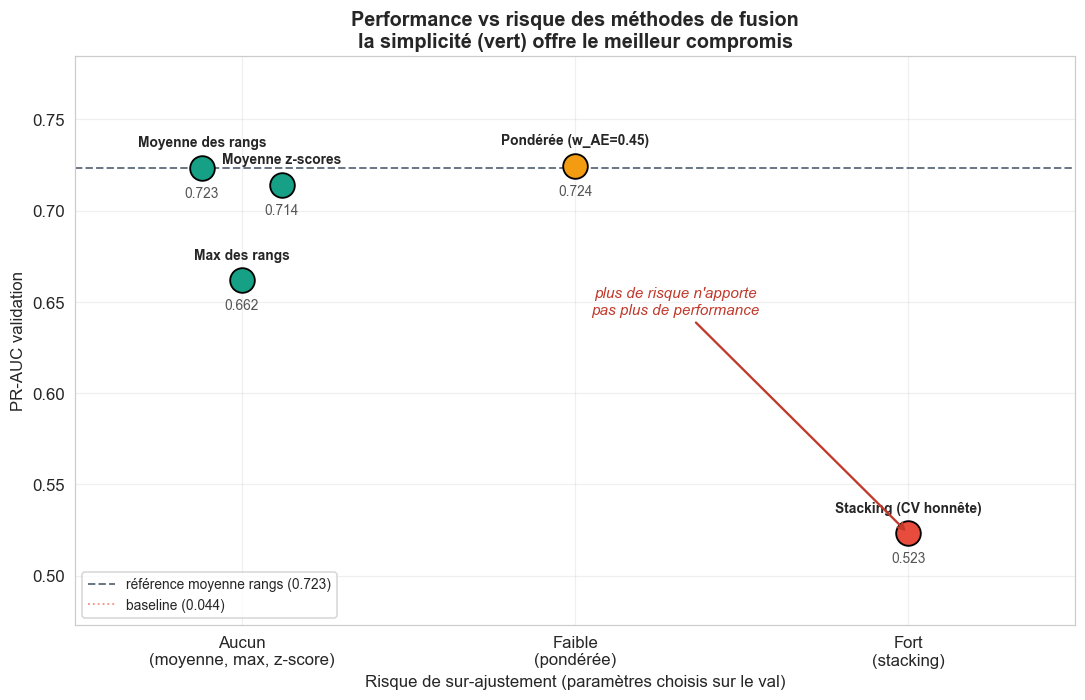

Figure sauvée : figures/fig_fusion_scatter.png


In [68]:
# =============================================================
# 11.2 — Performance × risque de sur-ajustement (figure)
# =============================================================
# Montre que les méthodes "à risque" ne gagnent rien : plus on va vers la
# droite (risque de sur-ajustement), moins la performance suit.

fig, ax = plt.subplots(figsize=(10, 6.5))

# niveau de risque numérique
_risque_niv = {"aucun":0, "FAIBLE (w choisi sur val)":1, "FORT (méta-modèle sur val)":2}
_coul_niv   = {0:"#16A085", 1:"#F39C12", 2:"#E74C3C"}

for nom,(ap,risque) in _resultats.items():
    x = _risque_niv[risque]
    # petit jitter horizontal si plusieurs méthodes au même niveau de risque
    _memes = [k for k,(a,r) in _resultats.items() if _risque_niv[r]==x]
    _jit = (_memes.index(nom) - (len(_memes)-1)/2) * 0.12
    ax.scatter(x+_jit, ap, s=260, color=_coul_niv[x], edgecolor="black",
               linewidth=1.2, zorder=3)
    _label = nom.split(". ",1)[1] if ". " in nom else nom
    ax.annotate(_label, (x+_jit, ap), fontsize=9, ha="center",
                va="bottom", xytext=(0,12), textcoords="offset points",
                fontweight="bold")
    ax.annotate(f"{ap:.3f}", (x+_jit, ap), fontsize=9, ha="center",
                va="top", xytext=(0,-12), textcoords="offset points", color="#555")

# ligne de référence (moyenne des rangs) + baseline
_ref = _resultats["1. Moyenne des rangs"][0]
ax.axhline(_ref, color="#2C3E50", ls="--", lw=1.3, alpha=0.7,
           label=f"référence moyenne rangs ({_ref:.3f})")
ax.axhline(_base, color="#E74C3C", ls=":", lw=1.2, alpha=0.6,
           label=f"baseline ({_base:.3f})")

# annotation du message clé, ancrée sur la méthode la plus risquée
_ap_stack = _resultats["5. Stacking (CV honnête)"][0]
ax.annotate("plus de risque n'apporte\npas plus de performance",
            xy=(2, _ap_stack),
            xytext=(1.3, _ref-0.08), fontsize=10, color="#C0392B",
            ha="center", style="italic",
            arrowprops=dict(arrowstyle="->", color="#C0392B", lw=1.5))

ax.set_xticks([0,1,2])
ax.set_xticklabels(["Aucun\n(moyenne, max, z-score)",
                    "Faible\n(pondérée)",
                    "Fort\n(stacking)"])
ax.set_xlabel("Risque de sur-ajustement (paramètres choisis sur le val)", fontsize=11)
ax.set_ylabel("PR-AUC validation", fontsize=11)
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(min(a for a,_ in _resultats.values())-0.05,
            max(a for a,_ in _resultats.values())+0.06)
ax.set_title("Performance vs risque des méthodes de fusion\n"
             "la simplicité (vert) offre le meilleur compromis",
             fontweight="bold", fontsize=13)
ax.legend(loc="lower left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_fusion_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvée : figures/fig_fusion_scatter.png")

Référence de rang — AE : 4219 points | LSTM : 4006 séquences (règle du déploiement)
=== Système final : fusion AE+LSTM (moyenne des rangs) ===
  PR-AUC val : 0.7234  (×16.5)
  points : 4006 | anomalies : 176 (4.4%)

=== Critère principal : F2-score maximal (orienté rappel) ===
  seuil retenu   : 0.9460
  précision      : 0.731
  rappel         : 0.727
  F2-score       : 0.728

=== Points de fonctionnement (val) ===
critère                  seuil  précis.  rappel  ratées
-------------------------------------------------------
F2 max (principal)      0.9460    0.731   0.727      48
R>=0.8                  0.8107    0.283   0.801      35
R>=0.85                 0.4572    0.072   0.852      26
R>=0.9                  0.2648    0.049   0.903      17

  ('ratées' = pannes non détectées sur 176)
  Lecture : au-delà de R >= 0.85 la précision rejoint la baseline (0.044) — le rappel plafonne sur validation.


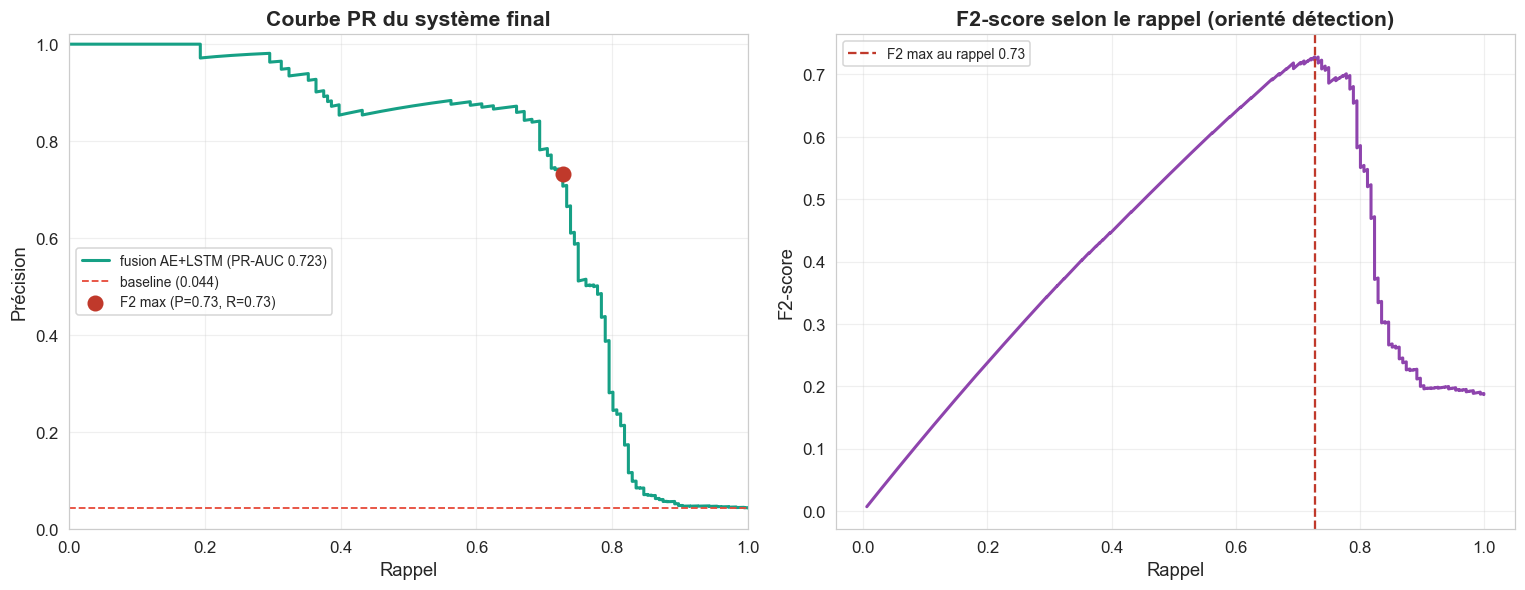


Critère retenu : F2 max. Calibration et vérification finales en § 15.


In [69]:
# =============================================================
# 12. Choix du critère de décision (sur validation)
# =============================================================
# Cette section établit le CRITÈRE de seuil. En exploitation PV, une panne
# ratée (faux négatif) coûte plus cher qu'une fausse alerte : on retient donc
# le F2-score, qui pondère le rappel 2x plus que la précision.
# La table des points de fonctionnement documente les alternatives.
#
# CONVENTION DE RANG — le score de fusion est une moyenne de rangs, encore
# faut-il préciser : rang parmi quoi ? On applique ici la règle EXACTE du
# déploiement (DetecteurPV._rang) : chaque score est comparé par searchsorted
# à une RÉFÉRENCE FIGÉE, propre à chaque détecteur — toute la validation pour
# l'AE, toutes les séquences de validation pour le LSTM. On n'utilise donc PAS
# rankdata sur le lot scoré, qui serait transductif : en production on score
# parfois un seul point, et son rang ne doit dépendre que de la référence.
# Conséquence : le seuil calculé ici est exactement celui que la § 15.6
# recalcule et écrit dans config.json — un seul seuil circule dans tout le
# notebook, et un assert le vérifie en 15.5bis. Test réservé.

# --- score de fusion AE+LSTM (moyenne des rangs) sur points communs ---
_s_ae   = pd.Series(score_ae_val,  index=_va_ae.index)
_s_lstm = pd.Series(score_lstm_va, index=idx_vaL)
_idx = _s_ae.index.intersection(_s_lstm.index)
_y = (val.loc[_idx, "Fault"] != 0).astype(int).values
_base = _y.mean()

# rang = fraction de la référence <= valeur (référence triée une fois)
_rang_ref = lambda v, ref: np.searchsorted(np.sort(ref), v, side="right") / len(ref)
_r_ae   = _rang_ref(_s_ae.loc[_idx].values,   score_ae_val)    # réf. : 100 % de val
_r_lstm = _rang_ref(_s_lstm.loc[_idx].values, score_lstm_va)   # réf. : toutes les séquences
score_fusion_val = (_r_ae + _r_lstm) / 2      # LE score du système final

print(f"Référence de rang — AE : {len(score_ae_val)} points | "
      f"LSTM : {len(score_lstm_va)} séquences (règle du déploiement)")

PRAUC_FUSION_VAL = float(average_precision_score(_y, score_fusion_val))
print(f"=== Système final : fusion AE+LSTM (moyenne des rangs) ===")
print(f"  PR-AUC val : {PRAUC_FUSION_VAL:.4f}  (×{PRAUC_FUSION_VAL/_base:.1f})")
print(f"  points : {len(_idx)} | anomalies : {int(_y.sum())} ({_base:.1%})\n")

# --- courbe PR + F2 en chaque seuil ---
_prec, _rec, _thr = precision_recall_curve(_y, score_fusion_val)
_prec_t, _rec_t = _prec[:-1], _rec[:-1]
# F2 = (1+4)*P*R / (4*P + R) ; beta=2 pondère le rappel
_beta2 = 2**2
_f2 = (1+_beta2)*_prec_t*_rec_t / (_beta2*_prec_t + _rec_t + 1e-9)

# --- critère principal : seuil qui MAXIMISE le F2 ---
_i_f2 = int(np.argmax(_f2))
SEUIL_CANDIDAT = float(_thr[_i_f2])
print(f"=== Critère principal : F2-score maximal (orienté rappel) ===")
print(f"  seuil retenu   : {SEUIL_CANDIDAT:.4f}")
print(f"  précision      : {_prec_t[_i_f2]:.3f}")
print(f"  rappel         : {_rec_t[_i_f2]:.3f}")
print(f"  F2-score       : {_f2[_i_f2]:.3f}")

# --- table de points de fonctionnement (pour la soutenance) ---
print(f"\n=== Points de fonctionnement (val) ===")
print(f"{'critère':<22}{'seuil':>8}{'précis.':>9}{'rappel':>8}{'ratées':>8}")
print("-"*55)
_n_ano = int(_y.sum())
print(f"{'F2 max (principal)':<22}{SEUIL_CANDIDAT:>8.4f}{_prec_t[_i_f2]:>9.3f}"
      f"{_rec_t[_i_f2]:>8.3f}{_n_ano-int(_rec_t[_i_f2]*_n_ano):>8}")
for r_cible in [0.80, 0.85, 0.90]:
    _mask = _rec_t >= r_cible
    if _mask.any():
        _i = int(np.where(_mask, _prec_t, -1).argmax())  # précision max sous R>=cible
        _ratees = _n_ano - int(_rec_t[_i]*_n_ano)
        print(f"{'R>='+str(r_cible):<22}{_thr[_i]:>8.4f}{_prec_t[_i]:>9.3f}"
              f"{_rec_t[_i]:>8.3f}{_ratees:>8}")

print(f"\n  ('ratées' = pannes non détectées sur {_n_ano})")
print(f"  Lecture : au-delà de R >= 0.85 la précision rejoint la baseline "
      f"({_base:.3f}) — le rappel plafonne sur validation.")

# --- figure : courbe PR + F2 + points ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
ax1.plot(_rec, _prec, color="#16A085", lw=2,
         label=f"fusion AE+LSTM (PR-AUC {PRAUC_FUSION_VAL:.3f})")
ax1.axhline(_base, color="#E74C3C", ls="--", lw=1.2, label=f"baseline ({_base:.3f})")
ax1.scatter([_rec_t[_i_f2]],[_prec_t[_i_f2]], color="#C0392B", s=90, zorder=5,
            label=f"F2 max (P={_prec_t[_i_f2]:.2f}, R={_rec_t[_i_f2]:.2f})")
ax1.set_xlabel("Rappel"); ax1.set_ylabel("Précision"); ax1.set_xlim(0,1); ax1.set_ylim(0,1.02)
ax1.set_title("Courbe PR du système final", fontweight="bold"); ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

ax2.plot(_rec_t, _f2, color="#8E44AD", lw=2)
ax2.axvline(_rec_t[_i_f2], color="#C0392B", ls="--", lw=1.5,
            label=f"F2 max au rappel {_rec_t[_i_f2]:.2f}")
ax2.set_xlabel("Rappel"); ax2.set_ylabel("F2-score")
ax2.set_title("F2-score selon le rappel (orienté détection)", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig_seuil_fusion_final.png", dpi=150, bbox_inches="tight")
plt.show()

np.save("data/score_fusion_val.npy", score_fusion_val)
print("\nCritère retenu : F2 max. Calibration et vérification finales en § 15.")

---
## 13. Sauvegarde du système final pour le déploiement
---

Les 5 autoencodeurs denses et les 5 LSTM du système final sont sur le disque dans `model_final/`,
avec leurs scalers, les scores de référence servant au calcul des rangs, et `config.json`.

La cellule ci-dessous **régénère** cet ensemble. Elle est protégée par `RUN_TRAINING = False` :
en `Run All`, elle constate simplement que `model_final/` existe et ne réentraîne rien. Passer
`RUN_TRAINING = True` relance environ 50 minutes de calcul **et invalide les références et le
seuil**, qui devront être recalculés par la section 15.

In [70]:
# =============================================================
# 13. Sauvegarde du système final pour déploiement (Grafana)
# =============================================================
# Entraîne et SAUVEGARDE les 10 modèles (5 AE + 5 LSTM), avec les
# architectures EXACTES des sections 9.3 et 10.6, + scalers + jeu de
# référence (scores val) + config JSON. Fusion par rangs.
#
# ~50 min de calcul. NE DOIT PAS s'exécuter lors d'un Run All : les modèles
# sont déjà sur le disque, et un réentraînement produirait de nouveaux poids,
# donc de nouvelles échelles d'erreur — les références ref_score_*.npy et le
# seuil deviendraient incohérents jusqu'à ce que la section 15 les recalcule.
RUN_TRAINING = False   # True uniquement pour régénérer model_final/ (~50 min)

if not RUN_TRAINING and Path("model_final/config.json").exists():
    print("model_final/ déjà présent — réentraînement ignoré.")
    print("Passer RUN_TRAINING = True pour régénérer les 10 modèles (~50 min).")
    with open("model_final/config.json", encoding="utf-8") as f:
        _cfg_dep = json.load(f)
    print(f"  features  : {_cfg_dep['features']}")
    print(f"  AE        : {_cfg_dep['ae']['n_ensemble']} réseaux, "
          f"code_dim={_cfg_dep['ae']['code_dim']}, lr={_cfg_dep['ae']['lr']:.0e}")
    print(f"  LSTM      : {_cfg_dep['lstm']['n_ensemble']} réseaux, "
          f"seq_len={_cfg_dep['lstm']['seq_len']}, units={_cfg_dep['lstm']['units']}, "
          f"code_dim={_cfg_dep['lstm']['code_dim']}")
else:
    # SEUIL_FUSION n'est défini QUE dans cette branche : c'est un seuil
    # provisoire, écrit dans config.json pour que le fichier soit valide dès
    # sa création. Le seuil de production est recalculé et réécrit en § 15.6.
    SEUIL_FUSION = SEUIL_CANDIDAT

    os.makedirs("model_final/ae", exist_ok=True)
    os.makedirs("model_final/lstm", exist_ok=True)

    N_ENS = 5
    _AE_CODE_DIM, _AE_LR = AE_CODE_DIM, AE_LR
    _LSTM_SEQ, _LSTM_U, _LSTM_C = LSTM_BEST_SEQ, LSTM_BEST_U, LSTM_BEST_C
    _nf = len(FEATURES_AE)
    _t0 = time.time()

    # ============================================================
    # 1) AE dense — archi EXACTE de la section 9.3
    #    scaler sur le SAIN seulement, 200 epochs, patience 15
    # ============================================================
    _ok_tr = train[FEATURES_AE].notna().all(axis=1)
    _tr_ae = train[_ok_tr]; _tr_sain_ae = _tr_ae[_tr_ae["Fault"]==0]
    scaler_ae_save = MinMaxScaler().fit(_tr_sain_ae[FEATURES_AE])
    Xtr_ae_save = scaler_ae_save.transform(_tr_sain_ae[FEATURES_AE])

    def _build_ae_save(seed):
        tf.random.set_seed(seed); np.random.seed(seed)
        e=keras.Input(shape=(_nf,))
        x=layers.Dense(_AE_CODE_DIM,activation="relu")(e)
        o=layers.Dense(_nf,activation="sigmoid")(x)
        m=keras.Model(e,o); m.compile(optimizer=keras.optimizers.Adam(_AE_LR),loss="mse")
        return m

    print("=== Entraînement + sauvegarde des 5 AE ===")
    for s in range(N_ENS):
        m=_build_ae_save(s)
        m.fit(Xtr_ae_save,Xtr_ae_save,epochs=200,batch_size=64,validation_split=0.15,
              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=15,
              restore_best_weights=True)],verbose=0)
        m.save(f"model_final/ae/ae_{s}.keras")
        print(f"  ae_{s}.keras sauvé")

    # ============================================================
    # 2) LSTM — archi EXACTE de la section 10.6, scaler sur sain
    # ============================================================
    _Xtr_seq,_ = fabriquer_sequences(_tr_sain_ae, FEATURES_AE, _LSTM_SEQ)
    scaler_lstm_save = MinMaxScaler().fit(_Xtr_seq.reshape(-1,_nf))
    _Xtr_seq_n = scaler_lstm_save.transform(_Xtr_seq.reshape(-1,_nf)).reshape(_Xtr_seq.shape)

    def _build_lstm_save(seed):
        tf.random.set_seed(seed); np.random.seed(seed)
        e=keras.Input(shape=(_LSTM_SEQ,_nf))
        x=layers.LSTM(_LSTM_U,activation="tanh",return_sequences=False)(e)
        x=layers.Dense(_LSTM_C,activation="relu")(x)
        x=layers.RepeatVector(_LSTM_SEQ)(x)
        x=layers.LSTM(_LSTM_U,activation="tanh",return_sequences=True)(x)
        o=layers.TimeDistributed(layers.Dense(_nf,activation="sigmoid"))(x)
        m=keras.Model(e,o); m.compile(optimizer=keras.optimizers.Adam(3e-3),loss="mse")
        return m

    print("\n=== Entraînement + sauvegarde des 5 LSTM ===")
    for s in range(N_ENS):
        m=_build_lstm_save(s)
        m.fit(_Xtr_seq_n,_Xtr_seq_n,epochs=400,batch_size=64,validation_split=0.15,
              callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss",patience=25,
              restore_best_weights=True)],verbose=0)
        m.save(f"model_final/lstm/lstm_{s}.keras")
        print(f"  lstm_{s}.keras sauvé")

    # ============================================================
    # 3) Scalers + référence (scores val) + config
    # ============================================================
    with open("model_final/scaler_ae.pkl","wb") as f: pickle.dump(scaler_ae_save,f)
    with open("model_final/scaler_lstm.pkl","wb") as f: pickle.dump(scaler_lstm_save,f)
    np.save("model_final/ref_score_ae.npy",  score_ae_val)
    np.save("model_final/ref_score_lstm.npy", score_lstm_va)

    _config = {
        "features": FEATURES_AE,
        "ae":  {"n_ensemble":N_ENS,"code_dim":_AE_CODE_DIM,"lr":_AE_LR,"epochs":200},
        "lstm":{"n_ensemble":N_ENS,"seq_len":_LSTM_SEQ,"units":_LSTM_U,
                "code_dim":_LSTM_C,"lr":3e-3},
        "fusion":"moyenne des rangs AE+LSTM contre reference val",
        "seuil_fusion": float(SEUIL_FUSION),
        "nuit_gap_minutes": 7,
        "regle":"anomalie si score_fusion >= seuil_fusion"
    }
    with open("model_final/config.json","w",encoding="utf-8") as f:
        json.dump(_config,f,indent=2,ensure_ascii=False)

    print(f"\n=== Système sauvé dans model_final/ (en {(time.time()-_t0)/60:.0f} min) ===")
    print("  ae/ae_0..4.keras | lstm/lstm_0..4.keras")
    print("  scaler_ae.pkl | scaler_lstm.pkl")
    print("  ref_score_ae.npy | ref_score_lstm.npy | config.json")
    print(f"  seuil provisoire : {SEUIL_FUSION:.4f} (recalculé en § 15.6)")

model_final/ déjà présent — réentraînement ignoré.
Passer RUN_TRAINING = True pour régénérer les 10 modèles (~50 min).
  features  : ['GTI', 'Pg', 'Va', 'Vg', 'Ia', 'TPV']
  AE        : 5 réseaux, code_dim=4, lr=1e-03
  LSTM      : 5 réseaux, seq_len=6, units=64, code_dim=16


In [71]:
# =============================================================
# 14. Service de prédiction déployable (pour Grafana)
# =============================================================
# Charge model_final/ et classe de nouvelles mesures. Fusion par rangs
# contre la référence val figée (seuil lu dans config.json).
#
# AUTONOMIE VOLONTAIRE : cette cellule réimporte ses dépendances et
# réimplémente en interne la fabrication des séquences glissantes. C'est la
# SEULE duplication assumée de fabriquer_sequences() (§ 5.4) : la classe doit
# pouvoir être copiée telle quelle dans un service de production, sans dépendre
# d'aucune variable ni d'aucune fonction du notebook.

import os, json, pickle, numpy as np, pandas as pd
import tensorflow as tf
from tensorflow import keras

class DetecteurPV:
    """Système de détection d'anomalies PV (AE+LSTM, fusion par rangs)."""

    def __init__(self, dossier="model_final"):
        # config
        with open(f"{dossier}/config.json", encoding="utf-8") as f:
            self.cfg = json.load(f)
        self.features = self.cfg["features"]
        self.seq_len  = self.cfg["lstm"]["seq_len"]
        self.seuil    = self.cfg["seuil_fusion"]
        self.gap_min  = self.cfg["nuit_gap_minutes"]
        self._nf = len(self.features)
        # modèles
        self.aes   = [keras.models.load_model(f"{dossier}/ae/ae_{s}.keras")
                      for s in range(self.cfg["ae"]["n_ensemble"])]
        self.lstms = [keras.models.load_model(f"{dossier}/lstm/lstm_{s}.keras")
                      for s in range(self.cfg["lstm"]["n_ensemble"])]
        # scalers
        with open(f"{dossier}/scaler_ae.pkl","rb") as f:   self.sc_ae   = pickle.load(f)
        with open(f"{dossier}/scaler_lstm.pkl","rb") as f: self.sc_lstm = pickle.load(f)
        # référence (scores val bruts) pour le rang — triée UNE fois
        self.ref_ae   = np.sort(np.load(f"{dossier}/ref_score_ae.npy"))
        self.ref_lstm = np.sort(np.load(f"{dossier}/ref_score_lstm.npy"))
        print(f"Détecteur chargé : {len(self.aes)} AE + {len(self.lstms)} LSTM | seuil {self.seuil:.4f}")

    def _rang(self, valeurs, reference_triee):
        """Rang dans la référence (déjà triée) : fraction de réf <= valeur.
        Vectorisé : un seul searchsorted pour tout le lot. On ne recalcule
        JAMAIS un rang sur le lot courant (ce serait transductif)."""
        return np.searchsorted(reference_triee, valeurs,
                               side="right") / len(reference_triee)

    def _err_ae(self, Xn):
        e = np.mean([np.mean((Xn - m.predict(Xn,verbose=0))**2,axis=1) for m in self.aes],axis=0)
        return e

    def _err_lstm(self, Xseq_n):
        e = np.mean([np.mean((Xseq_n - m.predict(Xseq_n,verbose=0))**2,axis=(1,2))
                     for m in self.lstms],axis=0)
        return e

    def predire_lot(self, df):
        """
        df : DataFrame indexé par temps, colonnes = au moins self.features + 'Fault' opt.
        Retourne un DataFrame : score_fusion, anomalie (0/1), + Fault si présent.
        Les points sans séquence LSTM complète (début de journée) sont ignorés.
        """
        _ok = df[self.features].notna().all(axis=1)
        d = df[_ok].copy()

        # --- AE : erreur par point ---
        Xae = self.sc_ae.transform(d[self.features])
        err_ae = self._err_ae(Xae)
        s_ae = pd.Series(err_ae, index=d.index)

        # --- LSTM : séquences (garde-fous nuit) ---
        # Réimplémentation interne volontaire (voir en-tête de cellule).
        Xs, idx = [], []
        seg = (d.index.to_series().diff() > pd.Timedelta(f"{self.gap_min}min")).cumsum()
        for _, b in d.groupby(seg):
            v = b[self.features].values; n = len(b)
            if n < self.seq_len: continue
            for st in range(n-self.seq_len+1):
                Xs.append(v[st:st+self.seq_len]); idx.append(b.index[st+self.seq_len-1])
        if not Xs:
            raise ValueError("Aucune séquence LSTM possible (données trop courtes).")
        Xseq = np.array(Xs)
        Xseq_n = self.sc_lstm.transform(Xseq.reshape(-1,self._nf)).reshape(Xseq.shape)
        err_lstm = self._err_lstm(Xseq_n)
        s_lstm = pd.Series(err_lstm, index=pd.DatetimeIndex(idx))

        # --- fusion par rangs (contre la référence figée) ---
        idx_com = s_ae.index.intersection(s_lstm.index)
        r_ae   = self._rang(s_ae.loc[idx_com].values,   self.ref_ae)
        r_lstm = self._rang(s_lstm.loc[idx_com].values, self.ref_lstm)
        score_fusion = (r_ae + r_lstm) / 2

        out = pd.DataFrame({"score_fusion": score_fusion}, index=idx_com)
        out["anomalie"] = (out["score_fusion"] >= self.seuil).astype(int)
        if "Fault" in df.columns:
            out["Fault"] = (df.loc[idx_com,"Fault"] != 0).astype(int)
        return out.sort_index()

print("Classe DetecteurPV définie. Instanciation en 15.8.")

Classe DetecteurPV définie. Instanciation en 15.8.


---
## 15. Validation finale du système sauvegardé
---

Cette section repart **uniquement du contenu de `model_final/`** et refait le chemin complet du
déploiement : rechargement des 10 réseaux, scores de validation, références de rang, seuil, puis
une **unique** ouverture du jeu de test.

Deux garanties y sont établies :

1. **Cohérence** — les scores recalculés par le chemin de déploiement sont identiques, au bit près,
   à ceux des sections 9 et 10, qui utilisent déjà les réseaux déployés. Les asserts de 15.5 et 15.7
   le vérifient.
2. **Références de rang recalculées** — la fusion compare chaque score à une référence figée. Cette
   référence doit provenir des réseaux réellement sauvegardés : les erreurs de reconstruction n'ont
   pas la même échelle d'un entraînement à l'autre. La cellule 15.4 le démontre en comparant
   l'échelle des scores de la phase exploratoire à celle des modèles déployés.

Le test n'est ouvert qu'en 15.10, après le garde-fou de 15.9.

In [72]:
###############################################################
# 15.1 — Chargement du système déployé (model_final/)
###############################################################
# Point d'entrée de la section : tout ce qui suit ne dépend que de ce dossier.
# On y lit la configuration, puis on recharge les 10 réseaux et les 2 scalers.
DOSSIER = "model_final"

with open(f"{DOSSIER}/config.json", encoding="utf-8") as f:
    _cfg = json.load(f)

FEATS = list(_cfg["features"])
SEQ   = int(_cfg["lstm"]["seq_len"])
GAP   = int(_cfg["nuit_gap_minutes"])
_nf   = len(FEATS)

_aes   = [keras.models.load_model(f"{DOSSIER}/ae/ae_{s}.keras")
          for s in range(int(_cfg["ae"]["n_ensemble"]))]
_lstms = [keras.models.load_model(f"{DOSSIER}/lstm/lstm_{s}.keras")
          for s in range(int(_cfg["lstm"]["n_ensemble"]))]

with open(f"{DOSSIER}/scaler_ae.pkl", "rb") as f:   _sc_ae   = pickle.load(f)
with open(f"{DOSSIER}/scaler_lstm.pkl", "rb") as f: _sc_lstm = pickle.load(f)

# Cohérence avec l'amont du notebook : les features du modèle déployé doivent
# être exactement celles sélectionnées par l'ablation de la section 9.1.
assert FEATS == FEATURES_AE, (
    f"Le modèle déployé utilise {FEATS} alors que le notebook a retenu "
    f"{FEATURES_AE} : model_final/ et le notebook ont divergé.")
assert SEQ == LSTM_BEST_SEQ, (
    f"seq_len déployé ({SEQ}) != seq_len retenu par le tuning ({LSTM_BEST_SEQ})")
assert _sc_ae.n_features_in_ == _nf and _sc_lstm.n_features_in_ == _nf

print(f"=== Système rechargé depuis {DOSSIER}/ ===")
print(f"  {len(_aes)} autoencodeurs denses + {len(_lstms)} LSTM")
print(f"  features ({_nf}) : {FEATS}")
print(f"  seq_len = {SEQ} pas ({SEQ*5} min) | gap nuit = {GAP} min")
print(f"  AE   : code_dim={_cfg['ae']['code_dim']}, lr={_cfg['ae']['lr']:.0e}")
print(f"  LSTM : units={_cfg['lstm']['units']}, code_dim={_cfg['lstm']['code_dim']}, "
      f"lr={_cfg['lstm']['lr']:.0e}")
print(f"  seuil actuellement inscrit dans config.json : {_cfg['seuil_fusion']:.4f}")
print(f"  (ce seuil est recalculé et réécrit en 15.6)")

=== Système rechargé depuis model_final/ ===
  5 autoencodeurs denses + 5 LSTM
  features (6) : ['GTI', 'Pg', 'Va', 'Vg', 'Ia', 'TPV']
  seq_len = 6 pas (30 min) | gap nuit = 7 min
  AE   : code_dim=4, lr=1e-03
  LSTM : units=64, code_dim=16, lr=3e-03
  seuil actuellement inscrit dans config.json : 0.9460
  (ce seuil est recalculé et réécrit en 15.6)


In [73]:
###############################################################
# 15.2 — Scores de validation de l'ensemble d'autoencodeurs
###############################################################
_okv = val[FEATS].notna().all(axis=1)
_v   = val[_okv]

_Xva_ae = _sc_ae.transform(_v[FEATS])

score_ae_val_dep = np.mean(
    [np.mean((_Xva_ae - m.predict(_Xva_ae, verbose=0)) ** 2, axis=1) for m in _aes],
    axis=0)

_s_ae_dep = pd.Series(score_ae_val_dep, index=_v.index)

# Le chemin de déploiement doit reproduire exactement le score de la § 9.3.
assert np.allclose(score_ae_val_dep, score_ae_val, rtol=0, atol=1e-12), \
    "le score AE du chemin de déploiement diffère de celui de la section 9.3"

print(f"AE déployé — {len(score_ae_val_dep)} points de validation")
print(f"  min {score_ae_val_dep.min():.6f} | médiane {np.median(score_ae_val_dep):.6f} "
      f"| max {score_ae_val_dep.max():.6f}")
print(f"  identique au score de la § 9.3 (écart max "
      f"{np.abs(score_ae_val_dep - score_ae_val).max():.2e})")

AE déployé — 4219 points de validation
  min 0.000021 | médiane 0.000297 | max 0.030420
  identique au score de la § 9.3 (écart max 0.00e+00)


In [74]:
###############################################################
# 15.3 — Scores de validation de l'ensemble LSTM
###############################################################
# Les fenêtres sont fabriquées par fabriquer_sequences() (§ 5.4), avec le gap
# de nuit lu dans config.json : le déploiement et le notebook utilisent
# rigoureusement la même règle de découpage.
_Xva_seq, _idx_va_dep = fabriquer_sequences(_v, FEATS, SEQ, gap_min=GAP)
_Xva_seq_n = _sc_lstm.transform(_Xva_seq.reshape(-1, _nf)).reshape(_Xva_seq.shape)

score_lstm_val_dep = np.mean(
    [np.mean((_Xva_seq_n - m.predict(_Xva_seq_n, verbose=0)) ** 2, axis=(1, 2))
     for m in _lstms],
    axis=0)

_s_lstm_dep = pd.Series(score_lstm_val_dep, index=_idx_va_dep)

assert np.allclose(score_lstm_val_dep, score_lstm_va, rtol=0, atol=1e-12), \
    "le score LSTM du chemin de déploiement diffère de celui de la section 10.6"

print(f"LSTM déployé — {len(score_lstm_val_dep)} séquences | forme {_Xva_seq.shape}")
print(f"  min {score_lstm_val_dep.min():.6f} | médiane {np.median(score_lstm_val_dep):.6f} "
      f"| max {score_lstm_val_dep.max():.6f}")
print(f"  identique au score de la § 10.6 (écart max "
      f"{np.abs(score_lstm_val_dep - score_lstm_va).max():.2e})")

LSTM déployé — 4006 séquences | forme (4006, 6, 6)
  min 0.000013 | médiane 0.000106 | max 0.009828
  identique au score de la § 10.6 (écart max 0.00e+00)


In [75]:
###############################################################
# 15.4 — Pourquoi les références de rang doivent être recalculées
###############################################################
# La fusion convertit chaque score en RANG contre une référence figée. Cette
# référence n'est donc valable que pour les réseaux qui l'ont produite.
#
# PROVENANCE DU TÉMOIN — data/score_ae_val.npy et data/score_lstm_va.npy sont
# des fichiers FIGÉS, produits le 2026-08-06 par la version précédente du
# notebook, qui entraînait les ensembles à la volée à chaque exécution. Les
# réseaux aujourd'hui déployés ont été sauvegardés le lendemain
# (model_final/ae/*.keras, 2026-08-07) : ce sont donc bien deux entraînements
# distincts. AUCUNE cellule du notebook actuel ne réécrit ces deux fichiers —
# ils sont conservés en l'état comme témoin historique et versionnés à ce
# titre.
#
# CE QUE CETTE CELLULE COMPARE — d'un côté le témoin figé, de l'autre les
# scores recalculés DANS CETTE EXÉCUTION à partir de model_final/. Les deux
# côtés ont donc des origines indépendantes : la comparaison n'est pas
# circulaire. C'est un contrôle de non-régression sur l'ÉCHELLE des erreurs de
# reconstruction.
#
# CE QU'UN ÉCART SIGNIFIE — un écart d'échelle est ATTENDU et c'est le propos
# de la cellule : il démontre qu'une référence de rang n'est pas transposable
# d'un entraînement à l'autre, ce qui justifie le recalcul en 15.6. En
# revanche, si les deux colonnes devenaient IDENTIQUES, cela voudrait dire que
# le témoin a été écrasé par un run récent et qu'il ne prouve plus rien : la
# démonstration serait à refaire depuis une archive saine.
_TEMOINS = {"AE": "data/score_ae_val.npy", "LSTM": "data/score_lstm_va.npy"}
_absents = [f for f in _TEMOINS.values() if not Path(f).exists()]

if _absents:
    print(f"Témoins de la phase exploratoire absents : {_absents}")
    print("Cellule purement démonstrative — le reste du notebook n'en dépend pas.")
    print("Le recalcul des références en 15.6 reste obligatoire dans tous les cas.")
else:
    _ref_expl_ae   = np.load(_TEMOINS["AE"])
    _ref_expl_lstm = np.load(_TEMOINS["LSTM"])

    # Garde-fou : un témoin de taille différente ne serait pas comparable.
    assert len(_ref_expl_ae) == len(score_ae_val_dep), (
        f"témoin AE de taille {len(_ref_expl_ae)} contre {len(score_ae_val_dep)} "
        f"points de validation : le témoin ne correspond pas à ce découpage")
    assert len(_ref_expl_lstm) == len(score_lstm_val_dep), (
        f"témoin LSTM de taille {len(_ref_expl_lstm)} contre "
        f"{len(score_lstm_val_dep)} séquences : témoin incompatible")

    print(f"{'':<12}{'médiane expl.':>15}{'médiane dépl.':>15}{'q95 expl.':>13}{'q95 dépl.':>13}")
    print("-" * 68)
    print(f"{'AE':<12}{np.median(_ref_expl_ae):>15.6f}{np.median(score_ae_val_dep):>15.6f}"
          f"{np.quantile(_ref_expl_ae,.95):>13.6f}{np.quantile(score_ae_val_dep,.95):>13.6f}")
    print(f"{'LSTM':<12}{np.median(_ref_expl_lstm):>15.6f}{np.median(score_lstm_val_dep):>15.6f}"
          f"{np.quantile(_ref_expl_lstm,.95):>13.6f}{np.quantile(score_lstm_val_dep,.95):>13.6f}")

    # Où tombe la médiane du modèle déployé si on la mesure avec l'ancienne règle ?
    _r = lambda v, ref: np.searchsorted(np.sort(ref), v, side="right") / len(ref)
    _rang_ae   = _r(np.median(score_ae_val_dep),   _ref_expl_ae)
    _rang_lstm = _r(np.median(score_lstm_val_dep), _ref_expl_lstm)
    print(f"\nUn point du modèle déployé parfaitement médian (rang réel 0.500) serait")
    print(f"classé par la référence exploratoire :")
    print(f"  AE   -> rang {_rang_ae:.3f}")
    print(f"  LSTM -> rang {_rang_lstm:.3f}")

    # Le témoin doit rester DISTINCT des scores actuels, sinon il ne prouve rien.
    _identique = (np.array_equal(_ref_expl_ae, score_ae_val_dep) and
                  np.array_equal(_ref_expl_lstm, score_lstm_val_dep))
    assert not _identique, (
        "le témoin exploratoire est identique aux scores du modèle déployé : il a "
        "été écrasé par un run récent et ne démontre plus rien")

    print(f"\nÉcart des rangs à 0.500 : AE {abs(_rang_ae-0.5):.3f} | "
          f"LSTM {abs(_rang_lstm-0.5):.3f}")
    print("Plus ces écarts sont grands, plus l'ancienne référence déforme les scores")
    print("actuels. C'est la justification méthodologique du recalcul en 15.6.")

              médiane expl.  médiane dépl.    q95 expl.    q95 dépl.
--------------------------------------------------------------------
AE                 0.000595       0.000297     0.004046     0.003228
LSTM               0.000089       0.000106     0.001367     0.001434

Un point du modèle déployé parfaitement médian (rang réel 0.500) serait
classé par la référence exploratoire :
  AE   -> rang 0.243
  LSTM -> rang 0.577

Écart des rangs à 0.500 : AE 0.257 | LSTM 0.077
Plus ces écarts sont grands, plus l'ancienne référence déforme les scores
actuels. C'est la justification méthodologique du recalcul en 15.6.


In [76]:
###############################################################
# 15.5 — Fusion sur validation, avec la formule exacte du déploiement
###############################################################
# Le déploiement ne dispose pas du lot à scorer dans son ensemble : il compare
# chaque score à une référence TRIÉE et FIGÉE (np.searchsorted), et non à un
# rang calculé sur le lot courant (rankdata). On applique ici cette formule.
_ref_ae_srt   = np.sort(score_ae_val_dep)
_ref_lstm_srt = np.sort(score_lstm_val_dep)
_rang = lambda v, ref_srt: np.searchsorted(ref_srt, v, side="right") / len(ref_srt)

_idx_c = _s_ae_dep.index.intersection(_s_lstm_dep.index)
_y_val = (val.loc[_idx_c, "Fault"] != 0).astype(int).values
_base  = _y_val.mean()

score_fusion_val_dep = (_rang(_s_ae_dep.loc[_idx_c].values,   _ref_ae_srt) +
                        _rang(_s_lstm_dep.loc[_idx_c].values, _ref_lstm_srt)) / 2

PRAUC_FUSION_VAL_DEP = float(average_precision_score(_y_val, score_fusion_val_dep))

print(f"points communs AE∩LSTM : {len(_idx_c)} | anomalies : {int(_y_val.sum())} ({_base:.1%})")
print(f"PR-AUC val du système déployé : {PRAUC_FUSION_VAL_DEP:.4f} "
      f"(×{PRAUC_FUSION_VAL_DEP/_base:.1f} baseline)")

points communs AE∩LSTM : 4006 | anomalies : 176 (4.4%)
PR-AUC val du système déployé : 0.7234 (×16.5 baseline)


In [77]:
###############################################################
# 15.5bis — Cohérence entre la section 12 et le chemin de déploiement
###############################################################
# La § 12 et cette section calculent le score de fusion de la même façon :
# rang par searchsorted contre une référence figée, propre à chaque détecteur
# (toute la validation pour l'AE, toutes les séquences pour le LSTM). Une
# seule convention de rang circule donc dans le notebook, celle qui part en
# production.
#
# Les deux chemins restent néanmoins écrits indépendamment : la § 12 part des
# scores calculés en § 9.3 / § 10.6, celui-ci repart des modèles rechargés
# depuis model_final/. Ils DOIVENT donner exactement le même vecteur. Si un
# jour ils divergeaient, cela signalerait que model_final/ ne correspond plus
# aux modèles utilisés en amont du notebook.
assert len(score_fusion_val) == len(score_fusion_val_dep), (
    f"supports différents : § 12 = {len(score_fusion_val)} points, "
    f"§ 15 = {len(score_fusion_val_dep)} points")

_ecart_fusion = float(np.abs(score_fusion_val - score_fusion_val_dep).max())
_ecart_prauc  = abs(PRAUC_FUSION_VAL - PRAUC_FUSION_VAL_DEP)

print(f"référence de rang — AE : {len(score_ae_val_dep)} points | "
      f"LSTM : {len(score_lstm_val_dep)} séquences")
print(f"points scorés en commun : {len(score_fusion_val_dep)}\n")
print(f"PR-AUC val § 12  : {PRAUC_FUSION_VAL:.6f}")
print(f"PR-AUC val § 15  : {PRAUC_FUSION_VAL_DEP:.6f}")
print(f"écart de PR-AUC                         : {_ecart_prauc:.2e}")
print(f"écart maximal de score, point par point : {_ecart_fusion:.2e}")

assert _ecart_fusion == 0.0, (
    "les deux chemins de calcul divergent : model_final/ n'est plus cohérent "
    "avec les modèles utilisés en amont du notebook")
assert _ecart_prauc == 0.0

print("\n>>> Le chemin de déploiement reproduit exactement le score de la § 12.")
print("    Une seule convention de rang, un seul score, un seul seuil.")
print("    Le test n'a toujours pas été consulté.")

référence de rang — AE : 4219 points | LSTM : 4006 séquences
points scorés en commun : 4006

PR-AUC val § 12  : 0.723433
PR-AUC val § 15  : 0.723433
écart de PR-AUC                         : 0.00e+00
écart maximal de score, point par point : 0.00e+00

>>> Le chemin de déploiement reproduit exactement le score de la § 12.
    Une seule convention de rang, un seul score, un seul seuil.
    Le test n'a toujours pas été consulté.


In [78]:
###############################################################
# 15.6 — Seuil de production par F2 maximal sur validation
###############################################################
_p, _r_, _thr = precision_recall_curve(_y_val, score_fusion_val_dep)
_pt, _rt = _p[:-1], _r_[:-1]
_f2 = 5 * _pt * _rt / (4 * _pt + _rt + 1e-9)
_i  = int(np.argmax(_f2))
SEUIL_PROD = float(_thr[_i])

# mémorisé pour la comparaison val/test du tableau de bord
PREC_VAL_PROD = float(_pt[_i]); REC_VAL_PROD = float(_rt[_i]); F2_VAL_PROD = float(_f2[_i])

print(f"=== Seuil de production (F2 max sur val) : {SEUIL_PROD:.4f} ===")
print(f"  précision {PREC_VAL_PROD:.3f} | rappel {REC_VAL_PROD:.3f} | F2 {F2_VAL_PROD:.3f}")
print(f"  seuil précédemment inscrit dans config.json : {_cfg['seuil_fusion']:.4f}")

# Même critère (F2 max) appliqué au même score qu'en § 12 : les deux seuils
# doivent être rigoureusement identiques. C'est ce qui garantit qu'une seule
# valeur circule dans tout le notebook.
print(f"  seuil candidat calculé en § 12              : {SEUIL_CANDIDAT:.4f}")
assert SEUIL_PROD == SEUIL_CANDIDAT, (
    f"le seuil de production ({SEUIL_PROD}) diverge du seuil de la § 12 "
    f"({SEUIL_CANDIDAT}) alors que les deux appliquent F2 max au même score")
print(f"\n>>> SEUIL DE PRODUCTION RETENU : {SEUIL_PROD:.4f} "
      f"(écrit dans config.json, utilisé sur le test)")

print(f"\n{'critère':<18}{'seuil':>9}{'précis.':>9}{'rappel':>8}")
print("-" * 44)
print(f"{'F2 max':<18}{SEUIL_PROD:>9.4f}{PREC_VAL_PROD:>9.3f}{REC_VAL_PROD:>8.3f}")
for _c in [0.80, 0.85, 0.90, 0.95]:
    _m = _rt >= _c
    if _m.any():
        _j = int(np.where(_m, _pt, -1).argmax())
        print(f"{'R>='+str(_c):<18}{_thr[_j]:>9.4f}{_pt[_j]:>9.3f}{_rt[_j]:>8.3f}")
print(f"\nLecture : au-delà de R >= 0.85, la précision s'effondre vers la baseline "
      f"({_base:.3f}).")
print("Le rappel plafonne donc sur validation : c'est une limite du système, "
      "pas un réglage.")

=== Seuil de production (F2 max sur val) : 0.9460 ===
  précision 0.731 | rappel 0.727 | F2 0.728
  seuil précédemment inscrit dans config.json : 0.9460
  seuil candidat calculé en § 12              : 0.9460

>>> SEUIL DE PRODUCTION RETENU : 0.9460 (écrit dans config.json, utilisé sur le test)

critère               seuil  précis.  rappel
--------------------------------------------
F2 max               0.9460    0.731   0.727
R>=0.8               0.8107    0.283   0.801
R>=0.85              0.4572    0.072   0.852
R>=0.9               0.2648    0.049   0.903
R>=0.95              0.1947    0.047   0.955

Lecture : au-delà de R >= 0.85, la précision s'effondre vers la baseline (0.044).
Le rappel plafonne donc sur validation : c'est une limite du système, pas un réglage.


In [79]:
###############################################################
# 15.7 — Écriture des références et du seuil dans model_final/
# À partir d'ici, model_final/ est 100 % cohérent.
###############################################################
np.save(f"{DOSSIER}/ref_score_ae.npy",   score_ae_val_dep)
np.save(f"{DOSSIER}/ref_score_lstm.npy", score_lstm_val_dep)
np.save("data/score_fusion_val_B.npy",   score_fusion_val_dep)

_cfg["seuil_fusion"]  = SEUIL_PROD
_cfg["seuil_critere"] = "F2 max sur validation (modèle final)"
_cfg["prauc_val"]     = float(PRAUC_FUSION_VAL_DEP)
_cfg["n_ref_ae"]      = int(len(score_ae_val_dep))
_cfg["n_ref_lstm"]    = int(len(score_lstm_val_dep))
with open(f"{DOSSIER}/config.json", "w", encoding="utf-8") as f:
    json.dump(_cfg, f, indent=2, ensure_ascii=False)

print("model_final/ mis à jour :")
print(f"  ref_score_ae.npy   ({len(score_ae_val_dep)} valeurs)")
print(f"  ref_score_lstm.npy ({len(score_lstm_val_dep)} valeurs)")
print(f"  seuil_fusion       = {SEUIL_PROD:.4f}")
print(f"  prauc_val          = {PRAUC_FUSION_VAL_DEP:.4f}")

model_final/ mis à jour :
  ref_score_ae.npy   (4219 valeurs)
  ref_score_lstm.npy (4006 valeurs)
  seuil_fusion       = 0.9460
  prauc_val          = 0.7234


In [80]:
###############################################################
# 15.8 — Reproductibilité du détecteur déployé
#
# On instancie la classe DetecteurPV (§ 14) telle qu'elle tournera en
# production et on vérifie qu'elle reproduit, au bit près, les scores calculés
# manuellement en 15.5. Prérequis : la cellule 15.7 a mis config.json à jour.
###############################################################
det = DetecteurPV(DOSSIER)
_res_val_det = det.predire_lot(val)

_ref_serie = pd.Series(score_fusion_val_dep, index=_idx_c)
_comm  = _res_val_det.index.intersection(_idx_c)
_delta = np.abs(_res_val_det.loc[_comm, "score_fusion"].values
                - _ref_serie.loc[_comm].values).max()

print(f"points comparés    : {len(_comm)} / {len(_idx_c)}")
print(f"écart max de score : {_delta:.2e}")
print(f"seuil chargé       : {det.seuil:.4f}")

assert len(_comm) == len(_idx_c),          "le détecteur ne couvre pas tous les points"
assert _delta < 1e-9,                      "Le détecteur ne reproduit PAS les scores !"
assert abs(det.seuil - SEUIL_PROD) < 1e-12, "Seuil du config.json incohérent !"

_vp = int(((_res_val_det["anomalie"]==1) & (_res_val_det["Fault"]==1)).sum())
_fn = int(((_res_val_det["anomalie"]==0) & (_res_val_det["Fault"]==1)).sum())
_fp = int(((_res_val_det["anomalie"]==1) & (_res_val_det["Fault"]==0)).sum())

# --- métriques niveau ÉPISODE sur validation (base de comparaison pour le test) ---
_y_val_det = _res_val_det["Fault"].values
_res_ep_val = evaluer(_res_val_det["score_fusion"].values, _y_val_det,
                      _res_val_det.index, det.seuil, base=_y_val_det.mean())
EPISODES_VAL      = _res_ep_val["n_episodes"]
EPISODES_VAL_DET  = _res_ep_val["episodes_detectes"]
DELAI_VAL_PTS     = _res_ep_val["delai_median_pts"]

print(f"\nvalidation — niveau POINT   : VP {_vp} | FN {_fn} | FP {_fp}")
print(f"validation — niveau ÉPISODE : {EPISODES_VAL_DET}/{EPISODES_VAL} épisodes détectés "
      f"({100*_res_ep_val['taux_detection']:.0f}%)")
if DELAI_VAL_PTS is not None:
    print(f"                              délai médian de détection : "
          f"{DELAI_VAL_PTS:.0f} pas (~{DELAI_VAL_PTS*5:.0f} min)")
print("\nDéploiement reproductible.")

Détecteur chargé : 5 AE + 5 LSTM | seuil 0.9460


points comparés    : 4006 / 4006
écart max de score : 0.00e+00
seuil chargé       : 0.9460

validation — niveau POINT   : VP 128 | FN 48 | FP 47
validation — niveau ÉPISODE : 4/4 épisodes détectés (100%)
                              délai médian de détection : 0 pas (~0 min)

Déploiement reproductible.


In [81]:
###############################################################
# 15.9 — Garde-fou : contrôle avant l'ouverture du jeu de test
###############################################################
# Le test n'a servi à AUCUNE décision : ni sélection de features, ni choix
# d'hyperparamètres, ni méthode de fusion, ni seuil. Cette cellule vérifie
# qu'aucune métrique de test n'a été calculée en amont, puis documente
# précisément ce que le test contient.

# 1. Aucune variable de métrique sur test ne doit exister avant ce point.
_interdits = ["_res_test", "score_fusion_test", "_prauc_te", "_rocauc_te",
              "_y_te", "_s_te", "_p_te", "PRAUC_TEST", "_cm_te"]
_deja = [v for v in _interdits if v in globals()]
assert not _deja, (
    f"Des variables de métrique sur test existent déjà : {_deja}. "
    f"Le jeu de test a été ouvert en amont — protocole invalidé.")

# 2. Les scores de test calculés en amont (score_ae_test, score_lstm_te) sont
#    autorisés : ce sont des SCORES, jamais confrontés aux labels avant ici.
for _nom in ["score_ae_test", "score_lstm_te"]:
    assert _nom in globals(), f"{_nom} manquant"
print("Aucune métrique sur test calculée en amont : protocole respecté.")
print("  (score_ae_test et score_lstm_te existent, mais n'ont jamais été")
print("   confrontés aux labels y_test avant cette section.)")

# 3. Ce que le test contient réellement.
_ok_te_g = test[FEATS].notna().all(axis=1)
_test_g  = test[_ok_te_g]
_, _idx_te_g = fabriquer_sequences(_test_g, FEATS, SEQ, gap_min=GAP)
_n_scorables = len(_test_g.index.intersection(_idx_te_g))
_y_te_g = (_test_g["Fault"] != 0).astype(int).values
_eps_te = decouper_episodes(_test_g.index, _y_te_g)
_types_te = sorted(_test_g.loc[_test_g["Fault"] != 0, "Fault"].unique().tolist())
_types_dev = sorted(pd.concat([train, val]).query("Fault != 0")["Fault"].unique().tolist())

print(f"\n=== Contenu du jeu de test ===")
print(f"  points exploitables      : {len(_test_g):,}")
print(f"  points réellement scorés : {_n_scorables:,} "
      f"({len(_test_g) - _n_scorables} perdus faute de séquence complète, "
      f"seq_len = {SEQ} -> {SEQ-1} premiers points de chaque segment de jour)")
print(f"  anomalies (points)       : {int(_y_te_g.sum())}")
print(f"  épisodes                 : {len(_eps_te)}")
print(f"  types de panne présents  : {_types_te}")
print(f"  types présents en dev    : {_types_dev}")
print(f"  types JAMAIS vus en dev  : {[t for t in _types_te if t not in _types_dev]}")
print("\nLe test peut être ouvert.")

Aucune métrique sur test calculée en amont : protocole respecté.
  (score_ae_test et score_lstm_te existent, mais n'ont jamais été
   confrontés aux labels y_test avant cette section.)

=== Contenu du jeu de test ===
  points exploitables      : 2,975
  points réellement scorés : 2,813 (162 perdus faute de séquence complète, seq_len = 6 -> 5 premiers points de chaque segment de jour)
  anomalies (points)       : 73
  épisodes                 : 3
  types de panne présents  : [3.1]
  types présents en dev    : [1.0, 2.1, 2.2, 2.3, 3.2, 4.0]
  types JAMAIS vus en dev  : [3.1]

Le test peut être ouvert.


### Ce que le résultat sur le test mesure — et ce qu'il ne mesure pas

Avant de lire les chiffres, quatre limites doivent être posées. Toutes les valeurs citées sont
calculées et affichées par les cellules 15.9 à 15.11 ; aucune n'est écrite en dur ici.

**1. Le test ne contient qu'un seul type de panne.** Il s'agit de F3.1, absent à la fois du train et
de la validation (cf. 15.9). Le résultat mesure donc une **généralisation à un type de panne jamais
vu**, sur un très petit nombre d'épisodes — pas une performance générale du système. La validation,
elle, est dominée par F4.0 (ombrage intermittent), un type nettement plus difficile. C'est ce qui
explique que le rappel mesuré sur le test dépasse celui mesuré sur la validation : les deux ne
portent pas sur les mêmes pannes.

**2. Le rappel plafonne sur validation.** La table des points de fonctionnement (15.6) montre qu'au
delà de R ≥ 0,85 la précision rejoint la baseline aléatoire. Le point de fonctionnement observé sur
le test n'est donc **pas atteignable sur la validation** : ce n'est pas un réglage à retrouver, mais
une différence de difficulté entre les deux jeux.

**3. La validation a servi à toutes les décisions** — sélection des features (§ 6 et § 9.1), grille
Isolation Forest, grilles AE et LSTM (§ 9.2, 10.3, 10.5), comparaison des méthodes de fusion
(§ 11.1) et choix du seuil (§ 12, § 15.6). Le PR-AUC de validation est donc **optimiste par
construction**. Le test, lui, n'a servi à aucune décision — mais avec seulement trois épisodes, son
intervalle de confiance est très large : deux faux négatifs de plus feraient chuter le rappel de
plusieurs points.

**4. Le système est aveugle en début de journée.** Une séquence LSTM complète est nécessaire pour
produire un score : les `seq_len - 1` premiers points de chaque segment de jour ne sont jamais
scorés. La cellule 15.9 affiche le nombre exact de points perdus sur le test. En exploitation, cela
signifie qu'une panne survenant dans la première demi-heure d'ensoleillement ne serait détectée
qu'au point suivant.

In [82]:
###############################################################
# 15.10 — TEST : une seule exécution, plus aucune modification après
###############################################################
_res_test = det.predire_lot(test)
_y_te = _res_test["Fault"].values
_s_te = _res_test["score_fusion"].values
_p_te = _res_test["anomalie"].values
_base_te = _y_te.mean()

_prauc_te  = average_precision_score(_y_te, _s_te)
_rocauc_te = roc_auc_score(_y_te, _s_te)
_cm_te = confusion_matrix(_y_te, _p_te)
_vn, _fp = _cm_te[0]; _fn, _vp = _cm_te[1]

print("=" * 62)
print("ÉVALUATION FINALE SUR TEST — SYSTÈME DÉPLOYÉ")
print("=" * 62)
print(f"  points {len(_res_test)} | anomalies {int(_y_te.sum())} ({_base_te:.1%})")
print(f"\n--- Niveau POINT ---")
print(f"  PR-AUC  : {_prauc_te:.4f}  (×{_prauc_te/_base_te:.1f} baseline)")
print(f"  ROC-AUC : {_rocauc_te:.4f}")
print(f"\n  Au seuil {det.seuil:.4f} :")
print(f"    précision {_vp/(_vp+_fp):.3f} | rappel {_vp/(_vp+_fn):.3f}")
print(f"    F1 {f1_score(_y_te,_p_te):.3f} | F2 {fbeta_score(_y_te,_p_te,beta=2):.3f}")
print(f"\n    VP {_vp} | FN {_fn} | FP {_fp} | VN {_vn}")

# =============================================================
# Niveau ÉPISODE — la métrique que split_meta.json impose de rapporter
# =============================================================
# « test = 3 episodes / 73 obs — rapporter le recall par épisode, pas la
#   PR-AUC seule » (data/split_meta.json, limites_connues).
_res_ep_te = evaluer(_s_te, _y_te, _res_test.index, det.seuil, base=_base_te)
_types_ep = sorted(test.loc[test["Fault"] != 0, "Fault"].unique().tolist())

print(f"\n--- Niveau ÉPISODE ---")
print(f"  épisodes dans le test    : {_res_ep_te['n_episodes']} "
      f"(type(s) de panne : {_types_ep})")
print(f"  épisodes détectés        : {_res_ep_te['episodes_detectes']}/"
      f"{_res_ep_te['n_episodes']} ({100*_res_ep_te['taux_detection']:.0f}%)")
if _res_ep_te["delai_median_pts"] is not None:
    print(f"  délai médian de détection : {_res_ep_te['delai_median_pts']:.0f} pas de 5 min "
          f"(~{_res_ep_te['delai_median_pts']*5:.0f} min)")
else:
    print(f"  délai médian de détection : non défini (aucun épisode détecté)")

print(f"\n--- Comparaison avec la validation (même seuil, même formule) ---")
print(f"{'':<22}{'validation':>14}{'test':>10}")
print("-" * 46)
_ep_val_txt = "{}/{}".format(EPISODES_VAL_DET, EPISODES_VAL)
_ep_te_txt  = "{}/{}".format(_res_ep_te["episodes_detectes"], _res_ep_te["n_episodes"])
print(f"{'épisodes détectés':<22}{_ep_val_txt:>14}{_ep_te_txt:>10}")
_delai_te = _res_ep_te["delai_median_pts"]
_d_val = f"{DELAI_VAL_PTS:.0f}" if DELAI_VAL_PTS is not None else "n/a"
_d_te  = f"{_delai_te:.0f}" if _delai_te is not None else "n/a"
print(f"{'délai médian (pas)':<22}{_d_val:>14}{_d_te:>10}")
print(f"{'rappel (points)':<22}{REC_VAL_PROD:>14.3f}{_vp/(_vp+_fn):>10.3f}")
print(f"{'précision (points)':<22}{PREC_VAL_PROD:>14.3f}{_vp/(_vp+_fp):>10.3f}")
print(f"{'PR-AUC (points)':<22}{PRAUC_FUSION_VAL_DEP:>14.4f}{_prauc_te:>10.4f}")
print(f"\nLes deux colonnes ne portent pas sur les mêmes pannes : voir la cellule")
print(f"markdown précédente (types présents en test vs en validation).")

np.save("data/score_fusion_test.npy", _s_te)
_res_test.to_csv("model_final/predictions_test.csv")
print("\n  Export Grafana : model_final/predictions_test.csv")

ÉVALUATION FINALE SUR TEST — SYSTÈME DÉPLOYÉ
  points 2813 | anomalies 73 (2.6%)

--- Niveau POINT ---
  PR-AUC  : 0.7765  (×29.9 baseline)
  ROC-AUC : 0.9964

  Au seuil 0.9460 :
    précision 0.703 | rappel 0.973
    F1 0.816 | F2 0.903

    VP 71 | FN 2 | FP 30 | VN 2710

--- Niveau ÉPISODE ---
  épisodes dans le test    : 3 (type(s) de panne : [3.1])
  épisodes détectés        : 3/3 (100%)
  délai médian de détection : 0 pas de 5 min (~0 min)

--- Comparaison avec la validation (même seuil, même formule) ---
                          validation      test
----------------------------------------------
épisodes détectés                4/4       3/3
délai médian (pas)                 0         0
rappel (points)                0.727     0.973
précision (points)             0.731     0.703
PR-AUC (points)               0.7234    0.7765

Les deux colonnes ne portent pas sur les mêmes pannes : voir la cellule
markdown précédente (types présents en test vs en validation).

  Export Grafana

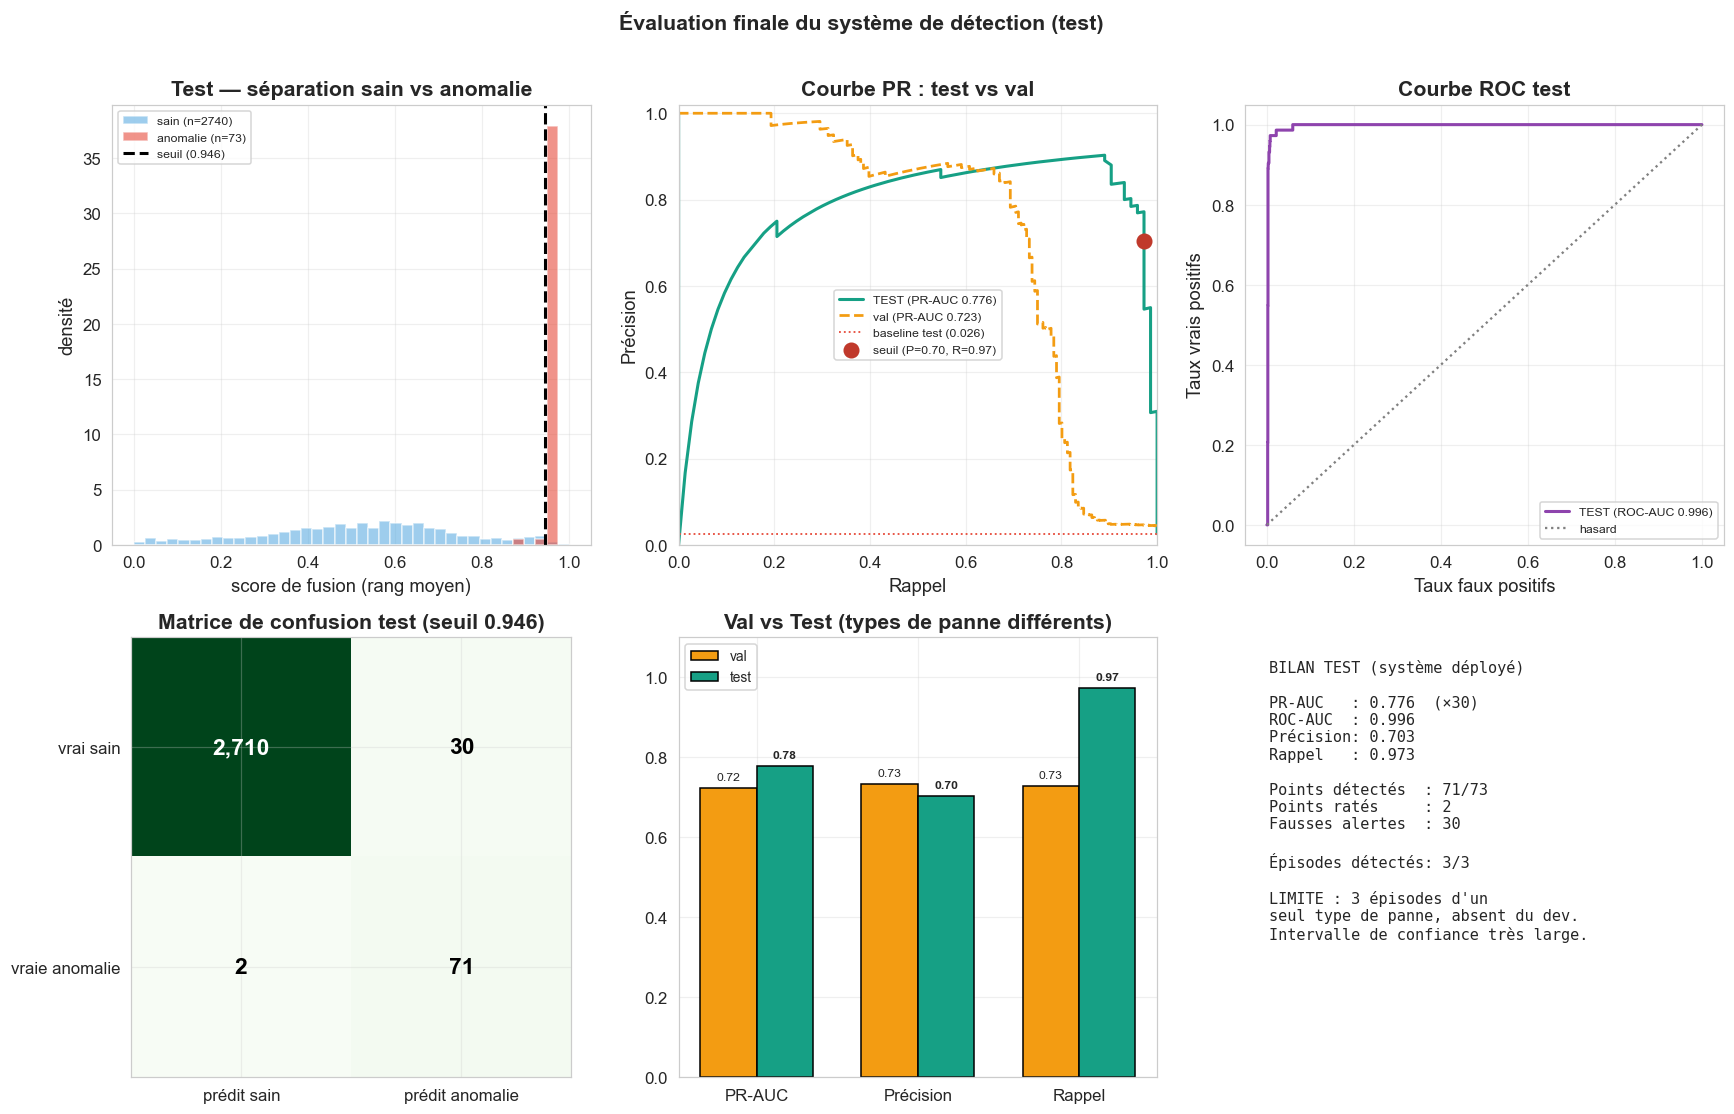

SYNTHÈSE — les mêmes chiffres qu'en 15.10, rappelés pour la soutenance
  validation : PR-AUC 0.7234 | précision 0.731 | rappel 0.727 | épisodes 4/4
  test       : PR-AUC 0.7765 | précision 0.703 | rappel 0.973 | épisodes 3/3

  Le rappel test (0.973) dépasse le rappel val (0.727)
  parce que les deux jeux ne contiennent pas les mêmes pannes :
  test = [3.1], val = [3.2, 4.0].
  Voir la cellule markdown de limites, avant 15.10.


In [83]:
###############################################################
# 15.11 — Tableau de bord de l'évaluation finale
###############################################################
# Visualisations du système déployé (fusion AE+LSTM) sur le test.
# Aucun recalcul de modèle : on ne fait qu'illustrer les sorties de 15.10.

# alias sur les sorties du détecteur (cellules 15.5, 15.6 et 15.10)
score_fusion_test = _s_te
SEUIL_AFFICHE     = det.seuil

_prec_te, _rec_te_c, _thr_te = precision_recall_curve(_y_te, score_fusion_test)
_fpr, _tpr, _ = roc_curve(_y_te, score_fusion_test)
_pred_te = (score_fusion_test >= SEUIL_AFFICHE).astype(int)
_cm_aff = confusion_matrix(_y_te, _pred_te)

# val (pour comparaison)
_prec_va, _rec_va_c, _ = precision_recall_curve(_y_val, score_fusion_val_dep)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (1) Distribution des scores test : sain vs anomalie
ax = axes[0,0]
_ss = score_fusion_test[_y_te==0]; _sa = score_fusion_test[_y_te==1]
_bins = np.linspace(0,1,40)
ax.hist(_ss, bins=_bins, alpha=0.6, color="#5DADE2", label=f"sain (n={len(_ss)})", density=True)
ax.hist(_sa, bins=_bins, alpha=0.6, color="#E74C3C", label=f"anomalie (n={len(_sa)})", density=True)
ax.axvline(SEUIL_AFFICHE, color="black", ls="--", lw=2, label=f"seuil ({SEUIL_AFFICHE:.3f})")
ax.set_xlabel("score de fusion (rang moyen)"); ax.set_ylabel("densité")
ax.set_title("Test — séparation sain vs anomalie", fontweight="bold"); ax.legend(fontsize=8)

# (2) Courbe PR test + val superposées (comparaison honnête)
ax = axes[0,1]
ax.plot(_rec_te_c, _prec_te, color="#16A085", lw=2, label=f"TEST (PR-AUC {_prauc_te:.3f})")
ax.plot(_rec_va_c, _prec_va, color="#F39C12", lw=1.8, ls="--",
        label=f"val (PR-AUC {PRAUC_FUSION_VAL_DEP:.3f})")
ax.axhline(_y_te.mean(), color="#E74C3C", ls=":", lw=1.2,
           label=f"baseline test ({_y_te.mean():.3f})")
_pred_at = (score_fusion_test>=SEUIL_AFFICHE)
if _pred_at.sum()>0:
    _po=(_pred_at&(_y_te==1)).sum()/_pred_at.sum(); _ro=(_pred_at&(_y_te==1)).sum()/(_y_te==1).sum()
    ax.scatter([_ro],[_po], color="#C0392B", s=90, zorder=5, label=f"seuil (P={_po:.2f}, R={_ro:.2f})")
ax.set_xlabel("Rappel"); ax.set_ylabel("Précision"); ax.set_xlim(0,1); ax.set_ylim(0,1.02)
ax.set_title("Courbe PR : test vs val", fontweight="bold"); ax.legend(fontsize=8)

# (3) Courbe ROC test
ax = axes[0,2]
ax.plot(_fpr, _tpr, color="#8E44AD", lw=2, label=f"TEST (ROC-AUC {_rocauc_te:.3f})")
ax.plot([0,1],[0,1], color="gray", ls=":", label="hasard")
ax.set_xlabel("Taux faux positifs"); ax.set_ylabel("Taux vrais positifs")
ax.set_title("Courbe ROC test", fontweight="bold"); ax.legend(fontsize=8)

# (4) Matrice de confusion test
ax = axes[1,0]
im = ax.imshow(_cm_aff, cmap="Greens")
for (r,c),v in np.ndenumerate(_cm_aff):
    ax.text(c,r,f"{v:,}",ha="center",va="center",fontsize=15,fontweight="bold",
            color="white" if v>_cm_aff.max()/2 else "black")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["prédit sain","prédit anomalie"]); ax.set_yticklabels(["vrai sain","vraie anomalie"])
ax.set_title(f"Matrice de confusion test (seuil {SEUIL_AFFICHE:.3f})", fontweight="bold")

# (5) Comparaison val vs test (barres)
ax = axes[1,1]
_metrics = ["PR-AUC","Précision","Rappel"]
_vp_a,_fp_a,_fn_a = _cm_aff[1,1],_cm_aff[0,1],_cm_aff[1,0]
_p_te_a=_vp_a/(_vp_a+_fp_a) if _vp_a+_fp_a else 0
_r_te_a=_vp_a/(_vp_a+_fn_a) if _vp_a+_fn_a else 0
_val_v = [PRAUC_FUSION_VAL_DEP, PREC_VAL_PROD, REC_VAL_PROD]
_test_v= [_prauc_te, _p_te_a, _r_te_a]
_x=np.arange(len(_metrics)); _w=0.35
ax.bar(_x-_w/2,_val_v,_w,label="val",color="#F39C12",edgecolor="black")
ax.bar(_x+_w/2,_test_v,_w,label="test",color="#16A085",edgecolor="black")
for i,(v,t) in enumerate(zip(_val_v,_test_v)):
    ax.text(i-_w/2,v+0.02,f"{v:.2f}",ha="center",fontsize=8)
    ax.text(i+_w/2,t+0.02,f"{t:.2f}",ha="center",fontsize=8,fontweight="bold")
ax.set_xticks(_x); ax.set_xticklabels(_metrics); ax.set_ylim(0,1.1)
ax.set_title("Val vs Test (types de panne différents)", fontweight="bold"); ax.legend(fontsize=9)

# (6) Récap + note de transparence
ax = axes[1,2]; ax.axis("off")
_txt=(f"BILAN TEST (système déployé)\n\n"
      f"PR-AUC   : {_prauc_te:.3f}  (×{_prauc_te/_y_te.mean():.0f})\n"
      f"ROC-AUC  : {_rocauc_te:.3f}\n"
      f"Précision: {_p_te_a:.3f}\n"
      f"Rappel   : {_r_te_a:.3f}\n\n"
      f"Points détectés  : {_vp_a}/{_vp_a+_fn_a}\n"
      f"Points ratés     : {_fn_a}\n"
      f"Fausses alertes  : {_fp_a}\n\n"
      f"Épisodes détectés: {_res_ep_te['episodes_detectes']}/"
      f"{_res_ep_te['n_episodes']}\n\n"
      f"LIMITE : {_res_ep_te['n_episodes']} épisodes d'un\n"
      f"seul type de panne, absent du dev.\n"
      f"Intervalle de confiance très large.")
ax.text(0.05,0.95,_txt,transform=ax.transAxes,fontsize=10,va="top",family="monospace")

plt.suptitle("Évaluation finale du système de détection (test)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/fig_eval_finale_B.png", dpi=150, bbox_inches="tight")
plt.show()

print("=" * 62)
print("SYNTHÈSE — les mêmes chiffres qu'en 15.10, rappelés pour la soutenance")
print("=" * 62)
print(f"  validation : PR-AUC {PRAUC_FUSION_VAL_DEP:.4f} | précision {PREC_VAL_PROD:.3f} "
      f"| rappel {REC_VAL_PROD:.3f} | épisodes {EPISODES_VAL_DET}/{EPISODES_VAL}")
print(f"  test       : PR-AUC {_prauc_te:.4f} | précision {_p_te_a:.3f} "
      f"| rappel {_r_te_a:.3f} | épisodes {_res_ep_te['episodes_detectes']}/"
      f"{_res_ep_te['n_episodes']}")
print(f"\n  Le rappel test ({_r_te_a:.3f}) dépasse le rappel val ({REC_VAL_PROD:.3f})")
print(f"  parce que les deux jeux ne contiennent pas les mêmes pannes :")
print(f"  test = {sorted(test.loc[test['Fault'] != 0, 'Fault'].unique().tolist())}, "
      f"val = {sorted(val.loc[val['Fault'] != 0, 'Fault'].unique().tolist())}.")
print(f"  Voir la cellule markdown de limites, avant 15.10.")